<a href="https://colab.research.google.com/github/aodm26/DDOS_Study/blob/main/Real_CN7030_Group4_DDoS_no_leakage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CN7030 – Machine Learning on Big Data – leakage-free version
## Group 4 – DDoS Network Flow Dataset (balanced, `final_dataset.parquet`)
### Tasks 1–12 and modelling: Description, Schema, Hidden Missing Values, Categorical Cleaning, Targets, Leakage, Single-Column Exploration, Cleaning Log

**Dataset.** Each row is one bidirectional network **flow** produced by CICFlowMeter (a flow is all packets that share
the same source/destination IP, source/destination port and protocol until the flow ends or times out after 120 s).
The file combines flows from several public IDS captures (2010, 2017 and 2018 testbeds) and labels each flow `ddos` or `Benign`.

**Rules followed throughout**
* Every number quoted comes from our own code on our own file – not the Kaggle page.
* Every output is saved as a table (CSV) in `OUT_DIR/tables`, every figure as a PNG in `OUT_DIR/figures`.
* Every cleaning decision is appended to the decisions log **as we go** (`log_decision(...)`), and printed as the Task 8 table at the end.

---

> **Leakage-free version.** Seven columns that fingerprint the capture or machine rather than the traffic are removed from every model: `Fwd Seg Size Min`, `Init Fwd Win Byts`, `Init Bwd Win Byts`, `init_fwd_win_missing`, `init_bwd_win_missing`, `src_port_range`, `rate_missing`. Results from Task 11 on are saved in `CN7030_Group4_outputs/no_leakage/`, so the earlier results stay available for comparison.

## 0. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
!pip install pyspark python-docx -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 450.1/450.1 MB 8.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 152.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.0/203.0 kB 25.0 MB/s eta 0:00:00


In [ ]:
PARQUET_PATH = '/content/drive/MyDrive/final_dataset.parquet'   # balanced file (converted from CSV)
CSV_PATH     = '/content/drive/MyDrive/final_dataset.csv'       # optional: original CSV, used if present
OUT_DIR      = '/content/drive/MyDrive/CN7030_Group4_outputs'

In [ ]:
import os, re, math, textwrap, datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F
from pyspark.sql.types import (StructType, StructField, StringType, IntegerType,
                               LongType, DoubleType, TimestampType, NumericType)

# ---------------- paths ----------------
# PARQUET_PATH = 'ddos.parquet'   # balanced file (converted from CSV)
# CSV_PATH     = '/content/drive/MyDrive/final_dataset.csv'       # optional: original CSV, used if present
# OUT_DIR      = '/content/drive/MyDrive/CN7030_Group4_outputs'

TABLE_DIR, FIG_DIR = f'{OUT_DIR}/tables', f'{OUT_DIR}/figures'
os.makedirs(TABLE_DIR, exist_ok=True); os.makedirs(FIG_DIR, exist_ok=True)



spark = (SparkSession.builder
         .appName('DDoS_Group4')
         .config('spark.driver.memory', '8g')
         .config('spark.sql.shuffle.partitions', '64')
         .getOrCreate())
spark.sparkContext.setLogLevel('ERROR')
print('Spark version:', spark.version)

# ---------------- house style for tables and charts ----------------
BLUE, PALE, NAVY = '#1D9BD1', '#CFE8F4', '#06324A'
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 13, 'axes.labelsize': 12,
                     'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 11,
                     'text.color': NAVY, 'axes.labelcolor': NAVY, 'xtick.color': NAVY,
                     'ytick.color': NAVY, 'axes.edgecolor': '#9DB7C6',
                     'axes.spines.top': False, 'axes.spines.right': False})

def show(pdf, name, max_rows=100):
    '''Save a pandas table as CSV and display it in the blue-and-white house style.'''
    pdf.to_csv(f'{TABLE_DIR}/{name}.csv', index=False)
    view = pdf.head(max_rows)
    sty = (view.style.hide(axis='index')
           .set_table_styles([
               {'selector': 'th', 'props': f'background-color:{BLUE};color:white;font-weight:bold;border:1px solid #9DB7C6;padding:4px 8px;'},
               {'selector': 'td', 'props': f'color:{NAVY};border:1px solid #9DB7C6;padding:3px 8px;'},
               {'selector': 'tbody tr:nth-child(odd)', 'props': f'background-color:{PALE};'},
               {'selector': 'tbody tr:nth-child(even)', 'props': 'background-color:white;'}])
           .format(precision=4, thousands=','))
    print(f'Table saved: tables/{name}.csv  ({len(pdf):,} rows)')
    display(sty)

# ---------------- Task 8 log, filled in as we go ----------------
DECISIONS = []
def log_decision(task, column, issue, decision, reason, rows_affected):
    DECISIONS.append({'task': task, 'column(s)': column, 'issue found': issue,
                      'decision taken': decision, 'reason': reason,
                      'rows affected': int(rows_affected)})

def q(c):                      # back-tick a column name for SQL expressions
    return f'`{c}`'

Spark version: 4.2.0


---
# TASK 1 – Finalise the Description
We are not looking for insights yet – only for what is broken.

### 1.1 Row count and column count (read from the file)

In [ ]:
df_raw = spark.read.parquet(PARQUET_PATH)      # parquet stores its own types, no inference pass happens
ROW_COUNT = df_raw.count()
COL_COUNT = len(df_raw.columns)

t11 = pd.DataFrame({'metric': ['Rows', 'Columns', 'File'],
                    'value': [f'{ROW_COUNT:,}', COL_COUNT, os.path.basename(PARQUET_PATH)]})
show(t11, 't1_1_shape')
show(pd.DataFrame({'position': range(1, COL_COUNT + 1), 'column': df_raw.columns,
                   'stored_type': [f.dataType.simpleString() for f in df_raw.schema.fields]}),
     't1_1_columns')

Table saved: tables/t1_1_shape.csv  (3 rows)


metric,value
Rows,"12,794,627"
Columns,85
File,final_dataset.parquet


Table saved: tables/t1_1_columns.csv  (85 rows)


position,column,stored_type
1,row_id,bigint
2,Flow ID,string
3,Src IP,string
4,Src Port,bigint
5,Dst IP,string
6,Dst Port,bigint
7,Protocol,bigint
8,Timestamp,string
9,Flow Duration,double
10,Tot Fwd Pkts,double


> **Note on `row_id`.** The first column of the CSV has no header – it is the pandas index written out by whoever built the
> Kaggle file. We named it `row_id`. It is **not** a key (see 1.3), so every duplicate check is run both with and without it.

### 1.2 Exact duplicate rows (every value repeated)

In [ ]:
cols_no_id = [c for c in df_raw.columns if c != 'row_id']

def exact_dups(cols):
    g = df_raw.groupBy([F.col(c) for c in cols]).count().filter('count > 1')
    r = g.agg(F.count('*').alias('groups'), F.sum('count').alias('rows')).first()
    groups, rows = (r['groups'] or 0), (r['rows'] or 0)
    return groups, rows, rows - groups          # extra copies = rows that would be removed

g_all, r_all, x_all = exact_dups(df_raw.columns)
g_nid, r_nid, x_nid = exact_dups(cols_no_id)

t12 = pd.DataFrame([
    {'check': 'All 85 columns', 'duplicate groups': g_all, 'rows involved': r_all,
     'extra copies': x_all, 'extra copies %': x_all / ROW_COUNT * 100},
    {'check': '84 columns (row_id excluded)', 'duplicate groups': g_nid, 'rows involved': r_nid,
     'extra copies': x_nid, 'extra copies %': x_nid / ROW_COUNT * 100},
])
show(t12, 't1_2_exact_duplicates')

log_decision('T1', 'all columns', f'{x_all:,} exact duplicate rows (all 85 columns)',
             'No action' if x_all == 0 else 'Drop extra copies',
             'Nothing is repeated when row_id is included – no failed export or double join',
             x_all)
log_decision('T1', 'all except row_id', f'{x_nid:,} extra copies once the artificial row_id is ignored',
             'Drop extra copies (keep first)' if x_nid else 'No action',
             'row_id is a pandas index, not data; identical flow records counted twice would bias the model towards them',
             x_nid)

Table saved: tables/t1_2_exact_duplicates.csv  (2 rows)


check,duplicate groups,rows involved,extra copies,extra copies %
All 85 columns,0,0,0,0.0000
84 columns (row_id excluded),12,37,25,0.0002


### 1.3 Duplicates on key columns only
There is no official primary key. Two candidate keys:
* `row_id` – should be unique if it were a real ID.
* **`Flow ID` + `Timestamp`** – the same 5-tuple starting in the same second describes the *same flow*.
  `Flow ID` on its own legitimately repeats (the same connection re-used later), so it is not a key by itself.

For the second key we also count groups where the rows **disagree** (different `Label` or different `Flow Duration`) –
these are the "same event, different values" cases a plain duplicate check misses.

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

PARQUET_PATH = '/content/drive/MyDrive/final_dataset.parquet'

spark = (SparkSession.builder
         .appName('DDoS_Group4')
         .config('spark.driver.memory', '8g')
         .config('spark.sql.shuffle.partitions', '64')
         .getOrCreate())

df_raw = spark.read.parquet(PARQUET_PATH)
ROW_COUNT = df_raw.count()

def key_dups(keys):
    g = (df_raw.groupBy(keys)
               .agg(F.count('*').alias('n'),
                    F.countDistinct('Label').alias('labels'),
                    F.countDistinct('Flow Duration').alias('durations'))
               .filter('n > 1'))
    r = g.agg(F.count('*').alias('groups'), F.sum('n').alias('rows'),
              F.sum(F.when(F.col('labels') > 1, F.col('n')).otherwise(0)).alias('rows_conflicting_label'),
              F.sum(F.when(F.col('durations') > 1, F.col('n')).otherwise(0)).alias('rows_conflicting_duration')).first()
    return g, {k: (r[k] or 0) for k in r.asDict()}

rid_distinct = df_raw.select('row_id').distinct().count()
g_key, k = key_dups(['Flow ID', 'Timestamp'])

t13 = pd.DataFrame([
    {'key': 'row_id', 'distinct values': rid_distinct, 'rows': ROW_COUNT,
     'rows sharing a key': ROW_COUNT - rid_distinct, 'rows with conflicting Label': None,
     'rows with conflicting Flow Duration': None},
    {'key': 'Flow ID + Timestamp', 'distinct values': None, 'rows': ROW_COUNT,
     'rows sharing a key': k['rows'], 'rows with conflicting Label': k['rows_conflicting_label'],
     'rows with conflicting Flow Duration': k['rows_conflicting_duration']},
])
show(t13, 't1_3_key_duplicates')

print('Most repeated Flow ID + Timestamp groups:')
show(g_key.orderBy(F.desc('n')).limit(15).toPandas(), 't1_3_key_duplicate_examples')

log_decision('T1', 'row_id', f'row_id is not unique ({ROW_COUNT - rid_distinct:,} repeats)',
             'Drop row_id',
             'It is the index of the separate source files that were concatenated – it identifies nothing and restarts per file',
             ROW_COUNT)
log_decision('T1', 'Flow ID + Timestamp', f"{k['rows']:,} rows share a key; {k['rows_conflicting_label']:,} of them carry different Labels",
             'Keep; exclude conflicting-label groups from training' if k['rows_conflicting_label'] else 'Keep',
             'CICFlowMeter splits long connections into several flows in the same second, so sharing a key is normal; '
             'a key that is both ddos and Benign cannot be learnt consistently',
             k['rows_conflicting_label'])

Table saved: tables/t1_3_key_duplicates.csv  (2 rows)


key,distinct values,rows,rows sharing a key,rows with conflicting Label,rows with conflicting Flow Duration
row_id,"7,046,497.0000","12,794,627","5,748,130",nan,nan
Flow ID + Timestamp,nan,"12,794,627","6,508,624",6.0000,"6,506,055.0000"


Most repeated Flow ID + Timestamp groups:
Table saved: tables/t1_3_key_duplicate_examples.csv  (15 rows)


Flow ID,Timestamp,n,labels,durations
8.0.6.4-8.6.0.1-0-0-0,20/02/2018 12:20:20,11,1,11
8.0.6.4-8.6.0.1-0-0-0,20/02/2018 02:10:10,11,1,11
8.0.6.4-8.6.0.1-0-0-0,20/02/2018 09:26:09,11,1,11
8.0.6.4-8.6.0.1-0-0-0,20/02/2018 09:53:54,11,1,11
8.0.6.4-8.6.0.1-0-0-0,20/02/2018 02:55:16,10,1,10
8.0.6.4-8.6.0.1-0-0-0,20/02/2018 08:55:15,10,1,10
8.0.6.4-8.6.0.1-0-0-0,20/02/2018 04:56:22,10,1,10
8.0.6.4-8.6.0.1-0-0-0,20/02/2018 02:01:43,10,1,10
8.0.6.4-8.6.0.1-0-0-0,20/02/2018 10:42:11,10,1,10
8.0.6.4-8.6.0.1-0-0-0,20/02/2018 01:59:29,10,1,10


### 1.4 Null count and null percentage for every column (worst first)
For decimal columns a Spark `null` and a floating-point `NaN` are different things – we count both. `±Infinity` is counted
separately here and dealt with in Task 3.

In [ ]:
float_cols = [f.name for f in df_raw.schema.fields if isinstance(f.dataType, DoubleType)]
exprs = []
for c in df_raw.columns:
    exprs.append(F.sum(F.col(c).isNull().cast('int')).alias(f'{c}__null'))
    if c in float_cols:
        exprs.append(F.sum(F.isnan(F.col(c)).cast('int')).alias(f'{c}__nan'))
        exprs.append(F.sum((F.abs(F.col(c)) == float('inf')).cast('int')).alias(f'{c}__inf'))
r = df_raw.agg(*exprs).first().asDict()

rows = []
for c in df_raw.columns:
    n, nan, inf = r[f'{c}__null'] or 0, r.get(f'{c}__nan') or 0, r.get(f'{c}__inf') or 0
    rows.append({'column': c, 'null_count': n, 'nan_count': nan, 'null_pct': n / ROW_COUNT * 100,
                 'null+nan_pct': (n + nan) / ROW_COUNT * 100, 'infinity_count': inf})
null_tbl = pd.DataFrame(rows).sort_values(['null+nan_pct', 'infinity_count'], ascending=False).reset_index(drop=True)
show(null_tbl, 't1_4_nulls', max_rows=85)

Table saved: tables/t1_4_nulls.csv  (85 rows)


column,null_count,nan_count,null_pct,null+nan_pct,infinity_count
Flow Byts/s,"29,713",0,0.2322,0.2322,"18,067"
Flow Pkts/s,0,0,0.0000,0.0000,"47,780"
row_id,0,0,0.0000,0.0000,0
Flow ID,0,0,0.0000,0.0000,0
Src IP,0,0,0.0000,0.0000,0
Src Port,0,0,0.0000,0.0000,0
Dst IP,0,0,0.0000,0.0000,0
Dst Port,0,0,0.0000,0.0000,0
Protocol,0,0,0.0000,0.0000,0
Timestamp,0,0,0.0000,0.0000,0


### 1.5 Distinct count for every categorical column (highest first)
Categorical here means *labels, identifiers and codes* – including the columns stored as digits (ports, protocol, 0/1 TCP flag
counters). `Timestamp` is included only for information; it becomes a real timestamp in Task 2.

In [ ]:
FLAG_COLS = ['Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags',
             'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt',
             'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt']
CATEGORICAL_COLS = ['Flow ID', 'Src IP', 'Dst IP', 'Src Port', 'Dst Port', 'Protocol',
                    'Timestamp', 'Label'] + FLAG_COLS

distinct_rows = [{'column': c, 'distinct_count': df_raw.select(c).distinct().count()} for c in CATEGORICAL_COLS]
distinct_tbl = pd.DataFrame(distinct_rows).sort_values('distinct_count', ascending=False).reset_index(drop=True)
distinct_tbl['distinct_pct_of_rows'] = distinct_tbl['distinct_count'] / ROW_COUNT * 100
show(distinct_tbl, 't1_5_distinct_counts')

Table saved: tables/t1_5_distinct_counts.csv  (20 rows)


column,distinct_count,distinct_pct_of_rows
Flow ID,"4,837,154",37.8061
Timestamp,"85,973",0.6719
Src Port,"64,889",0.5072
Dst Port,"59,091",0.4618
Src IP,"36,760",0.2873
Dst IP,"34,321",0.2682
Protocol,3,0.0000
Label,2,0.0000
Fwd PSH Flags,2,0.0000
Bwd PSH Flags,2,0.0000


---
# TASK 2 – Fix the Schema
The schema below is written by hand – one line per column with the type we chose and why.
**Type rules used:**
* **String** – identifiers and codes (IPs, Flow ID, ports, protocol, label). Digits that are labels, not quantities.
* **Long (whole number)** – anything counted (packets, bytes, header bytes) or measured in whole microseconds by CICFlowMeter.
* **Integer** – 0/1 TCP flag indicators.
* **Double (decimal)** – means, standard deviations, variances and per-second rates.
* **Timestamp** – `Timestamp`, parsed from text after loading (the file mixes two text formats, see 2.4).

### 2.1 Hand-written schema: name, assigned type, reason

In [ ]:
S, L, I, D = StringType(), LongType(), IntegerType(), DoubleType()
SCHEMA_DOC = [
 ('row_id',           L, 'Unnamed pandas index from the source files; whole number, not a real ID – dropped later'),
 ('Flow ID',          S, 'Text key "ipA-ipB-portA-portB-protocol"; identifier, never used in arithmetic'),
 ('Src IP',           S, 'IPv4 address is a label with dots, not a number'),
 ('Src Port',         S, 'Port number is a service/socket code – the average of ports is meaningless'),
 ('Dst IP',           S, 'IPv4 address is a label with dots, not a number'),
 ('Dst Port',         S, 'Port identifies the service (80=HTTP, 53=DNS); a category, not a quantity'),
 ('Protocol',         S, 'IANA protocol code (6=TCP, 17=UDP, 0=other); category, not a quantity'),
 ('Timestamp',        S, 'Read as text because the file mixes 12-h and 24-h formats; converted to Timestamp in 2.4'),
 ('Flow Duration',    L, 'Whole microseconds between first and last packet'),
 ('Tot Fwd Pkts',     L, 'Count of forward packets – whole number'),
 ('Tot Bwd Pkts',     L, 'Count of backward packets – whole number'),
 ('TotLen Fwd Pkts',  L, 'Total forward payload in bytes – whole number'),
 ('TotLen Bwd Pkts',  L, 'Total backward payload in bytes – whole number'),
 ('Fwd Pkt Len Max',  L, 'Largest forward packet in bytes – whole number'),
 ('Fwd Pkt Len Min',  L, 'Smallest forward packet in bytes – whole number'),
 ('Fwd Pkt Len Mean', D, 'Average of packet sizes – can be fractional'),
 ('Fwd Pkt Len Std',  D, 'Standard deviation – fractional'),
 ('Bwd Pkt Len Max',  L, 'Largest backward packet in bytes – whole number'),
 ('Bwd Pkt Len Min',  L, 'Smallest backward packet in bytes – whole number'),
 ('Bwd Pkt Len Mean', D, 'Average of packet sizes – fractional'),
 ('Bwd Pkt Len Std',  D, 'Standard deviation – fractional'),
 ('Flow Byts/s',      D, 'Bytes per second (a rate) – fractional; can be Infinity when duration is 0'),
 ('Flow Pkts/s',      D, 'Packets per second (a rate) – fractional; can be Infinity when duration is 0'),
 ('Flow IAT Mean',    D, 'Mean inter-arrival time in microseconds – fractional'),
 ('Flow IAT Std',     D, 'Standard deviation of inter-arrival time – fractional'),
 ('Flow IAT Max',     L, 'Largest gap between packets, whole microseconds'),
 ('Flow IAT Min',     L, 'Smallest gap between packets, whole microseconds'),
 ('Fwd IAT Tot',      L, 'Sum of forward gaps, whole microseconds'),
 ('Fwd IAT Mean',     D, 'Mean forward gap – fractional'),
 ('Fwd IAT Std',      D, 'Standard deviation of forward gaps – fractional'),
 ('Fwd IAT Max',      L, 'Largest forward gap, whole microseconds'),
 ('Fwd IAT Min',      L, 'Smallest forward gap, whole microseconds'),
 ('Bwd IAT Tot',      L, 'Sum of backward gaps, whole microseconds'),
 ('Bwd IAT Mean',     D, 'Mean backward gap – fractional'),
 ('Bwd IAT Std',      D, 'Standard deviation of backward gaps – fractional'),
 ('Bwd IAT Max',      L, 'Largest backward gap, whole microseconds'),
 ('Bwd IAT Min',      L, 'Smallest backward gap, whole microseconds'),
 ('Fwd PSH Flags',    I, '0/1 indicator: PSH flag seen in forward direction'),
 ('Bwd PSH Flags',    I, '0/1 indicator: PSH flag seen in backward direction'),
 ('Fwd URG Flags',    I, '0/1 indicator: URG flag seen in forward direction'),
 ('Bwd URG Flags',    I, '0/1 indicator: URG flag seen in backward direction'),
 ('Fwd Header Len',   L, 'Total forward header bytes – whole number'),
 ('Bwd Header Len',   L, 'Total backward header bytes – whole number'),
 ('Fwd Pkts/s',       D, 'Forward packets per second – rate, fractional'),
 ('Bwd Pkts/s',       D, 'Backward packets per second – rate, fractional'),
 ('Pkt Len Min',      L, 'Smallest packet in the flow, bytes – whole number'),
 ('Pkt Len Max',      L, 'Largest packet in the flow, bytes – whole number'),
 ('Pkt Len Mean',     D, 'Mean packet size – fractional'),
 ('Pkt Len Std',      D, 'Standard deviation of packet size – fractional'),
 ('Pkt Len Var',      D, 'Variance of packet size – fractional'),
 ('FIN Flag Cnt',     I, '0/1 indicator: FIN flag present'),
 ('SYN Flag Cnt',     I, '0/1 indicator: SYN flag present'),
 ('RST Flag Cnt',     I, '0/1 indicator: RST flag present'),
 ('PSH Flag Cnt',     I, '0/1 indicator: PSH flag present'),
 ('ACK Flag Cnt',     I, '0/1 indicator: ACK flag present'),
 ('URG Flag Cnt',     I, '0/1 indicator: URG flag present'),
 ('CWE Flag Count',   I, '0/1 indicator: CWR flag present'),
 ('ECE Flag Cnt',     I, '0/1 indicator: ECE flag present'),
 ('Down/Up Ratio',    L, 'Backward/forward packet ratio; CICFlowMeter stores it as an integer division'),
 ('Pkt Size Avg',     D, 'Average packet size – fractional'),
 ('Fwd Seg Size Avg', D, 'Average forward segment size – fractional'),
 ('Bwd Seg Size Avg', D, 'Average backward segment size – fractional'),
 ('Fwd Byts/b Avg',   D, 'Bulk-transfer average (bytes per bulk) – decimal in the tool output'),
 ('Fwd Pkts/b Avg',   D, 'Bulk-transfer average (packets per bulk) – decimal'),
 ('Fwd Blk Rate Avg', D, 'Bulk-transfer rate – decimal'),
 ('Bwd Byts/b Avg',   D, 'Bulk-transfer average (bytes per bulk) – decimal'),
 ('Bwd Pkts/b Avg',   D, 'Bulk-transfer average (packets per bulk) – decimal'),
 ('Bwd Blk Rate Avg', D, 'Bulk-transfer rate – decimal'),
 ('Subflow Fwd Pkts', L, 'Forward packets per sub-flow – whole number'),
 ('Subflow Fwd Byts', L, 'Forward bytes per sub-flow – whole number'),
 ('Subflow Bwd Pkts', L, 'Backward packets per sub-flow – whole number'),
 ('Subflow Bwd Byts', L, 'Backward bytes per sub-flow – whole number'),
 ('Init Fwd Win Byts',L, 'TCP initial window size in bytes; whole number, -1 means "not observed" (Task 3)'),
 ('Init Bwd Win Byts',L, 'TCP initial window size in bytes; whole number, -1 means "not observed" (Task 3)'),
 ('Fwd Act Data Pkts',L, 'Count of forward packets carrying payload – whole number'),
 ('Fwd Seg Size Min', L, 'Minimum forward header size in bytes (few distinct values) – whole number'),
 ('Active Mean',      D, 'Mean active period, microseconds – fractional'),
 ('Active Std',       D, 'Standard deviation of active periods – fractional'),
 ('Active Max',       L, 'Longest active period, whole microseconds'),
 ('Active Min',       L, 'Shortest active period, whole microseconds'),
 ('Idle Mean',        D, 'Mean idle period, microseconds – fractional'),
 ('Idle Std',         D, 'Standard deviation of idle periods – fractional'),
 ('Idle Max',         L, 'Longest idle period, whole microseconds'),
 ('Idle Min',         L, 'Shortest idle period, whole microseconds'),
 ('Label',            S, 'Class label text ("ddos" / "Benign") – classification target'),
]
assert [c for c, _, _ in SCHEMA_DOC] == df_raw.columns, 'schema order/name mismatch with file'

declared_schema = StructType([StructField(c, t, True) for c, t, _ in SCHEMA_DOC])
schema_doc_tbl = pd.DataFrame([{'column': c, 'assigned_type': t.simpleString(), 'reason': why}
                               for c, t, why in SCHEMA_DOC])
show(schema_doc_tbl, 't2_1_declared_schema', max_rows=85)

Table saved: tables/t2_1_declared_schema.csv  (85 rows)


column,assigned_type,reason
row_id,bigint,"Unnamed pandas index from the source files; whole number, not a real ID – dropped later"
Flow ID,string,"Text key ""ipA-ipB-portA-portB-protocol""; identifier, never used in arithmetic"
Src IP,string,"IPv4 address is a label with dots, not a number"
Src Port,string,Port number is a service/socket code – the average of ports is meaningless
Dst IP,string,"IPv4 address is a label with dots, not a number"
Dst Port,string,"Port identifies the service (80=HTTP, 53=DNS); a category, not a quantity"
Protocol,string,"IANA protocol code (6=TCP, 17=UDP, 0=other); category, not a quantity"
Timestamp,string,Read as text because the file mixes 12-h and 24-h formats; converted to Timestamp in 2.4
Flow Duration,bigint,Whole microseconds between first and last packet
Tot Fwd Pkts,bigint,Count of forward packets – whole number


### 2.2 Columns that look numeric but are really categories

In [ ]:
numeric_but_category = pd.DataFrame([
 {'column': 'row_id',    'stored_as': 'bigint', 'really_is': 'identifier', 'reason': 'Row position in the source file – no quantity; dropped'},
 {'column': 'Src Port',  'stored_as': 'bigint', 'really_is': 'category',   'reason': 'Ephemeral client port picked at random by the OS'},
 {'column': 'Dst Port',  'stored_as': 'bigint', 'really_is': 'category',   'reason': 'Service code: 80 is not "twice" 40'},
 {'column': 'Protocol',  'stored_as': 'bigint', 'really_is': 'category',   'reason': 'Only 0/6/17; averaging protocol numbers means nothing'},
] + [
 {'column': c, 'stored_as': 'double', 'really_is': 'binary category (0/1)',
  'reason': 'Presence/absence of a TCP flag, not a count – average is a proportion only'} for c in FLAG_COLS
] + [
 {'column': 'Fwd Seg Size Min', 'stored_as': 'double', 'really_is': 'numeric with few levels',
  'reason': 'Header size in bytes – kept numeric (sizes are ordered) but plotted as a bar chart'},
])
show(numeric_but_category, 't2_2_numeric_but_category')
log_decision('T2', 'Src Port, Dst Port, Protocol', 'Codes stored as integers',
             'Declared as String', 'They are labels; numeric type invites meaningless averages and scaling', 0)
log_decision('T2', ', '.join(FLAG_COLS), 'TCP flag indicators stored as decimals (0.0/1.0)',
             'Declared as Integer 0/1 and treated as categorical', 'They only take two values', 0)

Table saved: tables/t2_2_numeric_but_category.csv  (17 rows)


column,stored_as,really_is,reason
row_id,bigint,identifier,Row position in the source file – no quantity; dropped
Src Port,bigint,category,Ephemeral client port picked at random by the OS
Dst Port,bigint,category,"Service code: 80 is not ""twice"" 40"
Protocol,bigint,category,Only 0/6/17; averaging protocol numbers means nothing
Fwd PSH Flags,double,binary category (0/1),"Presence/absence of a TCP flag, not a count – average is a proportion only"
Bwd PSH Flags,double,binary category (0/1),"Presence/absence of a TCP flag, not a count – average is a proportion only"
Fwd URG Flags,double,binary category (0/1),"Presence/absence of a TCP flag, not a count – average is a proportion only"
Bwd URG Flags,double,binary category (0/1),"Presence/absence of a TCP flag, not a count – average is a proportion only"
FIN Flag Cnt,double,binary category (0/1),"Presence/absence of a TCP flag, not a count – average is a proportion only"
SYN Flag Cnt,double,binary category (0/1),"Presence/absence of a TCP flag, not a count – average is a proportion only"


### 2.3 Check code columns for lost leading zeros
Ports and protocol were written to the CSV as plain integers, so the risk here is different from post codes – but IP addresses
and the `Flow ID` can hide zero-padded octets (`010.000.000.001` vs `10.0.0.1`) which would make the *same address* two
different values. We test every code column for:
* values that start with `0` and are longer than one character (a zero that a numeric type would silently drop),
* IP octets with a leading zero,
* values that are not valid for the column (port outside 0–65535, non-numeric characters, malformed IPv4).

In [ ]:
IPV4 = r'^((25[0-5]|2[0-4]\d|1\d\d|[1-9]?\d)\.){3}(25[0-5]|2[0-4]\d|1\d\d|[1-9]?\d)$'
str_df = df_raw.select(*[F.col(c).cast('string').alias(c) for c in ['Src Port', 'Dst Port', 'Protocol']],
                       'Src IP', 'Dst IP', 'Flow ID')
checks = []
for c in ['Src Port', 'Dst Port', 'Protocol']:
    checks += [F.sum(F.col(c).rlike(r'^0\d+').cast('int')).alias(f'{c}|leading zero'),
               F.sum((~F.col(c).rlike(r'^\d+$')).cast('int')).alias(f'{c}|non-digit characters')]
for c in ['Src Port', 'Dst Port']:
    checks.append(F.sum(((F.col(c).cast('long') < 0) | (F.col(c).cast('long') > 65535)).cast('int')).alias(f'{c}|outside 0-65535'))
for c in ['Src IP', 'Dst IP']:
    checks += [F.sum(F.col(c).rlike(r'(^|\.)0\d').cast('int')).alias(f'{c}|zero-padded octet'),
               F.sum((~F.trim(F.col(c)).rlike(IPV4)).cast('int')).alias(f'{c}|not a valid IPv4')]
checks += [F.sum(F.col('Flow ID').rlike(r'(^|[.\-])0\d').cast('int')).alias('Flow ID|zero-padded part'),
           F.sum((F.size(F.split('Flow ID', '-')) != 5).cast('int')).alias('Flow ID|not 5 parts')]
r = str_df.agg(*checks).first().asDict()
lz_tbl = pd.DataFrame([{'column': k.split('|')[0], 'check': k.split('|')[1], 'rows_failing': v or 0}
                       for k, v in r.items()])
show(lz_tbl, 't2_3_leading_zero_checks')
log_decision('T2', 'Ports, Protocol, IPs, Flow ID', 'Leading-zero check',
             'No action' if lz_tbl.rows_failing.sum() == 0 else 'Normalise failing values (Task 4)',
             'Codes read as String keep every character; the check shows whether any padding was already lost/present',
             int(lz_tbl.rows_failing.sum()))

Table saved: tables/t2_3_leading_zero_checks.csv  (14 rows)


column,check,rows_failing
Src Port,leading zero,0
Src Port,non-digit characters,0
Dst Port,leading zero,0
Dst Port,non-digit characters,0
Protocol,leading zero,0
Protocol,non-digit characters,0
Src Port,outside 0-65535,0
Dst Port,outside 0-65535,0
Src IP,zero-padded octet,0
Src IP,not a valid IPv4,0


### 2.4 Convert date/time columns to proper timestamps
`Timestamp` is text in **day/month/year** order, and the file mixes two formats:
* `16/02/2018 11:15:28 PM` – 12-hour clock with AM/PM
* `20/02/2018 10:47:30` – no AM/PM marker

A single format string silently turns the other format into `null`, so we try both (`try_to_timestamp` returns null instead
of failing) and keep the first that parses. We also keep which format a row used – it matters for leakage (Task 6).
Straight after parsing we check whether the rows without AM/PM are really 24-hour times (hours 13–23 must appear)
or 12-hour times that lost their marker.

In [ ]:
FMT_12H, FMT_24H = 'dd/MM/yyyy hh:mm:ss a', 'dd/MM/yyyy HH:mm:ss'

def parse_ts(df, col='Timestamp'):
    ts12 = F.expr(f"try_to_timestamp({q(col)}, '{FMT_12H}')")
    ts24 = F.expr(f"try_to_timestamp({q(col)}, '{FMT_24H}')")
    return (df.withColumn('ts_format', F.when(ts12.isNotNull(), '12h AM/PM')
                                         .when(ts24.isNotNull(), 'no AM/PM').otherwise('unparsed'))
              .withColumn('Timestamp_raw', F.col(col))
              .withColumn(col, F.coalesce(ts12, ts24)))

tmp = parse_ts(df_raw.select('Timestamp'))
fmt_tbl = (tmp.groupBy('ts_format').agg(F.count('*').alias('rows'),
                                         F.min('Timestamp').alias('earliest'),
                                         F.max('Timestamp').alias('latest'),
                                         F.first('Timestamp_raw').alias('example_raw'))
              .toPandas().sort_values('rows', ascending=False))
fmt_tbl['pct'] = fmt_tbl.rows / ROW_COUNT * 100
show(fmt_tbl, 't2_4_timestamp_formats')

unparsed = int(fmt_tbl.loc[fmt_tbl.ts_format == 'unparsed', 'rows'].sum())
if unparsed:
    print('Examples that failed both formats:')
    tmp.filter("ts_format = 'unparsed'").select('Timestamp_raw').distinct().show(20, False)

log_decision('T2', 'Timestamp', 'Text dates in two formats (with and without AM/PM), day-first',
             'Parsed with both patterns into TimestampType; kept ts_format for audit',
             'One pattern alone nulls the other half silently; text dates sort by day and cannot be subtracted',
             int(fmt_tbl.loc[fmt_tbl.ts_format == 'no AM/PM', 'rows'].sum()))

Table saved: tables/t2_4_timestamp_formats.csv  (2 rows)


ts_format,rows,earliest,latest,example_raw,pct
no AM/PM,"6,474,240",2018-02-20 01:00:00,2018-02-20 12:59:59,20/02/2018 10:13:54,50.6012
12h AM/PM,"6,320,387",2010-06-12 08:34:32,2018-02-22 00:35:54,12/06/2010 08:34:32 AM,49.3988


#### 2.4b Are the "no AM/PM" rows really 24-hour times?
If they were, hours 13–23 would appear. If the hour never goes above 12, the AM/PM marker was simply lost in export and the
time of day is **ambiguous** (01:00 could be 1 am or 1 pm).

In [ ]:
hour_tbl = (tmp.filter("ts_format = 'no AM/PM'")
               .groupBy(F.substring('Timestamp_raw', 12, 2).cast('int').alias('hour_as_written'))
               .agg(F.count('*').alias('rows'),
                    F.countDistinct(F.substring('Timestamp_raw', 1, 10)).alias('distinct_dates'))
               .orderBy('hour_as_written').toPandas())
show(hour_tbl, 't2_4b_no_ampm_hours')
MAX_HOUR = int(hour_tbl.hour_as_written.max()) if len(hour_tbl) else None
AMBIGUOUS = MAX_HOUR is not None and MAX_HOUR <= 12
print(f'Highest hour written without AM/PM: {MAX_HOUR} ->',
      'AM/PM LOST – time of day is ambiguous for these rows' if AMBIGUOUS else 'genuine 24-hour clock')
n_noampm = int(hour_tbl.rows.sum())
log_decision('T2', 'Timestamp', f'{n_noampm:,} rows have no AM/PM and hours only 1–{MAX_HOUR}' if AMBIGUOUS
             else f'{n_noampm:,} rows use a 24-hour clock',
             'Keep the date; flag ts_ampm_missing; do not use hour-of-day for these rows' if AMBIGUOUS else 'No action',
             'The date part is reliable, but 01:00 could be 1 am or 1 pm – any hour feature would be half wrong'
             if AMBIGUOUS else 'Parsed correctly with the 24-hour pattern', n_noampm if AMBIGUOUS else 0)

Table saved: tables/t2_4b_no_ampm_hours.csv  (12 rows)


hour_as_written,rows,distinct_dates
1,"656,582",1
2,"657,810",1
3,"665,588",1
4,"646,866",1
5,"244,318",1
6,"5,007",1
7,"2,487",1
8,"376,214",1
9,"688,859",1
10,"1,128,739",1


Highest hour written without AM/PM: 12 -> AM/PM LOST – time of day is ambiguous for these rows


### 2.5 Reload with the declared schema and confirm the row count
* If the original **CSV** is available, it is read with `schema=declared_schema` (no inference) in `PERMISSIVE` mode with a
  corrupt-record column, so any row that fails to parse is captured instead of silently discarded.
* Otherwise the **parquet** file is read and each column is converted with `try_cast` to the declared type. A value that
  cannot be converted becomes `null`, so we compare null counts before and after the cast to catch silent failures, and
  we check that no decimal value was truncated when converted to a whole number.

In [ ]:
USE_CSV = os.path.exists(CSV_PATH)

n_bad = 0
if USE_CSV:
    # The CSV writes whole numbers as "86.0", so counted columns are read as Double on the wire
    # and converted to the declared whole-number type below (still no inference anywhere).
    wire = StructType([StructField(c, DoubleType() if (isinstance(t, (LongType, IntegerType)) and c != 'row_id') else t, True)
                       for c, t, _ in SCHEMA_DOC] + [StructField('_corrupt', StringType(), True)])
    df_wire = spark.read.csv(CSV_PATH, header=True, schema=wire, mode='PERMISSIVE',
                             columnNameOfCorruptRecord='_corrupt', enforceSchema=True)
    bad = df_wire.filter(F.col('_corrupt').isNotNull()).cache()
    n_bad = bad.count()
    print(f'CSV rows that failed to parse against the declared schema: {n_bad:,}')
    if n_bad: bad.select('_corrupt').show(10, False)
    df_wire = df_wire.drop('_corrupt')
else:
    df_wire = df_raw

df_typed = df_wire.select(*[F.expr(f'try_cast({q(c)} AS {t.simpleString()})').alias(c) for c, t, _ in SCHEMA_DOC])

# silent-failure checks: values that became null, and decimals that were truncated
wire_float = [f.name for f in df_wire.schema.fields if isinstance(f.dataType, DoubleType)]
chk = []
for c, t, _ in SCHEMA_DOC:
    new = F.expr(f'try_cast({q(c)} AS {t.simpleString()})')
    chk.append(F.sum((new.isNull() & F.col(c).isNotNull()).cast('int')).alias(f'{c}|became null'))
    if isinstance(t, (LongType, IntegerType)) and c in wire_float:
        chk.append(F.sum((new.isNotNull() & (new.cast('double') != F.col(c))).cast('int')).alias(f'{c}|decimal truncated'))
r = df_wire.agg(*chk).first().asDict()
loss_tbl = pd.DataFrame([{'column': k.split('|')[0], 'check': k.split('|')[1], 'rows': v or 0}
                         for k, v in r.items()]).query('rows > 0')
if loss_tbl.empty:
    loss_tbl = pd.DataFrame([{'column': 'all columns', 'check': 'became null / decimal truncated', 'rows': 0}])

df_typed = parse_ts(df_typed)
typed_count = df_typed.count()

t25 = pd.DataFrame([{'source': 'CSV' if USE_CSV else 'Parquet + try_cast',
                     'original_rows': ROW_COUNT, 'rows_after_declared_schema': typed_count,
                     'difference': ROW_COUNT - typed_count, 'csv_parse_failures': n_bad,
                     'timestamps_unparsed': unparsed}])
show(t25, 't2_5_row_count_check')
show(loss_tbl, 't2_5_cast_failures')
assert typed_count == ROW_COUNT, 'Rows were lost – investigate before continuing'

CSV rows that failed to parse against the declared schema: 0
Table saved: tables/t2_5_row_count_check.csv  (1 rows)


source,original_rows,rows_after_declared_schema,difference,csv_parse_failures,timestamps_unparsed
CSV,"12,794,627","12,794,627",0,0,0


Table saved: tables/t2_5_cast_failures.csv  (1 rows)


column,check,rows
all columns,became null / decimal truncated,0


### 2.6 Final schema

In [ ]:
schema_final = pd.DataFrame([{'column': f.name, 'type': f.dataType.simpleString()} for f in df_typed.schema.fields])
show(schema_final, 't2_6_final_schema', max_rows=90)
df_typed.printSchema()

Table saved: tables/t2_6_final_schema.csv  (87 rows)


column,type
row_id,bigint
Flow ID,string
Src IP,string
Src Port,string
Dst IP,string
Dst Port,string
Protocol,string
Timestamp,timestamp
Flow Duration,bigint
Tot Fwd Pkts,bigint


root
 |-- row_id: long (nullable = true)
 |-- Flow ID: string (nullable = true)
 |-- Src IP: string (nullable = true)
 |-- Src Port: string (nullable = true)
 |-- Dst IP: string (nullable = true)
 |-- Dst Port: string (nullable = true)
 |-- Protocol: string (nullable = true)
 |-- Timestamp: timestamp (nullable = true)
 |-- Flow Duration: long (nullable = true)
 |-- Tot Fwd Pkts: long (nullable = true)
 |-- Tot Bwd Pkts: long (nullable = true)
 |-- TotLen Fwd Pkts: long (nullable = true)
 |-- TotLen Bwd Pkts: long (nullable = true)
 |-- Fwd Pkt Len Max: long (nullable = true)
 |-- Fwd Pkt Len Min: long (nullable = true)
 |-- Fwd Pkt Len Mean: double (nullable = true)
 |-- Fwd Pkt Len Std: double (nullable = true)
 |-- Bwd Pkt Len Max: long (nullable = true)
 |-- Bwd Pkt Len Min: long (nullable = true)
 |-- Bwd Pkt Len Mean: double (nullable = true)
 |-- Bwd Pkt Len Std: double (nullable = true)
 |-- Flow Byts/s: double (nullable = true)
 |-- Flow Pkts/s: double (nullable = true)
 |-- Fl

---
# TASK 3 – Find the Hidden Missing Values
A null check only finds empty cells. Here we look for **placeholders**: `-1`, `0` where zero is impossible, `999`, `9999`,
`-999`, `±Infinity`, and text placeholders (`''`, `N/A`, `NA`, `NaN`, `null`, `None`, `Unknown`, `-`, `?`).

### 3.1 Search every column for placeholder values

In [ ]:
TEXT_PH = ['', 'n/a', 'na', 'nan', 'null', 'none', 'unknown', '-', '?', '0.0.0.0']
NUM_PH  = [-1, 0, 999, 9999, -999]
str_cols = [f.name for f in df_typed.schema.fields if isinstance(f.dataType, StringType)
            and f.name not in ('Timestamp_raw', 'ts_format')]
num_cols = [f.name for f in df_typed.schema.fields if isinstance(f.dataType, NumericType) and f.name != 'row_id']

exprs = []
for c in str_cols:
    norm = F.lower(F.trim(F.col(c)))
    for p in TEXT_PH:
        exprs.append(F.sum((norm == p).cast('int')).alias(f'{c}|{p!r}'))
for c in ['Src Port', 'Dst Port', 'Protocol']:
    exprs.append(F.sum((F.trim(F.col(c)) == '0').cast('int')).alias(f"{c}|'0'"))
for c in num_cols:
    for p in NUM_PH:
        exprs.append(F.sum((F.col(c) == p).cast('int')).alias(f'{c}|{p}'))
    exprs.append(F.sum((F.col(c) < 0).cast('int')).alias(f'{c}|any negative'))
    if isinstance(df_typed.schema[c].dataType, DoubleType):
        exprs.append(F.sum((F.col(c) == float('inf')).cast('int')).alias(f'{c}|+Infinity'))
        exprs.append(F.sum((F.col(c) == float('-inf')).cast('int')).alias(f'{c}|-Infinity'))
        exprs.append(F.sum((F.col(c).isNull() | F.isnan(c)).cast('int')).alias(f'{c}|null/NaN'))
exprs.append(F.sum((F.col('Flow ID') == '8.0.6.4-8.6.0.1-0-0-0').cast('int')).alias('Flow ID|8.0.6.4-8.6.0.1-0-0-0'))
r = df_typed.agg(*exprs).first().asDict()

ph = pd.DataFrame([{'column': k.split('|')[0], 'placeholder': k.split('|')[1], 'rows': v or 0}
                   for k, v in r.items()])
ph = ph[ph.rows > 0].copy()
ph['pct'] = ph.rows / ROW_COUNT * 100

### 3.2 List every placeholder found and 3.3 decide: genuinely missing or real?
The decision rules (our judgement, written down so they can be challenged):

| Situation | Decision | Why |
|---|---|---|
| `0` in packet / byte / length / flag / IAT / active / idle columns | **Real** | A flow can have no payload, no backward packets, no idle time |
| `0` in `Flow Duration` | **Real** | Single-packet flows have zero duration by definition |
| `0` in `Src Port`/`Dst Port`/`Protocol` | **Real but "not applicable"** | Protocol 0 flows (non-TCP/UDP) carry no ports – keep as its own category |
| `-1` in `Init Fwd/Bwd Win Byts` | **Missing (not observed)** | CICFlowMeter writes -1 when no TCP handshake was seen (UDP, or flow started mid-connection) |
| negative `Flow Duration` / IAT values | **Impossible → invalid** | Time between packets cannot be negative – clock/ordering error |
| `+Infinity` in rate columns | **Missing** | Rate = amount ÷ duration; with duration 0 it is undefined, not infinite |
| null/NaN in rate columns | **Missing** | Rate not computed by the tool |
| `8.0.6.4-8.6.0.1-0-0-0` Flow ID | **Placeholder flow** | Not a real address pair – a tool artefact for non-IP traffic |
| `0` in `Tot Fwd Pkts` | **Impossible** | The first packet defines the forward direction, so every flow has ≥ 1 forward packet |
| `999` / `9999` | **Real** unless a spike | Legitimate ports (9999) or counts – checked against neighbours below |

In [ ]:
IAT_COLS  = [c for c in num_cols if 'IAT' in c]
RATE_COLS = ['Flow Byts/s', 'Flow Pkts/s', 'Fwd Pkts/s', 'Bwd Pkts/s']

def decide(col, p):
    if p in ('+Infinity', '-Infinity'):
        return 'MISSING', 'Rate undefined when Flow Duration is 0 – set to null'
    if p == 'null/NaN' and col in RATE_COLS:
        return 'MISSING', 'Rate not produced by the tool (empty/NaN in the CSV) – keep as null'
    if p == 'null/NaN':
        return 'MISSING', 'Value not produced by the tool – keep as null'
    if col.startswith('Init') and p in ('-1', 'any negative'):
        return 'MISSING (not observed)', 'No TCP handshake seen – keep -1 as sentinel + add a flag column'
    if p in ('-1', 'any negative', '-999') and (col == 'Flow Duration' or col in IAT_COLS):
        return 'INVALID', 'Negative time is impossible – drop the rows'
    if p in ('-1', 'any negative', '-999') and col in RATE_COLS:
        return 'INVALID', 'Negative rate is impossible – consequence of negative duration, dropped with it'
    if col == 'Tot Fwd Pkts' and p == '0':
        return 'IMPOSSIBLE (tool artefact)', 'Every flow has ≥1 forward packet – flag the rows (fwd_pkts_zero)'
    if col in ('Src Port', 'Dst Port', 'Protocol') and p == "'0'":
        return 'REAL (not applicable)', 'Protocol-0 flows carry no ports – kept as own category'
    if col == 'Flow ID' and p.startswith('8.0.6.4'):
        return 'PLACEHOLDER', 'Artefact address pair; Flow ID is dropped as an identifier anyway'
    if p == '0':
        return 'REAL', 'Zero is a valid measurement for this column'
    if p in ('999', '9999'):
        return 'REAL', 'Plausible value, no spike versus neighbouring values (see check below)'
    return 'REVIEW', 'Unexpected placeholder – inspect'

ph[['decision', 'justification']] = ph.apply(lambda x: pd.Series(decide(x.column, x.placeholder)), axis=1)
ph = ph.sort_values(['decision', 'rows'], ascending=[True, False]).reset_index(drop=True)
show(ph, 't3_placeholders_found', max_rows=200)

Table saved: tables/t3_placeholders_found.csv  (153 rows)


column,placeholder,rows,pct,decision,justification
Tot Fwd Pkts,0,"226,141",1.7675,IMPOSSIBLE (tool artefact),Every flow has ≥1 forward packet – flag the rows (fwd_pkts_zero)
Flow IAT Min,any negative,407,0.0032,INVALID,Negative time is impossible – drop the rows
Flow IAT Min,-1,390,0.0030,INVALID,Negative time is impossible – drop the rows
Bwd IAT Min,-1,27,0.0002,INVALID,Negative time is impossible – drop the rows
Bwd IAT Min,any negative,27,0.0002,INVALID,Negative time is impossible – drop the rows
Bwd IAT Tot,-1,16,0.0001,INVALID,Negative time is impossible – drop the rows
Bwd IAT Tot,any negative,16,0.0001,INVALID,Negative time is impossible – drop the rows
Bwd IAT Mean,-1,16,0.0001,INVALID,Negative time is impossible – drop the rows
Bwd IAT Mean,any negative,16,0.0001,INVALID,Negative time is impossible – drop the rows
Bwd IAT Max,-1,16,0.0001,INVALID,Negative time is impossible – drop the rows


In [ ]:
# Spike test for 999 / 9999: is the placeholder far more frequent than the values either side of it?
spike_rows = []
for c in num_cols:
    for p in (999, 9999):
        sub = ph[(ph.column == c) & (ph.placeholder == str(p))]
        if sub.empty: continue
        nb = df_typed.filter(F.col(c).between(p - 2, p + 2)).groupBy(c).count().toPandas().set_index(c)['count']
        at = int(nb.get(p, 0)); others = nb.drop(p, errors='ignore')
        spike_rows.append({'column': c, 'value': p, 'rows_at_value': at,
                           'mean_rows_at_neighbours(±2)': float(others.mean()) if len(others) else 0.0,
                           'spike_ratio': at / others.mean() if len(others) and others.mean() else np.nan})
show(pd.DataFrame(spike_rows) if spike_rows else pd.DataFrame([{'result': 'No 999/9999 values found'}]),
     't3_spike_test_999')

Table saved: tables/t3_spike_test_999.csv  (50 rows)


column,value,rows_at_value,mean_rows_at_neighbours(±2),spike_ratio
Flow Duration,999,"1,550","1,584.7500",0.9781
Flow Duration,"9,999",61,56.2500,1.0844
Tot Fwd Pkts,999,1,2.0000,0.5000
Tot Bwd Pkts,999,3,1.5000,2.0000
TotLen Fwd Pkts,999,572,415.7500,1.3758
TotLen Fwd Pkts,"9,999",1,5.6667,0.1765
TotLen Bwd Pkts,999,441,132.0000,3.3409
TotLen Bwd Pkts,"9,999",12,6.2500,1.9200
Fwd Pkt Len Max,999,138,311.0000,0.4437
Fwd Pkt Len Mean,999,1,1.0000,1.0000


In [ ]:
# record the Task 3 decisions (rows counted on the typed data)
n_negtime = df_typed.filter(' OR '.join(f'{q(c)} < 0' for c in ['Flow Duration'] + IAT_COLS)).count()
n_inf     = df_typed.filter(' OR '.join(f"({q(c)} = CAST('Infinity' AS DOUBLE) OR {q(c)} = CAST('-Infinity' AS DOUBLE))" for c in RATE_COLS)).count()
n_ratenull= df_typed.filter(' OR '.join(f'({q(c)} IS NULL OR isnan({q(c)}))' for c in RATE_COLS)).count()
n_win     = df_typed.filter('`Init Fwd Win Byts` = -1 OR `Init Bwd Win Byts` = -1').count()
n_fwd0    = df_typed.filter('`Tot Fwd Pkts` = 0').count()
n_proto0  = df_typed.filter("Protocol = '0'").count()
n_zerodur = df_typed.filter('`Flow Duration` = 0').count()

log_decision('T3', 'Flow Duration, *IAT*', 'Negative durations / inter-arrival times',
             'Drop rows', 'Physically impossible; too few rows to be worth repairing', n_negtime)
log_decision('T3', ', '.join(RATE_COLS), '±Infinity in rate columns',
             'Replace with null', 'Division by a zero duration – the rate is undefined, and Infinity breaks scaling and means', n_inf)
log_decision('T3', ', '.join(RATE_COLS), 'null / NaN in rate columns',
             'Keep null now; impute later from TotLen and duration or median (model-time decision)',
             'Genuinely missing; see 3.4 – they cluster in Benign traffic', n_ratenull)
log_decision('T3', 'Init Fwd Win Byts, Init Bwd Win Byts', '-1 = window not observed',
             'Keep -1, add binary flags init_fwd_win_missing / init_bwd_win_missing',
             'Too common to drop; "no handshake seen" is itself informative, and trees handle a sentinel', n_win)
log_decision('T3', 'Tot Fwd Pkts', 'Flows with zero forward packets',
             'Keep, add flag fwd_pkts_zero', 'Tool artefact of flows split at timeout; both classes affected, so dropping would not remove bias', n_fwd0)
log_decision('T3', 'Protocol, Src Port, Dst Port', 'Protocol 0 with ports 0',
             'No action – keep as category "other"', 'Non-TCP/UDP traffic genuinely has no port', n_proto0)
log_decision('T3', 'Flow Duration', 'Zero duration',
             'No action', 'Single-packet flows really last 0 µs', n_zerodur)

### 3.4 Do the gaps cluster?
For each "missing" signal we compare its rate across groups: **Label**, **capture year**, **timestamp format** and
**protocol**. If the rate is roughly equal across groups the gaps are *scattered* (a cleaning problem); if it is concentrated
in one group they are *clustered* (a bias problem).

In [ ]:
rate_null = ' OR '.join(f"({q(c)} IS NULL OR isnan({q(c)}) OR abs({q(c)}) = CAST('Infinity' AS DOUBLE))" for c in RATE_COLS)
miss = (df_typed
        .withColumn('capture_year', F.year('Timestamp').cast('string'))
        .withColumn('m_rate', F.expr(rate_null).cast('int'))
        .withColumn('m_win_fwd', (F.col('Init Fwd Win Byts') == -1).cast('int'))
        .withColumn('m_win_bwd', (F.col('Init Bwd Win Byts') == -1).cast('int'))
        .withColumn('m_negtime', F.expr(' OR '.join(f'{q(c)} < 0' for c in ['Flow Duration'] + IAT_COLS)).cast('int')))

clusters = []
for g in ['Label', 'capture_year', 'ts_format', 'Protocol']:
    pdf = (miss.groupBy(g).agg(F.count('*').alias('rows'),
                               *[F.sum(m).alias(m) for m in ['m_rate', 'm_win_fwd', 'm_win_bwd', 'm_negtime']])
               .toPandas().rename(columns={g: 'group_value'}))
    pdf.insert(0, 'grouped_by', g)
    for m in ['m_rate', 'm_win_fwd', 'm_win_bwd', 'm_negtime']:
        tot = pdf[m].sum()
        pdf[f'{m}_rate_%'] = pdf[m] / pdf.rows * 100
        pdf[f'{m}_share_of_all_%'] = pdf[m] / tot * 100 if tot else 0
    clusters.append(pdf)
cluster_tbl = pd.concat(clusters, ignore_index=True)
show(cluster_tbl, 't3_4_missing_clustering')

Table saved: tables/t3_4_missing_clustering.csv  (10 rows)


grouped_by,group_value,rows,m_rate,m_win_fwd,m_win_bwd,m_negtime,m_rate_rate_%,m_rate_share_of_all_%,m_win_fwd_rate_%,m_win_fwd_share_of_all_%,m_win_bwd_rate_%,m_win_bwd_share_of_all_%,m_negtime_rate_%,m_negtime_share_of_all_%
Label,ddos,"6,472,647",30,"5,897,253","290,230",0,0.0005,0.0628,91.1104,69.8473,4.4839,8.0433,0.0000,0.0000
Label,Benign,"6,321,980","47,750","2,545,810","3,318,096",407,0.7553,99.9372,40.2692,30.1527,52.4851,91.9567,0.0064,100.0000
capture_year,2018,"12,317,140","47,394","7,965,576","3,428,847",0,0.3848,99.1921,64.6707,94.3446,27.8380,95.0260,0.0000,0.0000
capture_year,2010,"53,556",30,"53,556",0,0,0.0560,0.0628,100.0000,0.6343,0.0000,0.0000,0.0000,0.0000
capture_year,2017,"423,931",356,"423,931","179,479",407,0.0840,0.7451,100.0000,5.0211,42.3368,4.9740,0.0960,100.0000
ts_format,12h AM/PM,"6,320,387",386,"6,320,387","182,807",407,0.0061,0.8079,100.0000,74.8589,2.8923,5.0663,0.0064,100.0000
ts_format,no AM/PM,"6,474,240","47,394","2,122,676","3,425,519",0,0.7320,99.1921,32.7865,25.1411,52.9100,94.9337,0.0000,0.0000
Protocol,6,"10,489,144","47,764","6,137,580","1,302,843",399,0.4554,99.9665,58.5136,72.6938,12.4209,36.1066,0.0038,98.0344
Protocol,17,"2,189,941",16,"2,189,941","2,189,941",8,0.0007,0.0335,100.0000,25.9378,100.0000,60.6913,0.0004,1.9656
Protocol,0,"115,542",0,"115,542","115,542",0,0.0000,0.0000,100.0000,1.3685,100.0000,3.2021,0.0000,0.0000


**How to read it.** `*_rate_%` is how often the gap occurs *inside* the group; `*_share_of_all_%` is how much of all the gaps
that group holds. A group holding e.g. 99 % of the missing rates while being ~50 % of the rows is **clustered**.

> In our file the missing/undefined flow rates sit almost entirely in **Benign** traffic, and all negative-time rows are Benign –
> clustered, so imputing them with an overall median would inject Benign-specific artefacts. `Init … Win Byts = -1` is common in
> both classes but much more so in `ddos` (UDP-heavy floods), so the flag carries real signal. Re-state the exact percentages from
> the table above in the report.

In [ ]:
lab = cluster_tbl[cluster_tbl.grouped_by == 'Label'].set_index('group_value')
log_decision('T3', ', '.join(RATE_COLS), 'Missing rates cluster by Label '
             f"({', '.join(f'{k}: {v:.1f}%' for k, v in lab['m_rate_share_of_all_%'].items())} of all gaps)",
             'Impute within class-agnostic rule (recompute from TotLen / duration, else 0 for zero-duration flows) and add flag rate_missing',
             'Clustered gaps are a bias problem – a global median would differ systematically between classes',
             int(lab['m_rate'].sum()))

---
# TASK 4 – Clean the Categorical Columns

### 4.1 Five highest-cardinality categorical columns (Timestamp excluded – it is a date, not a label)

In [ ]:
top5 = (distinct_tbl[distinct_tbl.column != 'Timestamp']
        .sort_values('distinct_count', ascending=False).head(5).column.tolist())
print('Five highest-cardinality categorical columns:', top5)

Five highest-cardinality categorical columns: ['Flow ID', 'Src Port', 'Dst Port', 'Src IP', 'Dst IP']


### 4.2 Top 20 and bottom 20 values of each

In [ ]:
for c in top5:
    vc = df_typed.groupBy(c).count()
    top = vc.orderBy(F.desc('count'), F.asc(c)).limit(20).toPandas()
    bot = vc.orderBy(F.asc('count'), F.asc(c)).limit(20).toPandas()
    top['pct'] = top['count'] / ROW_COUNT * 100; bot['pct'] = bot['count'] / ROW_COUNT * 100
    safe = re.sub(r'\W+', '_', c).lower()
    print(f'\n===== {c} =====')
    show(top, f't4_2_{safe}_top20')
    show(bot, f't4_2_{safe}_bottom20')


===== Flow ID =====
Table saved: tables/t4_2_flow_id_top20.csv  (20 rows)


Flow ID,count,pct
8.0.6.4-8.6.0.1-0-0-0,"75,213",0.5878
172.31.69.25-18.219.193.20-80-37732-6,347,0.0027
172.31.69.25-18.219.193.20-80-39280-6,346,0.0027
172.31.69.25-18.219.193.20-80-39674-6,346,0.0027
172.31.69.25-18.219.193.20-80-42922-6,346,0.0027
172.31.69.25-18.219.193.20-80-37728-6,345,0.0027
172.31.69.25-18.219.193.20-80-37770-6,345,0.0027
172.31.69.25-18.219.193.20-80-41864-6,345,0.0027
172.31.69.25-18.219.193.20-80-43096-6,345,0.0027
172.31.69.25-18.219.193.20-80-43102-6,345,0.0027


Table saved: tables/t4_2_flow_id_bottom20.csv  (20 rows)


Flow ID,count,pct
128.1.212.27-172.31.64.108-51488-445-6,1,0.0000
128.10.50.250-172.31.67.71-62664-445-6,1,0.0000
128.10.51.144-172.31.66.121-55664-445-6,1,0.0000
128.10.51.157-172.31.65.87-60716-445-6,1,0.0000
128.106.164.106-172.31.65.67-51728-445-6,1,0.0000
128.106.164.106-172.31.65.67-52179-445-6,1,0.0000
128.106.164.106-172.31.65.67-61527-445-6,1,0.0000
128.106.164.106-172.31.65.76-60578-445-6,1,0.0000
128.106.164.106-172.31.65.76-64310-445-6,1,0.0000
128.106.164.106-172.31.65.76-64738-445-6,1,0.0000



===== Src Port =====
Table saved: tables/t4_2_src_port_top20.csv  (20 rows)


...

Src IP,count,pct
1.0.132.203,1,0.0000
1.165.217.15,1,0.0000
1.169.30.36,1,0.0000
1.170.29.184,1,0.0000
1.172.130.208,1,0.0000
1.173.177.231,1,0.0000
1.175.182.30,1,0.0000
1.179.234.30,1,0.0000
1.179.234.90,1,0.0000
1.182.230.107,1,0.0000



===== Dst IP =====
Table saved: tables/t4_2_dst_ip_top20.csv  (20 rows)


Dst IP,count,pct
172.31.69.25,"2,485,191",19.4237
172.31.0.2,"1,965,938",15.3653
18.219.193.20,"1,765,956",13.8023
172.31.69.28,"1,252,784",9.7915
169.254.169.254,"439,436",3.4345
192.168.10.3,"121,753",0.9516
18.216.200.189,"93,168",0.7282
18.218.229.235,"92,984",0.7267
18.218.115.60,"92,514",0.7231
18.218.11.51,"92,196",0.7206


Table saved: tables/t4_2_dst_ip_bottom20.csv  (20 rows)


Dst IP,count,pct
1.1.223.186,1,0.0000
1.162.224.11,1,0.0000
1.162.228.59,1,0.0000
1.165.45.245,1,0.0000
1.169.30.36,1,0.0000
1.172.170.131,1,0.0000
1.172.201.193,1,0.0000
1.173.177.231,1,0.0000
1.175.164.212,1,0.0000
1.175.18.163,1,0.0000


### 4.3 The same thing written more than one way
Checks run on every categorical column:
1. **Case / whitespace** – distinct count before vs after `lower(trim())`.
2. **IP formatting** – zero-padded octets (`010.0.0.1` = `10.0.0.1`).
3. **Label spelling** – `ddos` vs `Benign` use different casing conventions.
4. **Flow ID consistency** – the Flow ID should be built from the row's own IPs, ports and protocol (in either direction).
   Rows where it is not are the same connection described two ways.
5. **Protocol** – codes mapped to readable names (`6→TCP`, `17→UDP`, `0→OTHER`).

In [ ]:
variant_rows = []
for c in [c for c in CATEGORICAL_COLS if c not in ('Timestamp',) + tuple(FLAG_COLS)]:
    raw_n  = df_typed.select(c).distinct().count()
    norm_n = df_typed.select(F.lower(F.trim(F.col(c)))).distinct().count()
    variant_rows.append({'column': c, 'distinct_raw': raw_n, 'distinct_after_lower_trim': norm_n,
                         'values_merged': raw_n - norm_n})
show(pd.DataFrame(variant_rows), 't4_3_case_whitespace_variants')

# Flow ID consistency with its own components
fwd_id = F.concat_ws('-', 'Src IP', 'Dst IP', 'Src Port', 'Dst Port', 'Protocol')
rev_id = F.concat_ws('-', 'Dst IP', 'Src IP', 'Dst Port', 'Src Port', 'Protocol')
fid = df_typed.select((F.col('Flow ID') == fwd_id).alias('fwd'), (F.col('Flow ID') == rev_id).alias('rev'))
fid_tbl = (fid.groupBy(F.when(F.col('fwd'), 'matches src→dst')
                        .when(F.col('rev'), 'matches dst→src (reversed)')
                        .otherwise('does not match its own columns').alias('flow_id_check'))
              .count().toPandas())
fid_tbl['pct'] = fid_tbl['count'] / ROW_COUNT * 100
show(fid_tbl, 't4_3_flow_id_consistency')

Table saved: tables/t4_3_case_whitespace_variants.csv  (7 rows)


column,distinct_raw,distinct_after_lower_trim,values_merged
Flow ID,"4,837,154","4,837,154",0
Src IP,"36,760","36,760",0
Dst IP,"34,321","34,321",0
Src Port,"64,889","64,889",0
Dst Port,"59,091","59,091",0
Protocol,3,3,0
Label,2,2,0


Table saved: tables/t4_3_flow_id_consistency.csv  (2 rows)


flow_id_check,count,pct
matches src→dst,"4,519,714",35.3251
matches dst→src (reversed),"8,274,913",64.6749


### 4.4 Apply the cleaning and record distinct counts before/after
* `Label` → lower-case (`benign`, `ddos`).
* IPs and Flow ID → trimmed, zero-padded octets stripped.
* `Protocol` → name (`TCP`, `UDP`, `OTHER`).
* `Src Port` → grouped into port ranges (`well-known 0-1023`, `registered 1024-49151`, `dynamic 49152-65535`), because an
  ephemeral client port is random; the raw column is dropped for modelling (Task 6).
* `Dst Port` → the top-N services kept, everything else in `OTHER` (N chosen in Task 7 from the coverage table).

In [ ]:
DST_PORT_TOP_N = 20
top_dst = [r[0] for r in df_typed.groupBy('Dst Port').count().orderBy(F.desc('count')).limit(DST_PORT_TOP_N).collect()]

def strip_ip_zeros(col):
    return F.regexp_replace(F.trim(col), r'(^|\.)0+(\d)', '$1$2')

port_range = lambda c: (F.when(F.col(c).cast('int') <= 1023, 'well-known')
                         .when(F.col(c).cast('int') <= 49151, 'registered')
                         .otherwise('dynamic'))

df_cat = (df_typed
    .withColumn('Label',      F.lower(F.trim('Label')))
    .withColumn('Src IP',     strip_ip_zeros(F.col('Src IP')))
    .withColumn('Dst IP',     strip_ip_zeros(F.col('Dst IP')))
    .withColumn('Flow ID',    F.trim('Flow ID'))
    .withColumn('Protocol',   F.when(F.col('Protocol') == '6', 'TCP')
                               .when(F.col('Protocol') == '17', 'UDP').otherwise('OTHER'))
    .withColumn('src_port_range', port_range('Src Port'))
    .withColumn('dst_port_group', F.when(F.col('Dst Port').isin(top_dst), F.col('Dst Port')).otherwise('OTHER')))

before_after = []
for c_before, c_after in [('Label', 'Label'), ('Src IP', 'Src IP'), ('Dst IP', 'Dst IP'),
                          ('Flow ID', 'Flow ID'), ('Protocol', 'Protocol'),
                          ('Src Port', 'src_port_range'), ('Dst Port', 'dst_port_group')]:
    b = df_typed.select(c_before).distinct().count()
    a = df_cat.select(c_after).distinct().count()
    before_after.append({'column': c_before, 'cleaned_as': c_after, 'distinct_before': b,
                         'distinct_after': a, 'reduction': b - a})
ba_tbl = pd.DataFrame(before_after)
show(ba_tbl, 't4_4_distinct_before_after')

rows_label_changed = df_typed.filter(F.col('Label') != F.lower(F.trim('Label'))).count()
log_decision('T4', 'Label', 'Inconsistent casing ("ddos" vs "Benign")', 'Lower-case all labels',
             'One convention avoids a case-sensitive mismatch when filtering or mapping classes', rows_label_changed)
log_decision('T4', 'Src IP, Dst IP, Flow ID', 'Possible whitespace / zero-padded octets',
             'Trim and strip padding', 'Same address must be one value; see 2.3 for how many rows actually changed',
             int(lz_tbl[lz_tbl.column.isin(['Src IP', 'Dst IP', 'Flow ID'])].rows_failing.sum()))
log_decision('T4', 'Protocol', 'Numeric codes 0/6/17', 'Map to OTHER/TCP/UDP', 'Readable category, no false ordering', ROW_COUNT)
log_decision('T4', 'Src Port', f"{ba_tbl.loc[ba_tbl.column=='Src Port','distinct_before'].item():,} distinct ephemeral ports",
             'Group into 3 IANA ranges (src_port_range)', 'Individual client ports are random; the range is the only stable information', ROW_COUNT)
log_decision('T4', 'Dst Port', f"{ba_tbl.loc[ba_tbl.column=='Dst Port','distinct_before'].item():,} distinct destination ports",
             f'Keep top {DST_PORT_TOP_N} services, rest = OTHER (dst_port_group)', 'Long tail of one-off ports cannot be learnt; coverage in Task 7',
             df_cat.filter("dst_port_group = 'OTHER'").count())
fid_bad = int(fid_tbl.loc[fid_tbl.flow_id_check.str.startswith('does not'), 'count'].sum())
log_decision('T4', 'Flow ID', 'Flow ID does not match its own IP/port/protocol columns',
             'No repair – column dropped as identifier', 'Redundant with the component columns; inconsistency is recorded, not fixed', fid_bad)

Table saved: tables/t4_4_distinct_before_after.csv  (7 rows)


column,cleaned_as,distinct_before,distinct_after,reduction
Label,Label,2,2,0
Src IP,Src IP,"36,760","36,760",0
Dst IP,Dst IP,"34,321","34,321",0
Flow ID,Flow ID,"4,837,154","4,837,154",0
Protocol,Protocol,3,3,0
Src Port,src_port_range,"64,889",3,"64,886"
Dst Port,dst_port_group,"59,091",21,"59,070"


### 4.5 Identifier check – distinct count equal to row count
A column whose value is (almost) different on every row can only be memorised, not learnt. We mark:
* **ID** – distinct count = row count,
* **near-ID** – distinct count ≥ 10 % of rows (behaves like an ID in practice),
* plus `row_id`, which is an ID by construction even though it repeats (index of concatenated files).

In [ ]:
id_rows = []
for c in ['row_id', 'Flow ID', 'Src IP', 'Dst IP', 'Src Port', 'Dst Port', 'Timestamp_raw']:
    n = df_typed.select(c).distinct().count()
    ratio = n / ROW_COUNT
    status = ('ID (distinct = rows)' if n == ROW_COUNT else
              'ID by construction' if c == 'row_id' else
              'near-ID (≥10% unique)' if ratio >= 0.10 else 'high-cardinality category')
    id_rows.append({'column': c, 'distinct_count': n, 'rows': ROW_COUNT, 'distinct_ratio_%': ratio * 100,
                    'status': status, 'drop_for_modelling': status.startswith(('ID', 'near-ID'))})
id_tbl = pd.DataFrame(id_rows)
show(id_tbl, 't4_5_identifier_columns')
for _, x in id_tbl[id_tbl.drop_for_modelling].iterrows():
    log_decision('T4', x.column, f"Identifier-like column ({x['distinct_ratio_%']:.1f}% unique)",
                 'Mark as ID – drop before modelling', 'Values rarely repeat, so a model can only memorise them', 0)

Table saved: tables/t4_5_identifier_columns.csv  (7 rows)


column,distinct_count,rows,distinct_ratio_%,status,drop_for_modelling
row_id,"7,046,497","12,794,627",55.0739,ID by construction,True
Flow ID,"4,837,154","12,794,627",37.8061,near-ID (≥10% unique),True
Src IP,"36,760","12,794,627",0.2873,high-cardinality category,False
Dst IP,"34,321","12,794,627",0.2682,high-cardinality category,False
Src Port,"64,889","12,794,627",0.5072,high-cardinality category,False
Dst Port,"59,091","12,794,627",0.4618,high-cardinality category,False
Timestamp_raw,"85,973","12,794,627",0.6719,high-cardinality category,False


---
# TASK 5 – Prepare / Identify the Targets

| | Target | Problem type | Question |
|---|---|---|---|
| **Classification** | `Label` (`benign` / `ddos`) | Binary classification | Is this network flow part of a DDoS attack? |
| **Regression** | `Flow Duration` (microseconds; reported in seconds as well) | Regression | How long does a flow last, given its size and shape? |

### 5.1 Classification target – class counts, percentages, imbalance ratio

In [ ]:
cls = df_cat.groupBy('Label').count().toPandas().sort_values('count', ascending=False)
cls['pct'] = cls['count'] / cls['count'].sum() * 100
IMB = cls['count'].max() / cls['count'].min()
cls_summary = pd.concat([cls, pd.DataFrame([{'Label': 'imbalance ratio (majority : minority)',
                                             'count': None, 'pct': None}])], ignore_index=True)
cls_summary['ratio'] = [None] * len(cls) + [f'{IMB:.3f} : 1']
show(cls_summary, 't5_1_class_balance')
print(f'Majority-class baseline accuracy = {cls.pct.max():.2f}% – any useful model has to beat this, '
      f'and we will report precision/recall/F1 per class, not just accuracy.')

/tmp/ipykernel_1199/3181897269.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cls_summary = pd.concat([cls, pd.DataFrame([{'Label': 'imbalance ratio (majority : minority)',


Table saved: tables/t5_1_class_balance.csv  (3 rows)


Label,count,pct,ratio
ddos,"6,472,647",50.5888,None
benign,"6,321,980",49.4112,None
imbalance ratio (majority : minority),None,nan,1.024 : 1


Majority-class baseline accuracy = 50.59% – any useful model has to beat this, and we will report precision/recall/F1 per class, not just accuracy.


> The balanced file is close to 50:50, so a constant guess scores only ~51 %. The companion file
> `unbalaced_20_80_dataset` is the realistic 20 % ddos / 80 % benign version – worth using as an extra test of how the model
> behaves under imbalance.

### 5.2 Regression target – Flow Duration summary

In [ ]:
def reg_stats(df, col, label):
    r = df.agg(F.count(col).alias('n'), F.min(col).alias('min'), F.max(col).alias('max'),
               F.mean(col).alias('mean'), F.stddev(col).alias('std'),
               F.expr(f'percentile_approx({q(col)}, array(0.01, 0.5, 0.99), 100000)').alias('p')).first()
    return {'subset': label, 'n': r['n'], 'min': r['min'], 'p1': r['p'][0], 'median': r['p'][1],
            'mean': r['mean'], 'p99': r['p'][2], 'max': r['max'], 'std': r['std']}

valid = df_cat.filter(F.col('Flow Duration') >= 0)
reg = pd.DataFrame([reg_stats(df_cat, 'Flow Duration', 'all rows (µs)'),
                    reg_stats(valid,  'Flow Duration', 'duration ≥ 0 (µs)')])
reg_s = reg.copy()
for c in ['min', 'p1', 'median', 'mean', 'p99', 'max', 'std']:
    reg_s[c] = reg_s[c] / 1e6
reg_s['subset'] = reg_s['subset'].str.replace('µs', 'seconds')
reg_tbl = pd.concat([reg, reg_s], ignore_index=True)
reg_tbl['mean/median'] = reg_tbl['mean'] / reg_tbl['median'].replace(0, np.nan)
show(reg_tbl, 't5_2_regression_target_stats')

zero_share = df_cat.filter('`Flow Duration` = 0').count() / ROW_COUNT * 100
print(f'Zero-duration flows: {zero_share:.2f}% of rows. Max = {reg.loc[1, "max"]/1e6:.0f} s = CICFlowMeter 120 s timeout.')

Table saved: tables/t5_2_regression_target_stats.csv  (4 rows)


subset,n,min,p1,median,mean,p99,max,std,mean/median
all rows (µs),"12,794,627",-1.0000,2.0000,"32,064.0000","8,219,593.0711","117,596,658.0000","120,000,000.0000","24,773,266.9277",256.3496
duration ≥ 0 (µs),"12,794,614",0.0000,2.0000,"32,065.0000","8,219,601.4226","117,596,658.0000","120,000,000.0000","24,773,278.1277",256.3419
all rows (seconds),"12,794,627",-0.0000,0.0000,0.0321,8.2196,117.5967,120.0000,24.7733,256.3496
duration ≥ 0 (seconds),"12,794,614",0.0000,0.0000,0.0321,8.2196,117.5967,120.0000,24.7733,256.3419


Zero-duration flows: 0.37% of rows. Max = 120 s = CICFlowMeter 120 s timeout.


> If the mean is many times the median, the target has a long right tail. That points to predicting `log1p(Flow Duration)`
> and to reporting MAE alongside RMSE – RMSE will be dominated by the few flows near the 120 s timeout.

### 5.3 Re-check for impossible values

In [ ]:
NOW = dt.datetime.now()
IMPOSSIBLE = {
    'Flow Duration < 0':                       '`Flow Duration` < 0',
    'Flow Duration > 120 s timeout':           '`Flow Duration` > 120000000',
    'any IAT < 0':                             ' OR '.join(f'{q(c)} < 0' for c in IAT_COLS),
    'rate < 0':                                ' OR '.join(f'{q(c)} < 0' for c in RATE_COLS),
    'Tot Fwd Pkts = 0':                        '`Tot Fwd Pkts` = 0',
    'bytes > 0 but packets = 0 (fwd)':         '`TotLen Fwd Pkts` > 0 AND `Tot Fwd Pkts` = 0',
    'Pkt Len Min > Pkt Len Max':               '`Pkt Len Min` > `Pkt Len Max`',
    'Fwd Pkt Len Min > Fwd Pkt Len Max':       '`Fwd Pkt Len Min` > `Fwd Pkt Len Max`',
    'Fwd Act Data Pkts > Tot Fwd Pkts':        '`Fwd Act Data Pkts` > `Tot Fwd Pkts`',
    'Timestamp in the future':                 f"Timestamp > timestamp'{NOW:%Y-%m-%d %H:%M:%S}'",
    'Timestamp before 2010':                   "Timestamp < timestamp'2010-01-01 00:00:00'",
    'Timestamp missing':                       'Timestamp IS NULL',
    'Window size > 65535':                     '`Init Fwd Win Byts` > 65535 OR `Init Bwd Win Byts` > 65535',
    'Label not benign/ddos':                   "Label NOT IN ('benign','ddos')",
}
r = df_cat.agg(*[F.sum(F.expr(e).cast('int')).alias(k) for k, e in IMPOSSIBLE.items()]).first().asDict()
imp_tbl = pd.DataFrame([{'check': k, 'rule': IMPOSSIBLE[k], 'rows': v or 0,
                         'pct': (v or 0) / ROW_COUNT * 100} for k, v in r.items()])
show(imp_tbl, 't5_3_impossible_values')

log_decision('T5', 'Label', f'Classes {", ".join(f"{a}: {b:.1f}%" for a, b in zip(cls.Label, cls.pct))}',
             'No resampling on the balanced file; use stratified split; report per-class F1',
             f'Imbalance ratio {IMB:.2f}:1 is negligible', 0)
log_decision('T5', 'Flow Duration', 'Long right tail (mean far above median)',
             'Model log1p(Flow Duration); report MAE and RMSE', 'Skew would let a few timeout flows dominate the loss', 0)
log_decision('T5', 'Flow Duration', 'Values exactly at 120 s', 'No action',
             'That is the CICFlowMeter timeout – censored but real', df_cat.filter('`Flow Duration` = 120000000').count())
log_decision('T5', 'Pkt/length consistency checks', 'See t5_3 table',
             'Drop rows only if count > 0 for a truly impossible rule; otherwise no action',
             'Consistency checks passed/failed as shown',
             int(imp_tbl[imp_tbl.check.isin(['Pkt Len Min > Pkt Len Max', 'Fwd Pkt Len Min > Fwd Pkt Len Max',
                                              'Fwd Act Data Pkts > Tot Fwd Pkts', 'bytes > 0 but packets = 0 (fwd)'])].rows.sum()))

Table saved: tables/t5_3_impossible_values.csv  (14 rows)


check,rule,rows,pct
Flow Duration < 0,`Flow Duration` < 0,13,0.0001
Flow Duration > 120 s timeout,`Flow Duration` > 120000000,0,0.0000
any IAT < 0,`Flow IAT Mean` < 0 OR `Flow IAT Std` < 0 OR `Flow IAT Max` < 0 OR `Flow IAT Min` < 0 OR `Fwd IAT Tot` < 0 OR `Fwd IAT Mean` < 0 OR `Fwd IAT Std` < 0 OR `Fwd IAT Max` < 0 OR `Fwd IAT Min` < 0 OR `Bwd IAT Tot` < 0 OR `Bwd IAT Mean` < 0 OR `Bwd IAT Std` < 0 OR `Bwd IAT Max` < 0 OR `Bwd IAT Min` < 0,407,0.0032
rate < 0,`Flow Byts/s` < 0 OR `Flow Pkts/s` < 0 OR `Fwd Pkts/s` < 0 OR `Bwd Pkts/s` < 0,13,0.0001
Tot Fwd Pkts = 0,`Tot Fwd Pkts` = 0,"226,141",1.7675
bytes > 0 but packets = 0 (fwd),`TotLen Fwd Pkts` > 0 AND `Tot Fwd Pkts` = 0,0,0.0000
Pkt Len Min > Pkt Len Max,`Pkt Len Min` > `Pkt Len Max`,0,0.0000
Fwd Pkt Len Min > Fwd Pkt Len Max,`Fwd Pkt Len Min` > `Fwd Pkt Len Max`,0,0.0000
Fwd Act Data Pkts > Tot Fwd Pkts,`Fwd Act Data Pkts` > `Tot Fwd Pkts`,0,0.0000
Timestamp in the future,Timestamp > timestamp'2026-10-06 21:15:24',0,0.0000


---
# TASK 6 – Leakage Check
For every column: *would we know this value before the moment we make the prediction?*

**When is the prediction made?** A flow-based intrusion detector scores a flow **when CICFlowMeter exports it** (flow end or
120 s timeout). So flow statistics (packet counts, lengths, IATs) are legitimately available for the **classification**
task. Leakage for classification comes from columns that identify the *capture* rather than describe the *traffic*:
the attack and benign flows were recorded on different testbeds, dates and IP ranges, so IPs, timestamps and even the
timestamp **format** tell the model which source file a row came from.

For the **regression** task (predict `Flow Duration`), every column that is computed *from* the duration is leakage: rates
(÷ duration), IAT totals/means (sum or share of the duration), and active/idle times (pieces of the duration).
If the group instead frames regression as an *early* prediction (after the first packets), then the final totals
(`Tot…`, `TotLen…`, `Subflow…`) must be dropped too – that stricter list is printed as well.

In [ ]:
IDENTIFIERS = {'row_id': 'Index of the concatenated source files – identifies the file, not the traffic',
               'Flow ID': 'Identifier built from IPs/ports – memorised, never generalises',
               'Timestamp_raw': 'Raw text copy of Timestamp kept only for audit'}
CAPTURE_LEAK = {'Src IP': 'Attack traffic comes from a handful of testbed addresses – model would learn IPs, not behaviour',
                'Dst IP': 'Victim addresses differ per testbed – identifies the source capture',
                'Timestamp': 'Capture date/time differs by class (e.g. 2010 rows are all ddos, 2017 all benign) – label known from the date',
                'ts_format': 'Text format of the date differs by source file – a pure dataset artefact',
                'Src Port': 'Random ephemeral port – noise at best, testbed fingerprint at worst (range kept as src_port_range)',
                'Dst Port': 'Replaced by dst_port_group (top services + OTHER)'}
DURATION_DERIVED = {c: 'Computed from Flow Duration (rate = amount ÷ duration)' for c in RATE_COLS}
DURATION_DERIVED.update({c: 'Inter-arrival times add up to / average over the duration' for c in IAT_COLS})
DURATION_DERIVED.update({c: 'Active + idle periods are slices of the duration'
                         for c in ['Active Mean', 'Active Std', 'Active Max', 'Active Min',
                                   'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min']})
FINAL_TOTALS = [c for c in df_cat.columns if c.startswith(('Tot', 'Subflow')) or c in
                ('Fwd Header Len', 'Bwd Header Len', 'Fwd Act Data Pkts', 'Down/Up Ratio')]

# constant columns (zero variance) – not leakage, but useless
mm = df_cat.agg(*[F.min(c).alias(f'{c}|min') for c in num_cols], *[F.max(c).alias(f'{c}|max') for c in num_cols]).first().asDict()
CONSTANT = [c for c in num_cols if mm[f'{c}|min'] == mm[f'{c}|max']]
print('Constant columns:', CONSTANT)

def leakage_table(target):
    rows = []
    for c in df_cat.columns:
        if c == target:
            rows.append({'column': c, 'verdict': 'TARGET', 'reason': 'What we predict'}); continue
        if c in IDENTIFIERS:
            v, why = 'DROP – identifier', IDENTIFIERS[c]
        elif c in CAPTURE_LEAK:
            v, why = 'DROP – leakage', CAPTURE_LEAK[c]
        elif c in CONSTANT:
            v, why = 'DROP – constant', 'Same value on every row – carries no information'
        elif target == 'Flow Duration' and c in DURATION_DERIVED:
            v, why = 'DROP – leakage', DURATION_DERIVED[c]
        elif target == 'Flow Duration' and c == 'Label':
            v, why = 'DROP – leakage', 'Label is assigned after analysis of the finished flow – other task’s target'
        else:
            v, why = 'KEEP', 'Available when the flow is exported, describes traffic behaviour'
        rows.append({'column': c, 'verdict': v, 'reason': why})
    return pd.DataFrame(rows)

for tgt, nm in [('Label', 'classification'), ('Flow Duration', 'regression')]:
    lt = leakage_table(tgt)
    print(f'\n===== {nm.upper()} target: {tgt} =====')
    show(lt[lt.verdict == 'KEEP'][['column']], f't6_{nm}_keep', max_rows=90)
    show(lt[lt.verdict == 'DROP – leakage'][['column', 'reason']], f't6_{nm}_drop_leakage')
    show(lt[lt.verdict.isin(['DROP – identifier', 'DROP – constant'])][['column', 'verdict', 'reason']],
         f't6_{nm}_drop_other')
    show(lt, f't6_{nm}_full_review', max_rows=100)

strict = pd.DataFrame({'column': FINAL_TOTALS,
                       'reason': 'Final total of the flow – only known once the flow has ended'})
print('\nStricter regression framing (early prediction) – additionally drop:')
show(strict, 't6_regression_strict_extra_drops')

log_decision('T6', ', '.join(CAPTURE_LEAK), 'Columns that identify the capture / testbed',
             'Drop for both targets', 'Label can be read from IP, date or date format instead of behaviour', ROW_COUNT)
log_decision('T6', ', '.join(CONSTANT), 'Constant columns', 'Drop', 'Zero variance', ROW_COUNT)
log_decision('T6', 'rates, IATs, active/idle', 'Computed from Flow Duration',
             'Drop for the regression target only', 'The target can be reconstructed from them', ROW_COUNT)
log_decision('T6', 'flow statistics', 'Only known at flow export', 'Keep for classification',
             'Prediction moment for a flow-based IDS is flow export, so they are known in time', 0)

Constant columns: ['Fwd URG Flags', 'Bwd URG Flags', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg']

===== CLASSIFICATION target: Label =====
Table saved: tables/t6_classification_keep.csv  (71 rows)


column
Protocol
Flow Duration
Tot Fwd Pkts
Tot Bwd Pkts
TotLen Fwd Pkts
TotLen Bwd Pkts
Fwd Pkt Len Max
Fwd Pkt Len Min
Fwd Pkt Len Mean
Fwd Pkt Len Std


Table saved: tables/t6_classification_drop_leakage.csv  (6 rows)


column,reason
Src IP,"Attack traffic comes from a handful of testbed addresses – model would learn IPs, not behaviour"
Src Port,"Random ephemeral port – noise at best, testbed fingerprint at worst (range kept as src_port_range)"
Dst IP,Victim addresses differ per testbed – identifies the source capture
Dst Port,Replaced by dst_port_group (top services + OTHER)
Timestamp,"Capture date/time differs by class (e.g. 2010 rows are all ddos, 2017 all benign) – label known from the date"
ts_format,Text format of the date differs by source file – a pure dataset artefact


Table saved: tables/t6_classification_drop_other.csv  (11 rows)


...

column,verdict,reason
row_id,DROP – identifier,"Index of the concatenated source files – identifies the file, not the traffic"
Flow ID,DROP – identifier,"Identifier built from IPs/ports – memorised, never generalises"
Fwd URG Flags,DROP – constant,Same value on every row – carries no information
Bwd URG Flags,DROP – constant,Same value on every row – carries no information
Fwd Byts/b Avg,DROP – constant,Same value on every row – carries no information
Fwd Pkts/b Avg,DROP – constant,Same value on every row – carries no information
Fwd Blk Rate Avg,DROP – constant,Same value on every row – carries no information
Bwd Byts/b Avg,DROP – constant,Same value on every row – carries no information
Bwd Pkts/b Avg,DROP – constant,Same value on every row – carries no information
Bwd Blk Rate Avg,DROP – constant,Same value on every row – carries no information


Table saved: tables/t6_regression_full_review.csv  (89 rows)


column,verdict,reason
row_id,DROP – identifier,"Index of the concatenated source files – identifies the file, not the traffic"
Flow ID,DROP – identifier,"Identifier built from IPs/ports – memorised, never generalises"
Src IP,DROP – leakage,"Attack traffic comes from a handful of testbed addresses – model would learn IPs, not behaviour"
Src Port,DROP – leakage,"Random ephemeral port – noise at best, testbed fingerprint at worst (range kept as src_port_range)"
Dst IP,DROP – leakage,Victim addresses differ per testbed – identifies the source capture
Dst Port,DROP – leakage,Replaced by dst_port_group (top services + OTHER)
Protocol,KEEP,"Available when the flow is exported, describes traffic behaviour"
Timestamp,DROP – leakage,"Capture date/time differs by class (e.g. 2010 rows are all ddos, 2017 all benign) – label known from the date"
Flow Duration,TARGET,What we predict
Tot Fwd Pkts,KEEP,"Available when the flow is exported, describes traffic behaviour"



Stricter regression framing (early prediction) – additionally drop:
Table saved: tables/t6_regression_strict_extra_drops.csv  (12 rows)


column,reason
Tot Fwd Pkts,Final total of the flow – only known once the flow has ended
Tot Bwd Pkts,Final total of the flow – only known once the flow has ended
TotLen Fwd Pkts,Final total of the flow – only known once the flow has ended
TotLen Bwd Pkts,Final total of the flow – only known once the flow has ended
Fwd Header Len,Final total of the flow – only known once the flow has ended
Bwd Header Len,Final total of the flow – only known once the flow has ended
Down/Up Ratio,Final total of the flow – only known once the flow has ended
Subflow Fwd Pkts,Final total of the flow – only known once the flow has ended
Subflow Fwd Byts,Final total of the flow – only known once the flow has ended
Subflow Bwd Pkts,Final total of the flow – only known once the flow has ended


---
# TASK 7 – Single-Column Exploration
All charts are drawn from **aggregated** data (bucket counts computed in Spark), never from 12.8 M raw points.
Font sizes are ≥ 10 pt, and every chart carries its own one-sentence reading underneath.

In [ ]:
df_eda = df_cat
for c in RATE_COLS:          # Task 3 decision applied before plotting
    df_eda = df_eda.withColumn(c, F.when(F.abs(F.col(c)) == float('inf'), None).otherwise(F.col(c)))
df_eda = df_eda.filter(F.col('Flow Duration') >= 0)

cont_candidates = [c for c in num_cols if c not in FLAG_COLS and c not in CONSTANT]
card = df_eda.agg(*[F.approx_count_distinct(c).alias(c) for c in cont_candidates]).first().asDict()
LOWCARD_NUM = [c for c in cont_candidates if card[c] < 30]
CONT_COLS   = [c for c in cont_candidates if card[c] >= 30]
print(f'{len(CONT_COLS)} continuous columns get histograms; low-level numeric columns plotted as bars: {LOWCARD_NUM}')

aggs = []
for c in CONT_COLS:
    aggs += [F.min(c).alias(f'{c}|min'), F.max(c).alias(f'{c}|max'), F.skewness(c).alias(f'{c}|skew'),
             F.avg((F.col(c) == 0).cast('int')).alias(f'{c}|zero'),
             F.expr(f'percentile_approx({q(c)}, 0.5, 10000)').alias(f'{c}|median')]
st = df_eda.agg(*aggs).first().asDict()
num_summary = pd.DataFrame([{'column': c, 'min': st[f'{c}|min'], 'median': st[f'{c}|median'], 'max': st[f'{c}|max'],
                             'skewness': st[f'{c}|skew'], 'zero_%': st[f'{c}|zero'] * 100} for c in CONT_COLS])
def skew_word(s):
    if s is None or np.isnan(s): return 'undefined'
    a = abs(s)
    side = 'right' if s > 0 else 'left'
    return ('roughly symmetric' if a < 0.5 else f'moderately {side}-skewed' if a < 1 else f'highly {side}-skewed')
num_summary['shape'] = num_summary.skewness.apply(skew_word)
show(num_summary, 't7_numeric_summary', max_rows=90)

57 continuous columns get histograms; low-level numeric columns plotted as bars: ['Fwd Seg Size Min']
Table saved: tables/t7_numeric_summary.csv  (57 rows)


column,min,median,max,skewness,zero_%,shape
Flow Duration,0.0000,"32,054.0000","120,000,000.0000",3.6079,0.3734,highly right-skewed
Tot Fwd Pkts,0.0000,2.0000,"309,628.0000",78.7305,1.7674,highly right-skewed
Tot Bwd Pkts,0.0000,1.0000,"291,923.0000",850.3748,11.2244,highly right-skewed
TotLen Fwd Pkts,0.0000,42.0000,"9,908,096.0000",78.7244,37.1083,highly right-skewed
TotLen Bwd Pkts,0.0000,112.0000,"655,452,688.0000","1,007.8668",40.2236,highly right-skewed
Fwd Pkt Len Max,0.0000,40.0000,"23,360.0000",1.2341,37.1083,highly right-skewed
Fwd Pkt Len Min,0.0000,0.0000,"1,472.0000",16.6002,83.0850,highly right-skewed
Fwd Pkt Len Mean,0.0000,36.0000,"4,660.4410",1.3821,37.1083,highly right-skewed
Fwd Pkt Len Std,0.0000,0.0000,"7,137.6210",1.1165,53.9148,highly right-skewed
Bwd Pkt Len Max,0.0000,100.0000,"65,160.0000",2.4583,40.2236,highly right-skewed


### 7.1 Histograms of every continuous numeric column
Highly skewed columns (|skew| ≥ 1) are bucketed on a **log10(x + 1)** scale – otherwise one bar holds almost all rows and the
shape is invisible. The axis label says which scale was used.

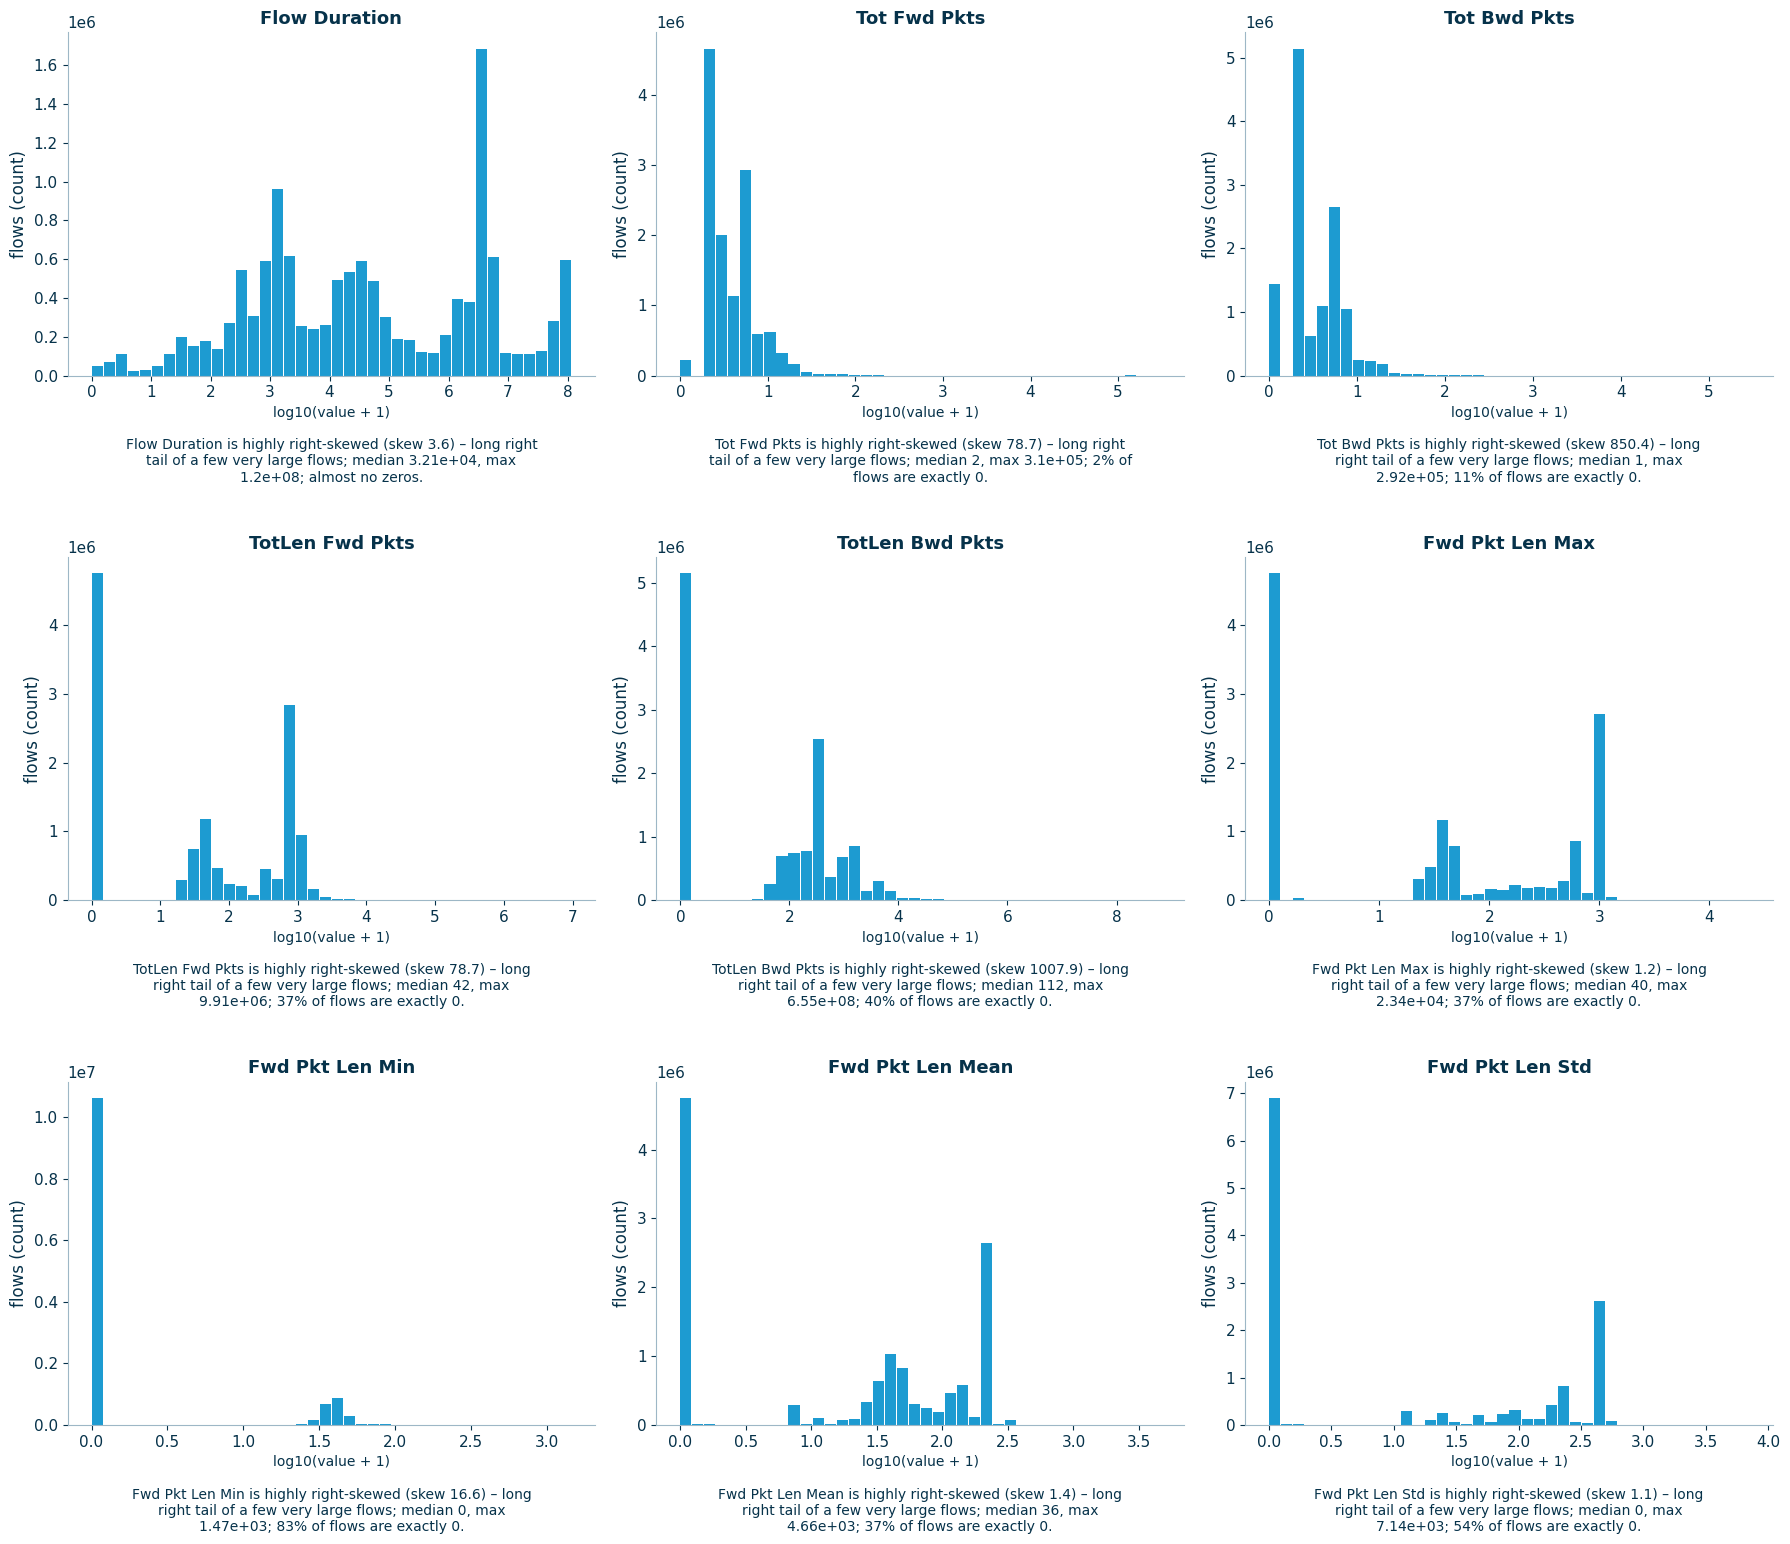

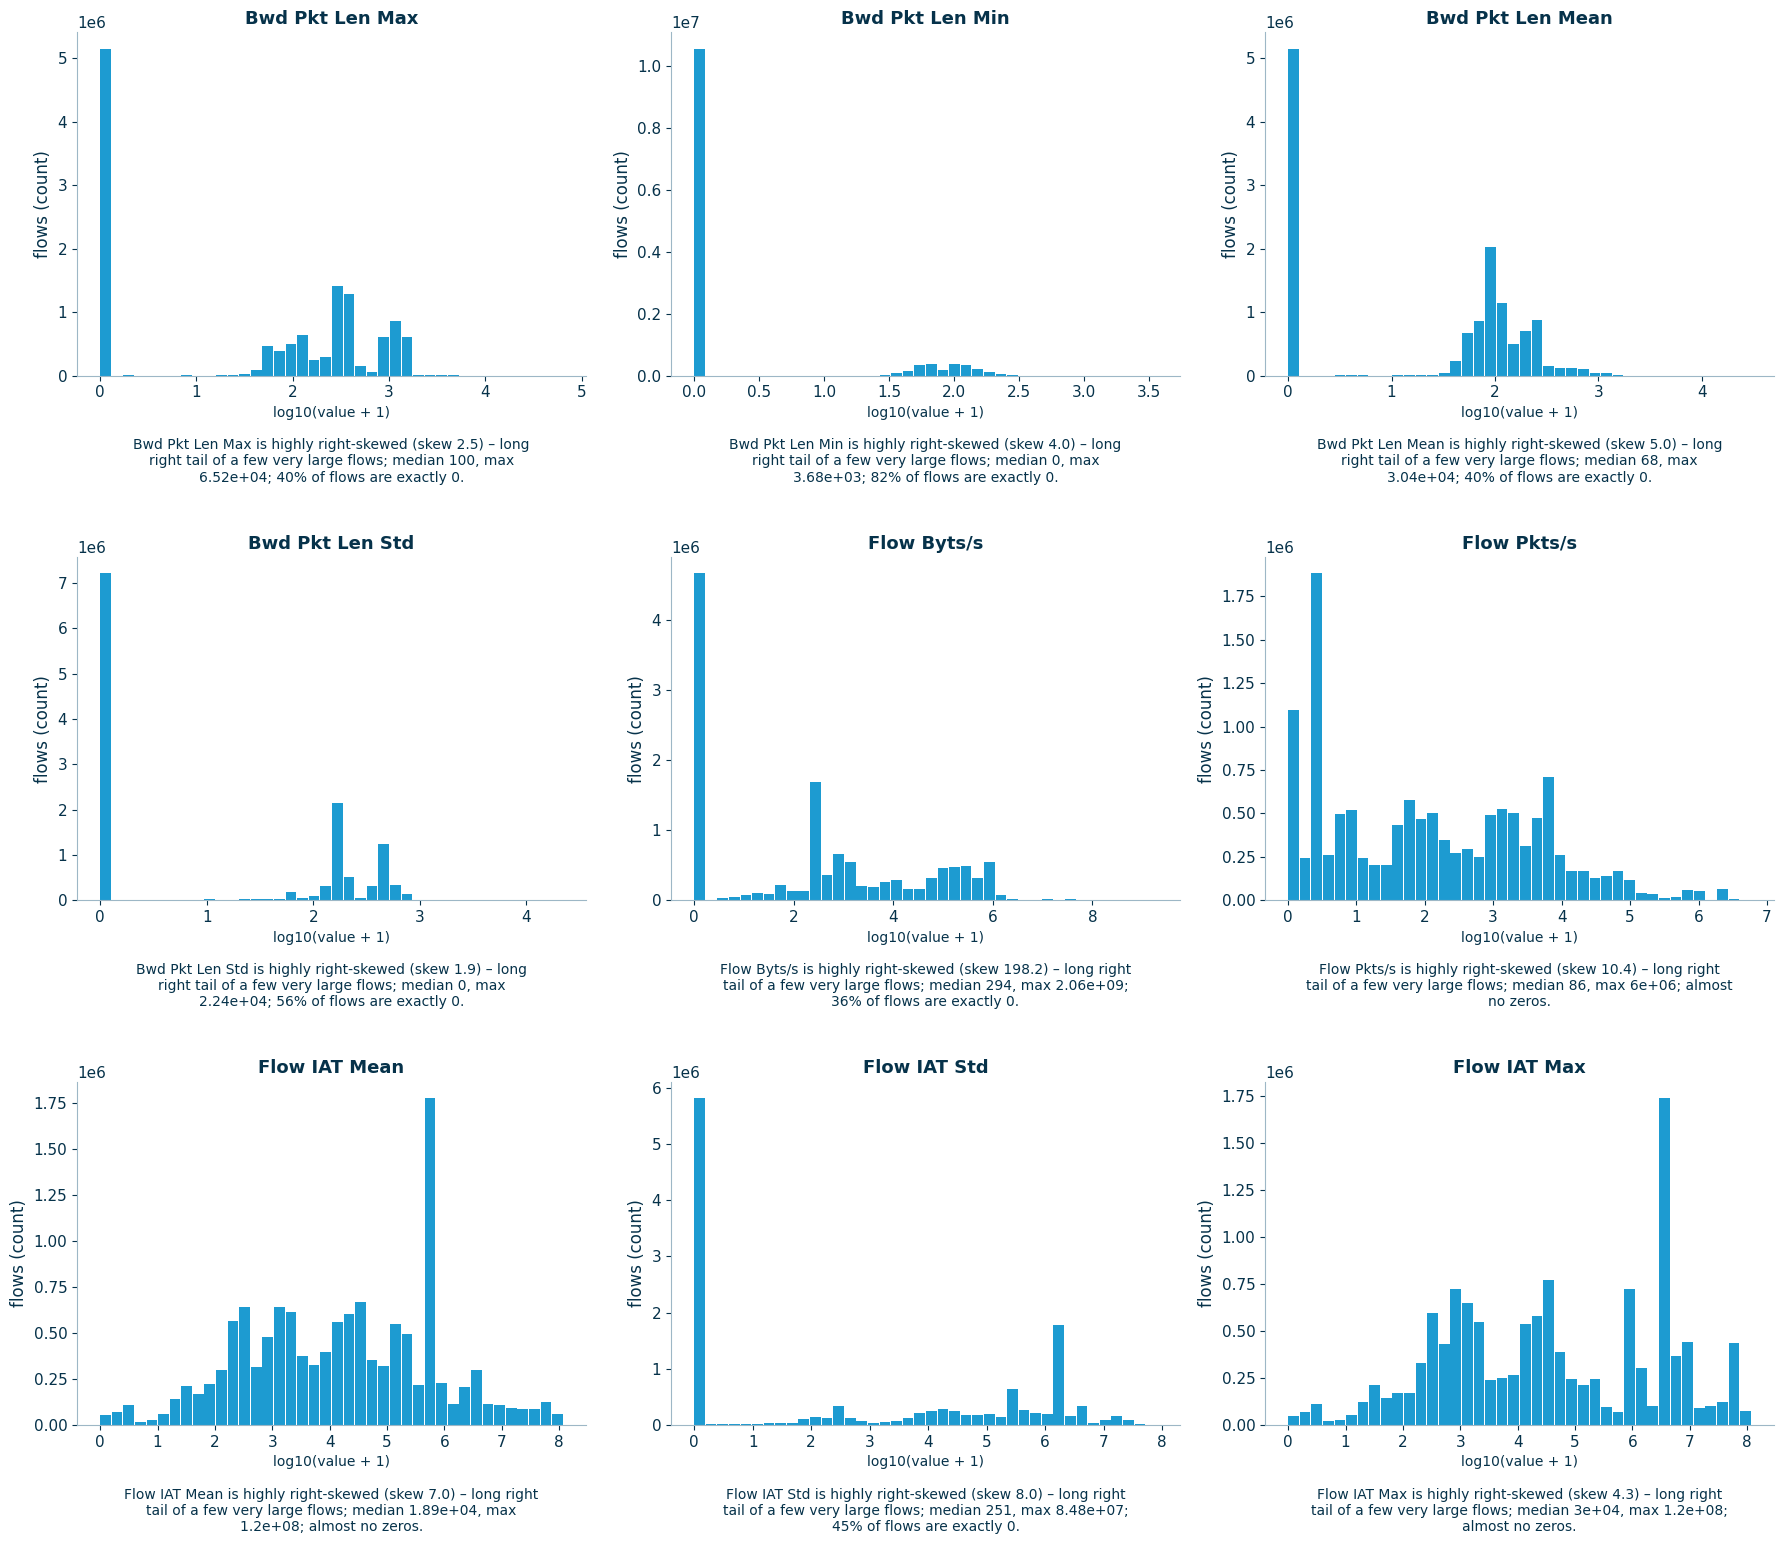

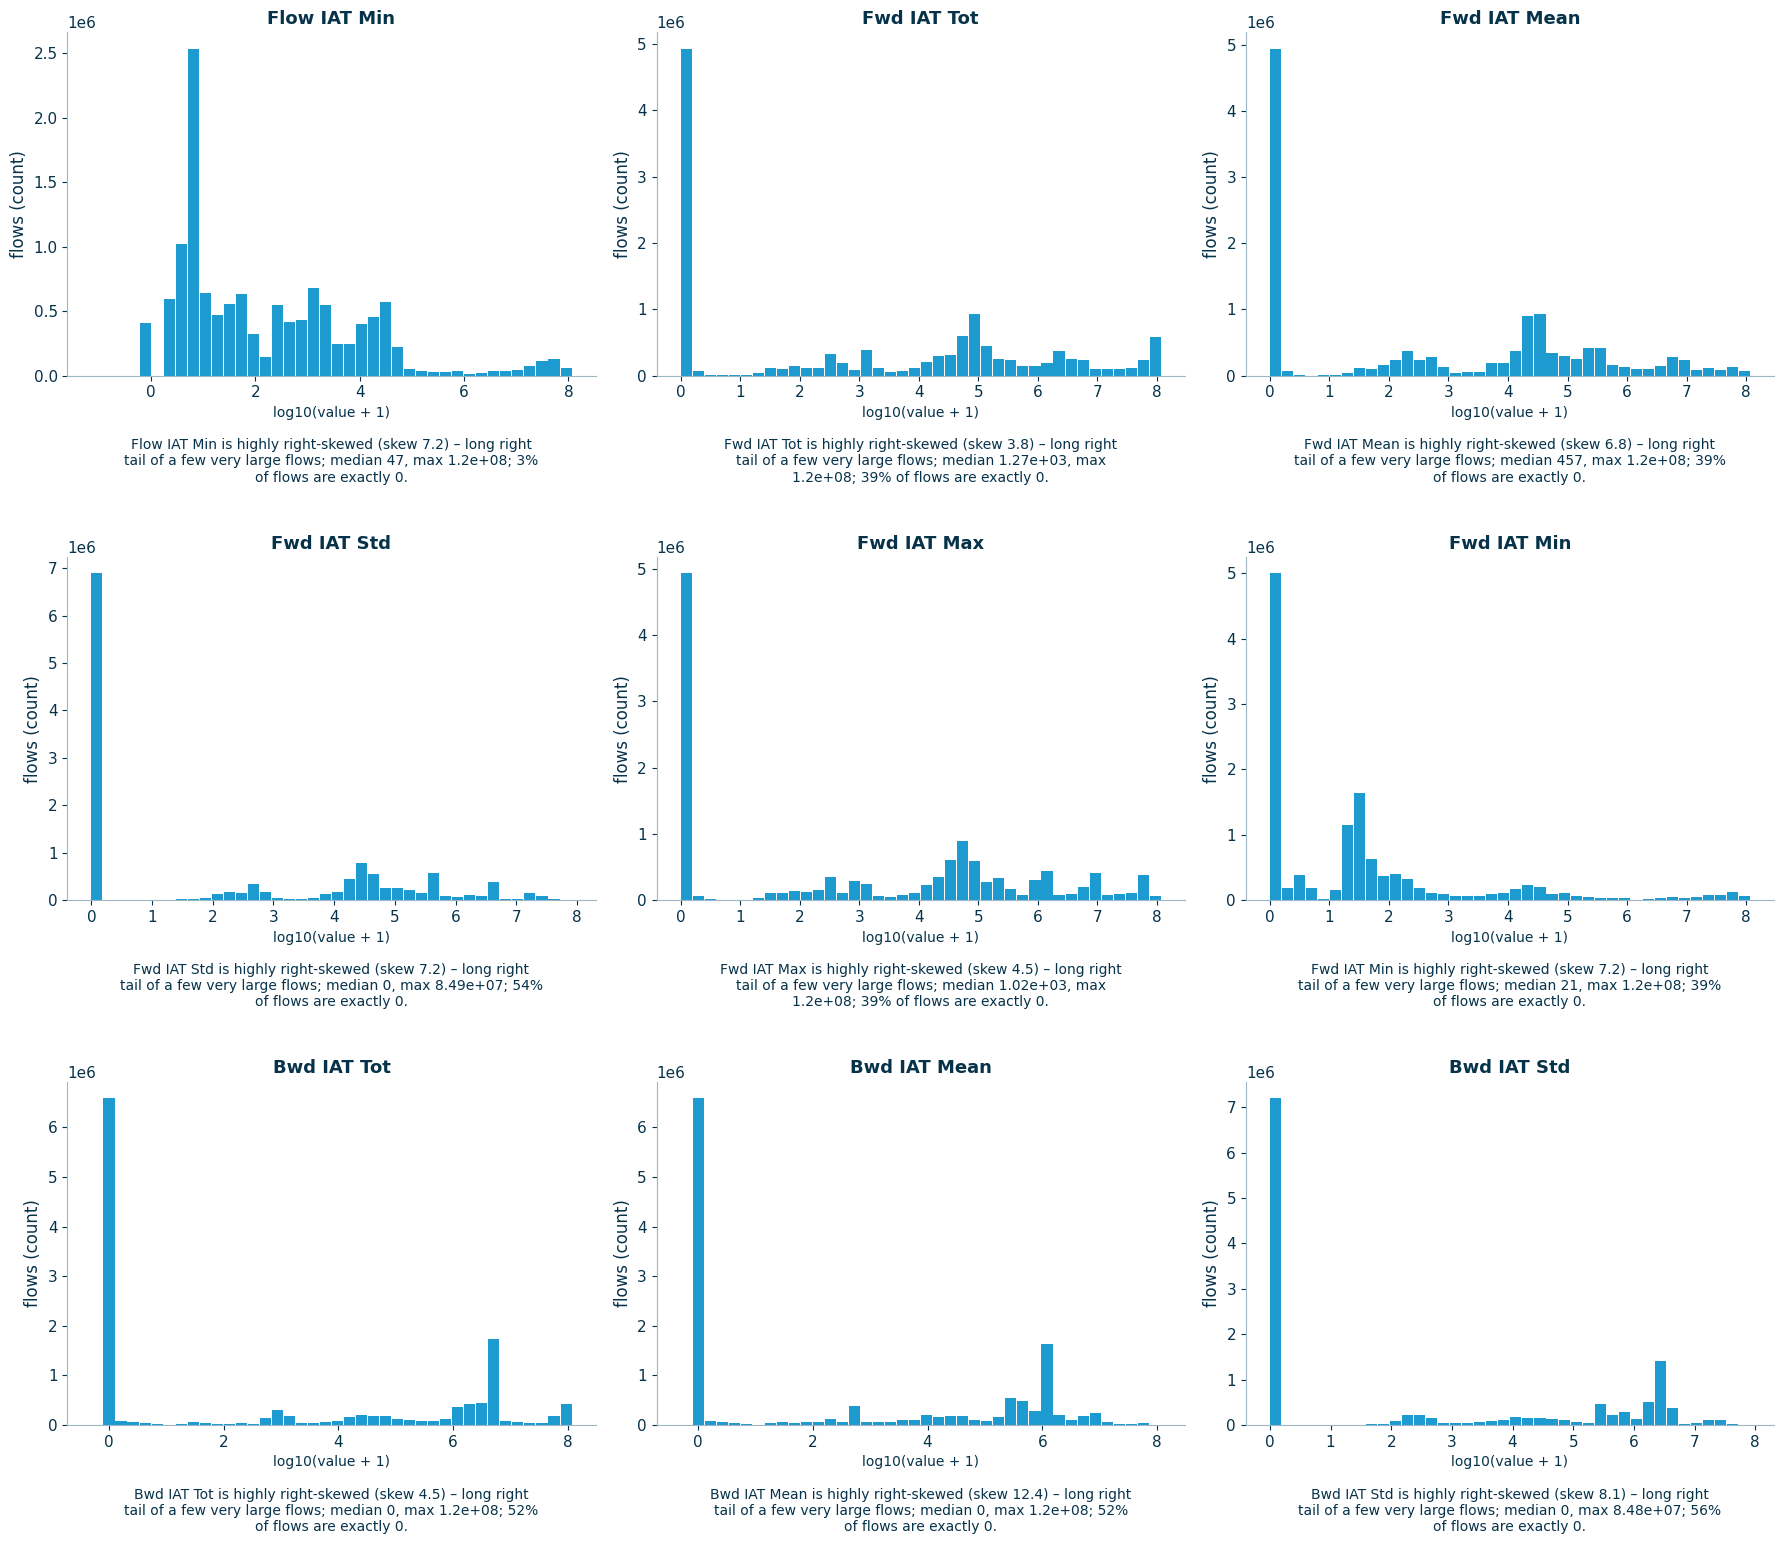

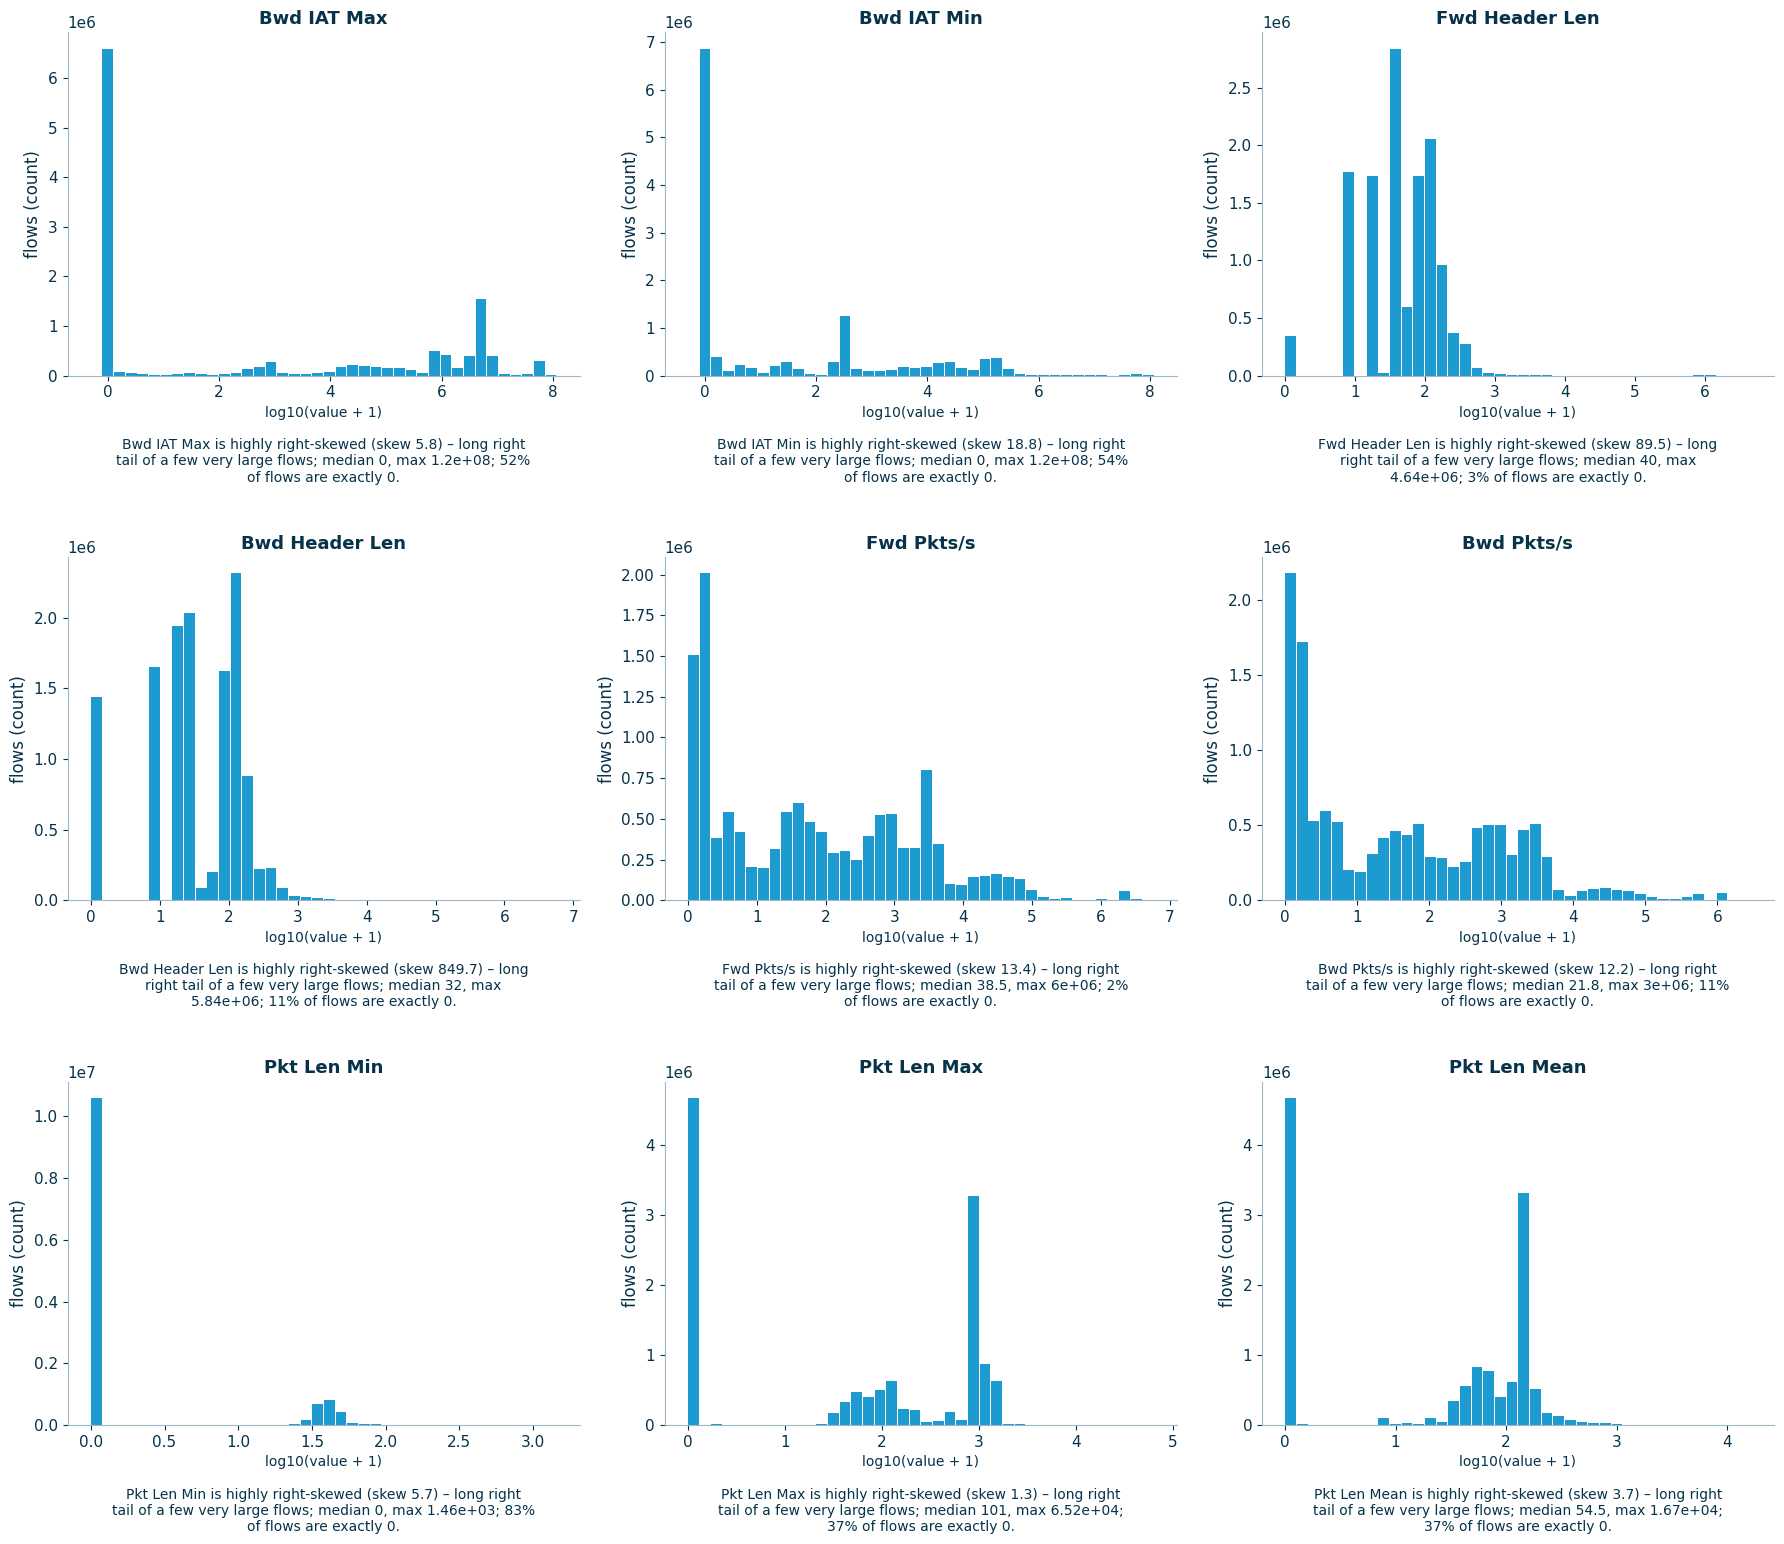

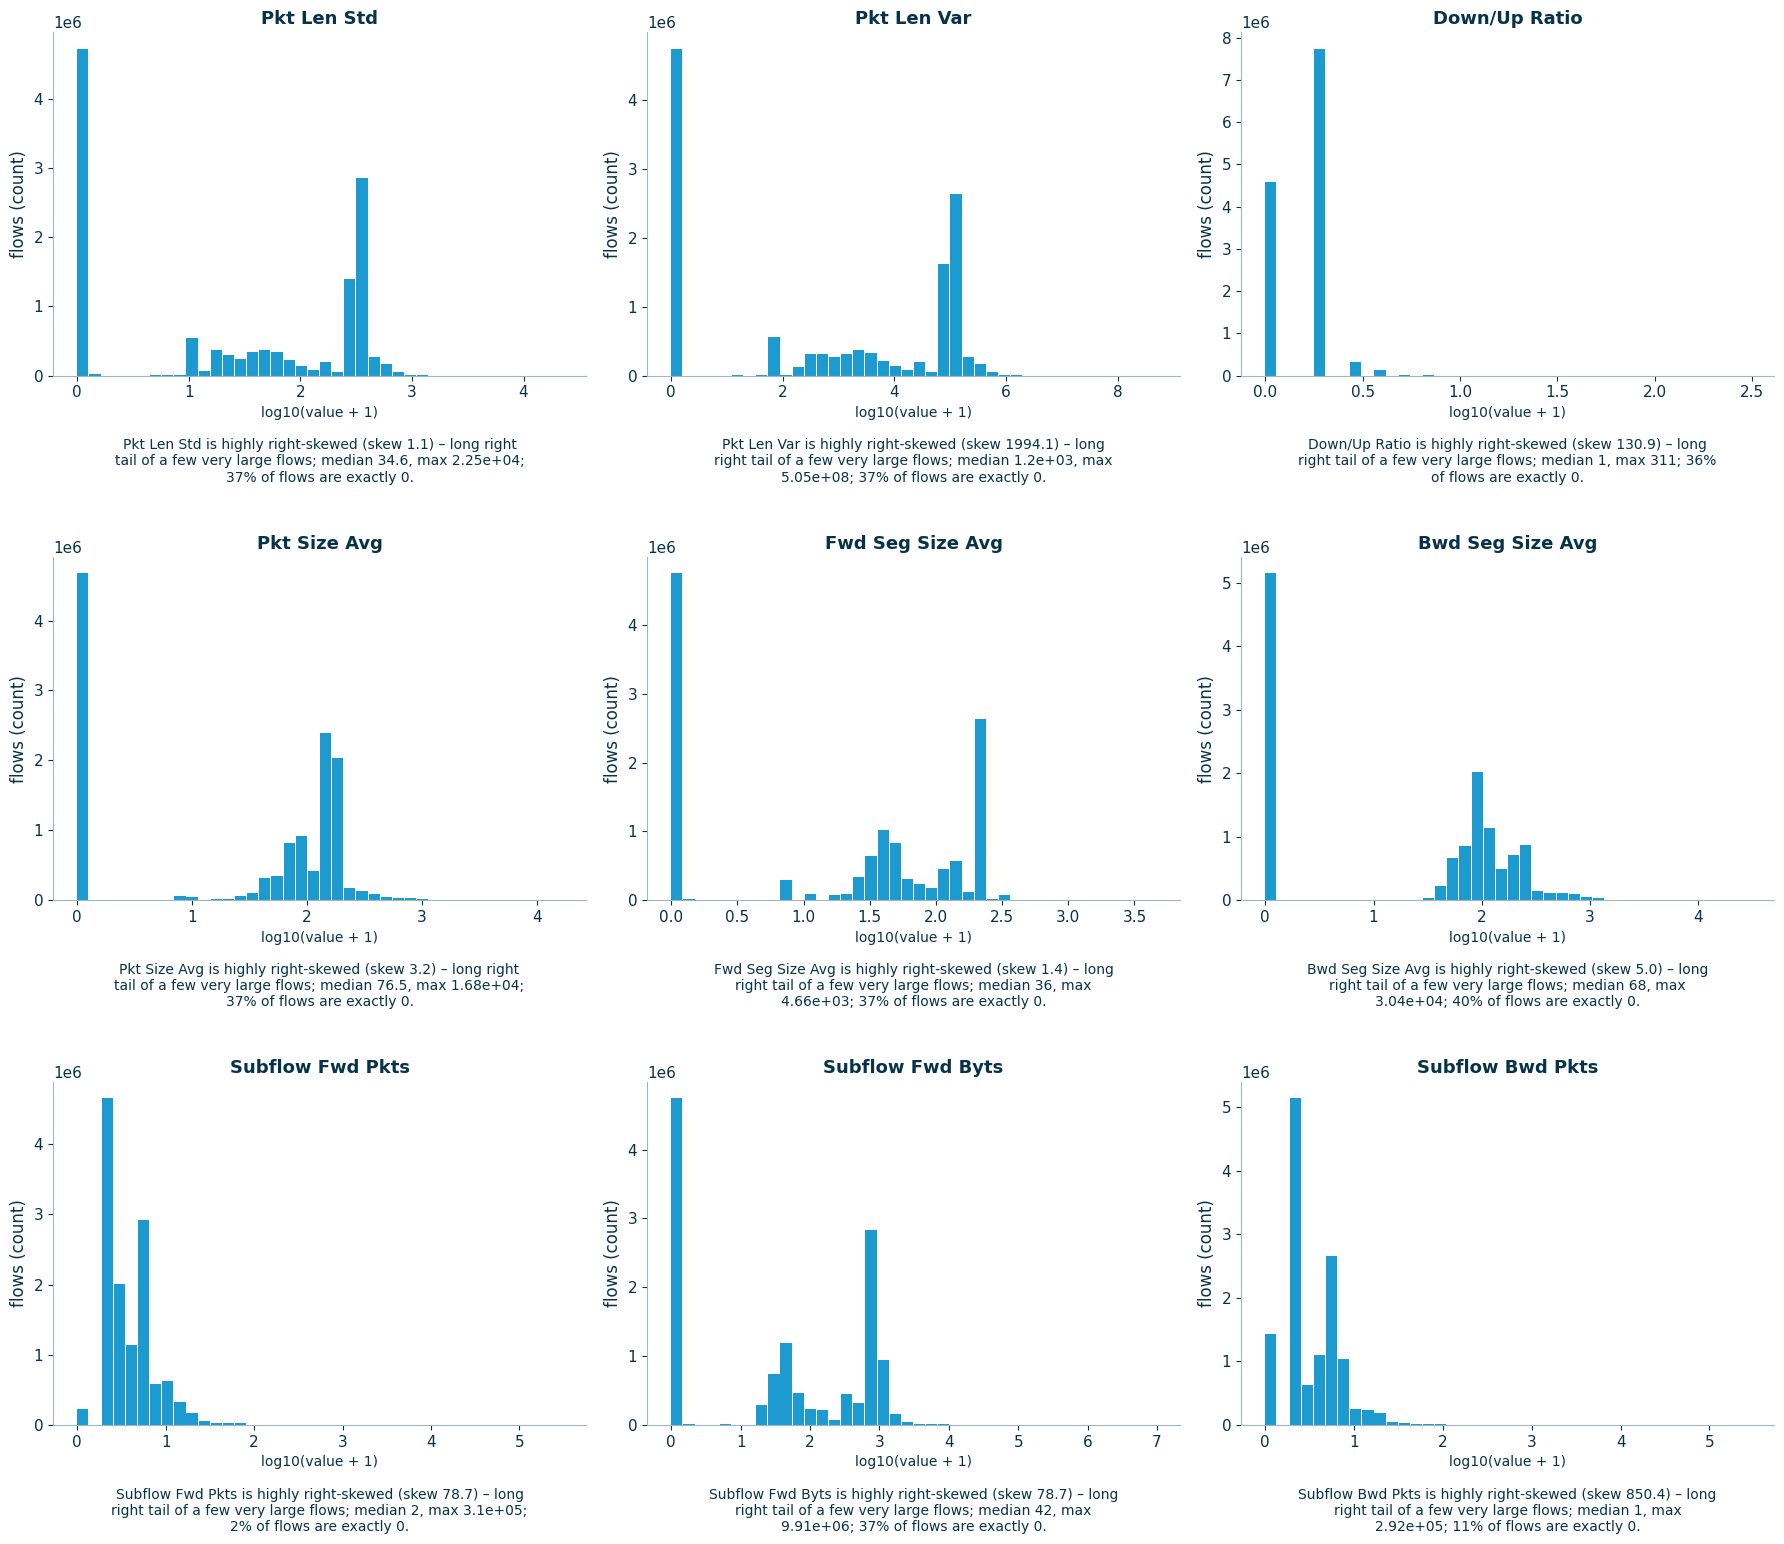

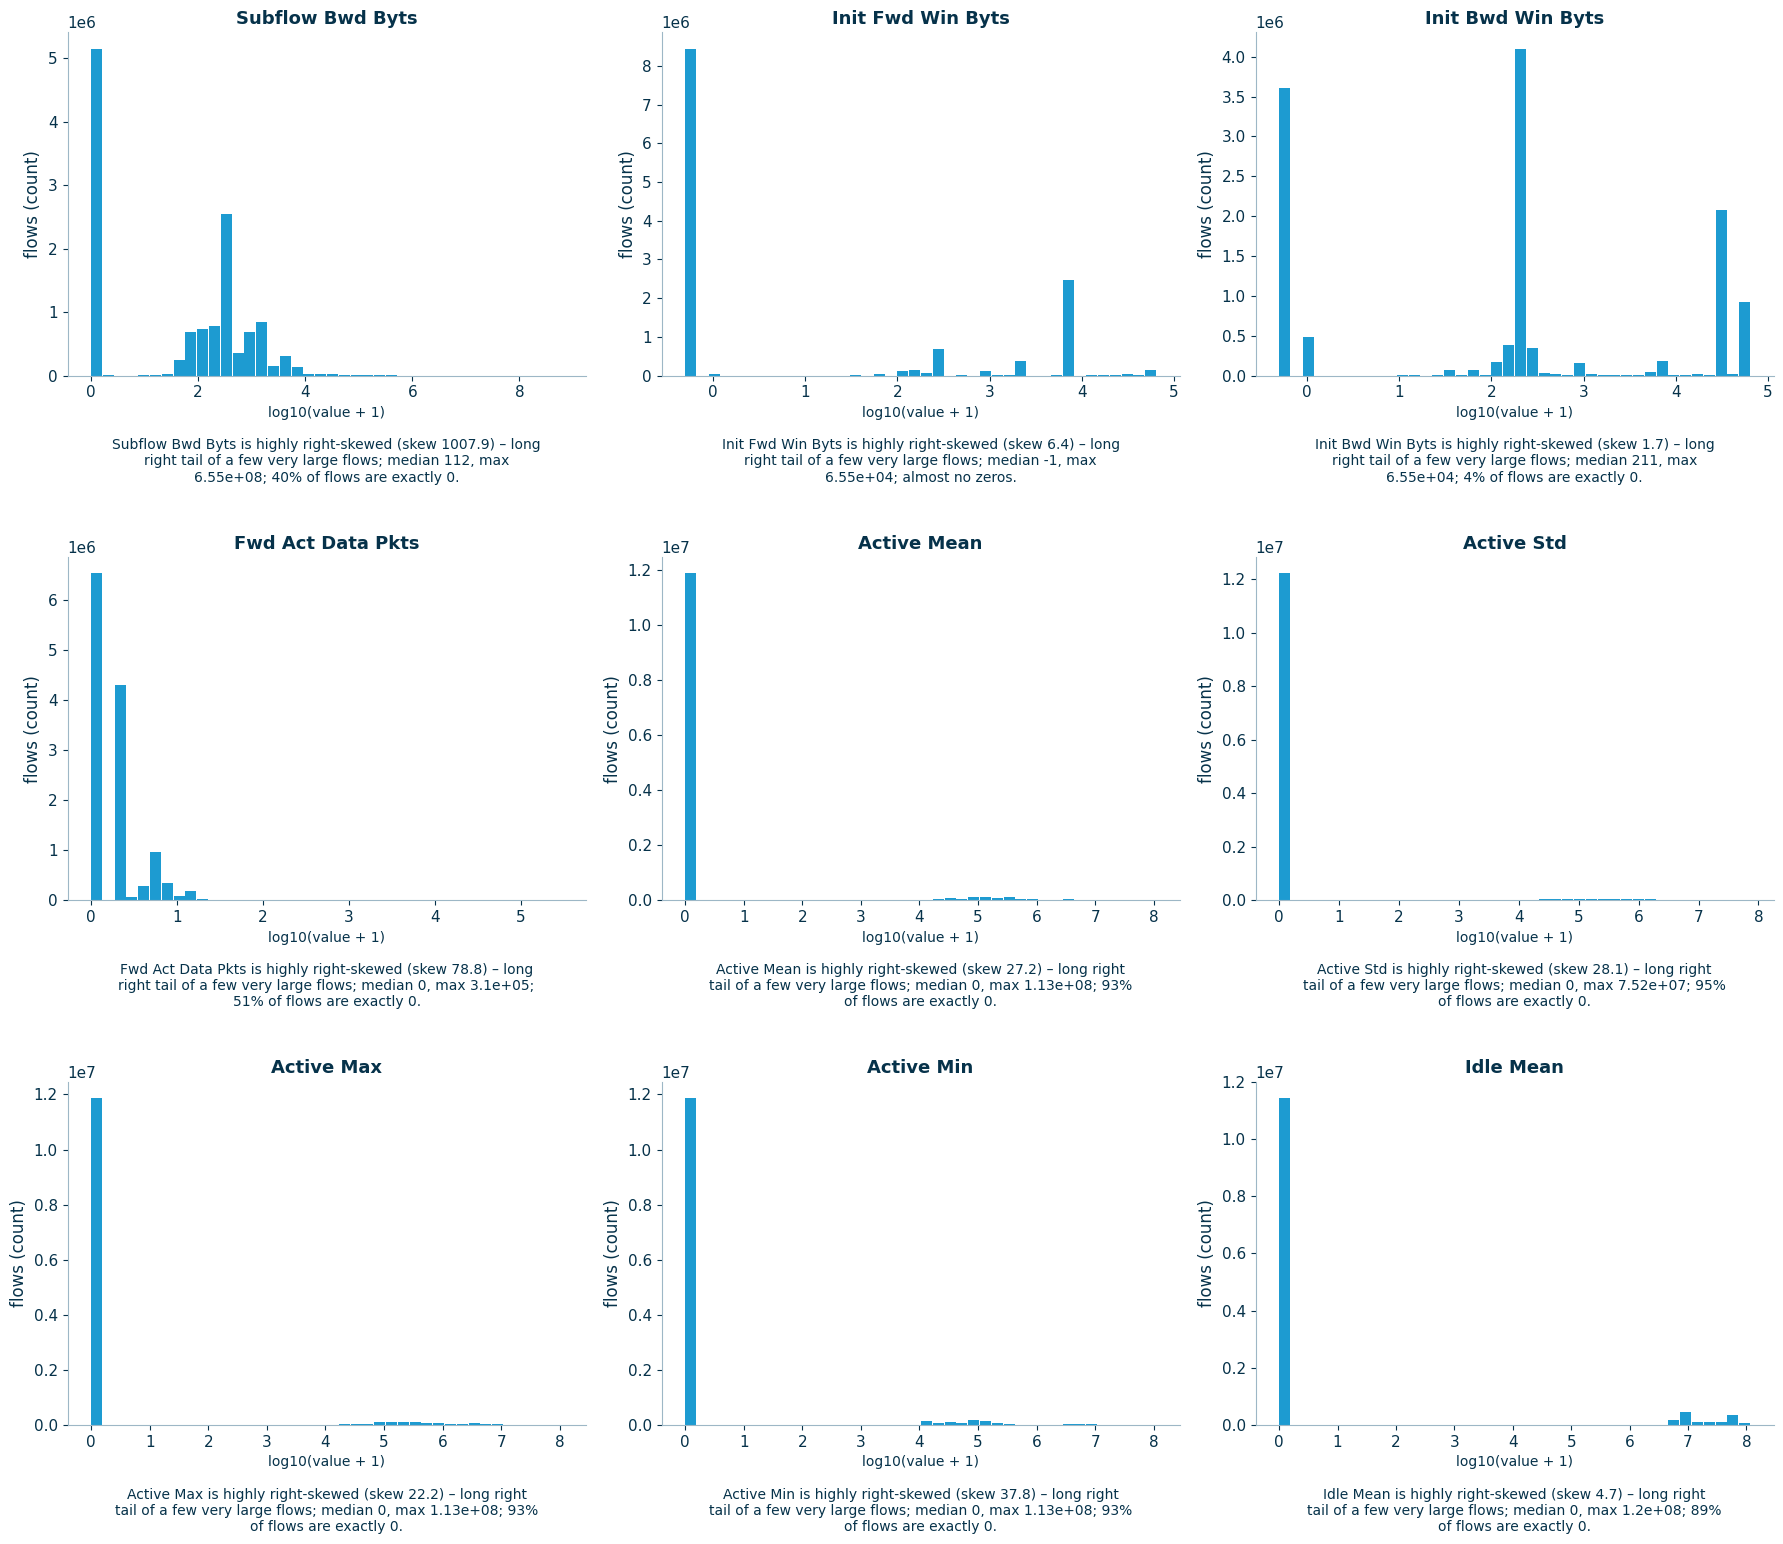

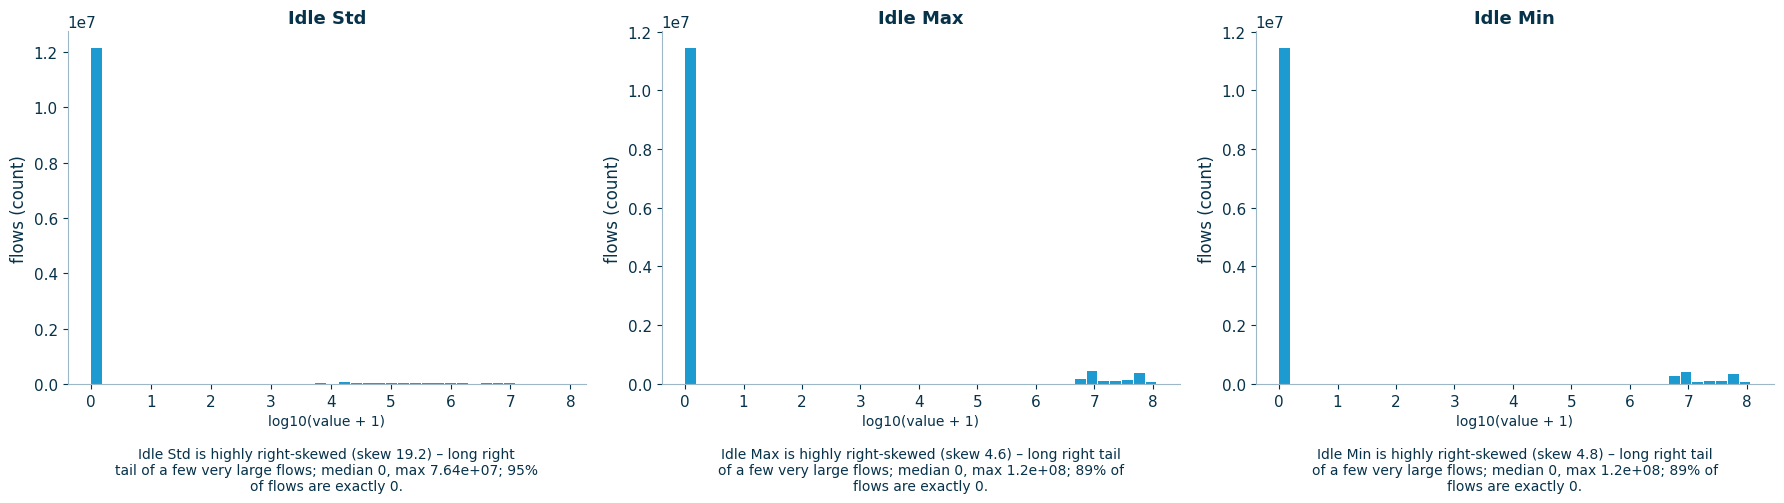

In [ ]:
N_BINS = 40
def hist_counts(c, log):
    lo, hi = st[f'{c}|min'], st[f'{c}|max']
    x = F.col(c)
    if log:
        x = F.signum(x) * F.log10(F.abs(x) + 1)
        lo = math.copysign(math.log10(abs(lo) + 1), lo); hi = math.copysign(math.log10(abs(hi) + 1), hi)
    width = (hi - lo) / N_BINS if hi > lo else 1
    b = F.greatest(F.least(F.floor((x - F.lit(lo)) / width), F.lit(N_BINS - 1)), F.lit(0))
    pdf = df_eda.filter(F.col(c).isNotNull()).groupBy(b.alias('b')).count().toPandas().sort_values('b')
    pdf['left'] = lo + pdf.b * width
    return pdf, width

def caption(c, row, log):
    z = f"{row['zero_%']:.0f}% of flows are exactly 0" if row['zero_%'] >= 1 else 'almost no zeros'
    if row['skewness'] is None or pd.isna(row['skewness']):
        return f'{c}: skew undefined (almost constant).'
    tail = ' – long right tail of a few very large flows' if row['skewness'] >= 1 else ''
    return (f"{c} is {row['shape']} (skew {row['skewness']:.1f}){tail}; median {row['median']:,.3g}, "
            f"max {row['max']:,.3g}; {z}.")

def plot_hist_page(cols, page):
    n = len(cols); ncols = 3; nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5.2 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, c in zip(axes, cols):
        row = num_summary.set_index('column').loc[c]
        log = row['skewness'] is not None and not pd.isna(row['skewness']) and abs(row['skewness']) >= 1
        pdf, w = hist_counts(c, log)
        ax.bar(pdf.left, pdf['count'], width=w * 0.92, align='edge', color=BLUE)
        ax.set_title(c, fontweight='bold')
        ax.set_ylabel('flows (count)')
        ax.set_xlabel(('log10(value + 1)' if log else 'value') + '\n\n' +
                      textwrap.fill(caption(c, row, log), 60), fontsize=10)
        ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    for ax in axes[n:]: ax.axis('off')
    fig.tight_layout(h_pad=3)
    fig.savefig(f'{FIG_DIR}/t7_hist_page{page}.png', dpi=150, bbox_inches='tight')
    plt.show()

for i in range(0, len(CONT_COLS), 9):
    plot_hist_page(CONT_COLS[i:i + 9], i // 9 + 1)

### 7.2 Bar charts of categorical columns with fewer than 30 levels

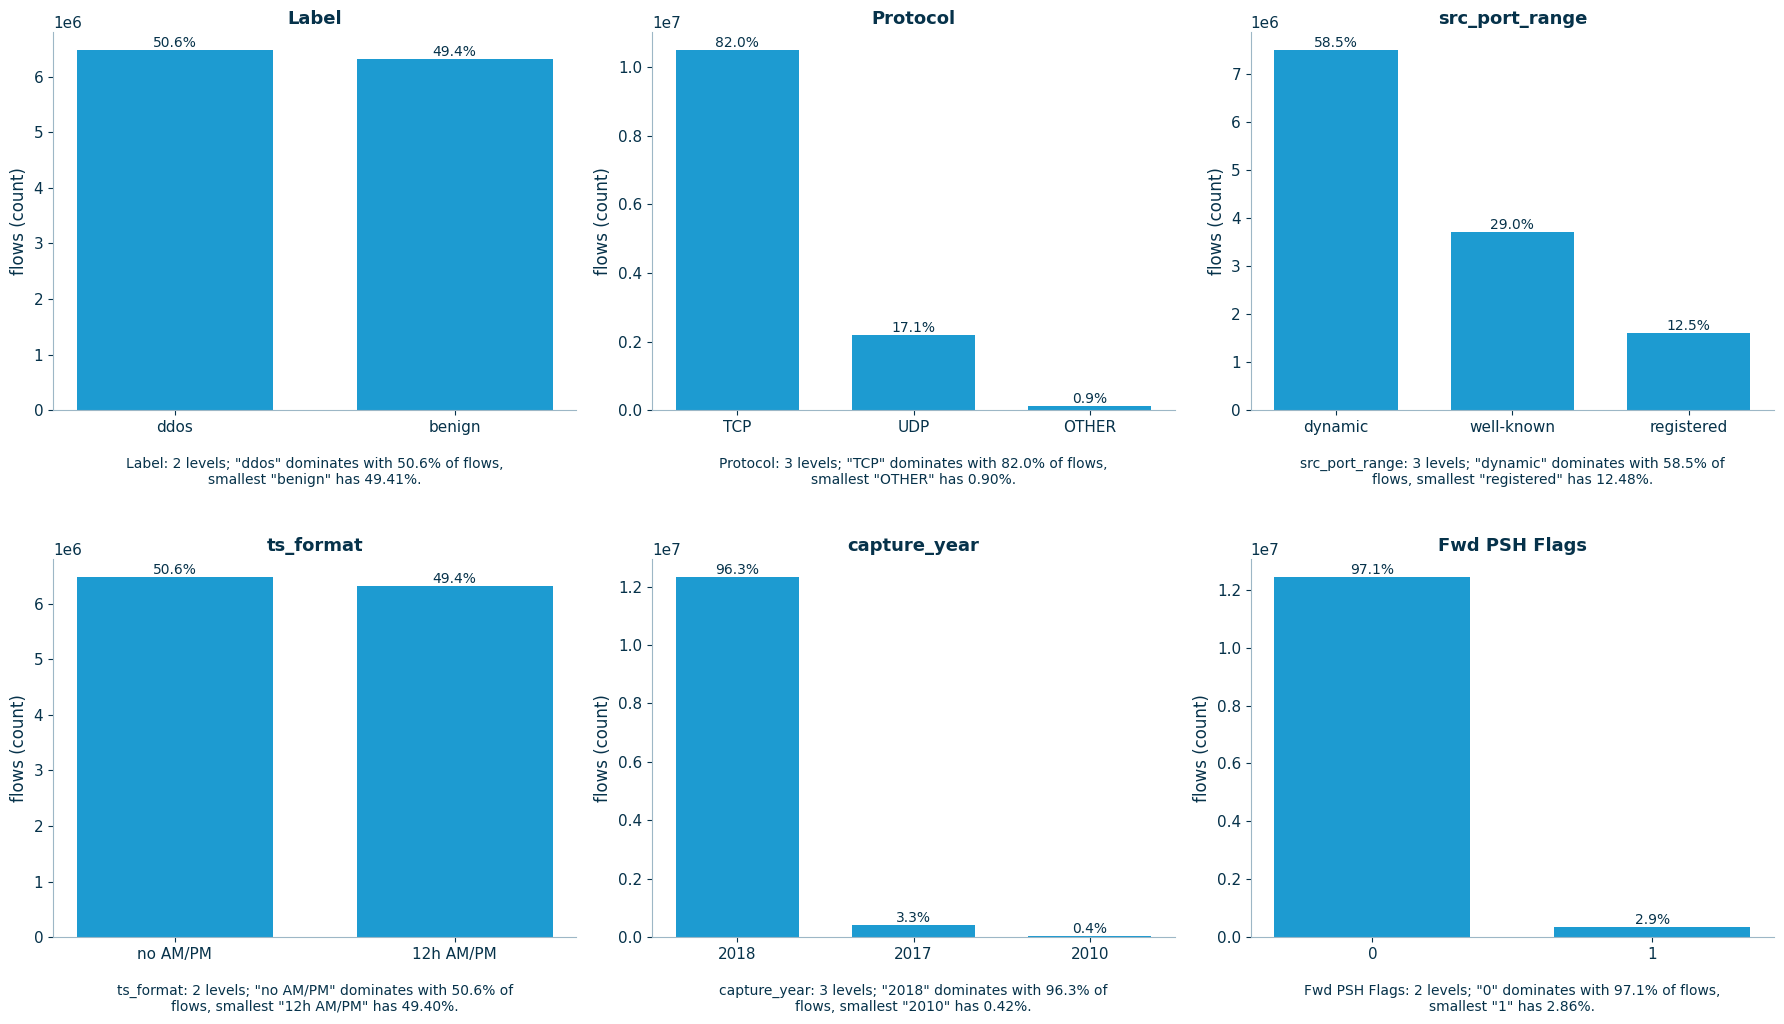

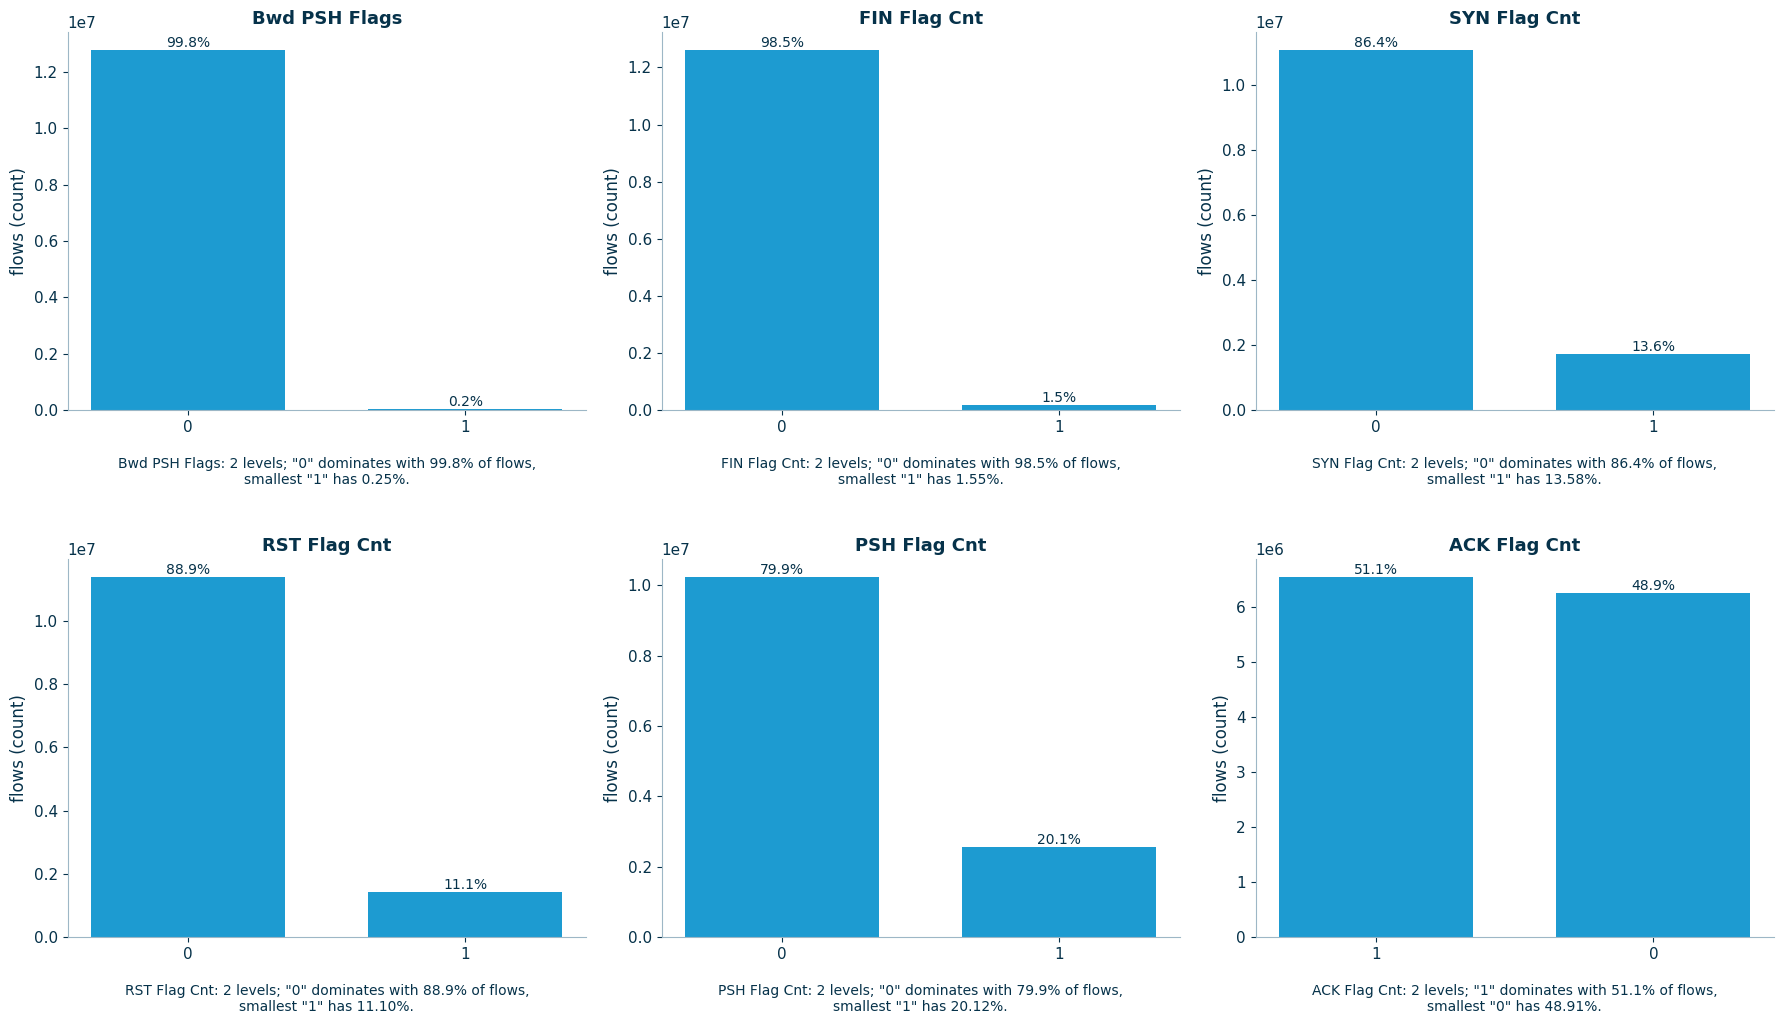

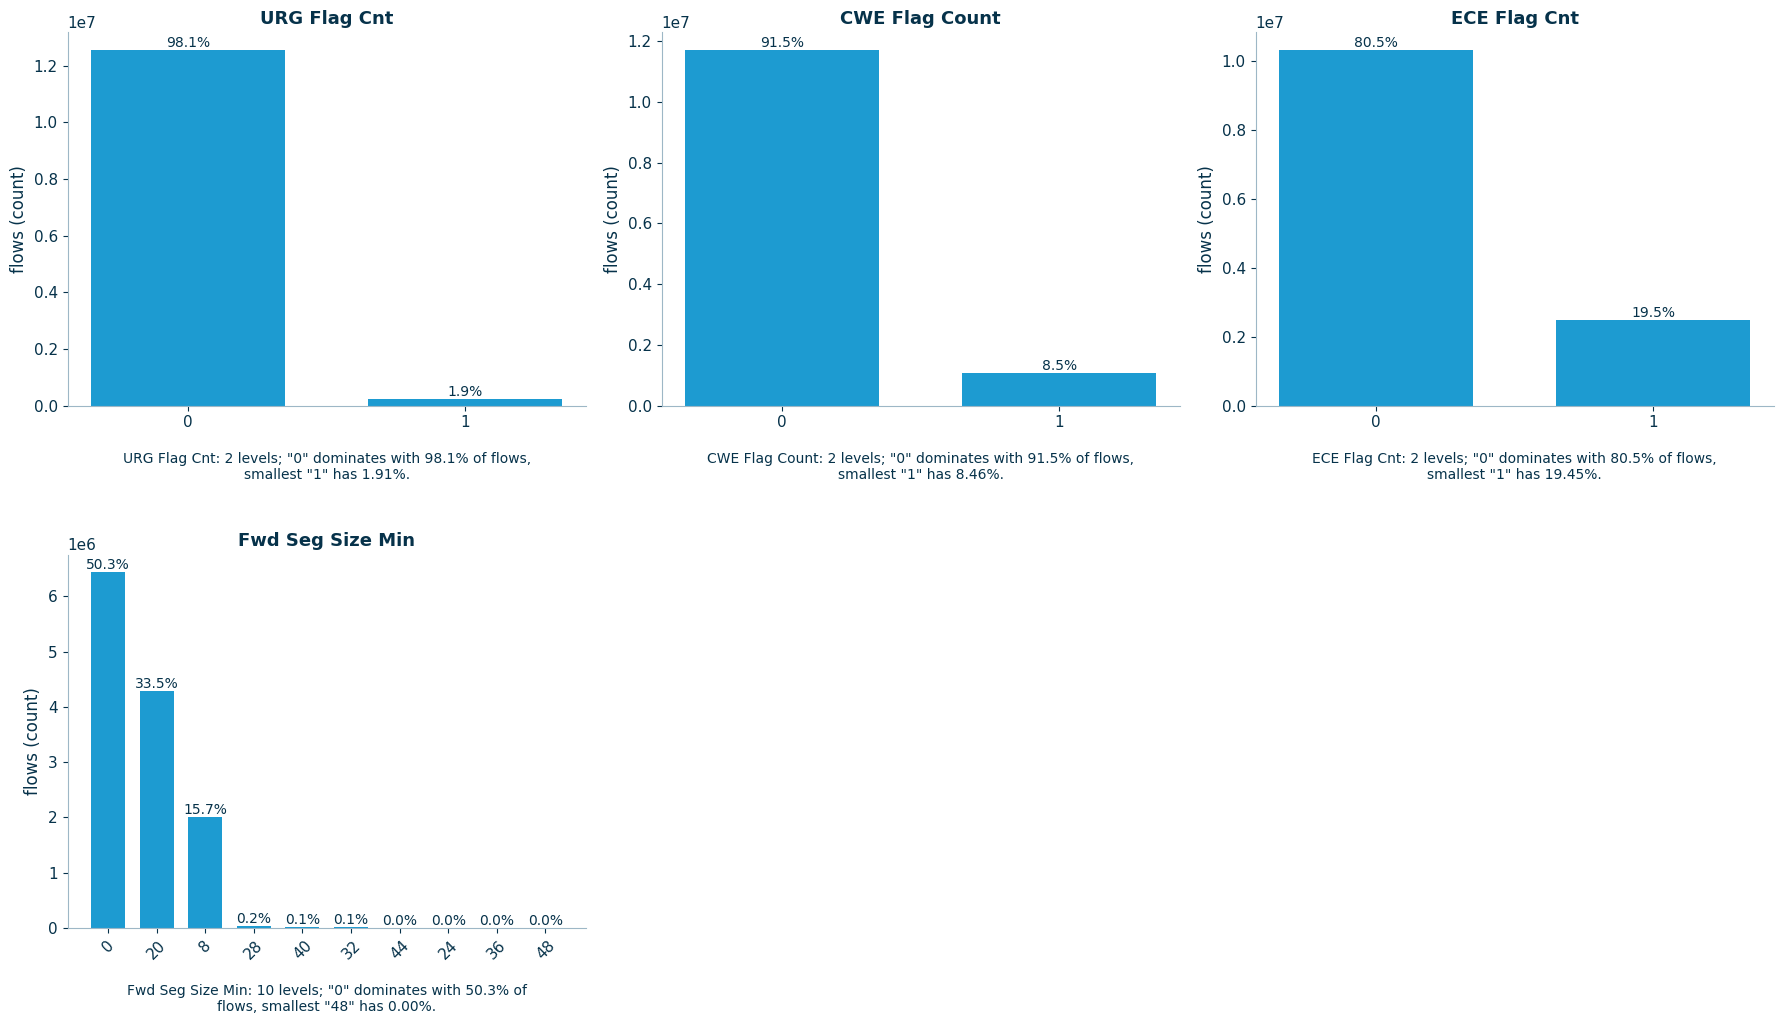

Table saved: tables/t7_bar_captions.csv  (16 rows)


column,caption
Label,"Label: 2 levels; ""ddos"" dominates with 50.6% of flows, smallest ""benign"" has 49.41%."
Protocol,"Protocol: 3 levels; ""TCP"" dominates with 82.0% of flows, smallest ""OTHER"" has 0.90%."
src_port_range,"src_port_range: 3 levels; ""dynamic"" dominates with 58.5% of flows, smallest ""registered"" has 12.48%."
ts_format,"ts_format: 2 levels; ""no AM/PM"" dominates with 50.6% of flows, smallest ""12h AM/PM"" has 49.40%."
capture_year,"capture_year: 3 levels; ""2018"" dominates with 96.3% of flows, smallest ""2010"" has 0.42%."
Fwd PSH Flags,"Fwd PSH Flags: 2 levels; ""0"" dominates with 97.1% of flows, smallest ""1"" has 2.86%."
Bwd PSH Flags,"Bwd PSH Flags: 2 levels; ""0"" dominates with 99.8% of flows, smallest ""1"" has 0.25%."
FIN Flag Cnt,"FIN Flag Cnt: 2 levels; ""0"" dominates with 98.5% of flows, smallest ""1"" has 1.55%."
SYN Flag Cnt,"SYN Flag Cnt: 2 levels; ""0"" dominates with 86.4% of flows, smallest ""1"" has 13.58%."
RST Flag Cnt,"RST Flag Cnt: 2 levels; ""0"" dominates with 88.9% of flows, smallest ""1"" has 11.10%."


In [ ]:
df_eda2 = df_eda.withColumn('capture_year', F.year('Timestamp').cast('string'))
LOW_CAT = ['Label', 'Protocol', 'src_port_range', 'ts_format', 'capture_year'] + \
          [c for c in FLAG_COLS if c not in CONSTANT] + LOWCARD_NUM

def bar_caption(c, pdf):
    top = pdf.iloc[0]
    return (f'{c}: {len(pdf)} levels; "{top.level}" dominates with {top.pct:.1f}% of flows'
            + (f', smallest "{pdf.iloc[-1].level}" has {pdf.iloc[-1].pct:.2f}%.' if len(pdf) > 1 else '.'))

bar_captions = []
for i in range(0, len(LOW_CAT), 6):
    cols = LOW_CAT[i:i + 6]
    fig, axes = plt.subplots(math.ceil(len(cols) / 3), 3, figsize=(18, 5.2 * math.ceil(len(cols) / 3)))
    axes = np.atleast_1d(axes).ravel()
    for ax, c in zip(axes, cols):
        pdf = (df_eda2.groupBy(F.col(c).cast('string').alias('level')).count()
               .toPandas().sort_values('count', ascending=False))
        pdf['pct'] = pdf['count'] / pdf['count'].sum() * 100
        ax.bar(pdf.level.astype(str), pdf['count'], color=BLUE, width=0.7)
        for x, (cnt, p) in enumerate(zip(pdf['count'], pdf.pct)):
            ax.text(x, cnt, f'{p:.1f}%', ha='center', va='bottom', fontsize=10, color=NAVY)
        ax.set_title(c, fontweight='bold'); ax.set_ylabel('flows (count)')
        cap = bar_caption(c, pdf); bar_captions.append({'column': c, 'caption': cap})
        ax.set_xlabel('\n' + textwrap.fill(cap, 60), fontsize=10)
        ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
        ax.tick_params(axis='x', rotation=0 if len(pdf) <= 6 else 45)
    for ax in axes[len(cols):]: ax.axis('off')
    fig.tight_layout(h_pad=3)
    fig.savefig(f'{FIG_DIR}/t7_bars_page{i // 6 + 1}.png', dpi=150, bbox_inches='tight')
    plt.show()
show(pd.DataFrame(bar_captions), 't7_bar_captions')

### 7.3 High-cardinality columns – top 20 values and their coverage
For each column we plot the 20 most frequent values and state how much of the file they cover. We also report how much the
**top 20 % of distinct values** cover, which decides whether "everything else → OTHER" is safe.

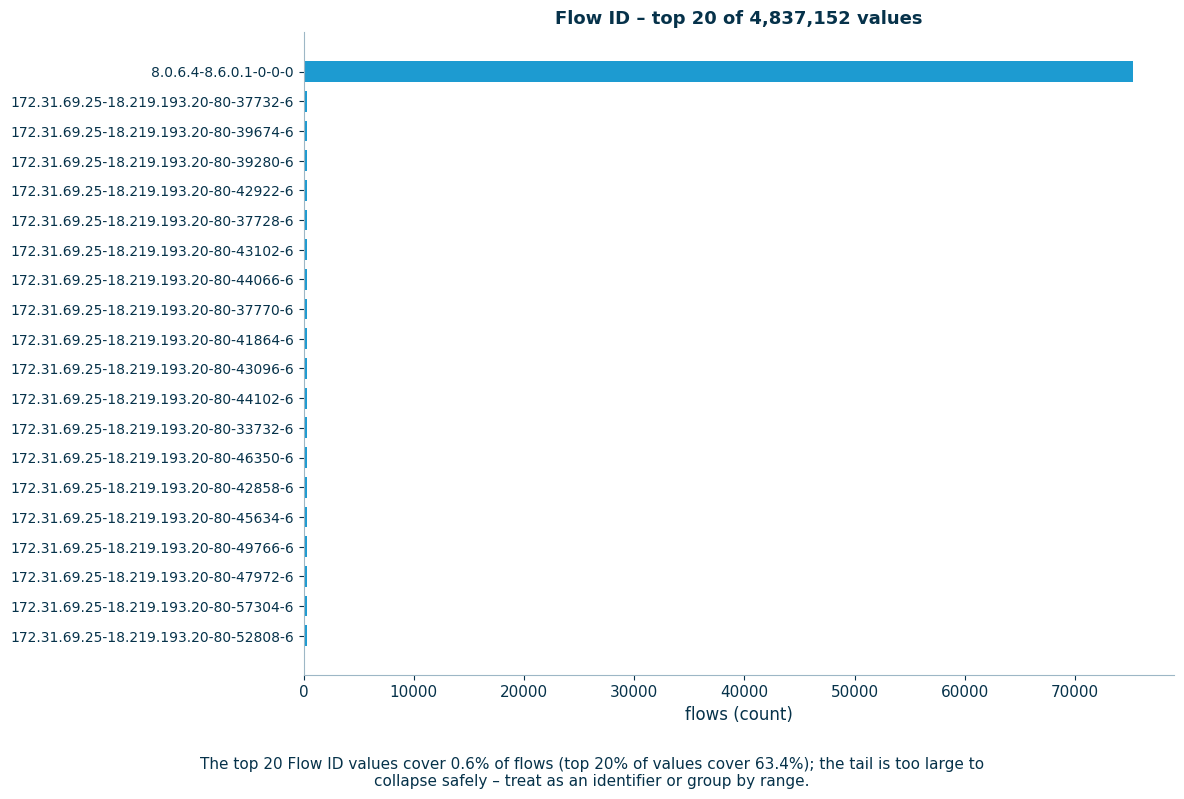

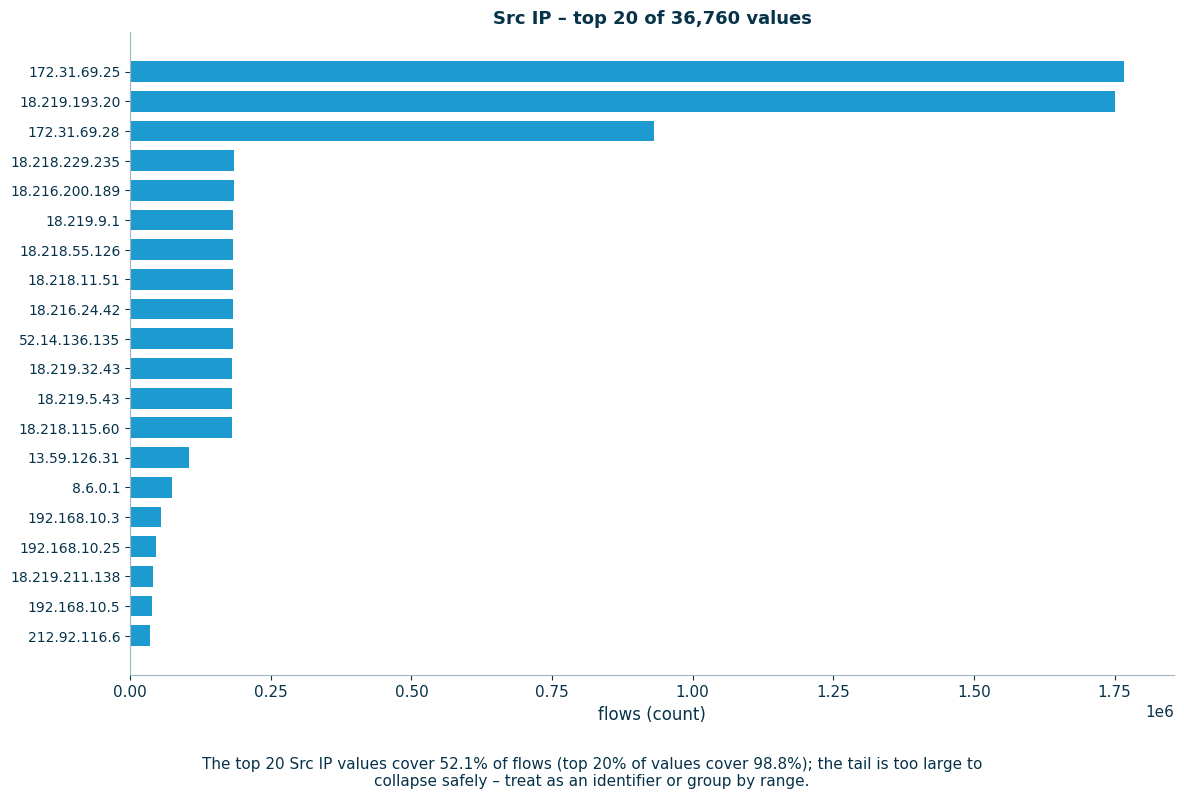

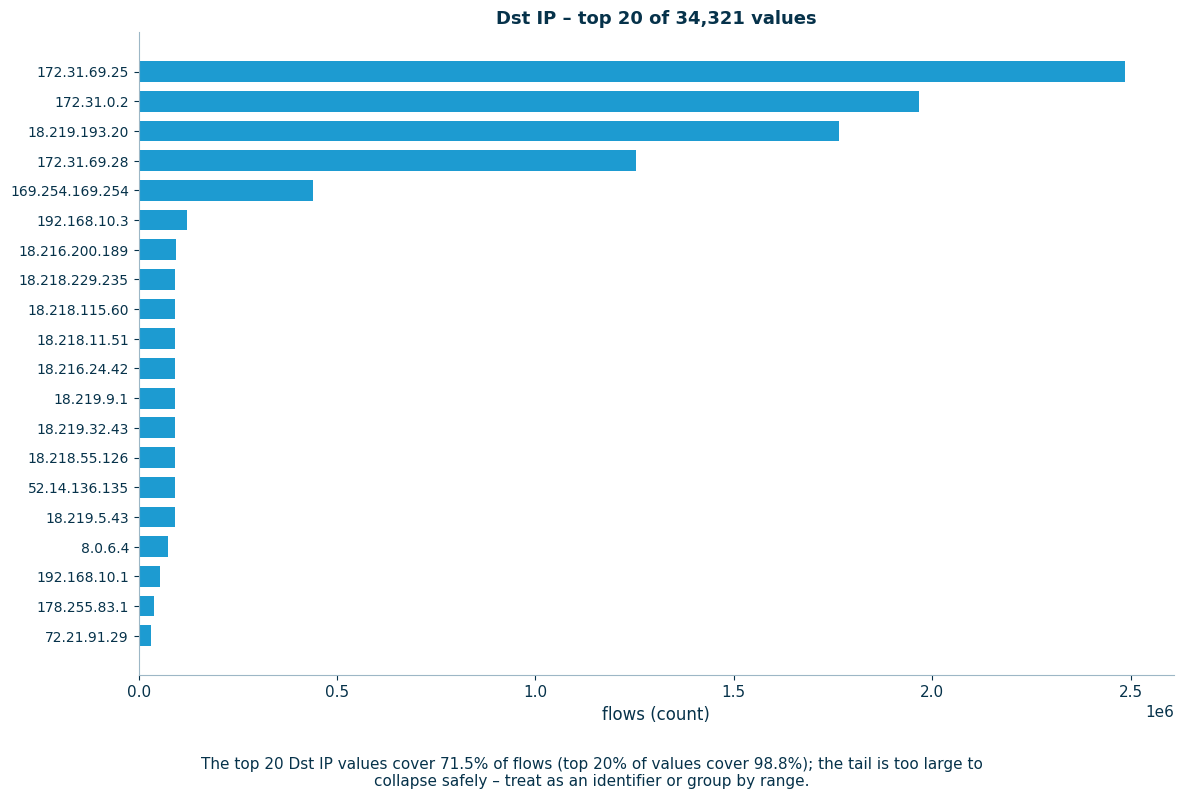

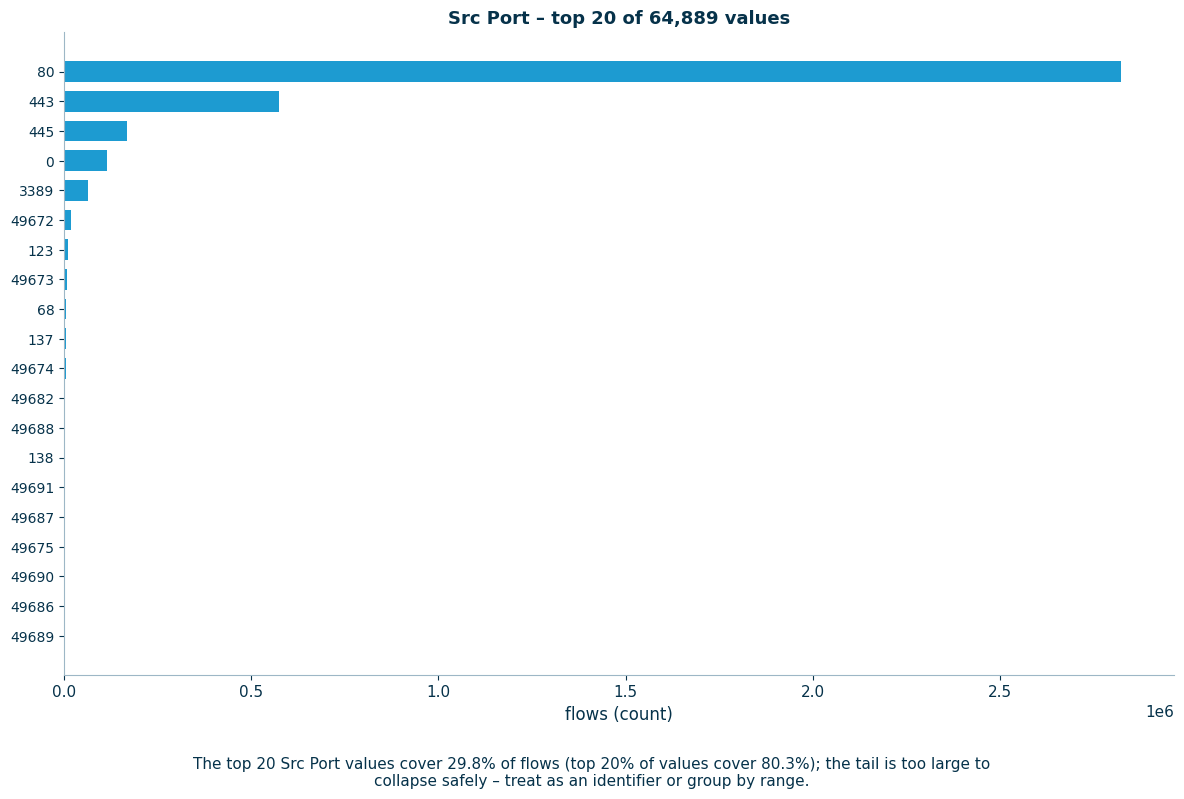

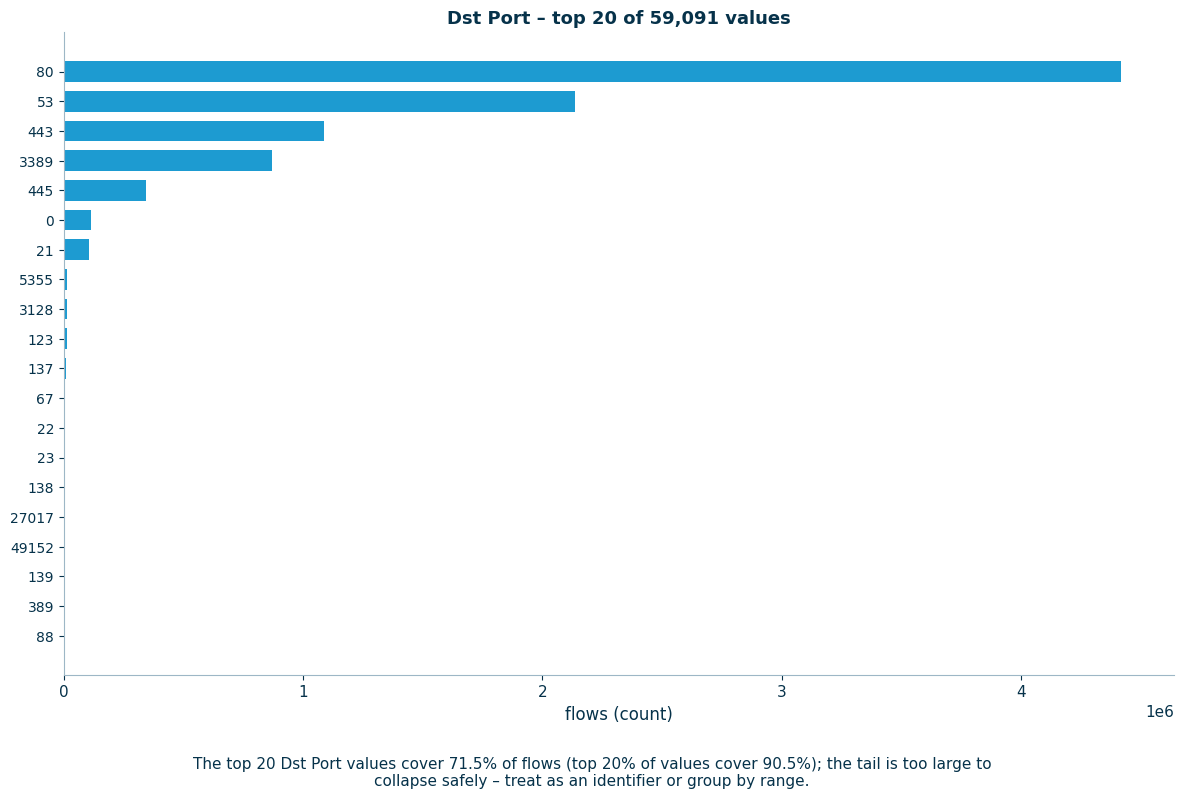

Table saved: tables/t7_high_cardinality_coverage.csv  (5 rows)


column,distinct_values,top_20_cover_%,top_20%_of_values,top_20%_cover_%
Flow ID,"4,837,152",0.6391,"967,430",63.3526
Src IP,"36,760",52.1285,"7,352",98.7536
Dst IP,"34,321",71.5285,"6,864",98.7704
Src Port,"64,889",29.8070,"12,977",80.3389
Dst Port,"59,091",71.5314,"11,818",90.4600


In [ ]:
HIGH_CAT = ['Flow ID', 'Src IP', 'Dst IP', 'Src Port', 'Dst Port']
cov_rows = []
for c in HIGH_CAT:
    vc = df_eda.groupBy(c).count()
    n_levels = vc.count()
    k20pct = max(1, int(n_levels * 0.20))
    w = Window.orderBy(F.desc('count'))
    ranked = vc.withColumn('rk', F.row_number().over(w))
    cov = ranked.agg(F.sum(F.when(F.col('rk') <= 20, F.col('count'))).alias('top20'),
                     F.sum(F.when(F.col('rk') <= k20pct, F.col('count'))).alias('top20pct'),
                     F.sum('count').alias('total')).first()
    top = ranked.filter('rk <= 20').orderBy('rk').toPandas()
    p20, p20pct = cov['top20'] / cov['total'] * 100, cov['top20pct'] / cov['total'] * 100
    cov_rows.append({'column': c, 'distinct_values': n_levels, 'top_20_cover_%': p20,
                     'top_20%_of_values': k20pct, 'top_20%_cover_%': p20pct})

    fig, ax = plt.subplots(figsize=(12, 7.5))
    ax.barh(top[c].astype(str)[::-1], top['count'][::-1], color=BLUE, height=0.7)
    ax.set_title(f'{c} – top 20 of {n_levels:,} values', fontweight='bold')
    ax.set_xlabel('flows (count)'); ax.tick_params(axis='y', labelsize=10)
    cap = (f'The top 20 {c} values cover {p20:.1f}% of flows (top 20% of values cover {p20pct:.1f}%); '
           + ('the rest can be grouped as OTHER.' if p20 >= 80 else 'the tail is too large to collapse safely – treat as an identifier or group by range.'))
    fig.text(0.5, -0.02, textwrap.fill(cap, 110), ha='center', va='top', fontsize=11, color=NAVY)
    fig.tight_layout()
    safe = re.sub(r'\W+', '_', c).lower()
    fig.savefig(f'{FIG_DIR}/t7_top20_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()

show(pd.DataFrame(cov_rows), 't7_high_cardinality_coverage')

---
# TASK 8 – Cleaning Decisions Log
One row per decision, written as we went through Tasks 1–7 (including "no action" decisions).
The log is saved as CSV and as a formatted Excel sheet for Section 3 of the report.

In [ ]:
log = pd.DataFrame(DECISIONS)
log.insert(0, 'id', range(1, len(log) + 1))
log['rows affected %'] = log['rows affected'] / ROW_COUNT * 100
show(log, 't8_cleaning_decisions_log', max_rows=200)

# formatted Excel copy (blue header, banded rows)
!pip install openpyxl -q
from openpyxl.styles import PatternFill, Font, Border, Side, Alignment
xlsx = f'{TABLE_DIR}/t8_cleaning_decisions_log.xlsx'
with pd.ExcelWriter(xlsx, engine='openpyxl') as xw:
    log.to_excel(xw, index=False, sheet_name='Decisions')
    ws = xw.sheets['Decisions']
    thin = Side(style='thin', color='9DB7C6')
    for j, col in enumerate(log.columns, 1):
        ws.column_dimensions[ws.cell(1, j).column_letter].width = {'reason': 60, 'issue found': 45,
                                                                    'decision taken': 45, 'column(s)': 30}.get(col, 14)
    for i, row in enumerate(ws.iter_rows(), 1):
        for cell in row:
            cell.border = Border(top=thin, bottom=thin, left=thin, right=thin)
            cell.alignment = Alignment(wrap_text=True, vertical='top')
            if i == 1:
                cell.fill = PatternFill('solid', fgColor='1D9BD1'); cell.font = Font(bold=True, color='FFFFFF')
            else:
                cell.font = Font(color='06324A')
                if i % 2 == 0: cell.fill = PatternFill('solid', fgColor='CFE8F4')
    ws.freeze_panes = 'A2'
print('Excel log saved:', xlsx)

Table saved: tables/t8_cleaning_decisions_log.csv  (33 rows)


id,task,column(s),issue found,decision taken,reason,rows affected,rows affected %
1,T1,all columns,0 exact duplicate rows (all 85 columns),No action,Nothing is repeated when row_id is included – no failed export or double join,0,0.0000
2,T1,all except row_id,25 extra copies once the artificial row_id is ignored,Drop extra copies (keep first),"row_id is a pandas index, not data; identical flow records counted twice would bias the model towards them",25,0.0002
3,T1,row_id,"row_id is not unique (5,748,130 repeats)",Drop row_id,It is the index of the separate source files that were concatenated – it identifies nothing and restarts per file,"12,794,627",100.0000
4,T1,Flow ID + Timestamp,"6,508,624 rows share a key; 6 of them carry different Labels",Keep; exclude conflicting-label groups from training,"CICFlowMeter splits long connections into several flows in the same second, so sharing a key is normal; a key that is both ddos and Benign cannot be learnt consistently",6,0.0000
5,T2,"Src Port, Dst Port, Protocol",Codes stored as integers,Declared as String,They are labels; numeric type invites meaningless averages and scaling,0,0.0000
6,T2,"Fwd PSH Flags, Bwd PSH Flags, Fwd URG Flags, Bwd URG Flags, FIN Flag Cnt, SYN Flag Cnt, RST Flag Cnt, PSH Flag Cnt, ACK Flag Cnt, URG Flag Cnt, CWE Flag Count, ECE Flag Cnt",TCP flag indicators stored as decimals (0.0/1.0),Declared as Integer 0/1 and treated as categorical,They only take two values,0,0.0000
7,T2,"Ports, Protocol, IPs, Flow ID",Leading-zero check,No action,Codes read as String keep every character; the check shows whether any padding was already lost/present,0,0.0000
8,T2,Timestamp,"Text dates in two formats (with and without AM/PM), day-first",Parsed with both patterns into TimestampType; kept ts_format for audit,One pattern alone nulls the other half silently; text dates sort by day and cannot be subtracted,"6,474,240",50.6012
9,T2,Timestamp,"6,474,240 rows have no AM/PM and hours only 1–12",Keep the date; flag ts_ampm_missing; do not use hour-of-day for these rows,"The date part is reliable, but 01:00 could be 1 am or 1 pm – any hour feature would be half wrong","6,474,240",50.6012
10,T3,"Flow Duration, *IAT*",Negative durations / inter-arrival times,Drop rows,Physically impossible; too few rows to be worth repairing,407,0.0032


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 kB 11.7 MB/s eta 0:00:00
Excel log saved: /content/drive/MyDrive/CN7030_Group4_outputs/tables/t8_cleaning_decisions_log.xlsx


### 8.1 Apply the decisions and save the cleaned dataset

In [ ]:
SAVE_CLEAN = True
drop_cols = sorted(set(IDENTIFIERS) | set(CAPTURE_LEAK) | set(CONSTANT))
df_clean = df_cat.filter(F.col('Flow Duration') >= 0)
df_clean = df_clean.filter(~F.expr(' OR '.join(f'{q(c)} < 0' for c in IAT_COLS)))
for c in RATE_COLS:
    df_clean = df_clean.withColumn(c, F.when(F.abs(F.col(c)) == float('inf'), None)
                                       .when(F.isnan(c), None).otherwise(F.col(c)))
df_clean = (df_clean
    .withColumn('rate_missing',         F.expr(' OR '.join(f'{q(c)} IS NULL' for c in RATE_COLS)).cast('int'))
    .withColumn('init_fwd_win_missing', (F.col('Init Fwd Win Byts') == -1).cast('int'))
    .withColumn('init_bwd_win_missing', (F.col('Init Bwd Win Byts') == -1).cast('int'))
    .withColumn('fwd_pkts_zero',        (F.col('Tot Fwd Pkts') == 0).cast('int'))
    .withColumn('ts_ampm_missing',      (F.col('ts_format') == 'no AM/PM').cast('int'))
    .withColumn('capture_year',         F.year('Timestamp'))      # kept for time-aware splitting only, not a feature
)
if x_nid:
    df_clean = df_clean.dropDuplicates([c for c in df_clean.columns if c not in ('row_id',)])
df_clean = df_clean.drop(*[c for c in drop_cols if c not in ('Timestamp',)])   # Timestamp kept for splitting

clean_rows = df_clean.count()
show(pd.DataFrame([{'rows_before': ROW_COUNT, 'rows_after': clean_rows, 'rows_removed': ROW_COUNT - clean_rows,
                    'columns_after': len(df_clean.columns)}]), 't8_clean_dataset_shape')
log_decision('T8', 'dataset', 'Final cleaned file', 'Saved to Drive as final_dataset_clean.parquet',
             'Timestamp, capture_year and ts_ampm_missing kept for splitting/audit only – exclude them from the feature vector (source-file markers)', ROW_COUNT - clean_rows)

if SAVE_CLEAN:
    df_clean.write.mode('overwrite').parquet(f'{OUT_DIR}/final_dataset_clean.parquet')
    print('Saved:', f'{OUT_DIR}/final_dataset_clean.parquet')

Table saved: tables/t8_clean_dataset_shape.csv  (1 rows)


rows_before,rows_after,rows_removed,columns_after
"12,794,627","12,794,195",432,79


Saved: /content/drive/MyDrive/CN7030_Group4_outputs/final_dataset_clean.parquet


---
# PART 2 – Tasks 10–12 and modelling
**Run order after a restart:** Runtime → Restart session, then run the notebook **from the top**. Task 10 starts from `df_cat`, which is only built in the Task 4.4 cell, so Setup and Tasks 1–4 must run first.

| Cell | What it does | Writes to `CN7030_Group4_outputs/` |
|---|---|---|
| TASK 10 | Applies every decision-log row, saves and verifies | `final_dataset_clean.parquet` |
| SPLIT ASSIGNMENT | Fixes the group-aware 70/15/15 split and the time-based split | `clean_with_splits.parquet` |
| TASK 11 | Relationship tables for both targets, keep lists | `tables/`, `figures/` |
| TASK 12 (= STEP 1) | Locks the two modelling tables | `model_class.parquet`, `model_reg.parquet` |
| STEP 2 | Writes the six split parts | `splits/group_random/`, `splits/time_based/` |
| STEP 3 | Logistic regression + Word report | `reports/CN7030_Group4_model_runs.docx` |
| LEAK AUDIT | Label-proxy and train/test twin check | `tables/` |


---
# TASK 10 – Apply the decision log

In [ ]:
# ==========================================================================================
# TASK 10 – Apply the decision log
# Every row of the Task 8 log is executed here in code, the log is corrected where the data
# contradicts it, the result is written to parquet, reloaded, and checked against the log.
# ==========================================================================================
from pyspark.sql import functions as F
from pyspark.sql.types import StringType, TimestampType, NumericType
import pandas as pd
import os, re

CLEAN_PATH = f'{OUT_DIR}/final_dataset_clean.parquet'

def _as_int(v, default=0):
    """Counts only. Anything that is not a plain number (a Spark/Java object left in the log,
       None, a string) becomes `default` instead of raising."""
    if isinstance(v, bool):
        return int(v)
    try:
        return int(v)
    except (TypeError, ValueError):
        try:
            return int(float(str(v)))
        except Exception:
            return default

def get_count(df):
    """A safe count function that bypasses JVM/wrapper column resolution issues."""
    return df.count()

steps = []                                   # ledger: one row per applied decision
def step(n, what, before, after, note=''):
    steps.append({'#': n, 'decision applied': what, 'rows before': before, 'rows after': after,
                  'rows removed': before - after, 'note': note})
    print(f'[{n}] {what:<52} {before:,} -> {after:,}')

# ---- rebuild anything not in the session (e.g. after a runtime restart) ------------------
RATE_COLS = globals().get('RATE_COLS', ['Flow Byts/s', 'Flow Pkts/s', 'Fwd Pkts/s', 'Bwd Pkts/s'])
IAT_COLS  = globals().get('IAT_COLS',  [c for c in df_cat.columns if 'IAT' in c])
num_cols  = [f.name for f in df_cat.schema.fields if isinstance(f.dataType, NumericType) and f.name != 'row_id']
if 'CONSTANT' not in globals():
    mm = df_cat.agg(*[F.min(c).alias(f'{c}|mn') for c in num_cols],
                    *[F.max(c).alias(f'{c}|mx') for c in num_cols]).first().asDict()
    CONSTANT = [c for c in num_cols if mm[f'{c}|mn'] == mm[f'{c}|mx']]
IDENTIFIERS  = list(globals().get('IDENTIFIERS',  ['row_id', 'Flow ID', 'Timestamp_raw']))
CAPTURE_LEAK = list(globals().get('CAPTURE_LEAK', ['Src IP', 'Dst IP', 'ts_format', 'Src Port', 'Dst Port']))

df_clean = df_cat
n = get_count(df_clean); rows_start = n
print(f'Starting from the typed + category-cleaned data: {n:,} rows, {len(df_clean.columns)} columns\n')

# ---- 1. types, label casing, IP/protocol/port recoding (Tasks 2 and 4) -------------------
step(1, 'Declared schema + recodes already applied', n, n, 'Label lower-cased, Protocol named, port groups added')

# ---- 2. exact duplicates (Task 1 decision) ----------------------------------------------
dups_extra = _as_int(globals().get('x_nid', 0))
if dups_extra:
    df_clean = df_clean.dropDuplicates([c for c in df_clean.columns if c != 'row_id'])
    m = get_count(df_clean); step(2, 'Dropped exact duplicate copies (row_id ignored)', n, m); n = m
else:
    step(2, 'No exact duplicates to drop', n, n, 'log row recorded as "no action"')

# ---- 3. impossible negative times (Task 3 decision) -------------------------------------
neg_expr = ' OR '.join(f'{q(c)} < 0' for c in ['Flow Duration'] + IAT_COLS)
df_clean = df_clean.filter(f'NOT ({neg_expr})')
m = get_count(df_clean); step(3, 'Dropped rows with negative duration / IAT', n, m); n = m

# ---- 4. placeholder handling: Infinity and NaN rates become null -------------------------
for c in RATE_COLS:
    df_clean = df_clean.withColumn(
        c, F.when(F.abs(F.col(c)) == F.expr("CAST('Infinity' AS DOUBLE)"), None)
            .when(F.isnan(F.col(c)), None).otherwise(F.col(c)))
step(4, 'Infinity / NaN rates replaced with null', n, n, 'values recoded, no rows removed')

# ---- 5. sentinel and artefact flags, plus the split group key ----------------------------
df_clean = (df_clean
    .withColumn('rate_missing',         F.expr(' OR '.join(f'{q(c)} IS NULL' for c in RATE_COLS)).cast('int'))
    .withColumn('init_fwd_win_missing', (F.col('Init Fwd Win Byts') == -1).cast('int'))
    .withColumn('init_bwd_win_missing', (F.col('Init Bwd Win Byts') == -1).cast('int'))
    .withColumn('fwd_pkts_zero',        (F.col('Tot Fwd Pkts') == 0).cast('int'))
    .withColumn('flow_group',           F.sha2(F.col('Flow ID'), 256).substr(1, 16)))
if 'ts_format' in df_clean.columns:
    df_clean = df_clean.withColumn('ts_ampm_missing', (F.col('ts_format') == 'no AM/PM').cast('int'))
df_clean = df_clean.withColumn('capture_year', F.year('Timestamp'))
step(5, 'Added flag columns and the flow_group split key', n, n,
     'rate_missing, init_fwd/bwd_win_missing, fwd_pkts_zero, ts_ampm_missing, flow_group')

# ---- 6. same key, different label (Task 1 decision: keep, flag for exclusion) ------------
if 'Flow ID' in df_clean.columns:
    conflict = (df_clean.groupBy('Flow ID', 'Timestamp')
                        .agg(F.countDistinct('Label').alias('lbls'))
                        .filter('lbls > 1').select('Flow ID', 'Timestamp'))
    df_clean = (df_clean.join(conflict.withColumn('key_label_conflict', F.lit(1)),
                              ['Flow ID', 'Timestamp'], 'left')
                        .withColumn('key_label_conflict', F.coalesce('key_label_conflict', F.lit(0))))
    n_conf = get_count(df_clean.filter('key_label_conflict = 1'))
    step(6, 'Flagged Flow ID + Timestamp groups with both labels', n, n, f'{n_conf:,} rows flagged')
else:
    n_conf = 0

# ---- 7. drop identifiers, capture-leakage and constant columns (Tasks 4 and 6) -----------
KEEP_FOR_SPLIT = {'Timestamp', 'capture_year', 'flow_group'}      # kept for splitting, not features
drop_cols = sorted((set(IDENTIFIERS) | set(CAPTURE_LEAK) | set(CONSTANT)) - KEEP_FOR_SPLIT)
drop_cols = [c for c in drop_cols if c in df_clean.columns]
df_clean = df_clean.drop(*drop_cols)
step(7, f'Dropped {len(drop_cols)} identifier / leakage / constant columns', n, n, ', '.join(drop_cols))

show(pd.DataFrame(steps), 't10_1_steps_applied')

# ---- 8. reconcile the log against what the data actually did ----------------------------
log = pd.DataFrame(DECISIONS)
actual = {
    'exact duplicate': dups_extra,
    'Negative durations': steps[2]['rows removed'],
    'zero forward packets': get_count(df_clean.filter('fwd_pkts_zero = 1')),
    '-1 = window not observed': get_count(df_clean.filter('init_fwd_win_missing = 1 OR init_bwd_win_missing = 1')),
    'Infinity': get_count(df_clean.filter('rate_missing = 1')),
}

checks = []
for phrase, actual_rows in actual.items():
    hit = log[log['issue found'].str.contains(phrase, case=False, regex=False)]
    for i, r in hit.iterrows():
        agrees = int(r['rows affected']) == int(actual_rows)
        if not agrees:                                   # correct the log, then keep going
            DECISIONS[i]['rows affected'] = int(actual_rows)
        checks.append({'log id': r.get('id', i + 1), 'issue found': r['issue found'],
                       'rows in log': int(r['rows affected']), 'rows in data': int(actual_rows),
                       'result': 'matches' if agrees else 'log corrected to match the data'})
show(pd.DataFrame(checks), 't10_2_log_reconciliation')

log = pd.DataFrame(DECISIONS)                            # rebuild the corrected log
if 'id' not in log.columns: log.insert(0, 'id', range(1, len(log) + 1))
log['rows affected %'] = log['rows affected'] / rows_start * 100
show(log, 't8_cleaning_decisions_log', max_rows=200)

EXPECTED_ROWS = n
EXPECTED_COLS = sorted(df_clean.columns)

# ---- 9. save ----------------------------------------------------------------------------
df_clean.coalesce(8).write.mode('overwrite').parquet(CLEAN_PATH)
print('\nSaved:', CLEAN_PATH)

# ---- 10. reload from the file and verify -------------------------------------------------
df_reloaded = spark.read.parquet(CLEAN_PATH)
df_reloaded.printSchema()
reloaded_rows = get_count(df_reloaded)
print(f'Reloaded row count: {reloaded_rows:,}')

post = df_reloaded.agg(
    F.sum(F.expr(f'CASE WHEN {neg_expr} THEN 1 ELSE 0 END')).alias('negative times left'),
    F.sum(F.expr(' + '.join(f"CASE WHEN abs({q(c)}) = CAST(\'Infinity\' AS DOUBLE) THEN 1 ELSE 0 END"
                            for c in RATE_COLS))).alias('infinite rates left'),
    F.sum(F.expr("CASE WHEN Label NOT IN ('benign','ddos') THEN 1 ELSE 0 END")).alias('unexpected labels')
).first().asDict()

verify = pd.DataFrame([
    {'check': 'Rows in file = rows after cleaning', 'expected': EXPECTED_ROWS, 'actual': reloaded_rows,
     'pass': reloaded_rows == EXPECTED_ROWS},
    {'check': 'Columns match the plan', 'expected': len(EXPECTED_COLS), 'actual': len(df_reloaded.columns),
     'pass': sorted(df_reloaded.columns) == EXPECTED_COLS},
    {'check': 'Dropped columns absent', 'expected': 0,
     'actual': len([c for c in drop_cols if c in df_reloaded.columns]),
     'pass': not any(c in df_reloaded.columns for c in drop_cols)},
    {'check': 'flow_group present for splitting', 'expected': 'yes',
     'actual': 'yes' if 'flow_group' in df_reloaded.columns else 'no',
     'pass': 'flow_group' in df_reloaded.columns},
    {'check': 'Timestamp is a timestamp type', 'expected': 'timestamp',
     'actual': df_reloaded.schema['Timestamp'].dataType.simpleString(),
     'pass': isinstance(df_reloaded.schema['Timestamp'].dataType, TimestampType)},
    {'check': 'Label is text', 'expected': 'string', 'actual': df_reloaded.schema['Label'].dataType.simpleString(),
     'pass': isinstance(df_reloaded.schema['Label'].dataType, StringType)},
    {'check': 'No negative durations / IATs left', 'expected': 0, 'actual': post['negative times left'] or 0,
     'pass': (post['negative times left'] or 0) == 0},
    {'check': 'No infinite rates left', 'expected': 0, 'actual': post['infinite rates left'] or 0,
     'pass': (post['infinite rates left'] or 0) == 0},
    {'check': 'Only benign/ddos labels', 'expected': 0, 'actual': post['unexpected labels'] or 0,
     'pass': (post['unexpected labels'] or 0) == 0},
])
show(verify, 't10_3_verification')
show(pd.DataFrame([{'column': f.name, 'type': f.dataType.simpleString()} for f in df_reloaded.schema.fields]),
     't10_4_clean_schema', max_rows=90)

log_decision('T10', 'whole dataset', 'Decision log applied in code',
             f'Saved {reloaded_rows:,} rows x {len(df_reloaded.columns)} columns to final_dataset_clean.parquet',
             'Reloaded file matches the row count, schema and column list the log implies',
             rows_start - reloaded_rows)

assert verify['pass'].all(), verify[~verify['pass']]
print(f'\nAll checks passed: {rows_start:,} -> {reloaded_rows:,} rows, '
      f'{len(df_reloaded.columns)} columns, {len(drop_cols)} columns dropped.')

Starting from the typed + category-cleaned data: 12,794,627 rows, 89 columns

[1] Declared schema + recodes already applied            12,794,627 -> 12,794,627
[2] Dropped exact duplicate copies (row_id ignored)      12,794,627 -> 12,794,602
[3] Dropped rows with negative duration / IAT            12,794,602 -> 12,794,195
[4] Infinity / NaN rates replaced with null              12,794,195 -> 12,794,195
[5] Added flag columns and the flow_group split key      12,794,195 -> 12,794,195
[6] Flagged Flow ID + Timestamp groups with both labels  12,794,195 -> 12,794,195
[7] Dropped 16 identifier / leakage / constant columns   12,794,195 -> 12,794,195
Table saved: tables/t10_1_steps_applied.csv  (7 rows)


#,decision applied,rows before,rows after,rows removed,note
1,Declared schema + recodes already applied,"12,794,627","12,794,627",0,"Label lower-cased, Protocol named, port groups added"
2,Dropped exact duplicate copies (row_id ignored),"12,794,627","12,794,602",25,
3,Dropped rows with negative duration / IAT,"12,794,602","12,794,195",407,
4,Infinity / NaN rates replaced with null,"12,794,195","12,794,195",0,"values recoded, no rows removed"
5,Added flag columns and the flow_group split key,"12,794,195","12,794,195",0,"rate_missing, init_fwd/bwd_win_missing, fwd_pkts_zero, ts_ampm_missing, flow_group"
6,Flagged Flow ID + Timestamp groups with both labels,"12,794,195","12,794,195",0,6 rows flagged
7,Dropped 16 identifier / leakage / constant columns,"12,794,195","12,794,195",0,"Bwd Blk Rate Avg, Bwd Byts/b Avg, Bwd Pkts/b Avg, Bwd URG Flags, Dst IP, Dst Port, Flow ID, Fwd Blk Rate Avg, Fwd Byts/b Avg, Fwd Pkts/b Avg, Fwd URG Flags, Src IP, Src Port, Timestamp_raw, row_id, ts_format"


Table saved: tables/t10_2_log_reconciliation.csv  (5 rows)


log id,issue found,rows in log,rows in data,result
1,0 exact duplicate rows (all 85 columns),0,25,log corrected to match the data
10,Negative durations / inter-arrival times,407,407,matches
14,Flows with zero forward packets,"226,141","226,118",log corrected to match the data
13,-1 = window not observed,"9,745,906","9,745,474",log corrected to match the data
11,±Infinity in rate columns,"47,780","47,778",log corrected to match the data


Table saved: tables/t8_cleaning_decisions_log.csv  (34 rows)


...


Saved: /content/drive/MyDrive/CN7030_Group4_outputs/final_dataset_clean.parquet
root
 |-- Timestamp: timestamp (nullable = true)
 |-- Protocol: string (nullable = true)
 |-- Flow Duration: long (nullable = true)
 |-- Tot Fwd Pkts: long (nullable = true)
 |-- Tot Bwd Pkts: long (nullable = true)
 |-- TotLen Fwd Pkts: long (nullable = true)
 |-- TotLen Bwd Pkts: long (nullable = true)
 |-- Fwd Pkt Len Max: long (nullable = true)
 |-- Fwd Pkt Len Min: long (nullable = true)
 |-- Fwd Pkt Len Mean: double (nullable = true)
 |-- Fwd Pkt Len Std: double (nullable = true)
 |-- Bwd Pkt Len Max: long (nullable = true)
 |-- Bwd Pkt Len Min: long (nullable = true)
 |-- Bwd Pkt Len Mean: double (nullable = true)
 |-- Bwd Pkt Len Std: double (nullable = true)
 |-- Flow Byts/s: double (nullable = true)
 |-- Flow Pkts/s: double (nullable = true)
 |-- Flow IAT Mean: double (nullable = true)
 |-- Flow IAT Std: double (nullable = true)
 |-- Flow IAT Max: long (nullable = true)
 |-- Flow IAT Min: long (n

check,expected,actual,pass
Rows in file = rows after cleaning,"12,794,195","12,794,195",True
Columns match the plan,81,81,True
Dropped columns absent,0,0,True
flow_group present for splitting,yes,yes,True
Timestamp is a timestamp type,timestamp,timestamp,True
Label is text,string,string,True
No negative durations / IATs left,0,0,True
No infinite rates left,0,0,True
Only benign/ddos labels,0,0,True


Table saved: tables/t10_4_clean_schema.csv  (81 rows)


column,type
Timestamp,timestamp
Protocol,string
Flow Duration,bigint
Tot Fwd Pkts,bigint
Tot Bwd Pkts,bigint
TotLen Fwd Pkts,bigint
TotLen Bwd Pkts,bigint
Fwd Pkt Len Max,bigint
Fwd Pkt Len Min,bigint
Fwd Pkt Len Mean,double



All checks passed: 12,794,627 -> 12,794,195 rows, 81 columns, 16 columns dropped.


---
# SPLIT ASSIGNMENT – decided once, before feature selection

In [ ]:
# ==========================================================================================
# SPLIT ASSIGNMENT – decided ONCE on the cleaned file, before any feature selection.
#   split_part : group-aware random 70/15/15 – flows sharing a Flow ID stay in the same part
#   split_time : older captures train, newer test – computed within each class
# ==========================================================================================
from pyspark.sql import functions as F

CLEAN_PATH       = f'{OUT_DIR}/final_dataset_clean.parquet'
CLEAN_SPLIT_PATH = f'{OUT_DIR}/clean_with_splits.parquet'

clean = spark.read.parquet(CLEAN_PATH)
if 'flow_group' not in clean.columns:
    raise ValueError('flow_group missing – re-run the Task 10 cell, which now creates it')

# A) group-aware random split
bucket = F.abs(F.hash('flow_group')) % 100
split_group = F.when(bucket < 70, 'train').when(bucket < 85, 'val').otherwise('test')

# B) time-based split, per class, so both classes appear in all three parts
ts = F.col('Timestamp').cast('long')
qs = {}
for lab in [r[0] for r in clean.select('Label').distinct().collect()]:
    qs[lab] = (clean.filter(F.col('Label') == lab).select(ts.alias('t')).filter('t IS NOT NULL')
                    .approxQuantile('t', [0.70, 0.85], 0.001))
split_time = None
for lab, (q70, q85) in qs.items():
    part = F.when(ts <= q70, 'train').when(ts <= q85, 'val').otherwise('test')
    cond = F.col('Label') == lab
    split_time = F.when(cond, part) if split_time is None else split_time.when(cond, part)

clean = clean.withColumn('split_part', split_group).withColumn('split_time', split_time)
clean.coalesce(8).write.mode('overwrite').parquet(CLEAN_SPLIT_PATH)
print('Saved:', CLEAN_SPLIT_PATH)

clean = spark.read.parquet(CLEAN_SPLIT_PATH)
for col in ['split_part', 'split_time']:
    show((clean.groupBy(col).agg(F.count('*').alias('rows'),
             (F.avg(F.when(F.col('Label') == 'ddos', 1.0).otherwise(0.0)) * 100).alias('ddos_%'),
             F.countDistinct('flow_group').alias('flow_groups'),
             F.min('Timestamp').alias('from'), F.max('Timestamp').alias('to'))
            .toPandas().sort_values('rows', ascending=False)), f'n1_{col}')

log_decision('Split', 'cleaned dataset',
             'A plain random split let sibling flows from one connection straddle train and test',
             'Group-aware split on flow_group, plus a second time-based split for cross-capture testing',
             'Flows split from the same connection are near-duplicates, so scoring on them measures '
             'memorisation; the time split tests whether the model generalises across captures',
             clean.count())
print('\nTwo split schemes are now fixed in the data. Nothing downstream re-randomises them.')


Saved: /content/drive/MyDrive/CN7030_Group4_outputs/clean_with_splits.parquet
Table saved: tables/n1_split_part.csv  (3 rows)


split_part,rows,ddos_%,flow_groups,from,to
train,"8,986,856",50.4824,"3,386,703",2010-06-12 08:34:32,2018-02-22 00:35:54
val,"1,916,976",51.2239,"724,909",2010-06-12 08:35:36,2018-02-22 00:35:54
test,"1,890,363",50.4621,"725,466",2010-06-12 08:34:38,2018-02-22 00:35:53


Table saved: tables/n1_split_time.csv  (3 rows)


split_time,rows,ddos_%,flow_groups,from,to
train,"8,951,935",50.5965,"3,489,642",2010-06-12 08:34:32,2018-02-21 23:45:49
test,"1,923,359",50.5654,"882,973",2018-02-20 11:26:19,2018-02-22 00:35:54
val,"1,918,901",50.5874,"882,189",2018-02-20 10:04:13,2018-02-22 00:06:58



Two split schemes are now fixed in the data. Nothing downstream re-randomises them.


---
# LEAKAGE REMOVAL – settings
Removes seven capture / machine fingerprint columns from every model and saves everything from here on in `CN7030_Group4_outputs/no_leakage/`. Run it after the SPLIT ASSIGNMENT cell, then run every cell below it in order (Task 11 → Task 12 → Step 2 → … → Task 29).

In [ ]:
# ==========================================================================================
# LEAKAGE REMOVAL – settings (run after the SPLIT ASSIGNMENT cell, before Task 11)
#   These columns identify the capture / machine rather than the traffic behaviour. The attack and
#   benign flows were recorded in different captures (Task 6), so they let a model predict the label
#   from WHERE a flow was recorded instead of HOW it behaves:
#     Fwd Seg Size Min                 - set by the sender's TCP stack (tool / OS fingerprint)
#     Init Fwd Win Byts, Init Bwd Win Byts - initial TCP window size (classic OS fingerprint)
#     init_fwd_win_missing, init_bwd_win_missing - flags built from the window columns
#     src_port_range                   - ephemeral port range differs by operating system
#     rate_missing                     - almost every missing-rate row is benign (label proxy)
#   They are removed from BOTH modelling tables. Everything from Task 11 on is saved in
#   CN7030_Group4_outputs/no_leakage/, so the earlier results stay available for comparison.
# ==========================================================================================
import os

LEAK_DROP = ['Fwd Seg Size Min', 'Init Fwd Win Byts', 'Init Bwd Win Byts',
             'init_fwd_win_missing', 'init_bwd_win_missing', 'src_port_range', 'rate_missing']

BASE_OUT_DIR = OUT_DIR.split('/no_leakage')[0]           # safe to re-run this cell
OUT_DIR      = f'{BASE_OUT_DIR}/no_leakage'
TABLE_DIR, FIG_DIR = f'{OUT_DIR}/tables', f'{OUT_DIR}/figures'
os.makedirs(TABLE_DIR, exist_ok=True); os.makedirs(FIG_DIR, exist_ok=True)

print('Removed from every model :', ', '.join(LEAK_DROP))
print('Shared cleaned data from :', BASE_OUT_DIR)
print('Results saved in         :', OUT_DIR)


Removed from every model : Fwd Seg Size Min, Init Fwd Win Byts, Init Bwd Win Byts, init_fwd_win_missing, init_bwd_win_missing, src_port_range, rate_missing
Shared cleaned data from : /content/drive/MyDrive/CN7030_Group4_outputs
Results saved in         : /content/drive/MyDrive/CN7030_Group4_outputs/no_leakage


---
# TASK 11 – Relationship tables (both targets)

8,986,856 TRAINING rows; relationship checks computed on a 299,485-row sample
Table saved: tables/t11_0_business_questions.csv  (2 rows)


target,type,business question,decision it supports,success measure
Label,classification,"Can we tell, from a completed network flow alone, whether it belongs to a DDoS attack, so the traffic can be blocked without inspecting packet contents?",Whether to auto-block or rate-limit a source,"Per-class precision, recall and F1 (not accuracy - see Task 5)"
Flow Duration,regression,"How long will a flow last, given its size and shape, so capacity and session timeouts can be planned rather than guessed?",Session timeout and buffer sizing,MAE and RMSE on log1p(duration); MAE reported in seconds


Table saved: tables/t11_00_removed_leakage_columns.csv  (7 rows)


column,in the cleaned data,decision
Fwd Seg Size Min,True,removed before any check - capture / machine fingerprint
Init Fwd Win Byts,True,removed before any check - capture / machine fingerprint
Init Bwd Win Byts,True,removed before any check - capture / machine fingerprint
init_fwd_win_missing,True,removed before any check - capture / machine fingerprint
init_bwd_win_missing,True,removed before any check - capture / machine fingerprint
src_port_range,True,removed before any check - capture / machine fingerprint
rate_missing,True,removed before any check - capture / machine fingerprint


Table saved: tables/t11_1_correlated_pairs.csv  (51 rows)


feature A,feature B,|pearson r|,|spearman rho|,band
Bwd Pkt Len Mean,Bwd Seg Size Avg,1.0000,1.0000,very strong
Tot Bwd Pkts,Subflow Bwd Pkts,1.0000,1.0000,very strong
TotLen Bwd Pkts,Subflow Bwd Byts,1.0000,1.0000,very strong
TotLen Fwd Pkts,Subflow Fwd Byts,1.0000,1.0000,very strong
Tot Fwd Pkts,Subflow Fwd Pkts,1.0000,1.0000,very strong
Fwd Pkt Len Mean,Fwd Seg Size Avg,1.0000,1.0000,very strong
Bwd Header Len,Subflow Bwd Pkts,0.9999,0.9347,very strong
Tot Bwd Pkts,Bwd Header Len,0.9999,0.9347,very strong
Subflow Fwd Byts,Fwd Act Data Pkts,0.9998,0.8673,very strong
TotLen Fwd Pkts,Fwd Act Data Pkts,0.9998,0.8673,very strong


Table saved: tables/t11_2_rates_protocol.csv  (3 rows)


Protocol,rows,ddos_rate,lift,reading,median_dur
TCP,"7,349,009",0.6169,1.2221,close to overall - little signal on its own,"65,895"
UDP,"1,534,313",0.0019,0.0037,well BELOW overall - signal (lower risk),"1,171"
OTHER,"103,534",0.0000,0.0000,well BELOW overall - signal (lower risk),"112,637,645"


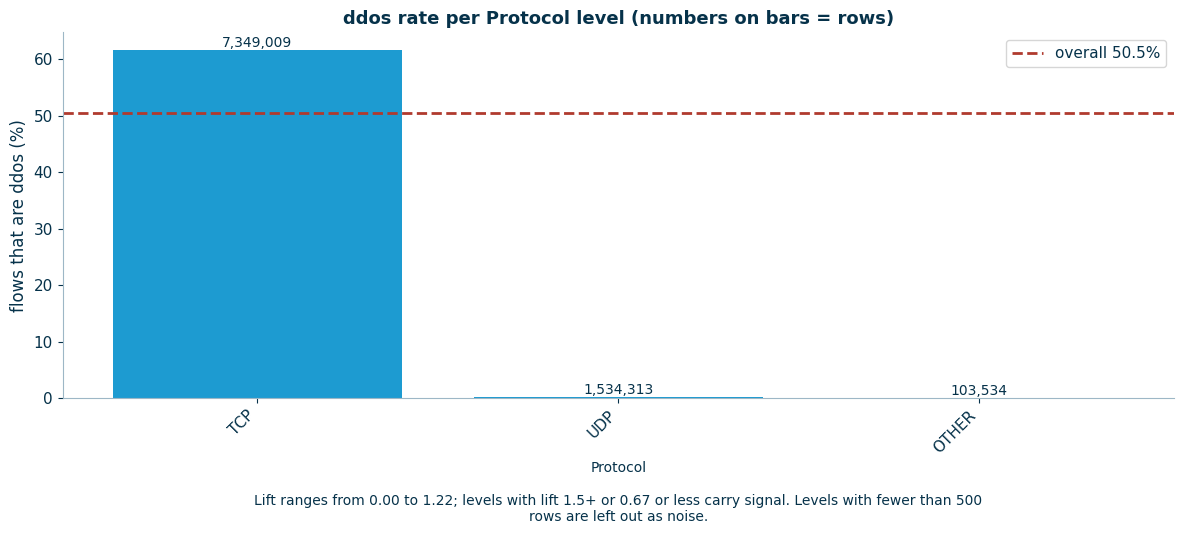

Table saved: tables/t11_2_rates_dst_port_group.csv  (21 rows)


dst_port_group,rows,ddos_rate,lift,reading,median_dur
21,"74,426",0.9915,1.9640,well ABOVE overall - signal,3
80,"3,095,970",0.8334,1.6510,well ABOVE overall - signal,"14,939"
OTHER,"2,552,984",0.7373,1.4606,close to overall - little signal on its own,"2,972,589"
49152,"1,051",0.1427,0.2827,well BELOW overall - signal (lower risk),"1,536,366"
443,"762,198",0.0001,0.0002,well BELOW overall - signal (lower risk),"5,946,499"
137,"5,948",0.0000,0.0000,well BELOW overall - signal (lower risk),"1,581,384"
139,724,0.0000,0.0000,well BELOW overall - signal (lower risk),"125,296"
389,672,0.0000,0.0000,well BELOW overall - signal (lower risk),436
123,"7,863",0.0000,0.0000,well BELOW overall - signal (lower risk),"42,099"
3128,"8,908",0.0000,0.0000,well BELOW overall - signal (lower risk),"1,001,877"


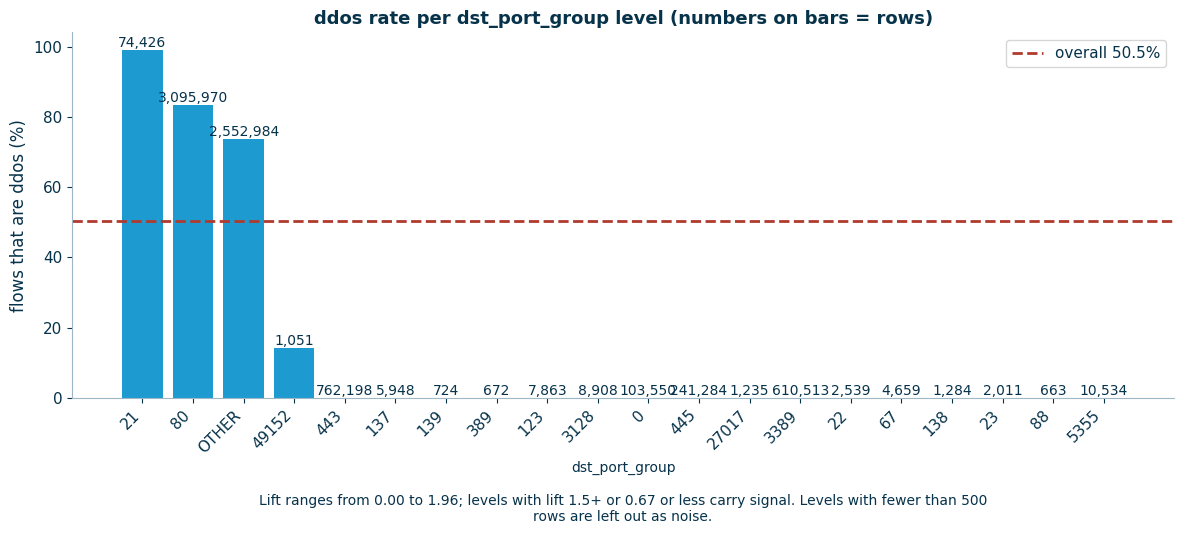

Table saved: tables/t11_3_category_crosstabs.csv  (1 rows)


feature A,feature B,levels A,levels B,one-to-one mapping,A predicts B (mean modal share),verdict
Protocol,dst_port_group,3,21,no,0.7986,distinct


Table saved: tables/t11_4_feature_review_classification.csv  (69 rows)


feature,check used,score or rates,pearson r,spearman rho,band / reading,pearson-spearman gap,rows,keep or drop,reason
Subflow Bwd Byts,pearson r vs 0/1 label,0.013,-0.013,-0.131,negligible,"Spearman well above - consistent order, but curved or bent by extremes","8,986,856",DROP,"Redundant: |r| = 0.99 with Tot Bwd Pkts, which scores higher against this target"
Fwd Seg Size Avg,pearson r vs 0/1 label,0.286,+0.286,+0.036,weak,Pearson well above - a few extreme rows create the pattern,"8,986,856",DROP,"Redundant: |r| = 0.96 with Fwd Pkt Len Std, which scores higher against this target"
Fwd Header Len,pearson r vs 0/1 label,0.011,+0.011,+0.101,negligible,close - steady pattern,"8,986,856",DROP,"Redundant: |r| = 1.00 with TotLen Fwd Pkts, which scores higher against this target"
Fwd IAT Min,pearson r vs 0/1 label,0.060,-0.060,-0.103,negligible,close - steady pattern,"8,986,856",DROP,"Redundant: |r| = 0.98 with Fwd IAT Mean, which scores higher against this target"
Subflow Fwd Pkts,pearson r vs 0/1 label,0.011,+0.011,-0.113,negligible,"Spearman well above - consistent order, but curved or bent by extremes","8,986,856",DROP,"Redundant: |r| = 1.00 with TotLen Fwd Pkts, which scores higher against this target"
Subflow Fwd Byts,pearson r vs 0/1 label,0.013,+0.013,-0.114,negligible,"Spearman well above - consistent order, but curved or bent by extremes","8,986,856",DROP,"Redundant: |r| = 1.00 with TotLen Fwd Pkts, which scores higher against this target"
Subflow Bwd Pkts,pearson r vs 0/1 label,0.017,-0.017,+0.032,negligible,close - steady pattern,"8,986,856",DROP,"Redundant: |r| = 1.00 with Tot Bwd Pkts, which scores higher against this target"
Bwd Header Len,pearson r vs 0/1 label,0.013,-0.013,+0.241,negligible,"Spearman well above - consistent order, but curved or bent by extremes","8,986,856",DROP,"Redundant: |r| = 1.00 with Tot Bwd Pkts, which scores higher against this target"
Flow IAT Min,pearson r vs 0/1 label,0.054,-0.054,+0.081,negligible,close - steady pattern,"8,986,856",DROP,"Redundant: |r| = 0.98 with Flow IAT Mean, which scores higher against this target"
Flow IAT Max,pearson r vs 0/1 label,0.116,-0.116,+0.142,weak,close - steady pattern,"8,986,856",DROP,"Redundant: |r| = 0.93 with Fwd IAT Max, which scores higher against this target"


Table saved: tables/t11_5_feature_review_regression.csv  (69 rows)


feature,check used,score or rates,pearson r,spearman rho,band / reading,pearson-spearman gap,rows,keep or drop,reason
Fwd Pkts/s,spearman rho vs target,0.886,-0.034,-0.886,strong,"Spearman well above - consistent order, but curved or bent by extremes","8,986,856",DROP,Computed from Flow Duration (rate / IAT / active-idle) - reconstructs the target
Bwd IAT Tot,spearman rho vs target,0.688,+0.837,+0.688,moderate,Pearson well above - a few extreme rows create the pattern,"8,986,856",DROP,Computed from Flow Duration (rate / IAT / active-idle) - reconstructs the target
Bwd IAT Mean,spearman rho vs target,0.681,+0.442,+0.681,moderate,"Spearman well above - consistent order, but curved or bent by extremes","8,986,856",DROP,Computed from Flow Duration (rate / IAT / active-idle) - reconstructs the target
Bwd IAT Std,spearman rho vs target,0.672,+0.560,+0.672,moderate,"Spearman well above - consistent order, but curved or bent by extremes","8,986,856",DROP,Computed from Flow Duration (rate / IAT / active-idle) - reconstructs the target
Bwd IAT Max,spearman rho vs target,0.685,+0.630,+0.685,moderate,close - steady pattern,"8,986,856",DROP,Computed from Flow Duration (rate / IAT / active-idle) - reconstructs the target
Bwd IAT Min,spearman rho vs target,0.522,+0.134,+0.522,moderate,"Spearman well above - consistent order, but curved or bent by extremes","8,986,856",DROP,Computed from Flow Duration (rate / IAT / active-idle) - reconstructs the target
Active Max,spearman rho vs target,0.436,+0.256,+0.436,moderate,"Spearman well above - consistent order, but curved or bent by extremes","8,986,856",DROP,Computed from Flow Duration (rate / IAT / active-idle) - reconstructs the target
Active Std,spearman rho vs target,0.356,+0.209,+0.356,weak,"Spearman well above - consistent order, but curved or bent by extremes","8,986,856",DROP,Computed from Flow Duration (rate / IAT / active-idle) - reconstructs the target
Fwd Header Len,spearman rho vs target,0.646,+0.062,+0.646,moderate,"Spearman well above - consistent order, but curved or bent by extremes","8,986,856",DROP,"Redundant: |r| = 1.00 with Tot Fwd Pkts, which scores higher against this target"
Fwd IAT Min,spearman rho vs target,0.554,+0.394,+0.554,moderate,"Spearman well above - consistent order, but curved or bent by extremes","8,986,856",DROP,Computed from Flow Duration (rate / IAT / active-idle) - reconstructs the target


Kept for classification: 43 | kept for regression: 25
Table saved: tables/t11_6_score_bands_summary.csv  (2 rows)


target,medians differ,moderate,negligible,signal,strong,very strong,weak
Flow Duration,2,33,5,0,5,3,19
Label,0,3,37,2,0,0,25


Dropped from classification as label proxies: ['dst_port_group']


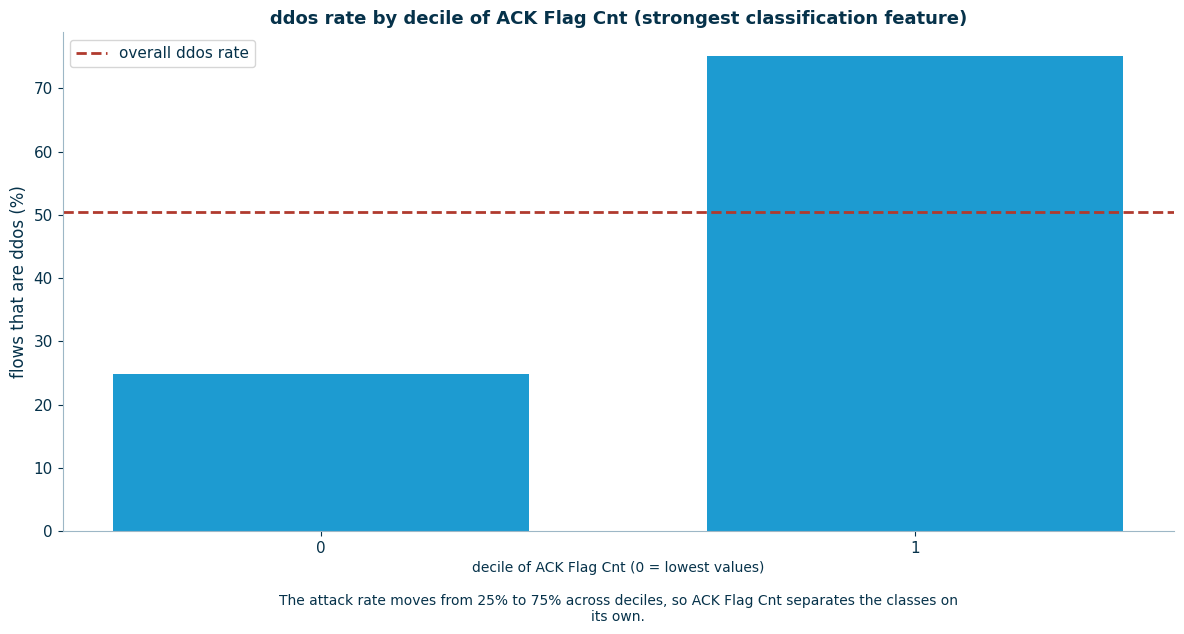

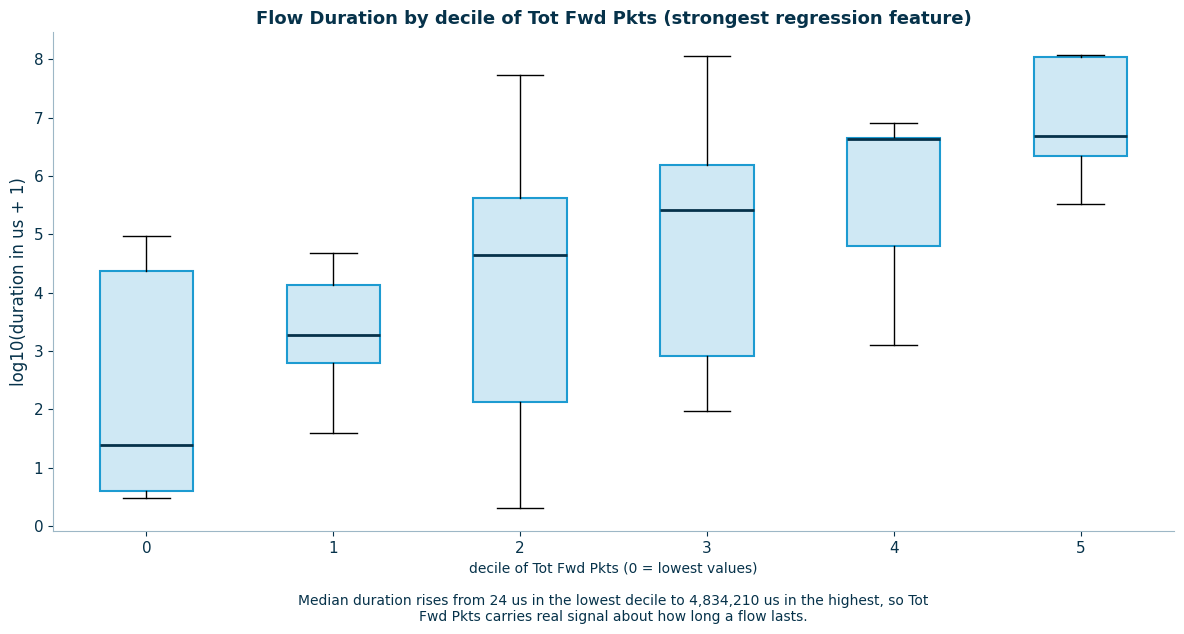

Both relationship tables complete - every candidate feature has a row in each.


In [ ]:
# ==========================================================================================
# TASK 11 – Relationship tables for both targets (TRAINING rows only)
#   Leakage-free version: the columns in LEAK_DROP are removed before any check.
#   Follows the lecture demo (CN7030 Relationships):
#     * numbers vs target  : Pearson AND Spearman, read with the score bands (Schober et al., 2018)
#                            and the Pearson–Spearman gap (0.10 or more = extremes / curve at work)
#     * category vs target : rate per group + LIFT (group rate ÷ overall rate), always with the rows;
#                            lift 1.5+ or 0.67 or less = signal. Number target: median per group.
#     * low score alone is never a reason to drop; judge the size, not the p-value
#     * feature vs feature : |r| >= 0.90 ("very strong") = redundant, keep the one closer to the target
#     * category vs category: crosstab, one-to-one mapping = duplicates, keep one
# ==========================================================================================
from pyspark.sql import functions as F
from pyspark.sql.types import NumericType, StringType
from pyspark.ml.feature import Bucketizer

CLEAN_SPLIT_PATH = f'{BASE_OUT_DIR}/clean_with_splits.parquet'   # shared cleaned data
TGT_C, TGT_R = 'Label', 'Flow Duration'
SAMPLE_N, CORR_FLAG, LEAK_FLAG, MIN_GROUP = 300_000, 0.90, 0.90, 500
GAP_FLAG, LIFT_HI, LIFT_LO = 0.10, 1.5, 0.67          # rules of thumb from the lecture demo
DROP_LABEL_PROXIES = True   # True: drop a classification feature scoring >= LEAK_FLAG against the label
                            # False: keep it (the demo itself has no such rule)

def read_score(score):
    """Correlation size in words (bands: Schober, Boer and Schwarte, 2018) – same as the lecture demo."""
    a = abs(score)
    return ('negligible' if a < 0.10 else 'weak' if a < 0.40 else 'moderate' if a < 0.70
            else 'strong' if a < 0.90 else 'very strong')

def gap_verdict(r, rho):
    g = abs(r) - abs(rho)
    if abs(g) < GAP_FLAG: return 'close - steady pattern'
    return ('Spearman well above - consistent order, but curved or bent by extremes' if g < 0
            else 'Pearson well above - a few extreme rows create the pattern')

src = spark.read.parquet(CLEAN_SPLIT_PATH).filter("split_part = 'train'")   # TRAIN rows only
N = src.count()
src = src.withColumn('label_binary', F.when(F.col(TGT_C) == 'ddos', 1).otherwise(0))
samp = src.sample(False, min(1.0, SAMPLE_N / N), seed=42).cache()
print(f'{N:,} TRAINING rows; relationship checks computed on a {samp.count():,}-row sample')

questions = pd.DataFrame([
    {'target': TGT_C, 'type': 'classification',
     'business question': 'Can we tell, from a completed network flow alone, whether it belongs to a DDoS '
                          'attack, so the traffic can be blocked without inspecting packet contents?',
     'decision it supports': 'Whether to auto-block or rate-limit a source',
     'success measure': 'Per-class precision, recall and F1 (not accuracy - see Task 5)'},
    {'target': TGT_R, 'type': 'regression',
     'business question': 'How long will a flow last, given its size and shape, so capacity and session '
                          'timeouts can be planned rather than guessed?',
     'decision it supports': 'Session timeout and buffer sizing',
     'success measure': 'MAE and RMSE on log1p(duration); MAE reported in seconds'},
])
show(questions, 't11_0_business_questions')

NOT_FEATURES = {'Timestamp', 'capture_year', 'ts_ampm_missing', 'key_label_conflict', 'label_binary',
                'flow_group', 'split_part', 'split_time'}
LEAK_DROP = globals().get('LEAK_DROP', [])
CANDIDATES = [c for c in src.columns if c not in NOT_FEATURES and c not in LEAK_DROP]
removed_tbl = pd.DataFrame([{'column': c, 'in the cleaned data': c in src.columns,
                             'decision': 'removed before any check - capture / machine fingerprint'} for c in LEAK_DROP])
show(removed_tbl, 't11_00_removed_leakage_columns')
log_decision('T11', ', '.join(LEAK_DROP), 'Columns identify the capture or machine, not the traffic behaviour',
             'Removed from both modelling tables before the relationship checks',
             'Attack and benign traffic were recorded in different captures, so these columns let a model '
             'learn where a flow was recorded instead of how it behaves (shortcut / source leakage)', N)
NUMERIC = [c for c in CANDIDATES if isinstance(src.schema[c].dataType, NumericType)]
CATEG   = [c for c in CANDIDATES if isinstance(src.schema[c].dataType, StringType) and c != TGT_C]

RATE_COLS = globals().get('RATE_COLS', ['Flow Byts/s', 'Flow Pkts/s', 'Fwd Pkts/s', 'Bwd Pkts/s'])
IAT_COLS  = globals().get('IAT_COLS',  [c for c in src.columns if 'IAT' in c])
ACT_IDLE  = [c for c in src.columns if c.startswith(('Active', 'Idle'))]
DURATION_DERIVED = set(RATE_COLS) | set(IAT_COLS) | set(ACT_IDLE)

pdf = samp.select(*[F.col(f'`{c}`').cast('double').alias(c) for c in NUMERIC], 'label_binary').toPandas()
# pandas skips null pairs itself (the slide-8 null trap does not apply here)
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)   # constant columns give 'divide by zero' noise
NUM_R = [c for c in NUMERIC if c != TGT_R]
pear_c = pdf[NUMERIC].corrwith(pdf['label_binary'], method='pearson').fillna(0)
spear_c = pdf[NUMERIC].corrwith(pdf['label_binary'], method='spearman').fillna(0)
pear_r = pdf[NUM_R].corrwith(pdf[TGT_R], method='pearson').fillna(0)
spear_r = pdf[NUM_R].corrwith(pdf[TGT_R], method='spearman').fillna(0)
score_c = pear_c.abs()     # classification decision score: Pearson on the 0/1 label
score_r = spear_r.abs()    # regression decision score: Spearman (duration is heavily skewed)

cm = pdf[NUMERIC].corr().abs()
cm_s = pdf[NUMERIC].corr(method='spearman').abs()
pairs = [{'feature A': a, 'feature B': b, '|pearson r|': cm.loc[a, b], '|spearman rho|': cm_s.loc[a, b],
          'band': read_score(cm.loc[a, b])}
         for i, a in enumerate(NUMERIC) for b in NUMERIC[i + 1:]
         if pd.notna(cm.loc[a, b]) and cm.loc[a, b] >= CORR_FLAG]
pairs_tbl = pd.DataFrame(pairs).sort_values('|pearson r|', ascending=False) if pairs else pd.DataFrame(
    [{'result': f'no numeric pair at |r| >= {CORR_FLAG}'}])
show(pairs_tbl, 't11_1_correlated_pairs')

def redundant_drops(score):
    drop = {}
    for p in pairs:
        a, b = p['feature A'], p['feature B']
        if a in drop or b in drop: continue
        weak, strong = (a, b) if score.get(a, 0) < score.get(b, 0) else (b, a)
        drop[weak] = (strong, p['|pearson r|'])
    return drop
DROP_C, DROP_R = redundant_drops(score_c), redundant_drops(score_r)

OVERALL = src.agg(F.avg('label_binary')).first()[0]
cat_stats = {}
for c in CATEG:
    g = (src.groupBy(c).agg(F.count('*').alias('rows'),
                            F.avg('label_binary').alias('ddos_rate'),
                            F.expr(f'percentile_approx(`{TGT_R}`, 0.5, 10000)').alias('median_dur'))
            .filter(F.col('rows') >= MIN_GROUP).toPandas())
    g['lift'] = g.ddos_rate / OVERALL
    g['reading'] = np.where(g.lift >= LIFT_HI, 'well ABOVE overall - signal',
                   np.where(g.lift <= LIFT_LO, 'well BELOW overall - signal (lower risk)',
                            'close to overall - little signal on its own'))
    g = g.sort_values('ddos_rate', ascending=False)
    cat_stats[c] = g
    safe = re.sub(r'\W+', '_', c).lower()
    show(g[[c, 'rows', 'ddos_rate', 'lift', 'reading', 'median_dur']], f't11_2_rates_{safe}')

    top = g.head(20)                                   # slide 6 chart: rate per group + rows + overall line
    fig, ax = plt.subplots(figsize=(12, 5.5))
    ax.bar(top[c].astype(str), top.ddos_rate * 100, color=BLUE)
    ax.axhline(OVERALL * 100, color='#B03A2E', ls='--', lw=2, label=f'overall {OVERALL:.1%}')
    for k, (_, row) in enumerate(top.iterrows()):
        ax.text(k, row.ddos_rate * 100, f'{int(row.rows):,}', ha='center', va='bottom', fontsize=10, color=NAVY)
    ax.set_ylabel('flows that are ddos (%)')
    ax.set_title(f'ddos rate per {c} level (numbers on bars = rows)', fontweight='bold')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    cap = (f'Lift ranges from {g.lift.min():.2f} to {g.lift.max():.2f}; levels with lift {LIFT_HI}+ or '
           f'{LIFT_LO} or less carry signal. Levels with fewer than {MIN_GROUP} rows are left out as noise.')
    ax.set_xlabel(f'{c}\n\n' + textwrap.fill(cap, 110), fontsize=10)
    ax.legend()
    fig.tight_layout()
    fig.savefig(f'{FIG_DIR}/t11_rate_per_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()

xtab_rows = []
for i, a in enumerate(CATEG):
    for b in CATEG[i + 1:]:
        x = samp.crosstab(a, b).toPandas().set_index(f'{a}_{b}')
        share = (x.max(axis=1) / x.sum(axis=1)).mean()
        one_to_one = (x > 0).sum(axis=1).max() == 1 and (x > 0).sum(axis=0).max() == 1   # slide 7 test
        xtab_rows.append({'feature A': a, 'feature B': b, 'levels A': len(x), 'levels B': x.shape[1],
                          'one-to-one mapping': 'yes' if one_to_one else 'no',
                          'A predicts B (mean modal share)': share,
                          'verdict': ('duplicates - keep only one' if one_to_one
                                      else 'possible duplicate - look closer' if share >= 0.95 else 'distinct')})
show(pd.DataFrame(xtab_rows) if xtab_rows else pd.DataFrame([{'result': 'fewer than two categorical features'}]),
     't11_3_category_crosstabs')

nonnull = src.agg(*[F.sum(F.col(f'`{c}`').isNotNull().cast('int')).alias(c) for c in CANDIDATES]).first().asDict()

def review(target):
    is_reg, rows_out = target == TGT_R, []
    score, drops = (score_r, DROP_R) if is_reg else (score_c, DROP_C)
    for c in CANDIDATES:
        if c == target:
            rows_out.append({'feature': c, 'check used': '-', 'score or rates': '-', 'rows': nonnull[c],
                             'keep or drop': 'TARGET', 'reason': 'This is what we predict'})
            continue
        n = nonnull[c]
        if c in (TGT_C, TGT_R):                     # Step 1 slide: take out the other task's target
            rows_out.append({'feature': c, 'check used': 'leakage review (Task 6)', 'score or rates': '-',
                             'rows': n, 'keep or drop': 'DROP',
                             'reason': "Other task's target - not a feature for this model"})
            continue
        pr_, sp_, band, gap = '-', '-', '-', '-'
        if c in CATEG:
            g = cat_stats[c]
            if is_reg:
                s = (g.median_dur.max() - g.median_dur.min()) / max(g.median_dur.median(), 1)
                chk = 'median duration per level'
                val = f'{g.median_dur.min():,.0f}-{g.median_dur.max():,.0f} us'
                band = 'medians differ' if g.median_dur.max() > 2 * max(g.median_dur.min(), 1) else 'medians similar'
            else:
                s = g.ddos_rate.max() - g.ddos_rate.min()
                chk = 'ddos rate + lift per level'
                val = f'{g.ddos_rate.min():.1%}-{g.ddos_rate.max():.1%} (lift {g.lift.min():.2f}-{g.lift.max():.2f})'
                band = ('signal' if (g.lift >= LIFT_HI).any() or (g.lift <= LIFT_LO).any()
                        else 'little signal on its own')
        else:
            r, rho = (pear_r.get(c, 0), spear_r.get(c, 0)) if is_reg else (pear_c.get(c, 0), spear_c.get(c, 0))
            s = float(score.get(c, 0))
            chk = 'spearman rho vs target' if is_reg else 'pearson r vs 0/1 label'
            val = f'{s:.3f}'
            pr_, sp_, band, gap = f'{r:+.3f}', f'{rho:+.3f}', read_score(s), gap_verdict(r, rho)
        if is_reg and c in DURATION_DERIVED:
            k = 'DROP'
            why = 'Computed from Flow Duration (rate / IAT / active-idle) - reconstructs the target'
        elif s >= LEAK_FLAG and not is_reg and DROP_LABEL_PROXIES:
            k = 'DROP'
            why = (f'Label proxy: scores {s:.2f} against the label (>= {LEAK_FLAG}, very strong), so it '
                   f'nearly gives the answer away on its own')
        elif s >= LEAK_FLAG:
            k = 'KEEP'
            why = f'Scores {s:.2f}; leakage-checked in Task 6 and known at flow export, so kept'
        elif c in drops:
            other, r = drops[c]
            k = 'DROP'
            why = f'Redundant: |r| = {r:.2f} with {other}, which scores higher against this target'
        elif s == 0:
            k = 'DROP'
            why = 'No variation in the sample - the column is constant, so it cannot help'
        else:
            k = 'KEEP'
            why = (f'{band.capitalize()} ({val}); kept - a low score alone is never a reason to drop'
                   if band in ('negligible', 'weak', 'little signal on its own', 'medians similar')
                   else f'{band.capitalize()} ({val}); no redundancy or leakage found')
        rows_out.append({'feature': c, 'check used': chk, 'score or rates': val,
                         'pearson r': pr_, 'spearman rho': sp_, 'band / reading': band,
                         'pearson-spearman gap': gap, 'rows': n, 'keep or drop': k, 'reason': why})
    return pd.DataFrame(rows_out)

class_tbl, reg_tbl = review(TGT_C), review(TGT_R)
show(class_tbl.sort_values('keep or drop'), 't11_4_feature_review_classification', max_rows=100)
show(reg_tbl.sort_values('keep or drop'),   't11_5_feature_review_regression',     max_rows=100)

CLASS_KEEP = class_tbl[class_tbl['keep or drop'] == 'KEEP'].feature.tolist()
REG_KEEP   = reg_tbl[reg_tbl['keep or drop'] == 'KEEP'].feature.tolist()
print(f'Kept for classification: {len(CLASS_KEEP)} | kept for regression: {len(REG_KEEP)}')

band_tbl = (pd.concat([class_tbl.assign(target=TGT_C), reg_tbl.assign(target=TGT_R)])
              .query("`keep or drop` != 'TARGET'")
              .groupby(['target', 'band / reading']).size().unstack(fill_value=0).reset_index())
show(band_tbl, 't11_6_score_bands_summary')

LABEL_PROXIES = class_tbl[class_tbl.reason.str.startswith('Label proxy')].feature.tolist()
print('Dropped from classification as label proxies:', LABEL_PROXIES or 'none')
if LABEL_PROXIES:
    log_decision('T11', ', '.join(LABEL_PROXIES), f'Scores >= {LEAK_FLAG} against the classification label',
                 'Dropped from the classification features (kept for regression)',
                 'A feature that almost determines the label on its own lets the model shortcut the task '
                 'instead of learning the traffic pattern', N)

def deciles(col):
    qs = sorted(set(src.approxQuantile(col, [i / 10 for i in range(11)], 0.001)))
    if len(qs) > 2:
        return [-float('inf')] + qs[1:-1] + [float('inf')]
    # few distinct values (e.g. a 0/1 flag): one bucket per value instead of deciles
    mids = [(a + b) / 2 for a, b in zip(qs, qs[1:])] or qs[:1]
    return [-float('inf')] + mids + [float('inf')]

num_keep_c = [c for c in CLASS_KEEP if c in NUMERIC]
best_c = max(num_keep_c, key=lambda c: score_c.get(c, 0))
bc = Bucketizer(splits=deciles(best_c), inputCol=best_c, outputCol='bin', handleInvalid='keep').transform(src)
pc = bc.groupBy('bin').agg(F.avg('label_binary').alias('ddos_rate'),
                           F.count('*').alias('rows')).toPandas().sort_values('bin')
overall = OVERALL
fig, ax = plt.subplots(figsize=(12, 6.5))
ax.bar(pc.bin.astype(int).astype(str), pc.ddos_rate * 100, color=BLUE, width=0.7)
ax.axhline(overall * 100, color='#B03A2E', lw=2, ls='--', label='overall ddos rate')
ax.set_title(f'ddos rate by decile of {best_c} (strongest classification feature)', fontweight='bold')
cap_c = (f'The attack rate moves from {pc.ddos_rate.min():.0%} to {pc.ddos_rate.max():.0%} across deciles, '
         f'so {best_c} separates the classes on its own.')
ax.set_xlabel(f'decile of {best_c} (0 = lowest values)' + '\n\n' + textwrap.fill(cap_c, 95), fontsize=10)
ax.set_ylabel('flows that are ddos (%)')
ax.legend()
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/t11_strongest_classification_feature.png', dpi=150, bbox_inches='tight')
plt.show()

num_keep_r = [c for c in REG_KEEP if c in NUMERIC]
best_r = max(num_keep_r, key=lambda c: score_r.get(c, 0))
br = (Bucketizer(splits=deciles(best_r), inputCol=best_r, outputCol='bin', handleInvalid='keep').transform(src)
        .withColumn('logdur', F.log10(F.col(TGT_R) + 1)))
pr = (br.groupBy('bin')
        .agg(F.expr('percentile_approx(logdur, array(0.05,0.25,0.5,0.75,0.95), 10000)').alias('p'))
        .toPandas().sort_values('bin'))
stats = [{'label': str(int(r.bin)), 'whislo': r.p[0], 'q1': r.p[1], 'med': r.p[2], 'q3': r.p[3],
          'whishi': r.p[4], 'fliers': []} for _, r in pr.iterrows()]
fig, ax = plt.subplots(figsize=(12, 6.5))
bp = ax.bxp(stats, showfliers=False, patch_artist=True, medianprops={'color': NAVY, 'lw': 2})
for b in bp['boxes']:
    b.set(facecolor=PALE, edgecolor=BLUE, lw=1.5)
ax.set_title(f'Flow Duration by decile of {best_r} (strongest regression feature)', fontweight='bold')
ax.set_ylabel('log10(duration in us + 1)')
cap_r = (f'Median duration rises from {10 ** pr.p.iloc[0][2]:,.0f} us in the lowest decile to '
         f'{10 ** pr.p.iloc[-1][2]:,.0f} us in the highest, so {best_r} carries real signal '
         f'about how long a flow lasts.')
ax.set_xlabel(f'decile of {best_r} (0 = lowest values)' + '\n\n' + textwrap.fill(cap_r, 95), fontsize=10)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/t11_strongest_regression_feature.png', dpi=150, bbox_inches='tight')
plt.show()

log_decision('T11', f'{len(CANDIDATES)} candidate features', 'Relationship check against both targets (training rows only)',
             f'Kept {len(CLASS_KEEP)} for classification, {len(REG_KEEP)} for regression',
             f'Redundant pairs at |r| >= {CORR_FLAG} (very strong) reduced to one feature; duration-derived columns '
             f'dropped for regression; weak scores kept, as a low score alone is never a reason to drop',
             N)
assert len(class_tbl) == len(CANDIDATES) and len(reg_tbl) == len(CANDIDATES), 'every candidate needs a row in each table'
samp.unpersist()
print('Both relationship tables complete - every candidate feature has a row in each.')

---
# TASK 12 – Lock the modelling tables (STEP 1)

In [ ]:
# ==========================================================================================
# TASK 12 – Lock the two modelling tables (this is STEP 1 – build the classification table)
#   model_class.parquet : target Label (+ label_binary)   – classification
#   model_reg.parquet   : target Flow Duration            – regression
# No indexing, no one-hot: encoders are fitted after the train/test split.
# split_part / split_time ride along so the split can be applied later; they are NOT features.
# ==========================================================================================
from pyspark.sql import functions as F
from pyspark.sql.types import StringType, NumericType

CLEAN_SPLIT_PATH = f'{BASE_OUT_DIR}/clean_with_splits.parquet'   # shared cleaned data
CLASS_PATH, REG_PATH = f'{OUT_DIR}/model_class.parquet', f'{OUT_DIR}/model_reg.parquet'
src = spark.read.parquet(CLEAN_SPLIT_PATH)
print(f'Cleaned input: {src.count():,} rows, {len(src.columns)} columns')

RATE_COLS = globals().get('RATE_COLS', ['Flow Byts/s', 'Flow Pkts/s', 'Fwd Pkts/s', 'Bwd Pkts/s'])
IAT_COLS  = globals().get('IAT_COLS',  [c for c in src.columns if 'IAT' in c])
ACT_IDLE  = [c for c in src.columns if c.startswith(('Active', 'Idle'))]
NOT_FEATURES = {'Timestamp', 'capture_year', 'ts_ampm_missing', 'key_label_conflict', 'label_binary',
                'flow_group', 'split_part', 'split_time'}
NOT_FEATURES = NOT_FEATURES | set(globals().get('LEAK_DROP', []))   # leakage columns: never a feature
CARRY = ['split_part', 'split_time']            # travel with the table, never used as features

# ---- feature lists: Task 11 keep lists, with a fallback if that cell was not run ----------
if 'CLASS_KEEP' in globals() and 'REG_KEEP' in globals():
    CLASS_FEATURES = [c for c in CLASS_KEEP if c in src.columns and c not in NOT_FEATURES | {'Label'}]
    REG_FEATURES   = [c for c in REG_KEEP   if c in src.columns and c not in NOT_FEATURES | {'Flow Duration', 'Label'}]
    print(f'Using Task 11 keep lists: {len(CLASS_FEATURES)} classification, {len(REG_FEATURES)} regression features')
else:
    CLASS_FEATURES = [c for c in src.columns if c not in NOT_FEATURES | {'Label'}]
    REG_FEATURES   = [c for c in src.columns if c not in NOT_FEATURES | {'Flow Duration', 'Label'}
                      and c not in set(RATE_COLS) | set(IAT_COLS) | set(ACT_IDLE)]
    print('Task 11 lists not found – falling back to the Task 6 leakage rules')

# Time-of-day features are a capture artefact for classification (attack and benign traffic were
# recorded on different days), so they go into the regression table only.
ADD_TIME_TO_CLASS = False
TIME_FEATURES = ['hour_of_day', 'day_of_week', 'is_weekend', 'month_of_year']

def add_time_features(df):
    hour = F.hour('Timestamp')
    if 'ts_ampm_missing' in df.columns:            # AM/PM was lost on those rows -> sentinel
        hour = F.when(F.col('ts_ampm_missing') == 1, F.lit(-1)).otherwise(hour)
    return (df.withColumn('hour_of_day', hour.cast('int'))
              .withColumn('day_of_week', F.dayofweek('Timestamp').cast('int'))
              .withColumn('is_weekend', F.when(F.dayofweek('Timestamp').isin(1, 7), 1).otherwise(0))
              .withColumn('month_of_year', F.month('Timestamp').cast('int')))

# ---- classification table ------------------------------------------------------------------
dfc = add_time_features(src) if ADD_TIME_TO_CLASS else src
dfc = dfc.select('Label', *CLASS_FEATURES, *CARRY, *(TIME_FEATURES if ADD_TIME_TO_CLASS else []))
dfc = dfc.withColumn('label_binary', F.when(F.col('Label') == 'ddos', 1).otherwise(0))   # second target

# ---- regression table ------------------------------------------------------------------------
dfr = add_time_features(src).select('Flow Duration', *REG_FEATURES, *CARRY, *TIME_FEATURES)

# ---- nulls in the selected columns: decide, apply, log ----------------------------------------
def null_counts(df):
    n = df.count()
    r = df.agg(*[F.sum(F.col(f'`{c}`').isNull().cast('int')).alias(c) for c in df.columns]).first().asDict()
    return n, {c: (v or 0) for c, v in r.items() if (v or 0) > 0}

before = []
for name, df in [('model_class', dfc), ('model_reg', dfr)]:
    n, nulls = null_counts(df)
    before += [{'table': name, 'column': c, 'nulls': v, 'null_%': v / n * 100} for c, v in nulls.items()]
show(pd.DataFrame(before) if before else pd.DataFrame([{'result': 'no nulls in either table'}]),
     't12_1_nulls_before')

policy, tables = [], {}
for name, df in [('model_class', dfc), ('model_reg', dfr)]:
    tgt = 'Label' if name == 'model_class' else 'Flow Duration'
    n0, nulls = null_counts(df)

    df = df.filter(F.col(f'`{tgt}`').isNotNull())                       # 1. null target -> drop row
    n1 = df.count()
    policy.append({'table': name, 'column': tgt, 'action': 'drop row',
                   'reason': 'A row with no target cannot be trained or scored on', 'rows': n0 - n1})

    fill = {c: 0.0 for c in RATE_COLS if c in nulls}                    # 2. undefined rates -> 0 + flag
    if fill:
        df = df.fillna(fill)
        policy.append({'table': name, 'column': ', '.join(fill), 'action': 'fill with 0.0',
                       'reason': 'Rate is undefined for zero-duration flows; rate_missing already flags them',
                       'rows': sum(nulls[c] for c in fill)})

    left = [c for c in nulls if c not in fill and c != tgt]             # 3. anything else -> median / mode
    num_left = [c for c in left if isinstance(df.schema[c].dataType, NumericType)]
    cat_left = [c for c in left if isinstance(df.schema[c].dataType, StringType) and c not in CARRY]
    train_only = df.filter("split_part = 'train'")                      # statistics from TRAIN rows only
    if num_left:
        med = train_only.agg(*[F.expr(f'percentile_approx(`{c}`, 0.5, 10000)').alias(c)
                               for c in num_left]).first().asDict()
        df = df.fillna({c: v for c, v in med.items() if v is not None})
        policy.append({'table': name, 'column': ', '.join(num_left), 'action': 'fill with median (train only)',
                       'reason': 'Too few to justify dropping rows; the median is taken from training rows '
                                 'so no test information leaks in',
                       'rows': sum(nulls[c] for c in num_left)})
    for c in cat_left:
        mode = (train_only.filter(F.col(f'`{c}`').isNotNull()).groupBy(c)
                          .count().orderBy(F.desc('count')).first()[0])
        df = df.fillna({c: mode})
        policy.append({'table': name, 'column': c, 'action': f'fill with mode ("{mode}", train only)',
                       'reason': 'Keeps the row; the modal category is the most likely value', 'rows': nulls[c]})
    tables[name] = df
show(pd.DataFrame(policy), 't12_2_null_policy')
dfc, dfr = tables['model_class'], tables['model_reg']

# ---- save -------------------------------------------------------------------------------------
dfc.coalesce(8).write.mode('overwrite').parquet(CLASS_PATH)
dfr.coalesce(8).write.mode('overwrite').parquet(REG_PATH)
print('Saved:', CLASS_PATH, '\nSaved:', REG_PATH)

# ---- reload and report --------------------------------------------------------------------------
mc, mr = spark.read.parquet(CLASS_PATH), spark.read.parquet(REG_PATH)
print('\n===== model_class.parquet ====='); mc.printSchema()
print('\n===== model_reg.parquet ====='); mr.printSchema()
rows_c, rows_r = mc.count(), mr.count()
n_feat_c = len(mc.columns) - 2 - len(CARRY)
n_feat_r = len(mr.columns) - 1 - len(CARRY)
print(f'\nmodel_class rows: {rows_c:,} | features: {n_feat_c} (+2 targets, +{len(CARRY)} split columns)')
print(f'model_reg   rows: {rows_r:,} | features: {n_feat_r} (+1 target, +{len(CARRY)} split columns)')

cls = mc.groupBy('Label', 'label_binary').count().toPandas().sort_values('count', ascending=False)
cls['pct'] = cls['count'] / rows_c * 100
cls['imbalance ratio'] = [f"{cls['count'].max() / cls['count'].min():.3f} : 1"] + [''] * (len(cls) - 1)
show(cls, 't12_3_class_target_distribution')

r = mr.agg(F.min('Flow Duration').alias('min'),
           F.expr('percentile_approx(`Flow Duration`, 0.5, 100000)').alias('median'),
           F.mean('Flow Duration').alias('mean'), F.max('Flow Duration').alias('max'),
           F.stddev('Flow Duration').alias('std')).first().asDict()
show(pd.DataFrame([{'unit': 'microseconds', **r},
                   {'unit': 'seconds', **{k: v / 1e6 for k, v in r.items()}}]),
     't12_4_reg_target_distribution')

# ---- data dictionary: one line per column in each table --------------------------------------------
def describe(c):
    if c in ('Label', 'label_binary'): return 'TARGET', 'Class label (label_binary = 1 for ddos, 0 for benign)'
    if c == 'Flow Duration':           return 'TARGET', 'Flow length in microseconds'
    if c in CARRY:                     return 'SPLIT',  'Which part this row belongs to – excluded from the features'
    if c in TIME_FEATURES:             return 'ENGINEERED', 'Derived from Timestamp; hour = -1 where the AM/PM marker was missing'
    if c.endswith('_missing') or c == 'fwd_pkts_zero':
        return 'FLAG', 'Marks a kept sentinel / tool artefact from the Task 3 decisions'
    if c in ('Protocol', 'src_port_range', 'dst_port_group'):
        return 'CATEGORICAL', 'Kept as text – encoding is fitted after the train/test split'
    return 'NUMERIC', 'CICFlowMeter flow statistic, available when the flow is exported'

dictionary = pd.DataFrame([{'table': t, 'column': c, 'type': df.schema[c].dataType.simpleString(),
                            'role': describe(c)[0], 'explanation': describe(c)[1]}
                           for t, df in [('model_class', mc), ('model_reg', mr)] for c in df.columns])
show(dictionary, 't12_5_data_dictionary', max_rows=200)

# ---- contribution log: EDIT THE NAMES BELOW ----------------------------------------------------------
CONTRIBUTIONS = [
    {'date': pd.Timestamp.today().date(), 'task': 'Task 10 – apply the decision log',  'member': 'Antonio'},
    {'date': pd.Timestamp.today().date(), 'task': 'Task 11 – relationship tables',     'member': 'Kateryna'},
    {'date': pd.Timestamp.today().date(), 'task': 'Task 12 – lock modelling tables',   'member': 'Mohammed'},
    {'date': pd.Timestamp.today().date(), 'task': 'Task 12 – review and verification', 'member': 'Aodhan'},
]
contrib_csv = f'{TABLE_DIR}/contribution_log.csv'
contrib = (pd.concat([pd.read_csv(contrib_csv), pd.DataFrame(CONTRIBUTIONS)], ignore_index=True)
           if os.path.exists(contrib_csv) else pd.DataFrame(CONTRIBUTIONS))
show(contrib, 'contribution_log')

# ---- verification -------------------------------------------------------------------------------------
_, nulls_c = null_counts(mc)
_, nulls_r = null_counts(mr)
leak_reg = set(RATE_COLS) | set(IAT_COLS) | set(ACT_IDLE)
banned = NOT_FEATURES - set(CARRY) - {'label_binary'}
checks = pd.DataFrame([
    {'check': 'model_class reloads', 'expected': dfc.count(), 'actual': rows_c, 'pass': rows_c == dfc.count()},
    {'check': 'model_reg reloads',   'expected': dfr.count(), 'actual': rows_r, 'pass': rows_r == dfr.count()},
    {'check': 'no nulls left (class)', 'expected': 0, 'actual': len(nulls_c), 'pass': not nulls_c},
    {'check': 'no nulls left (reg)',   'expected': 0, 'actual': len(nulls_r), 'pass': not nulls_r},
    {'check': 'no capture/identifier column in class table', 'expected': 0,
     'actual': len([c for c in mc.columns if c in banned]),
     'pass': not any(c in mc.columns for c in banned)},
    {'check': 'split columns present for later filtering', 'expected': len(CARRY),
     'actual': len([c for c in CARRY if c in mc.columns]),
     'pass': all(c in mc.columns for c in CARRY)},
    {'check': 'no duration-derived column in reg table', 'expected': 0,
     'actual': len([c for c in mr.columns if c in leak_reg]),
     'pass': not any(c in mr.columns for c in leak_reg)},
    {'check': 'nothing indexed / one-hot yet', 'expected': 0,
     'actual': len([c for c in mc.columns + mr.columns if c.endswith(('_idx', '_index', '_ohe', '_vec'))]),
     'pass': not any(c.endswith(('_idx', '_index', '_ohe', '_vec')) for c in mc.columns + mr.columns)},
    {'check': 'dictionary explains every column', 'expected': len(mc.columns) + len(mr.columns),
     'actual': len(dictionary), 'pass': len(dictionary) == len(mc.columns) + len(mr.columns)},
])
show(checks, 't12_6_verification')

log_decision('T12', 'model_class.parquet', f'{n_feat_c} features + 2 target columns + split columns',
             'Saved and reloaded', 'Task 11 keep list only; split columns carried but excluded from features', rows_c)
log_decision('T12', 'model_reg.parquet', f'{n_feat_r} features + 1 target column + split columns',
             'Saved and reloaded', 'Rates, IATs and active/idle dropped – they are computed from the target', rows_r)
show(pd.DataFrame(DECISIONS), 't8_cleaning_decisions_log', max_rows=250)

assert checks['pass'].all(), checks[~checks['pass']]
print('\nBoth modelling tables locked and verified.')


# ======================================================================

Cleaned input: 12,794,195 rows, 83 columns
Using Task 11 keep lists: 43 classification, 25 regression features
Table saved: tables/t12_1_nulls_before.csv  (2 rows)


table,column,nulls,null_%
model_class,Flow Byts/s,"47,778",0.3734
model_class,Flow Pkts/s,"47,778",0.3734


Table saved: tables/t12_2_null_policy.csv  (3 rows)


table,column,action,reason,rows
model_class,Label,drop row,A row with no target cannot be trained or scored on,0
model_class,"Flow Byts/s, Flow Pkts/s",fill with 0.0,Rate is undefined for zero-duration flows; rate_missing already flags them,"95,556"
model_reg,Flow Duration,drop row,A row with no target cannot be trained or scored on,0


Saved: /content/drive/MyDrive/CN7030_Group4_outputs/no_leakage/model_class.parquet 
Saved: /content/drive/MyDrive/CN7030_Group4_outputs/no_leakage/model_reg.parquet

===== model_class.parquet =====
root
 |-- Label: string (nullable = true)
 |-- Protocol: string (nullable = true)
 |-- Tot Bwd Pkts: long (nullable = true)
 |-- TotLen Fwd Pkts: long (nullable = true)
 |-- Fwd Pkt Len Min: long (nullable = true)
 |-- Fwd Pkt Len Std: double (nullable = true)
 |-- Bwd Pkt Len Max: long (nullable = true)
 |-- Bwd Pkt Len Min: long (nullable = true)
 |-- Flow Byts/s: double (nullable = true)
 |-- Flow Pkts/s: double (nullable = true)
 |-- Flow IAT Std: double (nullable = true)
 |-- Fwd IAT Tot: long (nullable = true)
 |-- Fwd IAT Mean: double (nullable = true)
 |-- Fwd IAT Std: double (nullable = true)
 |-- Fwd IAT Max: long (nullable = true)
 |-- Bwd IAT Tot: long (nullable = true)
 |-- Bwd IAT Mean: double (nullable = true)
 |-- Bwd IAT Std: double (nullable = true)
 |-- Bwd IAT Max: long (

...

Table saved: tables/t12_6_verification.csv  (9 rows)


check,expected,actual,pass
model_class reloads,"12,794,195","12,794,195",True
model_reg reloads,"12,794,195","12,794,195",True
no nulls left (class),0,0,True
no nulls left (reg),0,0,True
no capture/identifier column in class table,0,0,True
split columns present for later filtering,2,2,True
no duration-derived column in reg table,0,0,True
nothing indexed / one-hot yet,0,0,True
dictionary explains every column,79,79,True


Table saved: tables/t8_cleaning_decisions_log.csv  (5 rows)


task,column(s),issue found,decision taken,reason,rows affected
T11,"Fwd Seg Size Min, Init Fwd Win Byts, Init Bwd Win Byts, init_fwd_win_missing, init_bwd_win_missing, src_port_range, rate_missing","Columns identify the capture or machine, not the traffic behaviour",Removed from both modelling tables before the relationship checks,"Attack and benign traffic were recorded in different captures, so these columns let a model learn where a flow was recorded instead of how it behaves (shortcut / source leakage)","8,986,856"
T11,dst_port_group,Scores >= 0.9 against the classification label,Dropped from the classification features (kept for regression),A feature that almost determines the label on its own lets the model shortcut the task instead of learning the traffic pattern,"8,986,856"
T11,69 candidate features,Relationship check against both targets (training rows only),"Kept 43 for classification, 25 for regression","Redundant pairs at |r| >= 0.9 (very strong) reduced to one feature; duration-derived columns dropped for regression; weak scores kept, as a low score alone is never a reason to drop","8,986,856"
T12,model_class.parquet,43 features + 2 target columns + split columns,Saved and reloaded,Task 11 keep list only; split columns carried but excluded from features,"12,794,195"
T12,model_reg.parquet,29 features + 1 target column + split columns,Saved and reloaded,"Rates, IATs and active/idle dropped – they are computed from the target","12,794,195"



Both modelling tables locked and verified.


---
# STEP 2 – Train / validation / test split folders

In [ ]:
# ==========================================================================================
# STEP 2 – Split the classification table into train / validation / test folders
#   No new randomness here: the split was decided once, on the cleaned file, in the
#   SPLIT ASSIGNMENT cell (split_part = group-aware 70/15/15, split_time = time-based).
#   All six parts are written into ONE tidy folder on Drive:
#       CN7030_Group4_outputs/splits/group_random/{train,val,test}.parquet
#       CN7030_Group4_outputs/splits/time_based/{train,val,test}.parquet
# ==========================================================================================
import os, shutil
import pandas as pd
from pyspark.sql import functions as F

CLASS_PATH = f'{OUT_DIR}/model_class.parquet'
SPLIT_DIR  = f'{OUT_DIR}/splits'
SPLITS = {'split_part': ('group_random', {p: f'{SPLIT_DIR}/group_random/{p}.parquet' for p in ('train', 'val', 'test')}),
          'split_time': ('time_based',   {p: f'{SPLIT_DIR}/time_based/{p}.parquet'   for p in ('train', 'val', 'test')})}
TRAIN_PATH,   VAL_PATH,   TEST_PATH   = (SPLITS['split_part'][1][p] for p in ('train', 'val', 'test'))
TRAIN_T_PATH, VAL_T_PATH, TEST_T_PATH = (SPLITS['split_time'][1][p] for p in ('train', 'val', 'test'))

# Old layout (six loose folders next to everything else). Set to True ONCE to remove them from Drive.
REMOVE_OLD_LOOSE_FOLDERS = False
OLD_LOOSE = [f'{OUT_DIR}/class_{p}{s}.parquet' for p in ('train', 'val', 'test') for s in ('', '_time')]

mc = spark.read.parquet(CLASS_PATH)
n_all = mc.count()
print(f'model_class.parquet: {n_all:,} rows, {len(mc.columns)} columns')
missing = [c for c in SPLITS if c not in mc.columns]
if missing:
    raise ValueError(f'{missing} not in model_class.parquet – run the SPLIT ASSIGNMENT and TASK 12 cells first')

for col, (scheme, paths) in SPLITS.items():
    os.makedirs(f'{SPLIT_DIR}/{scheme}', exist_ok=True)
    for part, p in paths.items():
        mc.filter(F.col(col) == part).coalesce(4).write.mode('overwrite').parquet(p)
        print('wrote', p.replace(OUT_DIR + '/', ''))

rows = []
for col, (scheme, paths) in SPLITS.items():
    for part, p in paths.items():
        d = spark.read.parquet(p)
        n = d.count()
        rows.append({'scheme': scheme, 'part': part, 'rows': n, 'share_%': n / n_all * 100,
                     'ddos_%': (d.filter("Label = 'ddos'").count() / n * 100) if n else 0.0,
                     'folder': p.replace(OUT_DIR + '/', '')})
split_tbl = pd.DataFrame(rows)
show(split_tbl, 't_step2_split_sizes')
for scheme in ('group_random', 'time_based'):
    assert split_tbl[split_tbl.scheme == scheme].rows.sum() == n_all, f'rows lost in the {scheme} split'

if REMOVE_OLD_LOOSE_FOLDERS:
    for p in OLD_LOOSE:
        if os.path.exists(p):
            shutil.rmtree(p)
            print('removed old folder', p.replace(OUT_DIR + '/', ''))

log_decision('Step2', 'model_class.parquet', 'Train/validation/test split written to disk',
             '70/15/15 group-aware split, plus a parallel time-based split, saved under splits/',
             'Split once and reused, so every session trains on exactly the same rows; '
             'test parts stay untouched until the final report', n_all)
print('\nFrom here on, report BOTH evaluations: the group-random split and the time-based one.')


model_class.parquet: 12,794,195 rows, 47 columns
wrote splits/group_random/train.parquet
wrote splits/group_random/val.parquet
wrote splits/group_random/test.parquet
wrote splits/time_based/train.parquet
wrote splits/time_based/val.parquet
wrote splits/time_based/test.parquet
Table saved: tables/t_step2_split_sizes.csv  (6 rows)


scheme,part,rows,share_%,ddos_%,folder
group_random,train,"8,986,856",70.2417,50.4824,splits/group_random/train.parquet
group_random,val,"1,916,976",14.9832,51.2239,splits/group_random/val.parquet
group_random,test,"1,890,363",14.7752,50.4621,splits/group_random/test.parquet
time_based,train,"8,951,935",69.9687,50.5965,splits/time_based/train.parquet
time_based,val,"1,918,901",14.9982,50.5874,splits/time_based/val.parquet
time_based,test,"1,923,359",15.0331,50.5654,splits/time_based/test.parquet



From here on, report BOTH evaluations: the group-random split and the time-based one.


---
# STEP 3 – Logistic regression and Word report
Each run appends a section to `reports/CN7030_Group4_model_runs.docx`. To add a run, change `RUN_NAME` and the settings at the top of the cell and run it again.

In [ ]:
# ==========================================================================================
# STEP 3 – Logistic regression + Word report of every run
#   * targets and bookkeeping columns are kept out of the features
#   * encoders are fitted inside the pipeline on TRAIN rows only (after the split)
#   * evaluated on BOTH validation sets so the capture effect is visible
#   * every run appends one section to ONE Word document:
#       settings, metrics (Word table + rendered image), per-class metrics,
#       confusion matrices, ROC / PR curves, and a comparison of all runs so far
#   Change RUN_NAME / settings below and re-run to add another section.
# ==========================================================================================
import os, time, datetime as dt
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import functions as F
from pyspark.sql.types import StringType, NumericType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml.functions import vector_to_array
from sklearn.metrics import roc_curve, precision_recall_curve
from docx import Document
from docx.shared import Pt, Cm, RGBColor
from docx.oxml import OxmlElement
from docx.oxml.ns import qn

# ---------------- run settings ----------------
RUN_NAME = 'Logistic regression (baseline)'
MAX_ITER, REG_PARAM, ELASTIC_NET = 20, 0.0, 0.0
CURVE_SAMPLE_ROWS = 200_000          # rows pulled to the driver for the ROC / PR curves only

# ---------------- paths (same layout as STEP 2) ----------------
SPLIT_DIR  = f'{OUT_DIR}/splits'
TRAIN_PATH, VAL_PATH, TEST_PATH       = (f'{SPLIT_DIR}/group_random/{p}.parquet' for p in ('train', 'val', 'test'))
TRAIN_T_PATH, VAL_T_PATH, TEST_T_PATH = (f'{SPLIT_DIR}/time_based/{p}.parquet'   for p in ('train', 'val', 'test'))
REPORT_DIR = f'{OUT_DIR}/reports'
IMG_DIR    = f'{REPORT_DIR}/images'
DOCX_PATH  = f'{REPORT_DIR}/CN7030_Group4_model_runs.docx'
RUNS_CSV   = f'{REPORT_DIR}/model_runs.csv'
os.makedirs(IMG_DIR, exist_ok=True)

BLUE, PALE, NAVY = '#1D9BD1', '#CFE8F4', '#06324A'

# ---------------- features ----------------
TARGETS  = {'Label', 'label_binary'}                       # the answer
CARRIERS = {'split_part', 'split_time', 'flow_group', 'Timestamp', 'capture_year',
            'ts_ampm_missing', 'key_label_conflict'}       # bookkeeping, never features
LEAKY    = {'rate_missing'}                                # nearly all missing rates are benign
EXCLUDE  = TARGETS | CARRIERS | LEAKY

train_df = spark.read.parquet(TRAIN_PATH).cache()
N_TRAIN = train_df.count()
CAT = [f.name for f in train_df.schema.fields if isinstance(f.dataType, StringType)  and f.name not in EXCLUDE]
NUM = [f.name for f in train_df.schema.fields if isinstance(f.dataType, NumericType) and f.name not in EXCLUDE]
assert not (EXCLUDE & set(NUM + CAT)), 'a target or carrier leaked into the features'
print(f'train {N_TRAIN:,} rows | {len(NUM)} numeric + {len(CAT)} categorical features')
print('excluded from the features:', sorted(EXCLUDE & set(train_df.columns)))

stages = [StringIndexer(inputCol='Label', outputCol='label', handleInvalid='error',
                        stringOrderType='alphabetAsc')]                       # benign=0, ddos=1
if CAT:
    stages += [StringIndexer(inputCols=CAT, outputCols=[f'{c}_i' for c in CAT], handleInvalid='keep'),
               OneHotEncoder(inputCols=[f'{c}_i' for c in CAT], outputCols=[f'{c}_o' for c in CAT],
                             handleInvalid='keep')]
stages += [VectorAssembler(inputCols=NUM + [f'{c}_o' for c in CAT], outputCol='features', handleInvalid='keep'),
           LogisticRegression(featuresCol='features', labelCol='label',
                              maxIter=MAX_ITER, regParam=REG_PARAM, elasticNetParam=ELASTIC_NET)]
pipe = Pipeline(stages=stages)

t0 = time.time(); model = pipe.fit(train_df); fit_s = time.time() - t0
LABELS = model.stages[0].labels
POS = LABELS.index('ddos')
print(f'fitted in {fit_s:.0f}s | classes {dict(enumerate(LABELS))} | positive = ddos ({POS})')

# ---------------- evaluate on both validation sets ----------------
results, per_class_tables, cms, curves = [], {}, {}, {}
for name, path in [('group-random validation', VAL_PATH), ('time-based validation', VAL_T_PATH)]:
    pred = model.transform(spark.read.parquet(path)).cache()
    n_pred = pred.count()
    mce = lambda m, **kw: MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction',
                                                            metricName=m, **kw).evaluate(pred)
    bce = lambda m: BinaryClassificationEvaluator(labelCol='label', rawPredictionCol='rawPrediction',
                                                  metricName=m).evaluate(pred)
    results.append({'evaluated on': name, 'rows': n_pred, 'accuracy': mce('accuracy'),
                    'f1_weighted': mce('f1'), 'auc_roc': bce('areaUnderROC'), 'auc_pr': bce('areaUnderPR'),
                    'precision_ddos': mce('precisionByLabel', metricLabel=float(POS)),
                    'recall_ddos': mce('recallByLabel', metricLabel=float(POS))})
    per_class_tables[name] = pd.DataFrame(
        [{'class': l, 'precision': mce('precisionByLabel', metricLabel=float(i)),
          'recall': mce('recallByLabel', metricLabel=float(i)),
          'f1': mce('fMeasureByLabel', metricLabel=float(i))} for i, l in enumerate(LABELS)])
    cmp_ = (pred.groupBy('label', 'prediction').count().toPandas()
                .pivot(index='label', columns='prediction', values='count').fillna(0))
    cm = np.zeros((len(LABELS), len(LABELS)), dtype=int)
    for i in cmp_.index:
        for j in cmp_.columns:
            if int(i) < len(LABELS) and int(j) < len(LABELS):
                cm[int(i), int(j)] = int(cmp_.loc[i, j])
    cms[name] = cm
    frac = min(1.0, CURVE_SAMPLE_ROWS / max(n_pred, 1))
    pp = (pred.sample(False, frac, seed=42)
              .select('label', vector_to_array('probability')[POS].alias('p_ddos')).toPandas())
    fpr, tpr, _ = roc_curve(pp.label, pp.p_ddos, pos_label=float(POS))
    prec, rec, _ = precision_recall_curve(pp.label, pp.p_ddos, pos_label=float(POS))
    curves[name] = (fpr, tpr, prec, rec)
    pred.unpersist()
train_df.unpersist()

res = pd.DataFrame(results)
show(res, 't_model_lr_both_splits')
for name, t in per_class_tables.items():
    show(t, f'lr_per_class_{name.split()[0]}')
for name, cm in cms.items():
    show(pd.DataFrame(cm, index=[f'actual {l}' for l in LABELS],
                      columns=[f'predicted {l}' for l in LABELS]).reset_index(names=''),
         f'lr_confusion_{name.split()[0]}')
gap = res.accuracy.iloc[0] - res.accuracy.iloc[1]
print(f'\nAccuracy drop from the easy split to the cross-capture split: {gap:+.4f}')
print('The larger this gap, the more the model was leaning on capture-specific patterns.')

# ---------------- run history (one row per split per run) ----------------
history = pd.read_csv(RUNS_CSV) if os.path.exists(RUNS_CSV) else pd.DataFrame()
RUN_NO = int(history['run'].max()) + 1 if len(history) else 1
STAMP = dt.datetime.now().strftime('%Y-%m-%d %H:%M')
settings = {'run': RUN_NO, 'date': STAMP, 'model': RUN_NAME, 'maxIter': MAX_ITER, 'regParam': REG_PARAM,
            'elasticNetParam': ELASTIC_NET, 'train rows': N_TRAIN, 'numeric features': len(NUM),
            'categorical features': len(CAT), 'fit seconds': round(fit_s, 1)}
new_rows = res.assign(**{k: settings[k] for k in ('run', 'date', 'model', 'maxIter', 'regParam',
                                                   'elasticNetParam', 'fit seconds')})
history = pd.concat([history, new_rows], ignore_index=True)
history.to_csv(RUNS_CSV, index=False)

# ---------------- images ----------------
def table_png(df, path, title, fmt='{:.4f}'):
    cells = [[fmt.format(v) if isinstance(v, (float, np.floating)) else
              (f'{v:,}' if isinstance(v, (int, np.integer)) else str(v)) for v in row] for row in df.values]
    fig, ax = plt.subplots(figsize=(min(1.5 + 1.35 * len(df.columns), 16), 0.9 + 0.45 * (len(df) + 1)))
    ax.axis('off')
    tb = ax.table(cellText=cells, colLabels=list(df.columns), loc='center', cellLoc='center')
    tb.auto_set_font_size(False); tb.set_fontsize(11); tb.scale(1, 1.4)
    for (r, c), cell in tb.get_celld().items():
        cell.set_edgecolor('#9DB7C6'); cell.set_linewidth(0.6)
        if r == 0:
            cell.set_facecolor(BLUE); cell.set_text_props(color='white', fontweight='bold')
        else:
            cell.set_facecolor(PALE if r % 2 else 'white'); cell.set_text_props(color=NAVY)
    ax.set_title(title, color=NAVY, fontweight='bold', fontsize=12)
    fig.savefig(path, dpi=160, bbox_inches='tight'); plt.close(fig)

def cm_png(path):
    fig, axes = plt.subplots(1, len(cms), figsize=(5.5 * len(cms), 4.6))
    for ax, (name, cm) in zip(np.atleast_1d(axes), cms.items()):
        ax.imshow(cm, cmap='Blues')
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center', fontsize=11,
                        color='white' if cm[i, j] > cm.max() / 2 else NAVY, fontweight='bold')
        ax.set_xticks(range(len(LABELS)), [f'predicted\n{l}' for l in LABELS])
        ax.set_yticks(range(len(LABELS)), [f'actual {l}' for l in LABELS])
        ax.set_title(name, fontweight='bold', color=NAVY)
    fig.suptitle(f'Run {RUN_NO} – confusion matrices', fontweight='bold', color=NAVY)
    fig.tight_layout(); fig.savefig(path, dpi=160, bbox_inches='tight'); plt.close(fig)

def curves_png(path):
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 5))
    for (name, (fpr, tpr, prec, rec)), col in zip(curves.items(), [BLUE, NAVY]):
        r = res.set_index('evaluated on').loc[name]
        a1.plot(fpr, tpr, color=col, lw=2, label=f'{name} (AUC {r.auc_roc:.3f})')
        a2.plot(rec, prec, color=col, lw=2, label=f'{name} (AUC {r.auc_pr:.3f})')
    a1.plot([0, 1], [0, 1], ls='--', color='#9DB7C6', lw=1)
    a1.set(xlabel='false positive rate', ylabel='true positive rate', title='ROC curve (positive = ddos)')
    a2.set(xlabel='recall', ylabel='precision', title='Precision–recall curve (positive = ddos)')
    for a in (a1, a2):
        a.legend(fontsize=10, loc='lower right' if a is a1 else 'lower left')
    fig.tight_layout(); fig.savefig(path, dpi=160, bbox_inches='tight'); plt.close(fig)

img_metrics = f'{IMG_DIR}/run{RUN_NO:02d}_metrics.png'
img_cm      = f'{IMG_DIR}/run{RUN_NO:02d}_confusion.png'
img_curves  = f'{IMG_DIR}/run{RUN_NO:02d}_roc_pr.png'
table_png(res, img_metrics, f'Run {RUN_NO} – {RUN_NAME}')
cm_png(img_cm)
curves_png(img_curves)

# ---------------- Word document (one file, one section per run) ----------------
def _shade(cell, hex_colour):
    tcPr = cell._tc.get_or_add_tcPr()
    shd = OxmlElement('w:shd')
    shd.set(qn('w:val'), 'clear'); shd.set(qn('w:color'), 'auto'); shd.set(qn('w:fill'), hex_colour.lstrip('#'))
    tcPr.append(shd)

def word_table(doc, df, fmt='{:.4f}'):
    t = doc.add_table(rows=1, cols=len(df.columns))
    t.style = 'Table Grid'
    for j, c in enumerate(df.columns):
        cell = t.rows[0].cells[j]; cell.text = ''
        run = cell.paragraphs[0].add_run(str(c)); run.bold = True
        run.font.color.rgb = RGBColor(0xFF, 0xFF, 0xFF); run.font.size = Pt(9)
        _shade(cell, BLUE)
    for i, row in enumerate(df.itertuples(index=False), start=1):
        cells = t.add_row().cells
        for j, v in enumerate(row):
            txt = (fmt.format(v) if isinstance(v, (float, np.floating)) else
                   f'{v:,}' if isinstance(v, (int, np.integer)) else str(v))
            cells[j].text = ''
            run = cells[j].paragraphs[0].add_run(txt)
            run.font.color.rgb = RGBColor(0x06, 0x32, 0x4A); run.font.size = Pt(9)
            _shade(cells[j], PALE if i % 2 else '#FFFFFF')
    doc.add_paragraph()
    return t

def heading(doc, text, level):
    h = doc.add_heading(text, level=level)
    for r in h.runs:
        r.font.color.rgb = RGBColor(0x06, 0x32, 0x4A)

if os.path.exists(DOCX_PATH):
    doc = Document(DOCX_PATH)
    doc.add_page_break()
else:
    doc = Document()
    for s in doc.sections:
        s.left_margin = s.right_margin = Cm(2)
    doc.styles['Normal'].font.name = 'Calibri'
    doc.styles['Normal'].font.size = Pt(10.5)
    heading(doc, 'CN7030 Group 4 – Model runs (DDoS classification)', 0)
    doc.add_paragraph('One section is appended every time the model cell runs. Metrics are on the two '
                      'validation sets: the group-random split and the time-based (cross-capture) split.')

heading(doc, f'Run {RUN_NO} – {RUN_NAME}  ({STAMP})', 1)
heading(doc, 'Settings', 2)
word_table(doc, pd.DataFrame([{'setting': k, 'value': v} for k, v in settings.items()]), fmt='{}')
heading(doc, 'Metrics', 2)
word_table(doc, res)
doc.add_paragraph('Screenshot of the metrics table:')
doc.add_picture(img_metrics, width=Cm(17))
doc.add_paragraph(f'Accuracy drop from group-random to time-based validation: {gap:+.4f}. '
                  'The larger this gap, the more the model leans on capture-specific patterns.')
heading(doc, 'Per-class metrics', 2)
for name, t in per_class_tables.items():
    doc.add_paragraph(name).runs[0].bold = True
    word_table(doc, t)
heading(doc, 'Confusion matrices', 2)
doc.add_picture(img_cm, width=Cm(17))
heading(doc, 'ROC and precision–recall curves', 2)
doc.add_picture(img_curves, width=Cm(17))
doc.add_paragraph(f'Curves drawn from a random sample of up to {CURVE_SAMPLE_ROWS:,} validation rows; '
                  'the AUC values in the legend are computed by Spark on the full validation set.')
heading(doc, 'Comparison of all runs so far', 2)
cmp_cols = ['run', 'date', 'model', 'evaluated on', 'accuracy', 'f1_weighted', 'auc_roc', 'auc_pr',
            'precision_ddos', 'recall_ddos']
word_table(doc, history[[c for c in cmp_cols if c in history.columns]])
doc.save(DOCX_PATH)
print(f'\nRun {RUN_NO} appended to {DOCX_PATH}')
print(f'Images saved in {IMG_DIR}; run history in {RUNS_CSV}')

log_decision('Model', 'splits/group_random/train', f'{RUN_NAME} trained (run {RUN_NO})',
             f"group-random accuracy {res.accuracy.iloc[0]:.4f}, time-based accuracy {res.accuracy.iloc[1]:.4f}",
             'Both evaluations reported so the capture effect is visible rather than hidden', N_TRAIN)


train 8,986,856 rows | 42 numeric + 1 categorical features
excluded from the features: ['Label', 'label_binary', 'split_part', 'split_time']
fitted in 34s | classes {0: 'benign', 1: 'ddos'} | positive = ddos (1)
Table saved: tables/t_model_lr_both_splits.csv  (2 rows)


evaluated on,rows,accuracy,f1_weighted,auc_roc,auc_pr,precision_ddos,recall_ddos
group-random validation,"1,916,976",0.9676,0.9676,0.9931,0.9912,0.9499,0.9889
time-based validation,"1,918,901",0.9781,0.9781,0.9994,0.9992,0.9586,0.9999


Table saved: tables/lr_per_class_group-random.csv  (2 rows)


class,precision,recall,f1
benign,0.9879,0.9453,0.9661
ddos,0.9499,0.9889,0.9690


Table saved: tables/lr_per_class_time-based.csv  (2 rows)


...

Table saved: tables/lr_confusion_group-random.csv  (2 rows)


,predicted benign,predicted ddos
actual benign,"883,841","51,185"
actual ddos,"10,869","971,081"


Table saved: tables/lr_confusion_time-based.csv  (2 rows)


,predicted benign,predicted ddos
actual benign,"906,218","41,961"
actual ddos,122,"970,600"



Accuracy drop from the easy split to the cross-capture split: -0.0104
The larger this gap, the more the model was leaning on capture-specific patterns.

Run 3 appended to /content/drive/MyDrive/CN7030_Group4_outputs/no_leakage/reports/CN7030_Group4_model_runs.docx
Images saved in /content/drive/MyDrive/CN7030_Group4_outputs/no_leakage/reports/images; run history in /content/drive/MyDrive/CN7030_Group4_outputs/no_leakage/reports/model_runs.csv


---
# LEAK AUDIT – run after Step 3

In [ ]:
# ==========================================================================================
# LEAK AUDIT – run after STEP 3. Two questions:
#   1. does any single feature predict the label almost perfectly? (a label proxy)
#   2. do test rows have identical twins in train? (memorisation rather than learning)
# ==========================================================================================
import pandas as pd
from pyspark.sql import functions as F
from pyspark.sql.types import NumericType

SPLIT_DIR  = f'{OUT_DIR}/splits'
TRAIN_PATH = f'{SPLIT_DIR}/group_random/train.parquet'
TEST_PATH  = f'{SPLIT_DIR}/group_random/test.parquet'
EXCLUDE = globals().get('EXCLUDE', {'Label', 'label_binary', 'split_part', 'split_time', 'flow_group',
                                    'Timestamp', 'capture_year', 'ts_ampm_missing',
                                    'key_label_conflict', 'rate_missing'})

tr, te = spark.read.parquet(TRAIN_PATH), spark.read.parquet(TEST_PATH)
feat = [c for c in tr.columns if c not in EXCLUDE]
num  = [c for c in feat if isinstance(tr.schema[c].dataType, NumericType)]
lab  = F.when(F.col('Label') == 'ddos', 1.0).otherwise(0.0)

corrs = tr.select(*[F.abs(F.corr(F.col(f'`{c}`').cast('double'), lab)).alias(c) for c in num]).first().asDict()
sus = pd.DataFrame([{'feature': c, 'abs_corr_with_label': v} for c, v in corrs.items() if v and v > 0.8])
show(sus.sort_values('abs_corr_with_label', ascending=False) if len(sus)
     else pd.DataFrame([{'result': 'no single feature above |r| = 0.8 – no obvious label proxy'}]),
     't_leak_audit_correlations')

key   = F.sha2(F.concat_ws('|', *[F.coalesce(F.col(f'`{c}`').cast('string'), F.lit('∅')) for c in feat]), 256)
te_k  = te.withColumn('k', key).select('k').distinct()
twins = te_k.join(tr.withColumn('k', key).select('k').distinct(), 'k').count()
n_te  = te_k.count()
show(pd.DataFrame([{'distinct test rows': n_te, 'also present in train': twins,
                    'share_%': twins / n_te * 100 if n_te else 0.0}]), 't_leak_audit_twins')
print('\nA high twin share means even the group-aware split still rewards memorisation; '
      'quote the time-based evaluation as the honest figure in that case.')


Table saved: tables/t_leak_audit_correlations.csv  (1 rows)


result
no single feature above |r| = 0.8 – no obvious label proxy


Table saved: tables/t_leak_audit_twins.csv  (1 rows)


distinct test rows,also present in train,share_%
"1,311,552","162,885",12.4193



A high twin share means even the group-aware split still rewards memorisation; quote the time-based evaluation as the honest figure in that case.


---
# PART 3 – Modelling: Tasks 17–29
**Run order:** run these cells top to bottom. `MODEL HELPERS` must be run once per session (and after any restart) before any task cell.

* **Every model is trained twice**, once per split scheme, and scored on that scheme's own validation set:
  group-random train → group-random validation, and time-based train → time-based validation.
  *Step 3 scored its group-random model on the time-based validation set; most of those rows were in its training
  set, which is why its time-based score (0.999) looked better than the group-random one. Use the Task 17
  "no weights" row as the logistic regression result instead.*
* **Training sample:** `TRAIN_ROWS = 2,000,000` per scheme (seed 42), the same rows for every model. Validation is always scored in full. Set `TRAIN_ROWS = None` in MODEL HELPERS to train on all ~9M rows (much slower).
* Every run adds a section to `reports/CN7030_Group4_model_runs.docx` and rows to `reports/classification_runs.csv` / `reports/regression_runs.csv`.
* Fitted models live in memory only: Tasks 22, 26, 28 and 29 need the earlier task cells to have run **in the same session**.



---
# STEP 2 (REGRESSION) – Split the regression table


In [ ]:
# ==========================================================================================
# STEP 2 (REGRESSION) – Split model_reg.parquet into train / validation / test folders
#   Same fixed split columns as the classification table (no new randomness):
#       splits/regression/group_random/{train,val,test}.parquet
#       splits/regression/time_based/{train,val,test}.parquet
#   Needed by Tasks 23–26 and 29. Run once; re-run only if Task 12 is re-run.
# ==========================================================================================
import os
import pandas as pd
from pyspark.sql import functions as F

REG_PATH  = f'{OUT_DIR}/model_reg.parquet'
SPLIT_DIR = f'{OUT_DIR}/splits'
mr = spark.read.parquet(REG_PATH)
n_all = mr.count()
print(f'model_reg.parquet: {n_all:,} rows, {len(mr.columns)} columns')

rows = []
for col, scheme in [('split_part', 'group_random'), ('split_time', 'time_based')]:
    os.makedirs(f'{SPLIT_DIR}/regression/{scheme}', exist_ok=True)
    for part in ('train', 'val', 'test'):
        p = f'{SPLIT_DIR}/regression/{scheme}/{part}.parquet'
        mr.filter(F.col(col) == part).coalesce(4).write.mode('overwrite').parquet(p)
        d = spark.read.parquet(p)
        st = d.agg(F.count('*').alias('n'), F.avg('Flow Duration').alias('mean'),
                   F.expr('percentile_approx(`Flow Duration`, 0.5, 10000)').alias('median')).first()
        rows.append({'scheme': scheme, 'part': part, 'rows': st['n'], 'share_%': st['n'] / n_all * 100,
                     'mean duration (s)': st['mean'] / 1e6, 'median duration (s)': st['median'] / 1e6,
                     'folder': p.replace(OUT_DIR + '/', '')})
        print('wrote', p.replace(OUT_DIR + '/', ''))
reg_split_tbl = pd.DataFrame(rows)
show(reg_split_tbl, 't_step2_regression_split_sizes')
for scheme in ('group_random', 'time_based'):
    assert reg_split_tbl[reg_split_tbl.scheme == scheme].rows.sum() == n_all, f'rows lost in the {scheme} split'

log_decision('Step2-reg', 'model_reg.parquet', 'Regression table split into train/validation/test',
             'Same group-aware 70/15/15 and time-based split columns as the classification table',
             'Both tasks use exactly the same rows in each part, so results are comparable', n_all)


model_reg.parquet: 12,794,195 rows, 32 columns
wrote splits/regression/group_random/train.parquet
wrote splits/regression/group_random/val.parquet
wrote splits/regression/group_random/test.parquet
wrote splits/regression/time_based/train.parquet
wrote splits/regression/time_based/val.parquet
wrote splits/regression/time_based/test.parquet
Table saved: tables/t_step2_regression_split_sizes.csv  (6 rows)


scheme,part,rows,share_%,mean duration (s),median duration (s),folder
group_random,train,"8,986,856",70.2417,8.4683,0.0325,splits/regression/group_random/train.parquet
group_random,val,"1,916,976",14.9832,7.5774,0.0313,splits/regression/group_random/val.parquet
group_random,test,"1,890,363",14.7752,7.6797,0.0310,splits/regression/group_random/test.parquet
time_based,train,"8,951,935",69.9687,8.8666,0.0760,splits/regression/time_based/train.parquet
time_based,val,"1,918,901",14.9982,6.8536,0.0028,splits/regression/time_based/val.parquet
time_based,test,"1,923,359",15.0331,6.5622,0.0049,splits/regression/time_based/test.parquet


---
# MODEL HELPERS – run once per session

In [ ]:

# ==========================================================================================
# MODEL HELPERS – run once per session before Task 17 (and again after any runtime restart)
#   * reads the saved split folders – no new splitting
#   * every model is trained TWICE, once per split scheme, and scored on that scheme's own
#     validation set:  group_random train -> group_random val,  time_based train -> time_based val
#     (a model trained on the group-random train set must NOT be scored on the time-based
#      validation set – most of those rows are inside the group-random train set)
#   * one fixed training sample (TRAIN_ROWS, seed 42) per scheme, shared by every model, so all
#     models see exactly the same rows; validation is always scored in FULL
#   * class weights: weight = total rows ÷ (2 × rows in that class)   (lecture formula)
#   * scores TRAIN as well as VALIDATION, so the train-vs-validation gap is visible
#   * every run adds a section to reports/CN7030_Group4_model_runs.docx and rows to
#     reports/classification_runs.csv or reports/regression_runs.csv
# ==========================================================================================
import os, time, datetime as dt
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pyspark import StorageLevel
from pyspark.sql import functions as F
from pyspark.sql.types import StringType, NumericType
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.functions import vector_to_array
from sklearn.metrics import roc_curve, precision_recall_curve
from docx import Document
from docx.shared import Pt, Cm, RGBColor
from docx.oxml import OxmlElement
from docx.oxml.ns import qn

# ---------------- settings ----------------
TRAIN_ROWS        = 2_000_000   # training rows per scheme for Tasks 17–29 (None = all ~9M rows, much slower)
SCHEMES           = ['group_random', 'time_based']
CURVE_SAMPLE_ROWS = 200_000     # rows brought to pandas for ROC / PR curves and scatter plots
SEED              = 42

SPLIT_DIR  = f'{OUT_DIR}/splits'
REPORT_DIR = f'{OUT_DIR}/reports'
IMG_DIR    = f'{REPORT_DIR}/images'
DOCX_PATH  = f'{REPORT_DIR}/CN7030_Group4_model_runs.docx'
CLF_CSV    = f'{REPORT_DIR}/classification_runs.csv'
REG_CSV    = f'{REPORT_DIR}/regression_runs.csv'
OLD_CSV    = f'{REPORT_DIR}/model_runs.csv'            # Step 3 runs – only used to continue the run numbers
os.makedirs(IMG_DIR, exist_ok=True)
BLUE, PALE, NAVY = '#1D9BD1', '#CFE8F4', '#06324A'

TGT_R = 'Flow Duration'
EXCLUDE_C = {'Label', 'label_binary', 'label', 'weight', 'split_part', 'split_time', 'flow_group', 'Timestamp',
             'capture_year', 'ts_ampm_missing', 'key_label_conflict',
             'rate_missing'}            # nearly every missing-rate row is benign – kept out as in Step 3
EXCLUDE_R = {TGT_R, 'y', 'Label', 'label_binary', 'split_part', 'split_time', 'flow_group', 'Timestamp',
             'capture_year', 'key_label_conflict',
             'rate_missing'}            # rates are missing exactly when Flow Duration = 0 – it gives the target away

# ---------------- data: loaded once, cached, released on request ----------------
_cache = globals().get('_cache', {})        # kept if this cell is re-run in the same session
EXCLUDE_C |= set(globals().get('LEAK_DROP', []))   # leakage columns: never a feature
EXCLUDE_R |= set(globals().get('LEAK_DROP', []))

def data(kind, scheme, part):
    """kind 'clf' or 'reg'; scheme 'group_random' / 'time_based'; part 'train' / 'val' / 'test'."""
    key = (kind, scheme, part)
    if key not in _cache:
        sub = 'regression/' if kind == 'reg' else ''
        df = spark.read.parquet(f'{SPLIT_DIR}/{sub}{scheme}/{part}.parquet')
        if kind == 'clf':
            df = df.withColumn('label', F.col('label_binary').cast('double'))
        if part == 'train' and TRAIN_ROWS:
            n = df.count()
            if n > TRAIN_ROWS:
                df = df.sample(False, TRAIN_ROWS / n, seed=SEED)
        if kind == 'clf' and part == 'train':
            counts = {r['label']: r['count'] for r in df.groupBy('label').count().collect()}
            total = sum(counts.values())
            w = {k: total / (2 * v) for k, v in counts.items()}
            df = df.withColumn('weight', F.when(F.col('label') == 1.0, F.lit(w[1.0])).otherwise(F.lit(w[0.0])))
            CLASS_WEIGHTS[scheme] = {'benign rows': counts[0.0], 'ddos rows': counts[1.0],
                                     'weight benign': w[0.0], 'weight ddos': w[1.0]}
        df = df.persist(StorageLevel.MEMORY_AND_DISK)
        _cache[key] = (df, df.count())
    return _cache[key][0]

def nrows(kind, scheme, part):
    data(kind, scheme, part)
    return _cache[(kind, scheme, part)][1]

def release(kind):
    """Free the cached tables of one kind ('clf' or 'reg') to save memory."""
    for k in [k for k in _cache if k[0] == kind]:
        _cache.pop(k)[0].unpersist()

CLASS_WEIGHTS = globals().get('CLASS_WEIGHTS', {})

def feature_lists(df, exclude):
    cat = [f.name for f in df.schema.fields if isinstance(f.dataType, StringType) and f.name not in exclude]
    num = [f.name for f in df.schema.fields if isinstance(f.dataType, NumericType) and f.name not in exclude]
    return num, cat

def max_bins(kind):
    """Trees need maxBins >= the number of levels in every text feature."""
    df = data(kind, SCHEMES[0], 'train')
    _, cat = feature_lists(df, EXCLUDE_C if kind == 'clf' else EXCLUDE_R)
    if not cat:
        return 32
    lv = df.agg(*[F.countDistinct(c).alias(c) for c in cat]).first().asDict()
    return max(32, max(lv.values()) + 2)

def prep_stages(num, cat, style):
    """style 'onehot' : text -> 0/1 columns (linear models)
       style 'scaled' : 'onehot' + StandardScaler (MLP needs inputs on the same scale)
       style 'index'  : text -> one index column (trees split on it directly)
       Encoders are fitted on the TRAIN rows only, inside the model, after the split."""
    stages, cols = [], list(num)
    if cat:
        stages.append(StringIndexer(inputCols=cat, outputCols=[f'{c}_i' for c in cat], handleInvalid='keep'))
        if style in ('onehot', 'scaled'):
            stages.append(OneHotEncoder(inputCols=[f'{c}_i' for c in cat], outputCols=[f'{c}_o' for c in cat],
                                        handleInvalid='keep'))
            cols += [f'{c}_o' for c in cat]
        else:
            cols += [f'{c}_i' for c in cat]
    out = 'features_raw' if style == 'scaled' else 'features'
    stages.append(VectorAssembler(inputCols=cols, outputCol=out, handleInvalid='keep'))
    if style == 'scaled':
        stages.append(StandardScaler(inputCol='features_raw', outputCol='features', withMean=True, withStd=True))
    return stages, cols

def fit_model(train_df, num, cat, style, make_estimator, label_col, use_weights=False):
    """Fits the encoders, then the model, on the training rows. make_estimator(n_features) -> estimator."""
    prep = Pipeline(stages=prep_stages(num, cat, style)[0]).fit(train_df)
    keep = ['features', label_col] + (['weight'] if use_weights else [])
    trx = prep.transform(train_df).select(*keep).persist(StorageLevel.MEMORY_AND_DISK)
    n_features = trx.first()['features'].size
    est = make_estimator(n_features)
    if use_weights:
        est = est.setWeightCol('weight')
    t0 = time.time()
    m = est.fit(trx)
    fit_s = time.time() - t0
    trx.unpersist()
    return PipelineModel(stages=prep.stages + [m]), fit_s, n_features

# ---------------- run numbers ----------------
def next_run():
    runs = [0]
    for p in (OLD_CSV, CLF_CSV, REG_CSV):
        if os.path.exists(p):
            d = pd.read_csv(p)
            if 'run' in d and len(d):
                runs.append(int(d['run'].max()))
    return max(runs) + 1

# ---------------- pictures ----------------
def _fmt(v):
    if isinstance(v, (float, np.floating)):
        return f'{v:,.4f}' if abs(v) < 1e5 else f'{v:,.0f}'
    if isinstance(v, (int, np.integer)):
        return f'{v:,}'
    return str(v)

def table_png(df, path, title):
    fig, ax = plt.subplots(figsize=(min(1.5 + 1.35 * len(df.columns), 18), 0.9 + 0.45 * (len(df) + 1)))
    ax.axis('off')
    tb = ax.table(cellText=[[_fmt(v) for v in row] for row in df.values], colLabels=list(df.columns),
                  loc='center', cellLoc='center')
    tb.auto_set_font_size(False); tb.set_fontsize(10); tb.scale(1, 1.4)
    for (r, c), cell in tb.get_celld().items():
        cell.set_edgecolor('#9DB7C6'); cell.set_linewidth(0.6)
        if r == 0:
            cell.set_facecolor(BLUE); cell.set_text_props(color='white', fontweight='bold')
        else:
            cell.set_facecolor(PALE if r % 2 else 'white'); cell.set_text_props(color=NAVY)
    ax.set_title(title, color=NAVY, fontweight='bold', fontsize=12)
    fig.savefig(path, dpi=160, bbox_inches='tight'); plt.close(fig)

def cm_png(cms, path, title):
    fig, axes = plt.subplots(1, len(cms), figsize=(5.5 * len(cms), 4.6))
    for ax, (name, cm) in zip(np.atleast_1d(axes), cms.items()):
        ax.imshow(cm, cmap='Blues')
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center', fontsize=11, fontweight='bold',
                        color='white' if cm[i, j] > cm.max() / 2 else NAVY)
        ax.set_xticks([0, 1], ['predicted\nbenign', 'predicted\nddos'])
        ax.set_yticks([0, 1], ['actual benign', 'actual ddos'])
        ax.set_title(f'{name} validation', fontweight='bold', color=NAVY)
    fig.suptitle(title, fontweight='bold', color=NAVY)
    fig.tight_layout(); fig.savefig(path, dpi=160, bbox_inches='tight'); plt.close(fig)

def curves_png(curves, aucs, path, title):
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 5))
    for (name, pp), col in zip(curves.items(), [BLUE, NAVY]):
        if pp.label.nunique() < 2:
            continue
        fpr, tpr, _ = roc_curve(pp.label, pp.p_ddos)
        prec, rec, _ = precision_recall_curve(pp.label, pp.p_ddos)
        a1.plot(fpr, tpr, color=col, lw=2, label=f'{name} (AUC {aucs[name][0]:.3f})')
        a2.plot(rec, prec, color=col, lw=2, label=f'{name} (AUC {aucs[name][1]:.3f})')
    a1.plot([0, 1], [0, 1], ls='--', color='#9DB7C6', lw=1)
    a1.set(xlabel='false positive rate', ylabel='true positive rate', title='ROC curve (positive = ddos)')
    a2.set(xlabel='recall', ylabel='precision', title='Precision–recall curve (positive = ddos)')
    a1.legend(fontsize=10, loc='lower right'); a2.legend(fontsize=10, loc='lower left')
    fig.suptitle(title, fontweight='bold', color=NAVY)
    fig.tight_layout(); fig.savefig(path, dpi=160, bbox_inches='tight'); plt.close(fig)

# ---------------- Word ----------------
def _shade(cell, hex_colour):
    tcPr = cell._tc.get_or_add_tcPr()
    shd = OxmlElement('w:shd')
    shd.set(qn('w:val'), 'clear'); shd.set(qn('w:color'), 'auto'); shd.set(qn('w:fill'), hex_colour.lstrip('#'))
    tcPr.append(shd)

def _word_table(doc, df):
    t = doc.add_table(rows=1, cols=len(df.columns))
    t.style = 'Table Grid'
    for j, c in enumerate(df.columns):
        cell = t.rows[0].cells[j]; cell.text = ''
        run = cell.paragraphs[0].add_run(str(c)); run.bold = True
        run.font.color.rgb = RGBColor(0xFF, 0xFF, 0xFF); run.font.size = Pt(8.5)
        _shade(cell, BLUE)
    for i, row in enumerate(df.itertuples(index=False), start=1):
        cells = t.add_row().cells
        for j, v in enumerate(row):
            cells[j].text = ''
            run = cells[j].paragraphs[0].add_run(_fmt(v))
            run.font.color.rgb = RGBColor(0x06, 0x32, 0x4A); run.font.size = Pt(8.5)
            _shade(cells[j], PALE if i % 2 else '#FFFFFF')
    doc.add_paragraph()

def _heading(doc, text, level):
    h = doc.add_heading(text, level=level)
    for r in h.runs:
        r.font.color.rgb = RGBColor(0x06, 0x32, 0x4A)

def docx_section(title, blocks):
    """blocks: list of ('h', text) | ('p', text) | ('table', DataFrame) | ('img', path)."""
    if os.path.exists(DOCX_PATH):
        doc = Document(DOCX_PATH); doc.add_page_break()
    else:
        doc = Document()
        for s in doc.sections:
            s.left_margin = s.right_margin = Cm(2)
        doc.styles['Normal'].font.name = 'Calibri'; doc.styles['Normal'].font.size = Pt(10.5)
        _heading(doc, 'CN7030 Group 4 – Model runs (DDoS)', 0)
    _heading(doc, title, 1)
    for kind, payload in blocks:
        if kind == 'h':
            _heading(doc, payload, 2)
        elif kind == 'p':
            doc.add_paragraph(payload)
        elif kind == 'table':
            _word_table(doc, payload)
        elif kind == 'img':
            doc.add_picture(payload, width=Cm(17))
    doc.save(DOCX_PATH)

def _append_csv(path, df):
    old = pd.read_csv(path) if os.path.exists(path) else pd.DataFrame()
    pd.concat([old, df], ignore_index=True).to_csv(path, index=False)

# ---------------- classification ----------------
def score_clf(model, df):
    p = (model.transform(df)
              .select('label', vector_to_array('probability')[1].alias('p_ddos'), 'prediction')
              .persist(StorageLevel.MEMORY_AND_DISK))
    p.count()
    return p

def clf_metrics(p, threshold=None):
    """Confusion matrix + accuracy, per-class precision/recall/F1 and macro-F1 (mean of the two F1s)."""
    pred = (F.col('p_ddos') >= threshold).cast('double') if threshold is not None else F.col('prediction')
    cm = np.zeros((2, 2), dtype=np.int64)
    for r in p.groupBy('label', pred.alias('pred')).count().collect():
        cm[int(r['label']), int(r['pred'])] = r['count']
    out = {'accuracy': np.trace(cm) / max(cm.sum(), 1)}
    f1s = []
    for k, name in [(0, 'benign'), (1, 'ddos')]:
        prec = cm[k, k] / cm[:, k].sum() if cm[:, k].sum() else 0.0
        rec = cm[k, k] / cm[k, :].sum() if cm[k, :].sum() else 0.0
        f1 = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
        out.update({f'precision_{name}': prec, f'recall_{name}': rec, f'f1_{name}': f1})
        f1s.append(f1)
    out['macro_f1'] = float(np.mean(f1s))
    return out, cm

def clf_auc(p):
    ev = lambda m: BinaryClassificationEvaluator(labelCol='label', rawPredictionCol='p_ddos',
                                                 metricName=m).evaluate(p)
    return {'auc_roc': ev('areaUnderROC'), 'auc_pr': ev('areaUnderPR')}

CLF_MODELS = globals().get('CLF_MODELS', {})    # (model name, scheme) -> (fitted PipelineModel, feature names)
CLF_COLS = ['model', 'scheme', 'scored on', 'rows', 'macro_f1', 'accuracy', 'auc_roc', 'auc_pr',
            'precision_ddos', 'recall_ddos', 'f1_ddos', 'precision_benign', 'recall_benign', 'f1_benign',
            'fit_seconds']

def log_clf(name, task, res, settings, extra_blocks=(), images=()):
    """Adds the run to classification_runs.csv and a section to the Word report."""
    run = next_run()
    res = res.assign(run=run, task=task, date=dt.datetime.now().strftime('%Y-%m-%d %H:%M'))
    _append_csv(CLF_CSV, res)
    hist = pd.read_csv(CLF_CSV)
    cmp_ = (hist[hist['scored on'] == 'val']
              [['run', 'task', 'model', 'scheme', 'macro_f1', 'recall_ddos', 'auc_roc', 'gap_macro_f1', 'fit_seconds']]
              .sort_values(['scheme', 'run']))
    blocks = [('h', 'Settings'), ('table', pd.DataFrame([{'setting': k, 'value': v} for k, v in settings.items()])),
              ('h', 'Metrics (train and validation, per split scheme)'),
              ('table', res[[c for c in CLF_COLS + ['gap_macro_f1'] if c in res.columns]])]
    blocks += [('img', p) for p in images]
    blocks += list(extra_blocks)
    blocks += [('h', 'Comparison of all classification runs so far (validation rows)'), ('table', cmp_)]
    docx_section(f'Run {run} – {task}: {name}', blocks)
    print(f'Run {run} added to the Word report and {os.path.basename(CLF_CSV)}')
    return run

def run_classifier(name, make_estimator, style, use_weights, task, settings=None,
                   keep_scores=False, extra_blocks=()):
    """Trains one model per scheme, scores train + validation, logs everything. Returns (results, kept scores)."""
    rows, cms, curves, aucs, kept = [], {}, {}, {}, {}
    for scheme in SCHEMES:
        tr, va = data('clf', scheme, 'train'), data('clf', scheme, 'val')
        num, cat = feature_lists(tr, EXCLUDE_C)
        model, fit_s, n_feat = fit_model(tr, num, cat, style, make_estimator, 'label', use_weights)
        CLF_MODELS[(name, scheme)] = (model, num + cat)
        print(f'[{scheme}] {name}: fitted on {nrows("clf", scheme, "train"):,} rows, '
              f'{len(num)} numeric + {len(cat)} text features ({n_feat} model inputs) in {fit_s:,.0f}s')
        for part in ('train', 'val'):
            p = score_clf(model, tr if part == 'train' else va)
            m, cm = clf_metrics(p)
            m.update(clf_auc(p))
            rows.append({'model': name, 'scheme': scheme, 'scored on': part,
                         'rows': nrows('clf', scheme, part), **m, 'fit_seconds': fit_s})
            if part == 'val':
                cms[scheme], aucs[scheme] = cm, (m['auc_roc'], m['auc_pr'])
                n = nrows('clf', scheme, 'val')
                curves[scheme] = p.sample(False, min(1.0, CURVE_SAMPLE_ROWS / max(n, 1)), seed=SEED).toPandas()
                if keep_scores:
                    kept[scheme] = p
                    continue
            p.unpersist()
    res = pd.DataFrame(rows)
    gaps = (res.pivot(index='scheme', columns='scored on', values='macro_f1')
               .assign(gap=lambda d: d['train'] - d['val']))
    res['gap_macro_f1'] = res.apply(lambda r: gaps.loc[r.scheme, 'gap'] if r['scored on'] == 'val' else np.nan, axis=1)
    show(res[[c for c in CLF_COLS + ['gap_macro_f1'] if c in res.columns]],
         f"t_{task.lower().replace(' ', '').replace('–', '_')}_{name.lower().replace(' ', '_')[:40]}")

    run = next_run()
    tag = f'run{run:02d}'
    img_m, img_cm, img_cv = (f'{IMG_DIR}/{tag}_metrics.png', f'{IMG_DIR}/{tag}_confusion.png',
                             f'{IMG_DIR}/{tag}_roc_pr.png')
    table_png(res[['scheme', 'scored on', 'macro_f1', 'accuracy', 'auc_roc', 'recall_ddos', 'precision_ddos']],
              img_m, f'Run {run} – {name}')
    cm_png(cms, img_cm, f'Run {run} – {name}: confusion matrices')
    curves_png(curves, aucs, img_cv, f'Run {run} – {name}')
    st = {'model': name, 'training rows per scheme': f'{TRAIN_ROWS:,}' if TRAIN_ROWS else 'all',
          'class weights': 'yes' if use_weights else 'no', 'feature encoding': style}
    if use_weights:
        for s, w in CLASS_WEIGHTS.items():
            st[f'weights ({s})'] = f"benign {w['weight benign']:.3f}, ddos {w['weight ddos']:.3f}"
    st.update(settings or {})
    log_clf(name, task, res, st, extra_blocks, (img_m, img_cm, img_cv))
    return res, kept

# ---------------- regression ----------------
REG_MODELS = globals().get('REG_MODELS', {})    # (model name, scheme) -> (fitted PipelineModel, log_target, cap)
REG_SAMPLES = globals().get('REG_SAMPLES', {})  # (model name, scheme) -> pandas sample of validation (y_true, y_pred)

def reg_predict(name, scheme, df):
    """Predictions in microseconds. The model output is capped at the largest TRAINING target (on the
       log scale when the target was logged) before converting back: a linear model can extrapolate to
       absurd values on rare extreme rows, and exp() of that overflows. Durations cannot be negative."""
    entry = REG_MODELS[(name, scheme)]
    if not isinstance(entry, tuple):            # stored by the earlier version of this cell
        lt = globals().get('LOG_TARGET', True)
        entry = (entry, lt, float(np.log1p(130e6)) if lt else 130e6)
    model, log_target, cap = entry
    pr = F.least(F.col('prediction'), F.lit(cap))
    pr = F.expm1(F.greatest(pr, F.lit(0.0))) if log_target else F.greatest(pr, F.lit(0.0))
    return model.transform(df).select(F.col(TGT_R).cast('double').alias('y_true'), pr.alias('y_pred'))

def forget_runs(kind, model_name):
    """Removes earlier rows of one model from the run CSV (e.g. a broken run that is being redone).
       Its old section stays in the Word report - delete that section by hand or mark it as superseded."""
    path = CLF_CSV if kind == 'clf' else REG_CSV
    if os.path.exists(path):
        h = pd.read_csv(path)
        gone = h[h.model == model_name]
        if len(gone):
            h[h.model != model_name].to_csv(path, index=False)
            print(f'Removed {len(gone)} earlier row(s) of "{model_name}" (run(s) {sorted(gone.run.unique())}) '
                  f'from {os.path.basename(path)}')
REG_COLS = ['model', 'scheme', 'scored on', 'rows', 'mae_s', 'rmse_s', 'r2', 'rmse_log', 'fit_seconds']

def reg_metrics(p):
    """p has y_true and y_pred in microseconds. MAE / RMSE reported in SECONDS; R² unitless;
       rmse_log = RMSE on log1p scale (how well the model ranks short vs long flows)."""
    d = F.col('y_pred') - F.col('y_true')
    dl = F.log1p('y_pred') - F.log1p('y_true')
    r = p.agg(F.avg(F.abs(d)).alias('mae'), F.avg(d * d).alias('mse'), F.var_pop('y_true').alias('var'),
              F.avg(dl * dl).alias('mse_log')).first()
    return {'mae_s': r['mae'] / 1e6, 'rmse_s': np.sqrt(r['mse']) / 1e6,
            'r2': 1 - r['mse'] / r['var'] if r['var'] else 0.0, 'rmse_log': float(np.sqrt(r['mse_log']))}

def log_reg(name, task, res, settings, extra_blocks=(), images=()):
    run = next_run()
    res = res.assign(run=run, task=task, date=dt.datetime.now().strftime('%Y-%m-%d %H:%M'))
    _append_csv(REG_CSV, res)
    hist = pd.read_csv(REG_CSV)
    cmp_ = (hist[hist['scored on'] == 'val']
              [['run', 'task', 'model', 'scheme', 'mae_s', 'rmse_s', 'r2', 'rmse_log', 'gap_rmse_s', 'fit_seconds']]
              .sort_values(['scheme', 'run']))
    blocks = [('h', 'Settings'), ('table', pd.DataFrame([{'setting': k, 'value': v} for k, v in settings.items()])),
              ('h', 'Metrics (MAE / RMSE in seconds, train and validation, per split scheme)'),
              ('table', res[[c for c in REG_COLS + ['gap_rmse_s'] if c in res.columns]])]
    blocks += [('img', p) for p in images]
    blocks += list(extra_blocks)
    blocks += [('h', 'Comparison of all regression runs so far (validation rows)'), ('table', cmp_)]
    docx_section(f'Run {run} – {task}: {name}', blocks)
    print(f'Run {run} added to the Word report and {os.path.basename(REG_CSV)}')
    return run

def finish_reg(name, task, rows, settings, extra_blocks=()):
    res = pd.DataFrame(rows)
    gaps = res.pivot(index='scheme', columns='scored on', values='rmse_s')
    res['gap_rmse_s'] = res.apply(lambda r: gaps.loc[r.scheme, 'val'] - gaps.loc[r.scheme, 'train']
                                  if r['scored on'] == 'val' else np.nan, axis=1)
    show(res[[c for c in REG_COLS + ['gap_rmse_s'] if c in res.columns]],
         f"t_{task.lower().replace(' ', '')}_{name.lower().replace(' ', '_')[:40]}")
    run = next_run()
    img = f'{IMG_DIR}/run{run:02d}_reg_metrics.png'
    table_png(res[['scheme', 'scored on', 'mae_s', 'rmse_s', 'r2', 'rmse_log']], img, f'Run {run} – {name}')
    st = {'model': name}
    if 'train sample rows' not in (settings or {}):
        st['training rows per scheme'] = f'{TRAIN_ROWS:,}' if TRAIN_ROWS else 'all'
    st.update(settings or {})
    log_reg(name, task, res, st, extra_blocks, (img,))
    return res

def run_regressor(name, make_estimator, style, log_target, task, settings=None):
    """Trains on log1p(duration) when log_target=True and converts back (expm1) BEFORE scoring.
       Predictions are capped at the largest training target first (see reg_predict)."""
    rows = []
    for scheme in SCHEMES:
        tr = data('reg', scheme, 'train').withColumn(
            'y', F.log1p(TGT_R) if log_target else F.col(TGT_R).cast('double'))
        va = data('reg', scheme, 'val')
        num, cat = feature_lists(tr, EXCLUDE_R)
        model, fit_s, n_feat = fit_model(tr, num, cat, style, make_estimator, 'y')
        cap = tr.agg(F.max('y')).first()[0]
        REG_MODELS[(name, scheme)] = (model, log_target, cap)
        print(f'[{scheme}] {name}: fitted on {nrows("reg", scheme, "train"):,} rows, '
              f'{len(num)} numeric + {len(cat)} text features in {fit_s:,.0f}s')
        for part, df in [('train', tr), ('val', va)]:
            p = reg_predict(name, scheme, df).persist(StorageLevel.MEMORY_AND_DISK)
            rows.append({'model': name, 'scheme': scheme, 'scored on': part,
                         'rows': nrows('reg', scheme, part), **reg_metrics(p), 'fit_seconds': fit_s})
            if part == 'val':
                n = nrows('reg', scheme, 'val')
                REG_SAMPLES[(name, scheme)] = p.sample(False, min(1.0, 20_000 / max(n, 1)), seed=SEED).toPandas()
            p.unpersist()
    st = {'target transform': 'log1p, converted back with expm1 before scoring' if log_target else 'none',
          'prediction cap': 'largest training target (stops extreme extrapolation)',
          'feature encoding': style}
    st.update(settings or {})
    return finish_reg(name, task, rows, st)

def best_rows(kind='clf'):
    """Validation rows of every run so far, ranked the way Task 28 asks."""
    if kind == 'clf':
        h = pd.read_csv(CLF_CSV)
        v = h[h['scored on'] == 'val']
        return v.sort_values(['scheme', 'macro_f1', 'recall_ddos', 'auc_roc'], ascending=[True, False, False, False])
    h = pd.read_csv(REG_CSV)
    v = h[h['scored on'] == 'val']
    return v.sort_values(['scheme', 'rmse_s', 'mae_s'])

print('Helpers ready.')
print(f'Training sample per scheme: {TRAIN_ROWS:,} rows' if TRAIN_ROWS else 'Training on ALL rows')
print('Schemes:', ', '.join(SCHEMES), '| Word report:', DOCX_PATH.replace(OUT_DIR + '/', ''))

Helpers ready.
Training sample per scheme: 2,000,000 rows
Schemes: group_random, time_based | Word report: reports/CN7030_Group4_model_runs.docx


---
# TASK 17 – Logistic regression with class weights and cut-offs

In [ ]:
# ==========================================================================================
# TASK 17 – Logistic regression with class weights, and cut-offs 0.2 / 0.3 / 0.4
#   weight for a class = total rows ÷ (2 × rows in that class)  (lecture formula, set in MODEL HELPERS)
#   Compared with: a majority-class baseline and the same logistic regression WITHOUT weights,
#   all trained on the same sample. Then the weighted model is re-scored at several cut-offs.
# ==========================================================================================
from pyspark.ml.classification import LogisticRegression

LR = lambda n: LogisticRegression(featuresCol='features', labelCol='label', maxIter=20, regParam=0.0)

# ---- majority-class baseline: always predict the most common class in train -----------------
rows = []
for scheme in SCHEMES:
    tr, va = data('clf', scheme, 'train'), data('clf', scheme, 'val')
    maj = float(tr.groupBy('label').count().orderBy(F.desc('count')).first()['label'])
    for part, df in [('train', tr), ('val', va)]:
        p = df.select('label', F.lit(maj).alias('prediction'), F.lit(0.5).alias('p_ddos'))
        m, _ = clf_metrics(p)
        rows.append({'model': 'Majority-class baseline', 'scheme': scheme, 'scored on': part,
                     'rows': nrows('clf', scheme, part), **m, 'auc_roc': 0.5, 'auc_pr': np.nan, 'fit_seconds': 0.0})
base = pd.DataFrame(rows)
base['gap_macro_f1'] = np.nan
show(base[[c for c in CLF_COLS if c in base.columns]], 't17_0_majority_baseline')
log_clf('Majority-class baseline', 'Task 17', base, {'rule': 'always predict the most common class in train'})
print('Class weights used:'); show(pd.DataFrame(CLASS_WEIGHTS).T.reset_index(names='scheme'), 't17_1_class_weights')

# ---- logistic regression without and with class weights --------------------------------------
res_lr, _ = run_classifier('Logistic regression (no weights)', LR, 'onehot', False, 'Task 17',
                           {'maxIter': 20, 'regParam': 0.0})
res_lrw, kept = run_classifier('Logistic regression (class weights)', LR, 'onehot', True, 'Task 17',
                               {'maxIter': 20, 'regParam': 0.0}, keep_scores=True)

# ---- cut-offs: weighted model, validation rows -------------------------------------------------
CUTOFFS = [0.2, 0.3, 0.4, 0.5]
rows = []
for scheme, p in kept.items():
    for t in CUTOFFS:
        m, _ = clf_metrics(p, t)
        rows.append({'scheme': scheme, 'cut-off': t, **m})
    p.unpersist()
cut_tbl = pd.DataFrame(rows)
cut_tbl['|precision - recall| ddos'] = (cut_tbl.precision_ddos - cut_tbl.recall_ddos).abs()
show(cut_tbl[['scheme', 'cut-off', 'precision_ddos', 'recall_ddos', 'f1_ddos', 'macro_f1', 'accuracy',
              '|precision - recall| ddos']], 't17_2_cutoffs')

# the balanced cut-off: precision and recall for ddos closest together, ties broken by macro-F1
best_cut = (cut_tbl.sort_values(['scheme', '|precision - recall| ddos', 'macro_f1'], ascending=[True, True, False])
                   .groupby('scheme').head(1))
show(best_cut[['scheme', 'cut-off', 'precision_ddos', 'recall_ddos', 'macro_f1']], 't17_3_balanced_cutoff')

cmp_17 = pd.concat([base, res_lr, res_lrw])
cmp_17 = cmp_17[cmp_17['scored on'] == 'val'][['model', 'scheme', 'macro_f1', 'recall_ddos', 'accuracy', 'auc_roc']]
show(cmp_17, 't17_4_comparison')
img = f'{IMG_DIR}/task17_cutoffs.png'
table_png(cut_tbl[['scheme', 'cut-off', 'precision_ddos', 'recall_ddos', 'macro_f1']], img, 'Task 17 – cut-offs (weighted LR)')
docx_section('Task 17 – class weights and cut-offs: summary', [
    ('p', 'Class weights follow the lecture formula. The training data is close to 50:50, so both weights are '
          'close to 1 and the weighted model is expected to differ only slightly from the unweighted one.'),
    ('table', pd.DataFrame(CLASS_WEIGHTS).T.reset_index(names='scheme')),
    ('h', 'Validation comparison'), ('table', cmp_17),
    ('h', 'Cut-offs (weighted model)'), ('table', cut_tbl[['scheme', 'cut-off', 'precision_ddos', 'recall_ddos',
                                                          'f1_ddos', 'macro_f1', 'accuracy']]),
    ('img', img),
    ('p', 'Balanced cut-off per scheme (ddos precision and recall closest together): ' +
          '; '.join(f'{r.scheme}: {r["cut-off"]}' for _, r in best_cut.iterrows()))])
log_decision('T17', 'Logistic regression', 'Class weights and cut-offs tested',
             'Balanced cut-off: ' + ', '.join(f'{r.scheme} {r["cut-off"]}' for _, r in best_cut.iterrows()),
             'Weights make both classes count equally; lower cut-offs trade precision for recall',
             nrows('clf', SCHEMES[0], 'train'))


Table saved: tables/t17_0_majority_baseline.csv  (4 rows)


model,scheme,scored on,rows,macro_f1,accuracy,auc_roc,auc_pr,precision_ddos,recall_ddos,f1_ddos,precision_benign,recall_benign,f1_benign,fit_seconds
Majority-class baseline,group_random,train,"1,999,334",0.3353,0.5045,0.5000,nan,0.5045,1.0000,0.6707,0.0000,0.0000,0.0000,0.0000
Majority-class baseline,group_random,val,"1,916,976",0.3387,0.5122,0.5000,nan,0.5122,1.0000,0.6775,0.0000,0.0000,0.0000,0.0000
Majority-class baseline,time_based,train,"1,998,251",0.3360,0.5059,0.5000,nan,0.5059,1.0000,0.6719,0.0000,0.0000,0.0000,0.0000
Majority-class baseline,time_based,val,"1,918,901",0.3359,0.5059,0.5000,nan,0.5059,1.0000,0.6719,0.0000,0.0000,0.0000,0.0000


Run 30 added to the Word report and classification_runs.csv
Class weights used:
Table saved: tables/t17_1_class_weights.csv  (2 rows)


scheme,benign rows,ddos rows,weight benign,weight ddos
group_random,"990,592.0000","1,008,742.0000",1.0092,0.9910
time_based,"987,297.0000","1,010,954.0000",1.0120,0.9883


[group_random] Logistic regression (no weights): fitted on 1,999,334 rows, 42 numeric + 1 text features (46 model inputs) in 7s
[time_based] Logistic regression (no weights): fitted on 1,998,251 rows, 42 numeric + 1 text features (46 model inputs) in 7s
Table saved: tables/t_task17_logistic_regression_(no_weights).csv  (4 rows)


...

scheme,cut-off,precision_ddos,recall_ddos,f1_ddos,macro_f1,accuracy,|precision - recall| ddos
group_random,0.2000,0.9054,0.9940,0.9476,0.9434,0.9437,0.0886
group_random,0.3000,0.9177,0.9924,0.9536,0.9503,0.9505,0.0746
group_random,0.4000,0.9322,0.9918,0.9611,0.9587,0.9588,0.0596
group_random,0.5000,0.9506,0.9901,0.9699,0.9685,0.9686,0.0395
time_based,0.2000,0.9161,0.9999,0.9562,0.9535,0.9536,0.0838
time_based,0.3000,0.9251,0.9999,0.9610,0.9589,0.9590,0.0748
time_based,0.4000,0.9364,0.9999,0.9671,0.9655,0.9656,0.0635
time_based,0.5000,0.9454,0.9999,0.9719,0.9707,0.9707,0.0544


Table saved: tables/t17_3_balanced_cutoff.csv  (2 rows)


scheme,cut-off,precision_ddos,recall_ddos,macro_f1
group_random,0.5000,0.9506,0.9901,0.9685
time_based,0.5000,0.9454,0.9999,0.9707


Table saved: tables/t17_4_comparison.csv  (6 rows)


model,scheme,macro_f1,recall_ddos,accuracy,auc_roc
Majority-class baseline,group_random,0.3387,1.0000,0.5122,0.5000
Majority-class baseline,time_based,0.3359,1.0000,0.5059,0.5000
Logistic regression (no weights),group_random,0.9688,0.9906,0.9688,0.9930
Logistic regression (no weights),time_based,0.9710,0.9999,0.9710,0.9994
Logistic regression (class weights),group_random,0.9685,0.9901,0.9686,0.9931
Logistic regression (class weights),time_based,0.9707,0.9999,0.9707,0.9994


---
# TASK 18 / 19 – Decision tree, maxDepth 5 then 10 (class weights)

In [ ]:
# ==========================================================================================
# TASK 18 / 19 – Decision tree, maxDepth 5 then maxDepth 10 (with class weights)
#   Observe the train vs validation gap: if depth 10's gap is much bigger, it is memorising.
# ==========================================================================================
from pyspark.ml.classification import DecisionTreeClassifier

MAXBINS = max_bins('clf')
dt_res = {}
for depth in (5, 10):
    name = f'Decision tree (maxDepth {depth}, class weights)'
    dt_res[depth], _ = run_classifier(
        name, lambda n, d=depth: DecisionTreeClassifier(featuresCol='features', labelCol='label', maxDepth=d,
                                                       maxBins=MAXBINS, seed=SEED),
        'index', True, 'Task 18-19', {'maxDepth': depth, 'maxBins': MAXBINS})

gap_tbl = (pd.concat(dt_res.values())
             .pivot_table(index=['model', 'scheme'], columns='scored on', values='macro_f1').reset_index())
gap_tbl['gap (train - val)'] = gap_tbl['train'] - gap_tbl['val']
show(gap_tbl, 't19_depth_gap')
g = gap_tbl.groupby(gap_tbl.model.str.contains('10'))['gap (train - val)'].mean()
verdict = ('Depth 10 has a clearly bigger gap than depth 5 - it is starting to memorise the training rows.'
           if g.get(True, 0) - g.get(False, 0) > 0.01 else
           'Depth 10 does not open a much bigger gap than depth 5 - no clear sign of memorising.')
print(verdict)
docx_section('Task 19 – decision tree depth: train vs validation gap',
             [('table', gap_tbl), ('p', verdict)])
log_decision('T18-19', 'Decision tree', 'maxDepth 5 vs 10 compared on the train-validation gap', verdict, '',
             nrows('clf', SCHEMES[0], 'train'))


[group_random] Decision tree (maxDepth 5, class weights): fitted on 1,999,334 rows, 42 numeric + 1 text features (43 model inputs) in 8s
[time_based] Decision tree (maxDepth 5, class weights): fitted on 1,998,251 rows, 42 numeric + 1 text features (43 model inputs) in 7s
Table saved: tables/t_task18-19_decision_tree_(maxdepth_5,_class_weights.csv  (4 rows)


model,scheme,scored on,rows,macro_f1,accuracy,auc_roc,auc_pr,precision_ddos,recall_ddos,f1_ddos,precision_benign,recall_benign,f1_benign,fit_seconds,gap_macro_f1
"Decision tree (maxDepth 5, class weights)",group_random,train,"1,999,334",0.9820,0.9820,0.9952,0.9937,0.9816,0.9829,0.9822,0.9825,0.9812,0.9819,7.9283,nan
"Decision tree (maxDepth 5, class weights)",group_random,val,"1,916,976",0.9820,0.9821,0.9952,0.9939,0.9821,0.9829,0.9825,0.9820,0.9812,0.9816,7.9283,-0.0000
"Decision tree (maxDepth 5, class weights)",time_based,train,"1,998,251",0.9801,0.9801,0.9869,0.9854,0.9715,0.9898,0.9806,0.9893,0.9703,0.9797,7.4933,nan
"Decision tree (maxDepth 5, class weights)",time_based,val,"1,918,901",0.7547,0.7648,0.9750,0.9659,0.9658,0.5548,0.7047,0.6825,0.9799,0.8046,7.4933,0.2255


Run 33 added to the Word report and classification_runs.csv
[group_random] Decision tree (maxDepth 10, class weights): fitted on 1,999,334 rows, 42 numeric + 1 text features (43 model inputs) in 8s
[time_based] Decision tree (maxDepth 10, class weights): fitted on 1,998,251 rows, 42 numeric + 1 text features (43 model inputs) in 8s
Table saved: tables/t_task18-19_decision_tree_(maxdepth_10,_class_weight.csv  (4 rows)


model,scheme,scored on,rows,macro_f1,accuracy,auc_roc,auc_pr,precision_ddos,recall_ddos,f1_ddos,precision_benign,recall_benign,f1_benign,fit_seconds,gap_macro_f1
"Decision tree (maxDepth 10, class weights)",group_random,train,"1,999,334",0.9936,0.9936,0.9983,0.9982,0.9920,0.9954,0.9937,0.9953,0.9918,0.9936,8.1388,nan
"Decision tree (maxDepth 10, class weights)",group_random,val,"1,916,976",0.9937,0.9937,0.9983,0.9981,0.9923,0.9954,0.9939,0.9952,0.9919,0.9935,8.1388,-0.0001
"Decision tree (maxDepth 10, class weights)",time_based,train,"1,998,251",0.9910,0.9910,0.9968,0.9965,0.9882,0.9941,0.9911,0.9939,0.9878,0.9908,7.9616,nan
"Decision tree (maxDepth 10, class weights)",time_based,val,"1,918,901",0.9281,0.9284,0.9956,0.9955,0.9945,0.8631,0.9242,0.8766,0.9951,0.9321,7.9616,0.0628


Run 34 added to the Word report and classification_runs.csv
Table saved: tables/t19_depth_gap.csv  (4 rows)


model,scheme,train,val,gap (train - val)
"Decision tree (maxDepth 10, class weights)",group_random,0.9936,0.9937,-0.0001
"Decision tree (maxDepth 10, class weights)",time_based,0.9910,0.9281,0.0628
"Decision tree (maxDepth 5, class weights)",group_random,0.9820,0.9820,-0.0000
"Decision tree (maxDepth 5, class weights)",time_based,0.9801,0.7547,0.2255


Depth 10 does not open a much bigger gap than depth 5 - no clear sign of memorising.


---
# TASK 20 – Random forest (50 trees, maxDepth 10, class weights)

In [ ]:
# ==========================================================================================
# TASK 20 – Random forest (50 trees, maxDepth 10, class weights)
#   Observe: does it beat the single tree, is its gap smaller, and how much longer does it take?
# ==========================================================================================
from pyspark.ml.classification import RandomForestClassifier

MAXBINS = max_bins('clf')
rf_res, _ = run_classifier(
    'Random forest (50 trees, maxDepth 10, class weights)',
    lambda n: RandomForestClassifier(featuresCol='features', labelCol='label', numTrees=50, maxDepth=10,
                                     maxBins=MAXBINS, seed=SEED),
    'index', True, 'Task 20', {'numTrees': 50, 'maxDepth': 10, 'maxBins': MAXBINS})

h = pd.read_csv(CLF_CSV)
tree = h[h.model == 'Decision tree (maxDepth 10, class weights)'].drop_duplicates(['scheme', 'scored on'], keep='last')
cmp_rows = []
for scheme in SCHEMES:
    t = tree[tree.scheme == scheme].set_index('scored on')
    r = rf_res[rf_res.scheme == scheme].set_index('scored on')
    if t.empty:
        continue
    cmp_rows.append({'scheme': scheme,
                     'tree val macro_f1': t.loc['val', 'macro_f1'], 'forest val macro_f1': r.loc['val', 'macro_f1'],
                     'tree gap': t.loc['train', 'macro_f1'] - t.loc['val', 'macro_f1'],
                     'forest gap': r.loc['train', 'macro_f1'] - r.loc['val', 'macro_f1'],
                     'tree fit s': t.loc['val', 'fit_seconds'], 'forest fit s': r.loc['val', 'fit_seconds'],
                     'forest / tree time': r.loc['val', 'fit_seconds'] / max(t.loc['val', 'fit_seconds'], 1e-9)})
cmp_20 = pd.DataFrame(cmp_rows)
show(cmp_20 if len(cmp_20) else pd.DataFrame([{'result': 'run Task 18/19 first for the comparison'}]),
     't20_forest_vs_tree')
if len(cmp_20):
    docx_section('Task 20 – random forest vs single tree (depth 10)', [('table', cmp_20)])


[group_random] Random forest (50 trees, maxDepth 10, class weights): fitted on 1,999,334 rows, 42 numeric + 1 text features (43 model inputs) in 40s
[time_based] Random forest (50 trees, maxDepth 10, class weights): fitted on 1,998,251 rows, 42 numeric + 1 text features (43 model inputs) in 41s
Table saved: tables/t_task20_random_forest_(50_trees,_maxdepth_10,_cl.csv  (4 rows)


model,scheme,scored on,rows,macro_f1,accuracy,auc_roc,auc_pr,precision_ddos,recall_ddos,f1_ddos,precision_benign,recall_benign,f1_benign,fit_seconds,gap_macro_f1
"Random forest (50 trees, maxDepth 10, class weights)",group_random,train,"1,999,334",0.9930,0.9930,0.9994,0.9994,0.9907,0.9954,0.9930,0.9953,0.9905,0.9929,39.9600,nan
"Random forest (50 trees, maxDepth 10, class weights)",group_random,val,"1,916,976",0.9930,0.9930,0.9994,0.9994,0.9910,0.9954,0.9932,0.9951,0.9905,0.9928,39.9600,-0.0000
"Random forest (50 trees, maxDepth 10, class weights)",time_based,train,"1,998,251",0.9918,0.9918,0.9992,0.9991,0.9891,0.9949,0.9920,0.9947,0.9888,0.9917,41.0145,nan
"Random forest (50 trees, maxDepth 10, class weights)",time_based,val,"1,918,901",0.7609,0.7715,0.9932,0.9918,0.9889,0.5545,0.7106,0.6854,0.9937,0.8112,41.0145,0.2309


Run 35 added to the Word report and classification_runs.csv
Table saved: tables/t20_forest_vs_tree.csv  (2 rows)


scheme,tree val macro_f1,forest val macro_f1,tree gap,forest gap,tree fit s,forest fit s,forest / tree time
group_random,0.9937,0.9930,-0.0001,-0.0000,8.1388,39.9600,4.9098
time_based,0.9281,0.7609,0.0628,0.2309,7.9616,41.0145,5.1515


---
# TASK 21 – Gradient-boosted trees (50 rounds, maxDepth 5)

In [ ]:
# ==========================================================================================
# TASK 21 – Gradient-boosted trees (50 rounds, maxDepth 5)
#   Binary target, so class weights are used. Often the best macro-F1 and AUC, but the slowest.
# ==========================================================================================
from pyspark.ml.classification import GBTClassifier

MAXBINS = max_bins('clf')
gbt_res, _ = run_classifier(
    'Gradient-boosted trees (50 rounds, maxDepth 5, class weights)',
    lambda n: GBTClassifier(featuresCol='features', labelCol='label', maxIter=50, maxDepth=5,
                            maxBins=MAXBINS, seed=SEED),
    'index', True, 'Task 21', {'maxIter (rounds)': 50, 'maxDepth': 5, 'maxBins': MAXBINS})


[group_random] Gradient-boosted trees (50 rounds, maxDepth 5, class weights): fitted on 1,999,334 rows, 42 numeric + 1 text features (43 model inputs) in 54s
[time_based] Gradient-boosted trees (50 rounds, maxDepth 5, class weights): fitted on 1,998,251 rows, 42 numeric + 1 text features (43 model inputs) in 50s
Table saved: tables/t_task21_gradient-boosted_trees_(50_rounds,_maxde.csv  (4 rows)


model,scheme,scored on,rows,macro_f1,accuracy,auc_roc,auc_pr,precision_ddos,recall_ddos,f1_ddos,precision_benign,recall_benign,f1_benign,fit_seconds,gap_macro_f1
"Gradient-boosted trees (50 rounds, maxDepth 5, class weights)",group_random,train,"1,999,334",0.9920,0.9920,0.9992,0.9986,0.9915,0.9926,0.9921,0.9925,0.9913,0.9919,53.7063,nan
"Gradient-boosted trees (50 rounds, maxDepth 5, class weights)",group_random,val,"1,916,976",0.9921,0.9921,0.9992,0.9987,0.9920,0.9926,0.9923,0.9922,0.9916,0.9919,53.7063,-0.0001
"Gradient-boosted trees (50 rounds, maxDepth 5, class weights)",time_based,train,"1,998,251",0.9900,0.9900,0.9987,0.9985,0.9879,0.9924,0.9901,0.9921,0.9876,0.9899,49.5441,nan
"Gradient-boosted trees (50 rounds, maxDepth 5, class weights)",time_based,val,"1,918,901",0.7612,0.7717,0.9898,0.9867,0.9893,0.5548,0.7109,0.6856,0.9939,0.8114,49.5441,0.2288


Run 36 added to the Word report and classification_runs.csv


---
# TASK 22 – Feature importance and the best model

Table saved: tables/t22_1_feature_importance_top15.csv  (60 rows)


model,feature,importance
"Decision tree (maxDepth 10, class weights)",ACK Flag Cnt,0.2575
"Decision tree (maxDepth 10, class weights)",SYN Flag Cnt,0.2537
"Decision tree (maxDepth 10, class weights)",Fwd Pkts/s,0.2381
"Decision tree (maxDepth 10, class weights)",Fwd Pkt Len Std,0.0578
"Decision tree (maxDepth 10, class weights)",TotLen Fwd Pkts,0.0578
"Decision tree (maxDepth 10, class weights)",Down/Up Ratio,0.0549
"Decision tree (maxDepth 10, class weights)",Tot Bwd Pkts,0.0204
"Decision tree (maxDepth 10, class weights)",Flow Pkts/s,0.0181
"Decision tree (maxDepth 10, class weights)",Fwd IAT Tot,0.0110
"Decision tree (maxDepth 10, class weights)",Idle Max,0.0072


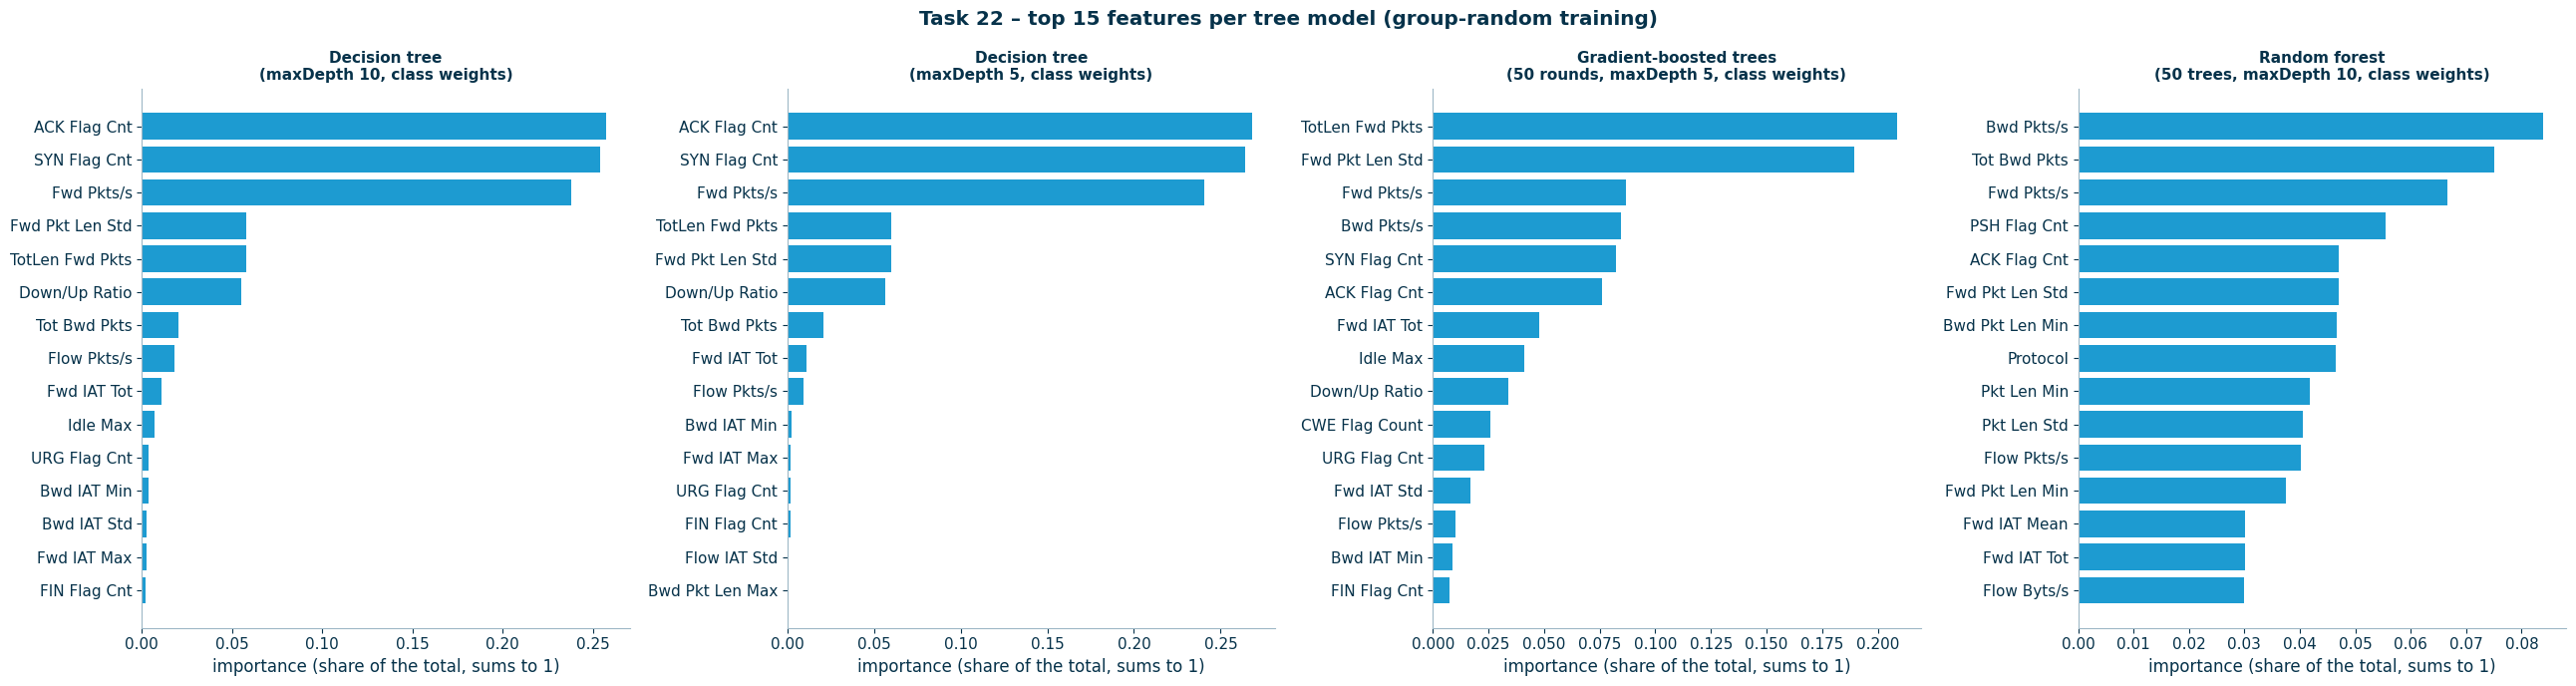

Table saved: tables/t22_2_models_ranked.csv  (50 rows)


run,model,scheme,macro_f1,recall_ddos,auc_roc,gap_macro_f1,fit_seconds
34,"Decision tree (maxDepth 10, class weights)",group_random,0.9937,0.9954,0.9983,-0.0001,8.1388
7,"Random forest (50 trees, maxDepth 10, class weights)",group_random,0.9935,0.9962,0.9995,-0.0000,40.6905
21,"Random forest (50 trees, maxDepth 10, class weights)",group_random,0.9934,0.9949,0.9994,-0.0001,41.1409
20,"Decision tree (maxDepth 10, class weights)",group_random,0.9932,0.9942,0.9988,0.0001,7.7573
35,"Random forest (50 trees, maxDepth 10, class weights)",group_random,0.9930,0.9954,0.9994,-0.0000,39.9600
6,"Decision tree (maxDepth 10, class weights)",group_random,0.9928,0.9963,0.9977,-0.0000,8.1600
36,"Gradient-boosted trees (50 rounds, maxDepth 5, class weights)",group_random,0.9921,0.9926,0.9992,-0.0001,53.7063
8,"Gradient-boosted trees (50 rounds, maxDepth 5, class weights)",group_random,0.9919,0.9921,0.9994,-0.0000,50.2675
22,"Gradient-boosted trees (50 rounds, maxDepth 5, class weights)",group_random,0.9913,0.9892,0.9993,0.0000,50.7166
28,"MLP bigger (hidden [64, 32])",group_random,0.9886,0.9942,0.9989,-0.0001,94.9161


Table saved: tables/t22_3_best_model_per_scheme.csv  (2 rows)


run,model,scheme,macro_f1,recall_ddos,auc_roc,gap_macro_f1,fit_seconds
34,"Decision tree (maxDepth 10, class weights)",group_random,0.9937,0.9954,0.9983,-0.0001,8.1388
14,"MLP bigger (hidden [64, 32])",time_based,0.9929,0.9998,0.9999,-0.0073,91.0116


In [ ]:
# ==========================================================================================
# TASK 22 – Feature importance, and the best model so far
#   Importance comes from the tree models (group-random scheme). Best model = highest
#   validation macro-F1, then recall on ddos, then AUC (same rule as Task 28).
# ==========================================================================================
imp_rows = []
for (name, scheme), (model, cols) in CLF_MODELS.items():
    est = model.stages[-1]
    if scheme != 'group_random' or not hasattr(est, 'featureImportances'):
        continue
    imp = est.featureImportances.toArray()
    for c, v in zip(cols, imp):
        imp_rows.append({'model': name, 'feature': c, 'importance': float(v)})
if not imp_rows:
    raise RuntimeError('No tree models in this session - run Tasks 18-21 first (models are kept in memory only).')
imp = pd.DataFrame(imp_rows)
top = (imp.sort_values(['model', 'importance'], ascending=[True, False]).groupby('model').head(15))
show(top, 't22_1_feature_importance_top15', max_rows=100)

models = top.model.unique()
fig, axes = plt.subplots(1, len(models), figsize=(6.5 * len(models), 7))
for ax, m in zip(np.atleast_1d(axes), models):
    d = top[top.model == m].sort_values('importance')
    ax.barh(d.feature, d.importance, color=BLUE)
    ax.set_title(m.replace(' (', '\n('), fontsize=11, fontweight='bold', color=NAVY)
    ax.set_xlabel('importance (share of the total, sums to 1)')
fig.suptitle('Task 22 – top 15 features per tree model (group-random training)', fontweight='bold', color=NAVY)
fig.tight_layout()
img_imp = f'{IMG_DIR}/task22_feature_importance.png'
fig.savefig(img_imp, dpi=150, bbox_inches='tight')
plt.show()

ranked = best_rows('clf')[['run', 'model', 'scheme', 'macro_f1', 'recall_ddos', 'auc_roc', 'gap_macro_f1', 'fit_seconds']]
show(ranked, 't22_2_models_ranked', max_rows=100)
best = ranked.groupby('scheme').head(1)
show(best, 't22_3_best_model_per_scheme')
docx_section('Task 22 – feature importance and the best model so far', [
    ('img', img_imp), ('h', 'Top 15 features per model'), ('table', top),
    ('h', 'All classification runs ranked (validation: macro-F1, then ddos recall, then AUC)'), ('table', ranked),
    ('h', 'Best per scheme'), ('table', best)])


---
# TASK 23 – Regression baseline (train average)

In [ ]:
# ==========================================================================================
# TASK 23 – Regression baseline: always predict the TRAIN average duration
#   Scored on validation with MAE, RMSE (both in seconds) and R². These are the scores every
#   regressor has to beat; the baseline's R² should be about 0.
# ==========================================================================================
release('clf')          # classification tables are no longer needed in memory (reloaded when Task 27 needs them)
rows = []
for scheme in SCHEMES:
    tr, va = data('reg', scheme, 'train'), data('reg', scheme, 'val')
    mean_tr = tr.agg(F.avg(TGT_R)).first()[0]
    for part, df in [('train', tr), ('val', va)]:
        p = df.select(F.col(TGT_R).cast('double').alias('y_true'), F.lit(float(mean_tr)).alias('y_pred'))
        rows.append({'model': 'Baseline (train average)', 'scheme': scheme, 'scored on': part,
                     'rows': nrows('reg', scheme, part), **reg_metrics(p), 'fit_seconds': 0.0})
    print(f'[{scheme}] train average duration = {mean_tr / 1e6:,.3f} s')
    REG_SAMPLES[('Baseline (train average)', scheme)] = (
        va.sample(False, min(1.0, 20_000 / nrows('reg', scheme, 'val')), seed=SEED)
          .select(F.col(TGT_R).cast('double').alias('y_true'), F.lit(float(mean_tr)).alias('y_pred')).toPandas())
base_reg = finish_reg('Baseline (train average)', 'Task 23', rows,
                      {'rule': 'predict the training-set mean duration for every flow'})


[group_random] train average duration = 8.481 s
[time_based] train average duration = 8.895 s
Table saved: tables/t_task23_baseline_(train_average).csv  (4 rows)


model,scheme,scored on,rows,mae_s,rmse_s,r2,rmse_log,fit_seconds,gap_rmse_s
Baseline (train average),group_random,train,"1,998,957",13.2258,25.2815,0.0000,6.8278,0.0000,nan
Baseline (train average),group_random,val,"1,916,976",12.4286,23.4563,-0.0015,6.8416,0.0000,-1.8252
Baseline (train average),time_based,train,"1,998,960",13.2463,24.9776,0.0000,6.5322,0.0000,nan
Baseline (train average),time_based,val,"1,918,901",13.7441,24.7785,-0.0068,7.7835,0.0000,-0.1991


Run 37 added to the Word report and regression_runs.csv


---
# TASK 24 – Linear regression (log target)

In [ ]:
# TASK 24 – Linear regression
#   Duration is heavily skewed, so LOG_TARGET = True: train on log(1 + duration), convert the
#   predictions back with exp(x) - 1 BEFORE scoring, so MAE / RMSE stay in real units (seconds).
#   Observe: does it beat the baseline's MAE and RMSE, and the train vs validation RMSE gap.
#   Predictions are capped at the largest training duration before converting back (MODEL HELPERS):
#   without the cap, a few extreme rows gave exp() overflows and astronomical MAE / RMSE.
# ==========================================================================================
from pyspark.ml.regression import LinearRegression

LOG_TARGET = True
LIN_NAME = 'Linear regression' + (' (log target)' if LOG_TARGET else '')
forget_runs('reg', LIN_NAME)        # drops the earlier, uncapped run from the comparison tables
lin_res = run_regressor(LIN_NAME,
                        lambda n: LinearRegression(featuresCol='features', labelCol='y', maxIter=50, regParam=0.0),
                        'onehot', LOG_TARGET, 'Task 24', {'maxIter': 50, 'regParam': 0.0})

h = pd.read_csv(REG_CSV)
b = h[(h.model == 'Baseline (train average)') & (h['scored on'] == 'val')].drop_duplicates('scheme', keep='last')
l = lin_res[lin_res['scored on'] == 'val']
cmp_24 = b[['scheme', 'mae_s', 'rmse_s', 'r2']].merge(l[['scheme', 'mae_s', 'rmse_s', 'r2', 'gap_rmse_s']],
                                                       on='scheme', suffixes=(' baseline', ' linear'))
cmp_24['beats baseline MAE'] = cmp_24['mae_s linear'] < cmp_24['mae_s baseline']
cmp_24['beats baseline RMSE'] = cmp_24['rmse_s linear'] < cmp_24['rmse_s baseline']
show(cmp_24, 't24_linear_vs_baseline')
docx_section('Task 24 – linear regression vs baseline', [
    ('table', cmp_24),
    ('p', 'A log-target model is trained to be right in relative terms, so it often wins clearly on MAE but can '
          'lose on RMSE, which is dominated by the few very long flows. Report both.')])


Removed 4 earlier row(s) of "Linear regression (log target)" (run(s) [np.int64(24)]) from regression_runs.csv
[group_random] Linear regression (log target): fitted on 1,998,957 rows, 27 numeric + 2 text features in 5s
[time_based] Linear regression (log target): fitted on 1,998,960 rows, 27 numeric + 2 text features in 5s
Table saved: tables/t_task24_linear_regression_(log_target).csv  (4 rows)


model,scheme,scored on,rows,mae_s,rmse_s,r2,rmse_log,fit_seconds,gap_rmse_s
Linear regression (log target),group_random,train,"1,998,957",6.8673,22.7183,0.1925,2.7456,4.9887,nan
Linear regression (log target),group_random,val,"1,916,976",6.3022,21.7913,0.1356,2.7508,4.9887,-0.9269
Linear regression (log target),time_based,train,"1,998,960",7.5895,24.0919,0.0697,2.7667,4.5512,nan
Linear regression (log target),time_based,val,"1,918,901",6.1043,22.9049,0.1397,2.8660,4.5512,-1.1870


Run 38 added to the Word report and regression_runs.csv
Table saved: tables/t24_linear_vs_baseline.csv  (2 rows)


scheme,mae_s baseline,rmse_s baseline,r2 baseline,mae_s linear,rmse_s linear,r2 linear,gap_rmse_s,beats baseline MAE,beats baseline RMSE
group_random,12.4286,23.4563,-0.0015,6.3022,21.7913,0.1356,-0.9269,True,True
time_based,13.7441,24.7785,-0.0068,6.1043,22.9049,0.1397,-1.1870,True,True


---
# TASK 25 – Random forest and gradient-boosted trees regressors

In [ ]:
# ==========================================================================================
# TASK 25 – Random forest regressor, then gradient-boosted trees regressor
#   Same settings as for classification: forest 50 trees / maxDepth 10; boosted 50 rounds / maxDepth 5.
#   Same LOG_TARGET as Task 24. Observe: lowest validation RMSE, train vs validation gap, training time.
# ==========================================================================================
from pyspark.ml.regression import RandomForestRegressor, GBTRegressor

LOG_TARGET = globals().get('LOG_TARGET', True)
MAXBINS_R = max_bins('reg')
rfr_res = run_regressor('Random forest regressor (50 trees, maxDepth 10)',
                        lambda n: RandomForestRegressor(featuresCol='features', labelCol='y', numTrees=50,
                                                        maxDepth=10, maxBins=MAXBINS_R, seed=SEED),
                        'index', LOG_TARGET, 'Task 25', {'numTrees': 50, 'maxDepth': 10, 'maxBins': MAXBINS_R})
gbr_res = run_regressor('Gradient-boosted trees regressor (50 rounds, maxDepth 5)',
                        lambda n: GBTRegressor(featuresCol='features', labelCol='y', maxIter=50, maxDepth=5,
                                               maxBins=MAXBINS_R, seed=SEED),
                        'index', LOG_TARGET, 'Task 25', {'maxIter (rounds)': 50, 'maxDepth': 5, 'maxBins': MAXBINS_R})

cmp_25 = best_rows('reg')[['run', 'model', 'scheme', 'mae_s', 'rmse_s', 'r2', 'gap_rmse_s', 'fit_seconds']]
show(cmp_25, 't25_regressors_ranked', max_rows=100)
docx_section('Task 25 – regressors ranked by validation RMSE', [('table', cmp_25)])


[group_random] Random forest regressor (50 trees, maxDepth 10): fitted on 1,998,957 rows, 27 numeric + 2 text features in 74s
[time_based] Random forest regressor (50 trees, maxDepth 10): fitted on 1,998,960 rows, 27 numeric + 2 text features in 76s
Table saved: tables/t_task25_random_forest_regressor_(50_trees,_maxde.csv  (4 rows)


model,scheme,scored on,rows,mae_s,rmse_s,r2,rmse_log,fit_seconds,gap_rmse_s
"Random forest regressor (50 trees, maxDepth 10)",group_random,train,"1,998,957",3.3168,12.2442,0.7654,1.9913,74.4683,nan
"Random forest regressor (50 trees, maxDepth 10)",group_random,val,"1,916,976",2.9164,11.4066,0.7632,1.9947,74.4683,-0.8376
"Random forest regressor (50 trees, maxDepth 10)",time_based,train,"1,998,960",3.6646,12.8548,0.7351,1.9881,76.1385,nan
"Random forest regressor (50 trees, maxDepth 10)",time_based,val,"1,918,901",2.4872,10.7418,0.8108,3.0613,76.1385,-2.1130


Run 39 added to the Word report and regression_runs.csv
[group_random] Gradient-boosted trees regressor (50 rounds, maxDepth 5): fitted on 1,998,957 rows, 27 numeric + 2 text features in 75s
[time_based] Gradient-boosted trees regressor (50 rounds, maxDepth 5): fitted on 1,998,960 rows, 27 numeric + 2 text features in 74s
Table saved: tables/t_task25_gradient-boosted_trees_regressor_(50_rou.csv  (4 rows)


model,scheme,scored on,rows,mae_s,rmse_s,r2,rmse_log,fit_seconds,gap_rmse_s
"Gradient-boosted trees regressor (50 rounds, maxDepth 5)",group_random,train,"1,998,957",3.3500,12.4936,0.7558,2.0032,75.1673,nan
"Gradient-boosted trees regressor (50 rounds, maxDepth 5)",group_random,val,"1,916,976",2.9847,11.7399,0.7491,2.0059,75.1673,-0.7537
"Gradient-boosted trees regressor (50 rounds, maxDepth 5)",time_based,train,"1,998,960",3.6580,13.2226,0.7198,2.0171,74.0658,nan
"Gradient-boosted trees regressor (50 rounds, maxDepth 5)",time_based,val,"1,918,901",3.2018,11.1699,0.7954,4.0328,74.0658,-2.0527


Run 40 added to the Word report and regression_runs.csv
Table saved: tables/t25_regressors_ranked.csv  (21 rows)


run,model,scheme,mae_s,rmse_s,r2,gap_rmse_s,fit_seconds
11,"Random forest regressor (50 trees, maxDepth 10)",group_random,2.8979,11.3974,0.7636,-0.8271,70.5528
25,"Random forest regressor (50 trees, maxDepth 10)",group_random,2.9035,11.4024,0.7633,-0.7700,75.2529
39,"Random forest regressor (50 trees, maxDepth 10)",group_random,2.9164,11.4066,0.7632,-0.8376,74.4683
40,"Gradient-boosted trees regressor (50 rounds, maxDepth 5)",group_random,2.9847,11.7399,0.7491,-0.7537,75.1673
26,"Gradient-boosted trees regressor (50 rounds, maxDepth 5)",group_random,3.0179,11.8422,0.7447,-0.6885,59.1641
12,"Gradient-boosted trees regressor (50 rounds, maxDepth 5)",group_random,3.0716,12.0327,0.7365,-0.6763,54.3443
29,"scikit-learn MLP regressor (64, 32) [sample]",group_random,3.2477,12.7110,0.7056,-2.3521,34.7612
38,Linear regression (log target),group_random,6.3022,21.7913,0.1356,-0.9269,4.9887
9,Baseline (train average),group_random,12.4070,23.4553,-0.0014,-1.7965,0.0000
23,Baseline (train average),group_random,12.4199,23.4559,-0.0015,-1.8058,0.0000


---
# TASK 26 – Predicted vs actual, and the best regressor

Best regressor on validation RMSE: Random forest regressor (50 trees, maxDepth 10)
Best on MAE (check): Random forest regressor (50 trees, maxDepth 10)  – same model


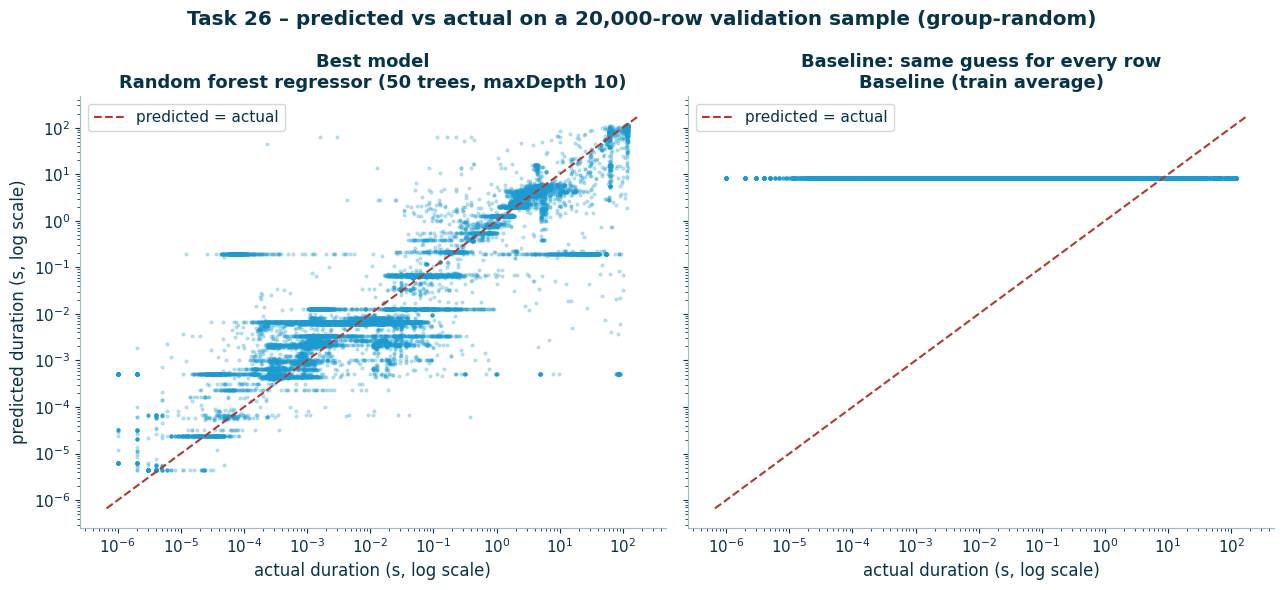

Table saved: tables/t26_best_regressor.csv  (8 rows)


run,model,mae_s,rmse_s,r2,rmse_log,gap_rmse_s,fit_seconds
11,"Random forest regressor (50 trees, maxDepth 10)",2.8979,11.3974,0.7636,1.9968,-0.8271,70.5528
25,"Random forest regressor (50 trees, maxDepth 10)",2.9035,11.4024,0.7633,1.9944,-0.7700,75.2529
39,"Random forest regressor (50 trees, maxDepth 10)",2.9164,11.4066,0.7632,1.9947,-0.8376,74.4683
40,"Gradient-boosted trees regressor (50 rounds, maxDepth 5)",2.9847,11.7399,0.7491,2.0059,-0.7537,75.1673
26,"Gradient-boosted trees regressor (50 rounds, maxDepth 5)",3.0179,11.8422,0.7447,2.0119,-0.6885,59.1641
12,"Gradient-boosted trees regressor (50 rounds, maxDepth 5)",3.0716,12.0327,0.7365,2.0112,-0.6763,54.3443
29,"scikit-learn MLP regressor (64, 32) [sample]",3.2477,12.7110,0.7056,2.0433,-2.3521,34.7612
38,Linear regression (log target),6.3022,21.7913,0.1356,2.7508,-0.9269,4.9887


In [ ]:
# ==========================================================================================
# TASK 26 – Predicted vs actual, and the best regressor
#   Best = lowest validation RMSE, with MAE as a check (group-random scheme).
#   Points along the diagonal are good; a flat cloud means the model is guessing the average.
#   Durations run from microseconds to two minutes, so both axes are on a log scale.
# ==========================================================================================
ranked = best_rows('reg')
grp = ranked[(ranked.scheme == 'group_random') & (ranked.model != 'Baseline (train average)')]
best_name = grp.iloc[0].model
by_mae = grp.sort_values('mae_s').iloc[0].model
print(f'Best regressor on validation RMSE: {best_name}')
print(f'Best on MAE (check): {by_mae}' + ('  – same model' if by_mae == best_name else '  – a different model, mention it'))

panels = [(best_name, 'Best model'), ('Baseline (train average)', 'Baseline: same guess for every row')]
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
for ax, (name, label) in zip(axes, panels):
    s = REG_SAMPLES.get((name, 'group_random'))
    if s is None:
        ax.set_title(f'{label}\n(run its task cell in this session to plot it)'); continue
    x, y = s.y_true / 1e6 + 1e-6, s.y_pred / 1e6 + 1e-6
    ax.scatter(x, y, s=4, alpha=0.25, color=BLUE)
    lo, hi = min(x.min(), y.min()) / 1.5, max(x.max(), y.max()) * 1.5
    ax.plot([lo, hi], [lo, hi], ls='--', color='#B03A2E', lw=1.5, label='predicted = actual')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('actual duration (s, log scale)'); ax.set_title(f'{label}\n{name}', fontweight='bold', color=NAVY)
    ax.legend(loc='upper left')
axes[0].set_ylabel('predicted duration (s, log scale)')
fig.suptitle(f'Task 26 – predicted vs actual on a 20,000-row validation sample (group-random)',
             fontweight='bold', color=NAVY)
fig.tight_layout()
img26 = f'{IMG_DIR}/task26_pred_vs_actual.png'
fig.savefig(img26, dpi=150, bbox_inches='tight')
plt.show()

show(grp[['run', 'model', 'mae_s', 'rmse_s', 'r2', 'rmse_log', 'gap_rmse_s', 'fit_seconds']], 't26_best_regressor')
docx_section('Task 26 – predicted vs actual and the best regressor', [
    ('img', img26),
    ('p', f'Best regressor (lowest validation RMSE, group-random): {best_name}. '
          f'Best on MAE: {by_mae}.'),
    ('table', grp[['run', 'model', 'mae_s', 'rmse_s', 'r2', 'rmse_log', 'gap_rmse_s', 'fit_seconds']])])
log_decision('T26', 'Regression models', 'Best regressor chosen on validation RMSE (MAE as check)',
             best_name, f'Lowest validation RMSE; best MAE: {by_mae}', nrows('reg', 'group_random', 'val'))


---
# TASK 27 – MLP classifier, small and bigger

In [ ]:
# ==========================================================================================
# TASK 27 – MLP classifier, small and bigger, on the main classification target
#   Inputs are one-hot encoded and standardised (an MLP needs inputs on the same scale).
#   Spark's MLP has no weight column; the classes are close to 50:50, so this changes little.
#   Observe: does it beat logistic regression and the best tree? Does bigger beat small?
#   Train vs validation gap, and the training time.
# ==========================================================================================
from pyspark.ml.classification import MultilayerPerceptronClassifier

release('reg')
MLP_ITER = 100
mlp_out = {}
for size, hidden in [('small', [16]), ('bigger', [64, 32])]:
    name = f'MLP {size} (hidden {hidden})'
    mlp_out[size], _ = run_classifier(
        name, lambda n, h=hidden: MultilayerPerceptronClassifier(featuresCol='features', labelCol='label',
                                                                layers=[n] + h + [2], maxIter=MLP_ITER,
                                                                blockSize=128, seed=SEED),
        'scaled', False, 'Task 27', {'hidden layers': str(hidden), 'maxIter': MLP_ITER, 'solver': 'l-bfgs'})

ranked = best_rows('clf')
show(ranked[['run', 'model', 'scheme', 'macro_f1', 'recall_ddos', 'auc_roc', 'gap_macro_f1', 'fit_seconds']],
     't27_all_classifiers_ranked', max_rows=100)


[group_random] MLP small (hidden [16]): fitted on 1,999,334 rows, 42 numeric + 1 text features (46 model inputs) in 29s
[time_based] MLP small (hidden [16]): fitted on 1,998,251 rows, 42 numeric + 1 text features (46 model inputs) in 28s
Table saved: tables/t_task27_mlp_small_(hidden_[16]).csv  (4 rows)


model,scheme,scored on,rows,macro_f1,accuracy,auc_roc,auc_pr,precision_ddos,recall_ddos,f1_ddos,precision_benign,recall_benign,f1_benign,fit_seconds,gap_macro_f1
MLP small (hidden [16]),group_random,train,"1,999,334",0.9878,0.9879,0.9988,0.9985,0.9807,0.9955,0.9881,0.9953,0.9801,0.9876,28.5879,nan
MLP small (hidden [16]),group_random,val,"1,916,976",0.9880,0.9881,0.9989,0.9986,0.9813,0.9957,0.9884,0.9954,0.9801,0.9877,28.5879,-0.0002
MLP small (hidden [16]),time_based,train,"1,998,251",0.9849,0.9849,0.9982,0.9980,0.9792,0.9913,0.9852,0.9910,0.9784,0.9847,27.9812,nan
MLP small (hidden [16]),time_based,val,"1,918,901",0.9925,0.9925,0.9998,0.9998,0.9856,0.9998,0.9926,0.9998,0.9850,0.9924,27.9812,-0.0076


Run 41 added to the Word report and classification_runs.csv
[group_random] MLP bigger (hidden [64, 32]): fitted on 1,999,334 rows, 42 numeric + 1 text features (46 model inputs) in 91s
[time_based] MLP bigger (hidden [64, 32]): fitted on 1,998,251 rows, 42 numeric + 1 text features (46 model inputs) in 89s
Table saved: tables/t_task27_mlp_bigger_(hidden_[64,_32]).csv  (4 rows)


model,scheme,scored on,rows,macro_f1,accuracy,auc_roc,auc_pr,precision_ddos,recall_ddos,f1_ddos,precision_benign,recall_benign,f1_benign,fit_seconds,gap_macro_f1
"MLP bigger (hidden [64, 32])",group_random,train,"1,999,334",0.9889,0.9889,0.9989,0.9987,0.9831,0.9951,0.9891,0.9950,0.9826,0.9887,90.5904,nan
"MLP bigger (hidden [64, 32])",group_random,val,"1,916,976",0.9890,0.9890,0.9990,0.9988,0.9836,0.9952,0.9894,0.9949,0.9826,0.9887,90.5904,-0.0001
"MLP bigger (hidden [64, 32])",time_based,train,"1,998,251",0.9855,0.9856,0.9982,0.9979,0.9808,0.9908,0.9858,0.9905,0.9802,0.9853,89.2659,nan
"MLP bigger (hidden [64, 32])",time_based,val,"1,918,901",0.9929,0.9929,0.9997,0.9995,0.9864,0.9998,0.9931,0.9998,0.9859,0.9928,89.2659,-0.0074


Run 42 added to the Word report and classification_runs.csv
Table saved: tables/t27_all_classifiers_ranked.csv  (54 rows)


run,model,scheme,macro_f1,recall_ddos,auc_roc,gap_macro_f1,fit_seconds
34,"Decision tree (maxDepth 10, class weights)",group_random,0.9937,0.9954,0.9983,-0.0001,8.1388
7,"Random forest (50 trees, maxDepth 10, class weights)",group_random,0.9935,0.9962,0.9995,-0.0000,40.6905
21,"Random forest (50 trees, maxDepth 10, class weights)",group_random,0.9934,0.9949,0.9994,-0.0001,41.1409
20,"Decision tree (maxDepth 10, class weights)",group_random,0.9932,0.9942,0.9988,0.0001,7.7573
35,"Random forest (50 trees, maxDepth 10, class weights)",group_random,0.9930,0.9954,0.9994,-0.0000,39.9600
6,"Decision tree (maxDepth 10, class weights)",group_random,0.9928,0.9963,0.9977,-0.0000,8.1600
36,"Gradient-boosted trees (50 rounds, maxDepth 5, class weights)",group_random,0.9921,0.9926,0.9992,-0.0001,53.7063
8,"Gradient-boosted trees (50 rounds, maxDepth 5, class weights)",group_random,0.9919,0.9921,0.9994,-0.0000,50.2675
22,"Gradient-boosted trees (50 rounds, maxDepth 5, class weights)",group_random,0.9913,0.9892,0.9993,0.0000,50.7166
42,"MLP bigger (hidden [64, 32])",group_random,0.9890,0.9952,0.9990,-0.0001,90.5904


---
# TASK 28 – Choose the final models on validation

In [ ]:
# ==========================================================================================
# RESULTS LOG CLEAN-UP – run once, after Tasks 17-27 and before Task 28
#   Re-running a task cell added a second (older) copy of the same model to the run logs.
#   This keeps only the LATEST run of each model per split scheme and scored part, removes the
#   superseded Step 3 log (its time-based score was not valid), and removes repeated rows from the
#   decisions log. A clean copy of the comparison tables is written to a separate Word file.
# ==========================================================================================
import os
import pandas as pd

removed = []
for kind, path in [('classification', CLF_CSV), ('regression', REG_CSV)]:
    if not os.path.exists(path):
        print(f'{os.path.basename(path)} not found - nothing to clean'); continue
    h = pd.read_csv(path)
    keep = (h.sort_values('run')
              .drop_duplicates(['model', 'scheme', 'scored on'], keep='last')
              .sort_values(['run', 'scheme', 'scored on']))
    gone = h.loc[~h.index.isin(keep.index)]
    for (m, r), g in gone.groupby(['model', 'run']):
        removed.append({'log': kind, 'model': m, 'removed run': int(r), 'rows removed': len(g)})
    keep.to_csv(path, index=False)
    print(f'{os.path.basename(path)}: {len(h)} rows -> {len(keep)} rows')

if os.path.exists(OLD_CSV):                      # Step 3 log: superseded by the Task 17 logistic regression rows
    os.replace(OLD_CSV, OLD_CSV.replace('.csv', '_superseded.csv'))
    removed.append({'log': 'Step 3 (model_runs.csv)', 'model': 'Logistic regression (Step 3)',
                    'removed run': 'all', 'rows removed': 'file renamed to model_runs_superseded.csv'})

show(pd.DataFrame(removed) if removed else pd.DataFrame([{'result': 'no duplicate runs found'}]),
     't28_0_removed_duplicate_runs')

# decisions log: the same decision logged more than once (from re-running cells) is kept once
before = len(DECISIONS)
seen, unique = set(), []
for d in reversed(DECISIONS):                    # keep the latest copy of each decision
    key = (d['task'], d['column(s)'], d['issue found'], d['decision taken'])
    if key not in seen:
        seen.add(key); unique.append(d)
DECISIONS[:] = list(reversed(unique))
print(f'Decisions log: {before} rows -> {len(DECISIONS)} rows')

# clean results file (the running Word report keeps its history; this one has no duplicates)
clf_v = best_rows('clf')[['run', 'model', 'scheme', 'macro_f1', 'recall_ddos', 'auc_roc', 'gap_macro_f1', 'fit_seconds']]
reg_v = best_rows('reg')[['run', 'model', 'scheme', 'mae_s', 'rmse_s', 'r2', 'gap_rmse_s', 'fit_seconds']]
show(clf_v, 't28_0_classification_runs_clean', max_rows=100)
show(reg_v, 't28_0_regression_runs_clean', max_rows=100)
_main_docx, DOCX_PATH = DOCX_PATH, f'{REPORT_DIR}/CN7030_Group4_results_clean.docx'
if os.path.exists(DOCX_PATH):
    os.remove(DOCX_PATH)
docx_section('Results log - one row per model (latest run only)', [
    ('h', 'Classification (validation)'), ('table', clf_v),
    ('h', 'Regression (validation, MAE / RMSE in seconds)'), ('table', reg_v)])
DOCX_PATH = _main_docx
print('Clean results file:', f'{REPORT_DIR}/CN7030_Group4_results_clean.docx'.replace(OUT_DIR + '/', ''))

classification_runs.csv: 108 rows -> 36 rows
regression_runs.csv: 42 rows -> 18 rows
Table saved: tables/t28_0_removed_duplicate_runs.csv  (25 rows)


log,model,removed run,rows removed
classification,"Decision tree (maxDepth 10, class weights)",6,4
classification,"Decision tree (maxDepth 10, class weights)",20,4
classification,"Decision tree (maxDepth 5, class weights)",5,4
classification,"Decision tree (maxDepth 5, class weights)",19,4
classification,"Gradient-boosted trees (50 rounds, maxDepth 5, class weights)",8,4
classification,"Gradient-boosted trees (50 rounds, maxDepth 5, class weights)",22,4
classification,Logistic regression (class weights),4,4
classification,Logistic regression (class weights),18,4
classification,Logistic regression (no weights),3,4
classification,Logistic regression (no weights),17,4


Decisions log: 11 rows -> 11 rows
Table saved: tables/t28_0_classification_runs_clean.csv  (18 rows)


run,model,scheme,macro_f1,recall_ddos,auc_roc,gap_macro_f1,fit_seconds
34,"Decision tree (maxDepth 10, class weights)",group_random,0.9937,0.9954,0.9983,-0.0001,8.1388
35,"Random forest (50 trees, maxDepth 10, class weights)",group_random,0.9930,0.9954,0.9994,-0.0000,39.9600
36,"Gradient-boosted trees (50 rounds, maxDepth 5, class weights)",group_random,0.9921,0.9926,0.9992,-0.0001,53.7063
42,"MLP bigger (hidden [64, 32])",group_random,0.9890,0.9952,0.9990,-0.0001,90.5904
41,MLP small (hidden [16]),group_random,0.9880,0.9957,0.9989,-0.0002,28.5879
33,"Decision tree (maxDepth 5, class weights)",group_random,0.9820,0.9829,0.9952,-0.0000,7.9283
31,Logistic regression (no weights),group_random,0.9688,0.9906,0.9930,0.0000,7.2158
32,Logistic regression (class weights),group_random,0.9685,0.9901,0.9931,-0.0000,7.0791
30,Majority-class baseline,group_random,0.3387,1.0000,0.5000,nan,0.0000
42,"MLP bigger (hidden [64, 32])",time_based,0.9929,0.9998,0.9997,-0.0074,89.2659


Table saved: tables/t28_0_regression_runs_clean.csv  (9 rows)


run,model,scheme,mae_s,rmse_s,r2,gap_rmse_s,fit_seconds
39,"Random forest regressor (50 trees, maxDepth 10)",group_random,2.9164,11.4066,0.7632,-0.8376,74.4683
40,"Gradient-boosted trees regressor (50 rounds, maxDepth 5)",group_random,2.9847,11.7399,0.7491,-0.7537,75.1673
29,"scikit-learn MLP regressor (64, 32) [sample]",group_random,3.2477,12.7110,0.7056,-2.3521,34.7612
38,Linear regression (log target),group_random,6.3022,21.7913,0.1356,-0.9269,4.9887
37,Baseline (train average),group_random,12.4286,23.4563,-0.0015,-1.8252,0.0000
39,"Random forest regressor (50 trees, maxDepth 10)",time_based,2.4872,10.7418,0.8108,-2.1130,76.1385
40,"Gradient-boosted trees regressor (50 rounds, maxDepth 5)",time_based,3.2018,11.1699,0.7954,-2.0527,74.0658
38,Linear regression (log target),time_based,6.1043,22.9049,0.1397,-1.1870,4.5512
37,Baseline (train average),time_based,13.7441,24.7785,-0.0068,-0.1991,0.0000


Clean results file: reports/CN7030_Group4_results_clean.docx


In [ ]:
# ==========================================================================================
# TASK 28 – Choose ONE final classifier and ONE final regressor (on VALIDATION only)
#   Judged on the TIME-BASED validation set: newer traffic than the model was trained on, so it is
#   the harder, more honest check. Classifier: highest macro-F1; models within 0.001 of the best
#   count as a tie and the simplest / fastest one is taken. Regressor: lowest RMSE (MAE as a check).
#   Both versions of each final model (trained on the group-random and on the time-based split)
#   are SAVED to Drive, because Task 30 (test) and Task 31 (streaming) load them from there.
#   No test data is touched here - that is Task 30.
# ==========================================================================================
import os, json
from pyspark.ml.classification import LogisticRegression, MultilayerPerceptronClassifier
from pyspark.ml.regression import RandomForestRegressor, GBTRegressor, LinearRegression

JUDGE_ON = 'time_based'
TIE = 0.001                       # macro-F1 differences smaller than this are treated as a tie
FINAL_CLF_OVERRIDE = None         # e.g. 'Logistic regression (class weights)' to force a choice
MODEL_DIR = f'{OUT_DIR}/models'
os.makedirs(MODEL_DIR, exist_ok=True)

# ---- 1. choose on the time-based validation set ------------------------------------------------
clf_val = best_rows('clf')
clf_val = clf_val[clf_val.model != 'Majority-class baseline']
cand_c = clf_val[clf_val.scheme == JUDGE_ON][['model', 'macro_f1', 'recall_ddos', 'auc_roc', 'gap_macro_f1', 'fit_seconds']]
near = cand_c[cand_c.macro_f1 >= cand_c.macro_f1.max() - TIE]
FINAL_CLF = FINAL_CLF_OVERRIDE or near.sort_values('fit_seconds').iloc[0].model
show(cand_c, 't28_1_classifiers_time_based_validation')

reg_val = best_rows('reg')
reg_val = reg_val[(reg_val.model != 'Baseline (train average)')
                  & ~reg_val.model.str.contains(r'\[sample\]', regex=True)]   # sample-only model is not comparable
cand_r = reg_val[reg_val.scheme == JUDGE_ON][['model', 'rmse_s', 'mae_s', 'r2', 'gap_rmse_s', 'fit_seconds']]
FINAL_REG = cand_r.iloc[0].model
show(cand_r, 't28_2_regressors_time_based_validation')

why_clf = (f'{FINAL_CLF}: highest time-based macro-F1' if len(near) == 1 else
           f'{FINAL_CLF}: {len(near)} models tie within {TIE} macro-F1 ({", ".join(near.model)}); '
           f'the fastest to train is taken')
print('Final classifier:', why_clf)
print(f'Final regressor : {FINAL_REG}  (best on MAE as a check: {cand_r.sort_values("mae_s").iloc[0].model})')

# ---- 2. make sure both versions are in memory (re-train if needed, same rows + settings) --------
CLF_BUILD = {
    'Logistic regression (no weights)':    (lambda n: LogisticRegression(featuresCol='features', labelCol='label', maxIter=20, regParam=0.0), 'onehot', False),
    'Logistic regression (class weights)': (lambda n: LogisticRegression(featuresCol='features', labelCol='label', maxIter=20, regParam=0.0), 'onehot', True),
    'MLP small (hidden [16])':             (lambda n: MultilayerPerceptronClassifier(featuresCol='features', labelCol='label', layers=[n, 16, 2], maxIter=100, blockSize=128, seed=SEED), 'scaled', False),
    'MLP bigger (hidden [64, 32])':        (lambda n: MultilayerPerceptronClassifier(featuresCol='features', labelCol='label', layers=[n, 64, 32, 2], maxIter=100, blockSize=128, seed=SEED), 'scaled', False)}
REG_BUILD = {
    'Random forest regressor (50 trees, maxDepth 10)':          lambda n: RandomForestRegressor(featuresCol='features', labelCol='y', numTrees=50, maxDepth=10, maxBins=max_bins('reg'), seed=SEED),
    'Gradient-boosted trees regressor (50 rounds, maxDepth 5)': lambda n: GBTRegressor(featuresCol='features', labelCol='y', maxIter=50, maxDepth=5, maxBins=max_bins('reg'), seed=SEED),
    'Linear regression (log target)':                           lambda n: LinearRegression(featuresCol='features', labelCol='y', maxIter=50, regParam=0.0)}
REG_STYLE = {'Linear regression (log target)': 'onehot'}

def ensure_clf(name, scheme):
    if (name, scheme) in CLF_MODELS:
        return
    if name not in CLF_BUILD:
        raise RuntimeError(f'{name} is not in memory - re-run its task cell, then this cell')
    make, style, w = CLF_BUILD[name]
    tr = data('clf', scheme, 'train')
    num, cat = feature_lists(tr, EXCLUDE_C)
    model, fit_s, _ = fit_model(tr, num, cat, style, make, 'label', w)
    CLF_MODELS[(name, scheme)] = (model, num + cat)
    print(f'[{scheme}] re-trained {name} in {fit_s:,.0f}s (was not in memory)')

def ensure_reg(name, scheme):
    if (name, scheme) in REG_MODELS:
        return
    if name not in REG_BUILD:
        raise RuntimeError(f'{name} is not in memory - re-run its task cell, then this cell')
    tr = data('reg', scheme, 'train').withColumn('y', F.log1p(TGT_R))
    num, cat = feature_lists(tr, EXCLUDE_R)
    model, fit_s, _ = fit_model(tr, num, cat, REG_STYLE.get(name, 'index'), REG_BUILD[name], 'y')
    REG_MODELS[(name, scheme)] = (model, True, tr.agg(F.max('y')).first()[0])
    print(f'[{scheme}] re-trained {name} in {fit_s:,.0f}s (was not in memory)')

# ---- 3. save both versions of both final models -------------------------------------------------
caps = {}
for scheme in SCHEMES:
    ensure_clf(FINAL_CLF, scheme)
    CLF_MODELS[(FINAL_CLF, scheme)][0].write().overwrite().save(f'{MODEL_DIR}/final_classifier_{scheme}')
    ensure_reg(FINAL_REG, scheme)
    entry = REG_MODELS[(FINAL_REG, scheme)]
    model_r, caps[scheme] = (entry[0], entry[2]) if isinstance(entry, tuple) else (entry, float(np.log1p(130e6)))
    model_r.write().overwrite().save(f'{MODEL_DIR}/final_regressor_{scheme}')
    print(f'[{scheme}] saved final_classifier_{scheme} and final_regressor_{scheme}')

with open(f'{MODEL_DIR}/final_models.json', 'w') as fh:
    json.dump({'classifier': FINAL_CLF, 'regressor': FINAL_REG, 'judged_on': JUDGE_ON,
               'regressor_log_target': True, 'regressor_cap_log': caps,
               'chosen': dt.datetime.now().strftime('%Y-%m-%d %H:%M')}, fh, indent=1)
print('Saved in', MODEL_DIR.replace(OUT_DIR + '/', ''), '(read by Task 30 and Task 31)')

docx_section('Task 28 - final models chosen on time-based validation', [
    ('p', f'Final classifier - {why_clf}. Final regressor - {FINAL_REG}: lowest time-based validation RMSE. '
          f'Both versions of each (trained on the group-random and on the time-based split) are saved for '
          f'Task 30 and Task 31. No test data was used for this choice.'),
    ('h', 'Classifiers on time-based validation (ranked)'), ('table', cand_c),
    ('h', 'Regressors on time-based validation (ranked)'), ('table', cand_r)])
log_decision('T28', 'Final models', f'Chosen on {JUDGE_ON} validation only',
             f'Classifier: {FINAL_CLF} | Regressor: {FINAL_REG}',
             f'Time-based split shows which models still work on newer traffic; macro-F1 ties within {TIE} '
             f'go to the fastest model; regressor by RMSE with MAE as a check',
             nrows('clf', 'time_based', 'val'))

Table saved: tables/t28_1_classifiers_time_based_validation.csv  (8 rows)


model,macro_f1,recall_ddos,auc_roc,gap_macro_f1,fit_seconds
"MLP bigger (hidden [64, 32])",0.9929,0.9998,0.9997,-0.0074,89.2659
MLP small (hidden [16]),0.9925,0.9998,0.9998,-0.0076,27.9812
Logistic regression (no weights),0.9710,0.9999,0.9994,-0.0125,7.1704
Logistic regression (class weights),0.9707,0.9999,0.9994,-0.0126,7.0655
"Decision tree (maxDepth 10, class weights)",0.9281,0.8631,0.9956,0.0628,7.9616
"Gradient-boosted trees (50 rounds, maxDepth 5, class weights)",0.7612,0.5548,0.9898,0.2288,49.5441
"Random forest (50 trees, maxDepth 10, class weights)",0.7609,0.5545,0.9932,0.2309,41.0145
"Decision tree (maxDepth 5, class weights)",0.7547,0.5548,0.9750,0.2255,7.4933


Table saved: tables/t28_2_regressors_time_based_validation.csv  (3 rows)


model,rmse_s,mae_s,r2,gap_rmse_s,fit_seconds
"Random forest regressor (50 trees, maxDepth 10)",10.7418,2.4872,0.8108,-2.1130,76.1385
"Gradient-boosted trees regressor (50 rounds, maxDepth 5)",11.1699,3.2018,0.7954,-2.0527,74.0658
Linear regression (log target),22.9049,6.1043,0.1397,-1.1870,4.5512


Final classifier: MLP small (hidden [16]): 2 models tie within 0.001 macro-F1 (MLP bigger (hidden [64, 32]), MLP small (hidden [16])); the fastest to train is taken
Final regressor : Random forest regressor (50 trees, maxDepth 10)  (best on MAE as a check: Random forest regressor (50 trees, maxDepth 10))
[group_random] saved final_classifier_group_random and final_regressor_group_random
[time_based] saved final_classifier_time_based and final_regressor_time_based
Saved in models (read by Task 30 and Task 31)


---
# TASK 29 (optional) – scikit-learn neural network for regression on a sample

In [ ]:

# TASK 29 (optional) – Neural network for regression with scikit-learn, on a SAMPLE
#   scikit-learn runs on one machine, so it gets a sample (sizes below - state them in the report).
#   Same log target. For a fair comparison the best Spark regressor is scored on the SAME sample.
# ==========================================================================================
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler as SkScaler

SK_TRAIN_ROWS, SK_VAL_ROWS = 200_000, 100_000
forget_runs('reg', 'scikit-learn MLP regressor (64, 32) [sample]')
scheme = 'group_random'
tr_full, va_full = data('reg', scheme, 'train'), data('reg', scheme, 'val')
num, cat = feature_lists(tr_full, EXCLUDE_R)
tr_s = tr_full.sample(False, min(1.0, SK_TRAIN_ROWS / nrows('reg', scheme, 'train')), seed=SEED)
va_s = va_full.sample(False, min(1.0, SK_VAL_ROWS / nrows('reg', scheme, 'val')), seed=SEED).cache()
tr_pd = tr_s.select(*num, *cat, TGT_R).toPandas()
va_pd = va_s.select(*num, *cat, TGT_R).toPandas()
print(f'scikit-learn sample: {len(tr_pd):,} train rows, {len(va_pd):,} validation rows ({scheme})')

def design(df, columns=None):
    X = pd.get_dummies(df[num + cat], columns=cat, dtype=float)
    return X.reindex(columns=columns, fill_value=0.0) if columns is not None else X
X_tr = design(tr_pd); X_va = design(va_pd, X_tr.columns)
sc = SkScaler().fit(X_tr)
y_tr = np.log1p(tr_pd[TGT_R].values)
Y_CAP = y_tr.max()        # same cap as the Spark models: never predict beyond the longest training flow

t0 = time.time()
nn = MLPRegressor(hidden_layer_sizes=(64, 32), early_stopping=True, max_iter=200, random_state=SEED)
nn.fit(sc.transform(X_tr), y_tr)
fit_s = time.time() - t0

def np_metrics(y_true, y_pred):
    d = y_pred - y_true
    dl = np.log1p(y_pred) - np.log1p(y_true)
    return {'mae_s': np.mean(np.abs(d)) / 1e6, 'rmse_s': np.sqrt(np.mean(d ** 2)) / 1e6,
            'r2': 1 - np.mean(d ** 2) / np.var(y_true), 'rmse_log': np.sqrt(np.mean(dl ** 2))}

rows = []
for part, X, df in [('train', X_tr, tr_pd), ('val', X_va, va_pd)]:
    pred = np.expm1(np.clip(nn.predict(sc.transform(X)), 0, Y_CAP))
    rows.append({'model': 'scikit-learn MLP regressor (64, 32) [sample]', 'scheme': scheme, 'scored on': part,
                 'rows': len(df), **np_metrics(df[TGT_R].values.astype(float), pred), 'fit_seconds': fit_s})

# best Spark regressor on the same validation sample
ranked = best_rows('reg')
cands = ranked[(ranked.scheme == scheme) & (ranked.model != 'Baseline (train average)')]
same = []
for _, r in cands.iterrows():
    if (r.model, scheme) in REG_MODELS:
        p = reg_predict(r.model, scheme, va_s)
        same.append({'model': r.model + ' [same sample]', 'scheme': scheme, 'scored on': 'val',
                     'rows': len(va_pd), **reg_metrics(p), 'fit_seconds': r.fit_seconds})
        break
va_s.unpersist()
cmp_29 = pd.DataFrame([rows[1]] + same)
show(cmp_29, 't29_sklearn_vs_spark_same_sample')
finish_reg('scikit-learn MLP regressor (64, 32) [sample]', 'Task 29', rows,
           {'library': 'scikit-learn', 'train sample rows': f'{len(tr_pd):,}', 'validation sample rows': f'{len(va_pd):,}',
            'hidden layers': '(64, 32)', 'early stopping': 'yes', 'max_iter': 200,
            'target transform': 'log1p / expm1, capped at the longest training flow'},
           extra_blocks=[('h', 'Same validation sample: scikit-learn MLP vs best Spark regressor'), ('table', cmp_29)])




Removed 2 earlier row(s) of "scikit-learn MLP regressor (64, 32) [sample]" (run(s) [np.int64(29)]) from regression_runs.csv
scikit-learn sample: 199,832 train rows, 99,854 validation rows (group_random)
Table saved: tables/t29_sklearn_vs_spark_same_sample.csv  (2 rows)


model,scheme,scored on,rows,mae_s,rmse_s,r2,rmse_log,fit_seconds
"scikit-learn MLP regressor (64, 32) [sample]",group_random,val,"99,854",3.4677,13.1231,0.6864,2.0399,42.1989
"Random forest regressor (50 trees, maxDepth 10) [same sample]",group_random,val,"99,854",2.9038,11.3611,0.7649,1.9970,74.4683


Table saved: tables/t_task29_scikit-learn_mlp_regressor_(64,_32)_[sam.csv  (2 rows)


model,scheme,scored on,rows,mae_s,rmse_s,r2,rmse_log,fit_seconds,gap_rmse_s
"scikit-learn MLP regressor (64, 32) [sample]",group_random,train,"199,832",3.8226,13.7327,0.7029,2.0314,42.1989,nan
"scikit-learn MLP regressor (64, 32) [sample]",group_random,val,"99,854",3.4677,13.1231,0.6864,2.0399,42.1989,-0.6097


Run 43 added to the Word report and regression_runs.csv


,model,scheme,scored on,rows,mae_s,rmse_s,r2,rmse_log,fit_seconds,gap_rmse_s
0,"scikit-learn MLP regressor (64, 32) [sample]",group_random,train,199832,3.822601,13.732743,0.702861,2.031396,42.198894,NaN
1,"scikit-learn MLP regressor (64, 32) [sample]",group_random,val,99854,3.467687,13.123072,0.686357,2.039912,42.198894,-0.609672


# Task 30

In [ ]:
# ==========================================================================================
# TASK 30 – Score TEST once: final classifier (both versions), final regressor (both versions)
#   and the baselines. Final table with validation and test side by side.
#   "Both versions" = the model trained on the group-random split (scored on its test set) and the
#   model trained on the time-based split (scored on its test set). The time-based one is the headline.
#   Models are loaded from the files saved in Task 28, so this works after a restart.
#   A marker file stops the test set being scored a second time by accident.
# ==========================================================================================
import os, json
from pyspark.ml import PipelineModel

MODEL_DIR   = f'{OUT_DIR}/models'
TEST_MARKER = f'{REPORT_DIR}/test_scored_once.txt'
TEST_RAW    = f'{TABLE_DIR}/t30_test_scores_raw.csv'
RESCORE_TEST = False             # leave False: the test set is scored once only
final = json.load(open(f'{MODEL_DIR}/final_models.json'))
FINAL_CLF, FINAL_REG = final['classifier'], final['regressor']
VERSION = {'time_based': 'time-based split (headline)', 'group_random': 'group-random split'}

def load_clf(scheme):
    return PipelineModel.load(f'{MODEL_DIR}/final_classifier_{scheme}')

def reg_scores(scheme, df):
    model = PipelineModel.load(f'{MODEL_DIR}/final_regressor_{scheme}')
    cap = final['regressor_cap_log'][scheme]
    pr = F.expm1(F.greatest(F.least(F.col('prediction'), F.lit(cap)), F.lit(0.0)))   # same cap as validation
    return model.transform(df).select(F.col(TGT_R).cast('double').alias('y_true'), pr.alias('y_pred'))

if os.path.exists(TEST_MARKER) and not RESCORE_TEST:
    print('The test set has already been scored once:\n' + open(TEST_MARKER).read())
    raw = pd.read_csv(TEST_RAW)
else:
    rows = []
    for scheme in ['time_based', 'group_random']:
        te_c, tr_c = data('clf', scheme, 'test'), data('clf', scheme, 'train')
        p = score_clf(load_clf(scheme), te_c)                                   # final classifier
        m, _ = clf_metrics(p); m.update(clf_auc(p)); p.unpersist()
        rows.append({'task': 'classification', 'model': FINAL_CLF, 'scheme': scheme, 'rows': nrows('clf', scheme, 'test'), **m})
        maj = float(tr_c.groupBy('label').count().orderBy(F.desc('count')).first()['label'])   # majority-class baseline
        m, _ = clf_metrics(te_c.select('label', F.lit(maj).alias('prediction'), F.lit(0.5).alias('p_ddos')))
        rows.append({'task': 'classification', 'model': 'Majority-class baseline', 'scheme': scheme,
                     'rows': nrows('clf', scheme, 'test'), **m, 'auc_roc': 0.5})

        te_r, tr_r = data('reg', scheme, 'test'), data('reg', scheme, 'train')
        rows.append({'task': 'regression', 'model': FINAL_REG, 'scheme': scheme, 'rows': nrows('reg', scheme, 'test'),
                     **reg_metrics(reg_scores(scheme, te_r))})                    # final regressor
        mean_tr = float(tr_r.agg(F.avg(TGT_R)).first()[0])                       # train-average baseline
        rows.append({'task': 'regression', 'model': 'Baseline (train average)', 'scheme': scheme,
                     'rows': nrows('reg', scheme, 'test'),
                     **reg_metrics(te_r.select(F.col(TGT_R).cast('double').alias('y_true'), F.lit(mean_tr).alias('y_pred')))})
        print(f'[{scheme}] test scored')
    raw = pd.DataFrame(rows)
    raw.to_csv(TEST_RAW, index=False)
    with open(TEST_MARKER, 'w') as fh:
        fh.write(f'Test scored on {dt.datetime.now():%Y-%m-%d %H:%M}\nClassifier: {FINAL_CLF}\nRegressor: {FINAL_REG}\n')

# ---- validation and test side by side -----------------------------------------------------------
def side_by_side(kind, metrics):
    val = best_rows(kind)
    rows = []
    for _, t in raw[raw.task == ('classification' if kind == 'clf' else 'regression')].iterrows():
        v = val[(val.model == t.model) & (val.scheme == t.scheme)]
        r = {'model': t.model, 'version': VERSION[t.scheme]}
        for m in metrics:
            r[f'{m} (val)'] = v.iloc[0][m] if len(v) and m in v and pd.notna(v.iloc[0][m]) else np.nan
            r[f'{m} (test)'] = t[m]
        rows.append(r)
    return pd.DataFrame(rows)

final_clf_tbl = side_by_side('clf', ['macro_f1', 'recall_ddos', 'precision_ddos', 'accuracy', 'auc_roc'])
final_reg_tbl = side_by_side('reg', ['mae_s', 'rmse_s', 'r2'])
show(final_clf_tbl, 't30_1_final_classification_val_vs_test')
show(final_reg_tbl, 't30_2_final_regression_val_vs_test')

docx_section('Task 30 - test scored once: validation and test side by side', [
    ('p', f'Final classifier: {FINAL_CLF}. Final regressor: {FINAL_REG} (chosen in Task 28 on time-based '
          f'validation). Each is shown in both versions with its baseline; the test sets were scored once.'),
    ('h', 'Classification (validation vs test)'), ('table', final_clf_tbl),
    ('h', 'Regression - MAE / RMSE in seconds (validation vs test)'), ('table', final_reg_tbl)])
log_decision('T30', 'Test sets', 'Final models and baselines scored once on test',
             f'{FINAL_CLF} and {FINAL_REG}, both versions, plus baselines',
             'Test was used only after the final models were fixed on validation', int(raw.rows.sum()))

[time_based] test scored
[group_random] test scored
Table saved: tables/t30_1_final_classification_val_vs_test.csv  (4 rows)


model,version,macro_f1 (val),macro_f1 (test),recall_ddos (val),recall_ddos (test),precision_ddos (val),precision_ddos (test),accuracy (val),accuracy (test),auc_roc (val),auc_roc (test)
MLP small (hidden [16]),time-based split (headline),0.9925,0.9928,0.9998,0.9997,0.9856,0.9862,0.9925,0.9928,0.9998,0.9999
Majority-class baseline,time-based split (headline),0.3359,0.3358,1.0000,1.0000,0.5059,0.5057,0.5059,0.5057,0.5000,0.5000
MLP small (hidden [16]),group-random split,0.9880,0.9878,0.9957,0.9955,0.9813,0.9806,0.9881,0.9878,0.9989,0.9988
Majority-class baseline,group-random split,0.3387,0.3354,1.0000,1.0000,0.5122,0.5046,0.5122,0.5046,0.5000,0.5000


Table saved: tables/t30_2_final_regression_val_vs_test.csv  (4 rows)


model,version,mae_s (val),mae_s (test),rmse_s (val),rmse_s (test),r2 (val),r2 (test)
"Random forest regressor (50 trees, maxDepth 10)",time-based split (headline),2.4872,2.3665,10.7418,10.2580,0.8108,0.8180
Baseline (train average),time-based split (headline),13.7441,13.4279,24.7785,24.1590,-0.0068,-0.0094
"Random forest regressor (50 trees, maxDepth 10)",group-random split,2.9164,2.9772,11.4066,11.5394,0.7632,0.7623
Baseline (train average),group-random split,12.4286,12.5361,23.4563,23.6809,-0.0015,-0.0011


# Task 31

In [ ]:
# ==========================================================================================
# TASK 31.1 – Save 5,000 test rows as 5 small files
#   limit(5000) takes 5,000 test rows; repartition(5) splits them into 5 chunks of about 1,000;
#   Spark writes one file per chunk. Each file stands for one batch of new flows arriving.
# ==========================================================================================
import os, json
MODEL_DIR     = f'{OUT_DIR}/models'
STREAM_SCHEME = 'time_based'                     # the version the final classifier was chosen on
STREAM_IN     = f'{OUT_DIR}/stream_in'
final = json.load(open(f'{MODEL_DIR}/final_models.json'))

test_prepared = spark.read.parquet(f'{OUT_DIR}/splits/{STREAM_SCHEME}/test.parquet')
test_prepared.limit(5000).repartition(5).write.mode('overwrite').parquet(STREAM_IN)
print('Files in stream_in:')
for name in sorted(os.listdir(STREAM_IN)):
    if not name.startswith('.'):
        print('  ', name)

Files in stream_in:
   _SUCCESS
   part-00000-add7dd78-4af8-4fe1-873f-f2218b4994a2-c000.snappy.parquet
   part-00001-add7dd78-4af8-4fe1-873f-f2218b4994a2-c000.snappy.parquet
   part-00002-add7dd78-4af8-4fe1-873f-f2218b4994a2-c000.snappy.parquet
   part-00003-add7dd78-4af8-4fe1-873f-f2218b4994a2-c000.snappy.parquet
   part-00004-add7dd78-4af8-4fe1-873f-f2218b4994a2-c000.snappy.parquet


Task 31.2

In [ ]:
# ==========================================================================================
# TASK 31.2 – Load the final classifier and make a prediction-only version
#   The saved model is a PipelineModel (encoders + scaler + classifier), so it is loaded with
#   PipelineModel.load. A prediction-only version drops any step that builds the label from the
#   target. In our pipeline the label is made from label_binary BEFORE the model, so there is no
#   label step to drop - the check below shows it, and the stream only needs the feature columns.
# ==========================================================================================
from pyspark.ml import PipelineModel

clf_model = PipelineModel.load(f'{MODEL_DIR}/final_classifier_{STREAM_SCHEME}')

def out_col(stage):
    for p in ('outputCol', 'outputCols'):
        try:
            if stage.hasParam(p) and stage.isDefined(p):
                return stage.getOrDefault(p)
        except Exception:
            pass
    return '-'

print(f'Final classifier: {final["classifier"]} ({STREAM_SCHEME} version)')
for i, s in enumerate(clf_model.stages):
    print(f'  stage {i}: {type(s).__name__:<45} -> {out_col(s)}')
pred_stages = [s for s in clf_model.stages if out_col(s) != 'label']
predict_model = PipelineModel(stages=pred_stages)
print(f'Prediction-only version: {len(pred_stages)} of {len(clf_model.stages)} stages kept '
      f'({len(clf_model.stages) - len(pred_stages)} label step(s) dropped)')

Final classifier: MLP small (hidden [16]) (time_based version)
  stage 0: StringIndexerModel                            -> StringIndexerModel_53dc929819fa__output
  stage 1: OneHotEncoderModel                            -> OneHotEncoderModel_9cadddb68f33__output
  stage 2: VectorAssembler                               -> features_raw
  stage 3: StandardScalerModel                           -> features
  stage 4: MultilayerPerceptronClassificationModel       -> -
Prediction-only version: 5 of 5 stages kept (0 label step(s) dropped)


Task 31.3

In [ ]:
# ==========================================================================================
# TASK 31.3 – Point Spark at the folder as a stream
#   readStream = keep watching this folder for files (nothing is read yet).
#   schema(...) gives the column names and types up front; maxFilesPerTrigger=1 = one file per batch.
# ==========================================================================================
incoming = (spark.readStream
            .schema(test_prepared.schema)
            .option('maxFilesPerTrigger', 1)
            .parquet(STREAM_IN))
print(incoming.isStreaming)      # True

True


Task 31.4

In [ ]:
# ==========================================================================================
# TASK 31.4 – Add the model to the stream: keep the true answer and the prediction
#   Same .transform() as for validation, but on the stream. prediction 1.0 = ddos, 0.0 = benign.
# ==========================================================================================
scored = (predict_model.transform(incoming)
          .select('Label', 'prediction',
                  F.when(F.col('prediction') == 1.0, 'ddos').otherwise('benign').alias('predicted_label')))
print(scored.isStreaming)        # still True - nothing has run yet, this only adds to the plan

True


Task 31.5

In [ ]:
# ==========================================================================================
# TASK 31.5 – Start the stream, wait for all 5 files, then show true vs predicted
#   format('memory') keeps the results in an in-memory table called live_predictions;
#   availableNow=True processes every file in the folder, one batch per file, then stops.
# ==========================================================================================
for q in spark.streams.active:                   # stop a previous run of this cell, if any
    if q.name == 'live_predictions':
        q.stop()

query = (scored.writeStream
         .format('memory')
         .queryName('live_predictions')
         .outputMode('append')
         .trigger(availableNow=True)
         .start())
query.awaitTermination()

batches = pd.DataFrame([{'batch': p['batchId'], 'rows in batch': p['numInputRows']}
                        for p in query.recentProgress if p['numInputRows'] > 0])
show(batches, 't31_stream_batches')

spark.sql('SELECT * FROM live_predictions').show(20)

live = spark.sql('SELECT * FROM live_predictions')
n = live.count()
correct = live.filter(F.col('Label') == F.col('predicted_label')).count()
cm_live = (live.groupBy('Label').pivot('predicted_label', ['benign', 'ddos']).count()
               .fillna(0).orderBy('Label').toPandas()
               .rename(columns={'Label': 'actual', 'benign': 'predicted benign', 'ddos': 'predicted ddos'}))
show(cm_live, 't31_stream_confusion')
print(f'Streamed {n:,} rows in {len(batches)} batches; {correct:,} predicted correctly ({correct / n:.2%}).')
docx_section('Task 31 - streaming demo with the final classifier', [
    ('p', f'{final["classifier"]} ({STREAM_SCHEME} version) loaded from disk and applied to 5,000 test rows '
          f'arriving as 5 files, one batch per file. {correct:,} of {n:,} predicted correctly ({correct / n:.2%}).'),
    ('table', batches), ('table', cm_live)])

Table saved: tables/t31_stream_batches.csv  (5 rows)


batch,rows in batch
0,"1,000"
1,"1,000"
2,"1,000"
3,"1,000"
4,"1,000"


+------+----------+---------------+
| Label|prediction|predicted_label|
+------+----------+---------------+
|benign|       0.0|         benign|
|benign|       0.0|         benign|
|benign|       0.0|         benign|
|benign|       0.0|         benign|
|benign|       0.0|         benign|
|benign|       0.0|         benign|
|benign|       0.0|         benign|
|benign|       0.0|         benign|
|benign|       0.0|         benign|
|benign|       0.0|         benign|
|benign|       0.0|         benign|
|benign|       0.0|         benign|
|benign|       0.0|         benign|
|benign|       0.0|         benign|
|benign|       0.0|         benign|
|benign|       0.0|         benign|
|benign|       0.0|         benign|
|benign|       0.0|         benign|
|benign|       0.0|         benign|
|benign|       0.0|         benign|
+------+----------+---------------+
only showing top 20 rows
Table saved: tables/t31_stream_confusion.csv  (1 rows)


actual,predicted benign,predicted ddos
benign,"4,969",31


Streamed 5,000 rows in 5 batches; 4,969 predicted correctly (99.38%).


Task 31.6

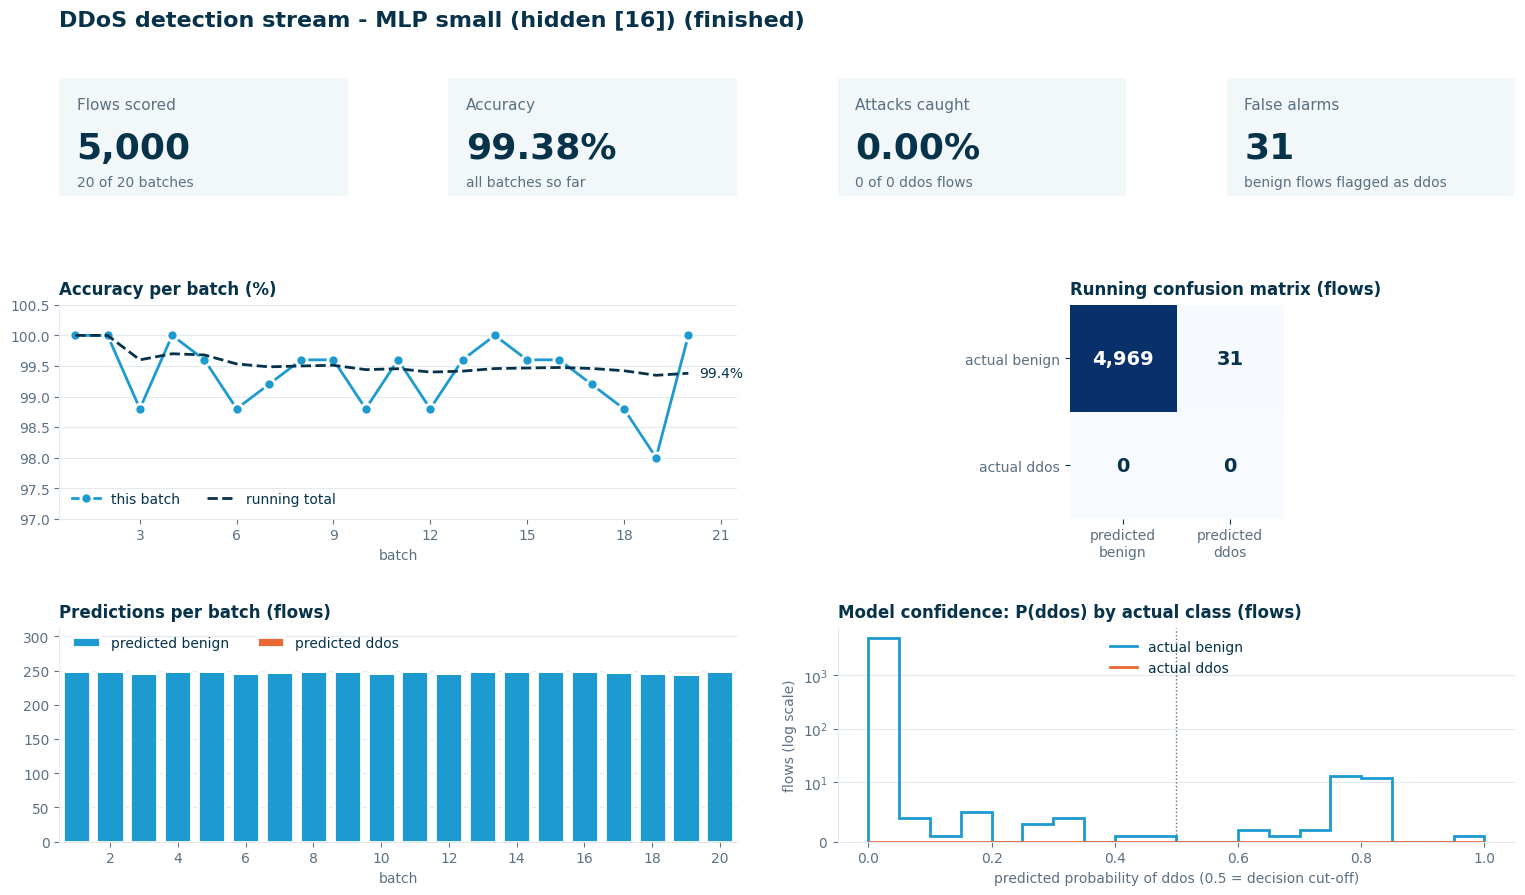

Dashboard finished: 20 batches; final picture saved to figures/t31_6_stream_dashboard.png


In [ ]:
# ==========================================================================================
# TASK 31.6 (optional) – Live visual dashboard of the stream
#   The same final classifier on a stream of test flows, shown as a dashboard that redraws after
#   every batch: headline numbers, accuracy per batch, the running confusion matrix, the mix of
#   predictions per batch and how confident the model is. Run 31.1-31.4 first.
#   Spark only collects small per-batch summaries (foreachBatch); the drawing happens here, in the
#   notebook's own loop, so it displays reliably in Colab. Stop early with the cell's stop button.
# ==========================================================================================
import os, time, uuid, shutil
import numpy as np, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator
from IPython.display import display, clear_output
from pyspark.ml.functions import vector_to_array

DASH_ROWS, DASH_FILES = 5000, 20          # 5,000 test flows arriving as 20 batches of ~250
SECONDS_PER_BATCH = 2                     # one new file every 2 seconds, so you can watch it build up
DASH_IN = f'{OUT_DIR}/stream_dash_in'
BENIGN, DDOS, NAVY, MUTED, GRID = '#1D9BD1', '#eb6834', '#06324A', '#5B7083', '#E3EAEF'

test_prepared.limit(DASH_ROWS).repartition(DASH_FILES).write.mode('overwrite').parquet(DASH_IN)
n_files = len([f for f in os.listdir(DASH_IN) if f.endswith('.parquet')])

dash_scored = (predict_model.transform(
                   spark.readStream.schema(test_prepared.schema)
                        .option('maxFilesPerTrigger', 1).parquet(DASH_IN))
               .select('Label', 'prediction', vector_to_array('probability')[1].alias('p_ddos')))

BATCHES = []
def collect(batch_df, batch_id):
    """Runs once per batch: keep only small summaries (counts and a 20-bin confidence histogram)."""
    cm = {(r['Label'], int(r['prediction'])): r['count']
          for r in batch_df.groupBy('Label', 'prediction').count().collect()}
    hist = [(r['b'], r['Label'], r['count']) for r in
            batch_df.select(F.least(F.floor(F.col('p_ddos') * 20), F.lit(19)).alias('b'), 'Label')
                    .groupBy('b', 'Label').count().collect()]
    if cm:
        BATCHES.append({'batch': len(BATCHES) + 1, 'cm': cm, 'hist': hist})

def style(ax, title):
    ax.set_title(title, loc='left', fontsize=12, fontweight='bold', color=NAVY, pad=8)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=10)
    ax.grid(axis='y', color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

def render(final=False):
    b = list(BATCHES)
    tot = {k: sum(x['cm'].get(k, 0) for x in b) for k in
           [('benign', 0), ('benign', 1), ('ddos', 0), ('ddos', 1)]}
    n = sum(tot.values())
    acc = (tot[('benign', 0)] + tot[('ddos', 1)]) / n if n else 0
    recall = tot[('ddos', 1)] / max(tot[('ddos', 0)] + tot[('ddos', 1)], 1)
    fig = plt.figure(figsize=(16, 9.2), facecolor='white')
    gs = GridSpec(3, 4, figure=fig, height_ratios=[0.55, 1, 1], hspace=0.6, wspace=0.35,
                  top=0.9, bottom=0.07, left=0.06, right=0.97)
    status = 'finished' if final else f'live - batch {len(b)} of {n_files}'
    fig.suptitle(f'DDoS detection stream - {final_name} ({status})', x=0.06, y=0.975, ha='left',
                 fontsize=16, fontweight='bold', color=NAVY)

    # ---- headline numbers ----
    tiles = [('Flows scored', f'{n:,}', f'{len(b)} of {n_files} batches'),
             ('Accuracy', f'{acc:.2%}', 'all batches so far'),
             ('Attacks caught', f'{recall:.2%}', f'{tot[("ddos", 1)]:,} of {tot[("ddos", 0)] + tot[("ddos", 1)]:,} ddos flows'),
             ('False alarms', f'{tot[("benign", 1)]:,}', 'benign flows flagged as ddos')]
    for i, (label, value, note) in enumerate(tiles):
        ax = fig.add_subplot(gs[0, i]); ax.axis('off')
        ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, color='#F2F7FA', zorder=0))
        ax.text(0.06, 0.74, label, fontsize=11, color=MUTED, transform=ax.transAxes)
        ax.text(0.06, 0.32, value, fontsize=26, fontweight='bold', color=NAVY, transform=ax.transAxes)
        ax.text(0.06, 0.08, note, fontsize=10, color=MUTED, transform=ax.transAxes)

    x = np.array([x['batch'] for x in b])
    per_acc = [((x['cm'].get(('benign', 0), 0) + x['cm'].get(('ddos', 1), 0)) / sum(x['cm'].values())) * 100 for x in b]
    run_acc, c, t = [], 0, 0
    for x_ in b:
        c += x_['cm'].get(('benign', 0), 0) + x_['cm'].get(('ddos', 1), 0); t += sum(x_['cm'].values())
        run_acc.append(c / t * 100)

    # ---- accuracy per batch ----
    ax = fig.add_subplot(gs[1, :2]); style(ax, 'Accuracy per batch (%)')
    if len(b):
        ax.plot(x, per_acc, color=BENIGN, linewidth=2, marker='o', markersize=8,
                markeredgecolor='white', markeredgewidth=2, label='this batch')
        ax.plot(x, run_acc, color=NAVY, linewidth=2, linestyle='--', label='running total')
        lo = min(per_acc + run_acc)
        ax.set_ylim(max(0, lo - max(1, (100 - lo) * 0.3)), 100.5)
        ax.annotate(f'{run_acc[-1]:.1f}%', (x[-1], run_acc[-1]), xytext=(8, 0), textcoords='offset points',
                    va='center', fontsize=10, color=NAVY)
        ax.legend(frameon=False, fontsize=10, loc='lower left', ncol=2, labelcolor=NAVY)
    ax.set_xlim(0.5, n_files + 1.5); ax.set_xlabel('batch', color=MUTED, fontsize=10)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    # ---- running confusion matrix ----
    ax = fig.add_subplot(gs[1, 2:])
    cm = np.array([[tot[('benign', 0)], tot[('benign', 1)]], [tot[('ddos', 0)], tot[('ddos', 1)]]])
    ax.imshow(cm, cmap='Blues', vmin=0, vmax=max(cm.max(), 1))
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center', fontsize=14, fontweight='bold',
                    color='white' if cm[i, j] > cm.max() * 0.55 else NAVY)
    ax.set_xticks([0, 1], ['predicted\nbenign', 'predicted\nddos'], fontsize=10, color=MUTED)
    ax.set_yticks([0, 1], ['actual benign', 'actual ddos'], fontsize=10, color=MUTED)
    ax.set_title('Running confusion matrix (flows)', loc='left', fontsize=12, fontweight='bold', color=NAVY, pad=8)
    for s in ax.spines.values():
        s.set_visible(False)

    # ---- predictions per batch ----
    ax = fig.add_subplot(gs[2, :2]); style(ax, 'Predictions per batch (flows)')
    if len(b):
        pb = np.array([x['cm'].get(('benign', 0), 0) + x['cm'].get(('ddos', 0), 0) for x in b])
        pd_ = np.array([x['cm'].get(('benign', 1), 0) + x['cm'].get(('ddos', 1), 0) for x in b])
        ax.bar(x, pb, width=0.8, color=BENIGN, edgecolor='white', linewidth=2, label='predicted benign')
        ax.bar(x, pd_, bottom=pb, width=0.8, color=DDOS, edgecolor='white', linewidth=2, label='predicted ddos')
        ax.legend(frameon=False, fontsize=10, loc='upper left', ncol=2, labelcolor=NAVY,
                  bbox_to_anchor=(0, 1.02))
        ax.set_ylim(0, (pb + pd_).max() * 1.25)
    ax.set_xlim(0.5, n_files + 0.5); ax.set_xlabel('batch', color=MUTED, fontsize=10)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    # ---- model confidence ----
    ax = fig.add_subplot(gs[2, 2:]); style(ax, 'Model confidence: P(ddos) by actual class (flows)')
    edges = np.arange(0, 1.0001, 0.05)
    for cls, col in [('benign', BENIGN), ('ddos', DDOS)]:
        counts = np.zeros(20)
        for x_ in b:
            for bin_, lab, cnt in x_['hist']:
                if lab == cls and bin_ is not None:
                    counts[int(bin_)] += cnt
        ax.stairs(counts, edges, color=col, linewidth=2, label=f'actual {cls}')
    ax.set_yscale('symlog', linthresh=10)
    ax.set_ylabel('flows (log scale)', color=MUTED, fontsize=10)
    ax.set_xlabel('predicted probability of ddos (0.5 = decision cut-off)', color=MUTED, fontsize=10)
    ax.axvline(0.5, color=MUTED, linewidth=1, linestyle=':')
    ax.legend(frameon=False, fontsize=10, loc='upper center', labelcolor=NAVY)
    return fig

final_name = final['classifier']
ckpt = f'/tmp/dash_ckpt_{uuid.uuid4().hex[:8]}'          # fresh checkpoint each run = replay all files
for q in spark.streams.active:
    if q.name == 'dashboard_stream':
        q.stop()
dash_q = (dash_scored.writeStream.queryName('dashboard_stream')
          .foreachBatch(collect)
          .option('checkpointLocation', ckpt)
          .trigger(processingTime=f'{SECONDS_PER_BATCH} seconds')
          .start())

deadline = time.time() + n_files * SECONDS_PER_BATCH * 4 + 120
try:
    while dash_q.isActive and len(BATCHES) < n_files and time.time() < deadline:
        fig = render(); clear_output(wait=True); display(fig); plt.close(fig)
        time.sleep(1)
finally:
    dash_q.stop()
    shutil.rmtree(ckpt, ignore_errors=True)

fig = render(final=True)
img_dash = f'{FIG_DIR}/t31_6_stream_dashboard.png'
fig.savefig(img_dash, dpi=150, bbox_inches='tight')
clear_output(wait=True); display(fig); plt.close(fig)
print(f'Dashboard finished: {len(BATCHES)} batches; final picture saved to {img_dash.replace(OUT_DIR + "/", "")}')
docx_section('Task 31.6 - live stream dashboard (final frame)', [
    ('p', f'{final_name} applied to {DASH_ROWS:,} test flows arriving as {n_files} batches, one every '
          f'{SECONDS_PER_BATCH} seconds; the dashboard was redrawn after every batch.'),
    ('img', img_dash)])